# CarbonDefect 23.5.5-FINAL-CNN-METRICS — HEDCM — DUAL TASK + GT-CROP + STABLE v23.4.3 E2E

## Финальная экспериментальная схема

1. **Две задачи CNN**: `7class_defects` и `8class_defects_perfect`.
2. **6 архитектур на задачу**: ResNet18, EfficientNet-B0, MobileNetV3-Small, DenseNet121, ConvNeXt-Tiny, Swin-Tiny.
3. Для каждого из 6 представлений (RGB / Grayscale / Viridis / Inferno / Turbo / HEDCM) выполняется 12 fresh trainings; всего **72 эксперимента**.
4. Главный тест влияния представления — **GT-CROP CLASSIFICATION**: один и тот же manual bbox дефекта → выбранное представление → CNN. Ошибка локализатора не смешивается с качеством представления.
5. Отдельно считается **OPERATIONAL END-TO-END**: автоматический RGB bbox → выбранное представление → CNN.
6. Operational still-image bbox зафиксирован на устойчивом **v23.4.3 multi-candidate continuous boundary refiner**. H2.1 сохранён в коде только как диагностическая/экспериментальная ветка и не выбирает рамку source-canvas benchmark.
7. SEALED v22.3 остаётся неизменяемым научным baseline для локализации.
8. Manual GT не участвует в выборе automatic bbox. Он используется только для аудита локализации и для отдельного GT-crop classification experiment.
9. `Perfect` оценивается в 8-class задаче отдельно на окнах нормального полотна. `P(defect)=1-P(Perfect)` и бинарный порог выбираются только на VAL.
10. Все представления используют одинаковые split assignments и одинаковый training recipe.
11. Текущий split разрешён как provisional для рабочего прогона; финальные диссертационные выводы требуют source-independent физических полотен/видео.
12. Видео: стабильный proposal-generator + существующая 8-class CNN + temporal confirmation/EMA. H2.1 global recovery остаётся только экспериментальным fallback.

## Порядок запуска

1. Полностью запустить **RGB** — он публикует shared stable v23.4.3 operational bbox.
2. Затем запустить Grayscale / Viridis / Inferno / Turbo / HEDCM.
3. Основные таблицы для сравнения представлений: `GT_CROP_CLASSIFICATION`, `GT_CROP_MODEL_SUMMARY`, TEST Macro-F1 и 8-class Perfect-vs-Defect metrics.
4. End-to-end результаты хранить отдельно от GT-crop classification.
5. Для финальной кандидатской после добавления независимых физических источников переключить `FINAL_THESIS_MODE=True` и выполнить новый fresh rerun всех 72 моделей.

13. **GT-CROP Macro-F1 / balanced accuracy** считаются по 7 дефектным классам для обеих CNN-задач; Perfect не подмешивается как фиктивный GT-crop класс.
14. **Perfect** оценивается отдельно через `perfect_window_accuracy_8class`, а затем объединяется с модельной сводкой.
15. Финальный отчёт формирует общую матрицу `representation × architecture` и дельты относительно RGB; после HEDCM формируется отдельное HEDCM-vs-filters сравнение.

> **sebastiangun2022 direct runtime:** notebook использует канонические папки проекта напрямую из `/content/drive/MyDrive/CarbonDefect_AI_Benchmark` и `/content/drive/MyDrive/CarbonDefect_Vision` аккаунта `sebastiangun2022@gmail.com`; промежуточное зеркало `almol44nov@gmail.com` не используется. Схема обучения остаётся прежней: `7class_defects` + `8class_defects_perfect`, 6 архитектур, одинаковые split/recipe.

16. **V12 FINAL CLEAN visual/report standard**: в основном отчёте показываются только три рамки — manual GT, RGB operational v23.4.3 и собственная Filter bbox текущего представления. GT-CROP остаётся главным classifier experiment; operational E2E использует RGB bbox; Filter bbox используется как отдельный localization audit. STRUCT/FINAL consensus остаются только в технических CSV/appendix и не смешиваются с основным отчётом.


In [1]:
# ============================================================
# 1. BOOTSTRAP + CONFIG — v23.5.3-H2.1 SEALED-BASELINE HOTFIX + PINNED FROZEN v22.3 LOCALIZER
# ============================================================
import os, sys, json, csv, time, math, random, platform, subprocess, gc, hashlib, base64, shutil
from pathlib import Path
from datetime import datetime
from io import BytesIO

from google.colab import drive, output
from IPython.display import display, HTML, Javascript

MOUNT_POINT = Path("/content/drive")

def safe_mount_drive():
    if (MOUNT_POINT / "MyDrive").exists():
        print("Google Drive уже подключён")
        return
    drive.mount(str(MOUNT_POINT), force_remount=False)
    if not (MOUNT_POINT / "MyDrive").exists():
        raise RuntimeError("Google Drive не подключился")
    print("DRIVE OK")

safe_mount_drive()

import importlib.util

_REQUIRED_PACKAGES = {
    "fvcore": "fvcore",
    "sklearn": "scikit-learn",
    "skimage": "scikit-image",
}
_missing_packages = [
    pip_name
    for module_name,pip_name in _REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if _missing_packages:
    print("Installing missing dependencies:", _missing_packages)
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", *_missing_packages
    ])
else:
    print("Dependencies already installed")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import (
    resnet18, ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights,
    densenet121, DenseNet121_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights,
    swin_t, Swin_T_Weights,
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_recall_fscore_support, confusion_matrix, classification_report,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.covariance import MinCovDet
from sklearn.neighbors import NearestNeighbors
from skimage import color as skcolor
from skimage.feature import local_binary_pattern

REPRESENTATION = "HEDCM"
NOTEBOOK_VERSION = "23.5.5-FINAL-CNN-METRICS"
# Fresh scientific series: old CNN runs are not reused; recipe identity is tracked by RECIPE_SHA256.
TRAINING_VERSION = "23.5.4-FINAL-CNN_SCIENTIFIC_DUAL_TASK_FRESH_RETRAIN"
LOCALIZER_VERSION = "22.3_PINNED_FROZEN_RGB_run_20260917_134156"
VERSION = "23.5.5-FINAL-CNN_GT_CROP_MACROF1_PLUS_STABLE_V2343_E2E_PLUS_SEALED_22.3"
SEED = 42
EVALUATION_VERSION = "23.5.5-GT-CROP-MACROF1-PERFECT-CROSSFILTER"
LOCALIZER_REPRESENTATION = "RGB"
CLASSIFIER_DARKENING = "original"
# Historical v22.3 criterion — used for the frozen baseline and E2E comparability.
V223_HIST_HIT_MIN_BBOX_IOU = 0.25
V223_HIST_HIT_MIN_AREA_RECALL = 0.20

# Modern audit — reported separately and never substituted for the historical baseline.
MODERN_AUDIT_MIN_BBOX_IOU = 0.25
MODERN_AUDIT_MIN_AREA_RECALL = 0.20
MODERN_AUDIT_MIN_AREA_PRECISION = 0.30

# Backward-compatible aliases used by visualization helpers.
GT_HIT_MIN_BBOX_IOU = V223_HIST_HIT_MIN_BBOX_IOU
GT_HIT_MIN_AREA_RECALL = V223_HIST_HIT_MIN_AREA_RECALL
GT_HIT_MIN_AREA_PRECISION = MODERN_AUDIT_MIN_AREA_PRECISION

MODELS = [
    "ResNet18", "EfficientNet_B0", "MobileNetV3_Small",
    "DenseNet121", "ConvNeXt_Tiny", "Swin_Tiny",
]

DEFECT_CLASSES = [
    "CentralBand", "ForeignObject", "Gaps", "Overlap",
    "TapeDisintegration", "Twist", "Wrinkle",
]
EIGHT_CLASSES = DEFECT_CLASSES + ["Perfect"]
TASKS = {
    "7class_defects": DEFECT_CLASSES,
    "8class_defects_perfect": EIGHT_CLASSES,
}

# v23.5.4-FINAL-CNN: fresh dual-task training + separate GT-crop and end-to-end evaluation.
HEAD_EPOCHS = 5
FINETUNE_MAX_EPOCHS = 45
MAX_EPOCHS = HEAD_EPOCHS + FINETUNE_MAX_EPOCHS
TOTAL_EPOCHS = MAX_EPOCHS  # compatibility with downstream reports
BATCH_SIZE = 32
HEAD_LR = 1e-3
FINETUNE_LR = 1e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
NUM_WORKERS = 2
EARLY_STOPPING_PATIENCE = 8
EARLY_STOPPING_MIN_DELTA = 1e-4
RUN_TRAINING = True
# False = reuse only fully completed runs with matching TRAINING_VERSION/split/recipe; missing models train normally.
# True  = force a completely fresh 72-model series across all six notebooks.
FRESH_RETRAIN_ALL = False
REUSE_COMPLETED_MODELS = not FRESH_RETRAIN_ALL
FORCE_FRESH_TRAINING = FRESH_RETRAIN_ALL
REQUIRE_GPU_FOR_TRAINING = True

# Split policy. Current legacy dataset falls back to provisional sample-level split; final claims require source-independent data.
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MIN_SOURCE_GROUPS_PER_CLASS = 3
# Working mode keeps the current dataset runnable.
# For the final dissertation rerun, add independent physical sources and set True.
FINAL_THESIS_MODE = False
STRICT_FINAL_EVAL = bool(FINAL_THESIS_MODE)
ALLOW_PROVISIONAL_TRAINING = not bool(FINAL_THESIS_MODE)
BINARY_TARGET_FPR = 0.05

# Two deliberately separated evaluation tracks.
PRIMARY_CLASSIFICATION_PROTOCOL = "MANUAL_GT_BBOX_TO_REPRESENTATION_TO_CNN"
SECONDARY_END_TO_END_PROTOCOL = "AUTOMATIC_RGB_V2343_BBOX_TO_REPRESENTATION_TO_CNN"
OPERATIONAL_LOCALIZER_POLICY = "V23_4_3_STABLE_MULTI_CANDIDATE_CONTINUOUS"
H21_OPERATIONAL_STATUS = "DIAGNOSTIC_ONLY_NOT_USED_FOR_STILL_SOURCE_CANVAS_BBOX"
GT_CROP_DIRECT_RESIZE = (256, 256)


# v23.5.4-FINAL-CNN reproducible CNN recipe fingerprint.
# The hash intentionally excludes REPRESENTATION because each of the six filters
# is compared under the same training mathematics and the representation itself
# is already checked separately.
TRAINING_RECIPE_CONFIG = {
    "recipe_version": "23.5.4-FINAL-CNN_GT_CROP_STABLE_V2343",
    "models": list(MODELS),
    "tasks": {k: list(v) for k, v in TASKS.items()},
    "head_epochs": HEAD_EPOCHS,
    "finetune_max_epochs": FINETUNE_MAX_EPOCHS,
    "batch_size": BATCH_SIZE,
    "head_lr": HEAD_LR,
    "finetune_lr": FINETUNE_LR,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR_per_stage",
    "pretrained": "ImageNet-1K",
    "checkpoint_metric": "VAL_MACRO_F1",
    "test_policy": "evaluate_once_after_best_val_checkpoint",
    "binary_threshold_policy": "select_on_VAL_target_FPR_then_apply_to_TEST",
    "binary_target_fpr": BINARY_TARGET_FPR,
    "online_augmentation": False,
    "input_normalization": "ImageNet_mean_std",
    "shared_split_across_representations": True,
}
RECIPE_SHA256 = hashlib.sha256(
    json.dumps(
        TRAINING_RECIPE_CONFIG,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()


# Shared detector-free RGB classical localizer.
# Localization is identical in all six notebooks; only CNN representation changes.
LOCALIZER_METHODS = ["COLOR_TEXTURE_NORMAL"]
LOCALIZER_THRESHOLD_GRID = np.round(np.arange(0.35, 1.851, 0.10), 2)  # fine bounds/reference
LOCALIZER_MIN_AREA_FRACS = [0.0003, 0.0005, 0.0010, 0.0020, 0.0040]
LOCALIZER_MIN_DEFECT_RECALL = 0.50

# Perfect normal-material reference.
NORMAL_REFERENCE_MAX_SAMPLES = 7000
NORMAL_REFERENCE_PATCH_LIMIT = 24
NORMAL_REFERENCE_MAX_WINDOWS = 5000
NORMAL_KNN_K = 3
MCD_SUPPORT_FRACTION = 0.75

# Final score: color is auxiliary, texture/normal-structure is dominant.
LOCALIZER_W_RX = 0.15
LOCALIZER_W_DELTAE = 0.10
LOCALIZER_W_NORMAL_COLOR = 0.15
LOCALIZER_W_TEXTURE = 0.60

# Suppress only a line that is geometrically line-like AND normal vs Perfect.
NORMAL_LINE_ASPECT_MIN = 6.0
NORMAL_LINE_MAX_HEIGHT_FRAC = 0.12
NORMAL_LINE_MIN_FILL = 0.35
NORMAL_LINE_MAX_TEXTURE_SCORE = 1.10
NORMAL_LINE_MAX_COLOR_SCORE = 1.10
STRONG_DEFECT_OVERRIDE_SCORE = 1.80

BBOX_CLASSIFICATION_PADDING = 0.08

# Legacy diagnostic helper constants only. v23.4 NEVER re-runs candidate selection for the frozen baseline.
LOCALIZER_SOFT_THRESHOLD_RATIO = 0.72
ELONGATED_ASPECT_FOR_TIGHTEN = 3.0
BBOX_TIGHTEN_MARGIN_FRAC = 0.035
SOFT_CANDIDATE_MIN_TEXTURE = 1.20
SOFT_CANDIDATE_MIN_NORMAL_COLOR = 1.15
CONT_SCAN_STRIDE_FRAC = 0.18
CONT_SCAN_COMPACT_FRACS = [0.22, 0.30, 0.40, 0.52, 0.66]
CONT_SCAN_HORIZ_WIDTH_FRACS = [0.35, 0.50, 0.70, 0.90, 1.00]
CONT_SCAN_HORIZ_HEIGHT_FRACS = [0.05, 0.08, 0.12, 0.18, 0.26, 0.36]
CONT_SCAN_VERT_WIDTH_FRACS = [0.05, 0.08, 0.12, 0.18, 0.26, 0.36]
CONT_SCAN_VERT_HEIGHT_FRACS = [0.35, 0.50, 0.70, 0.90, 1.00]
CONT_SCAN_TOPK_PER_PATH = 64  # legacy compatibility; rectangular scan is not used in v22.10

# Legacy geometry constants retained only because diagnostic helper functions reference them.
MORPH_LONG_KERNEL_FRAC = 0.045
MORPH_THIN_KERNEL_FRAC = 0.004
COMPONENT_MERGE_RANK_RATIO = 0.65
COMPONENT_MERGE_DISTANCE_FRAC = 0.10
HYBRID_AREA_POWER = 0.25
HYBRID_CONFIDENCE_SCALE = 1.15
HYBRID_MIN_LONG_AXIS_FRAC = 0.72
HYBRID_MIN_ENERGY_RETENTION = 0.88
HYBRID_MAX_AREA_REDUCTION = 0.65
HYBRID_CONTEXT_RETENTION_TARGET = 0.88
HYBRID_CONTEXT_MIN_DENSITY_RATIO = 0.45

# Candidate selection: coverage/support lead; tiny local peaks are gated.
COVERAGE_DENSE_MIN_RATIO = 1.08
COVERAGE_REL_FLOOR = 0.30
COVERAGE_ABS_FLOOR = 0.035
PATH_LONG_AXIS_MIN_SUPPORT = 0.42
PATH_LONG_AXIS_STRONG_SUPPORT = 0.68

# Legacy candidate constants: inactive for bbox selection in v23.4.
HYBRID_TOPK_PER_PATH = 3
PATH_SUPPORT_PROFILE_FRACTION = 0.22
PATH_SUPPORT_SOFT_FLOOR = 0.34
PATH_SUPPORT_LOW_MULTIPLIER = 0.62
COMPACT_SUPPORT_AREA_REF = 0.020

CANDIDATE_CONTEXT_LONG_FRAC = 0.32
CANDIDATE_CONTEXT_SHORT_FRAC = 0.14
CANDIDATE_CONTEXT_COMPACT_FRAC = 0.20

CANDIDATE_SCORE_W_COVERAGE = 0.34
CANDIDATE_SCORE_W_MASS = 0.24
CANDIDATE_SCORE_W_PATH_SUPPORT = 0.20
CANDIDATE_SCORE_W_COMPLETENESS = 0.12
CANDIDATE_SCORE_W_LOCAL_STRENGTH = 0.10

TINY_HOT_AREA_FRAC = 0.0015
TINY_HOT_MAX_REL_COVERAGE = 0.40
TINY_HOT_RANK_MULTIPLIER = 0.58

COARSE_COMPLETENESS_TARGET = 0.88
COARSE_COMPLETENESS_MIN_DENSITY_RATIO = 0.30
COARSE_COMPLETENESS_SIDE_MASS_RATIO = 0.045
COARSE_COMPLETENESS_MAX_STEPS = 4
COARSE_COMPLETENESS_LONG_FRAC = 0.22
COARSE_COMPLETENESS_SHORT_FRAC = 0.08
COARSE_COMPLETENESS_COMPACT_FRAC = 0.13

# Boundary refinement + continuous residual-energy completion.
REFINE_MIN_ENERGY_RETENTION = 0.82
REFINE_MIN_LONG_AXIS_FRAC = 0.78
CONTEXT_ENERGY_RETENTION_TARGET = 0.84
CONTEXT_EXPAND_LONG_FRAC = 0.30
CONTEXT_EXPAND_SHORT_FRAC = 0.12
CONTEXT_MIN_DENSITY_RATIO = 0.45

# Scientific guard: do not continue E2E if calibration misses the required floor.
CALIBRATION_FAIL_CLOSED = True

CLASSIFIER_MAX_CROPS = 5
CLASSIFIER_MIN_SIDE_FRAC = 0.18

DARKEN_LEVELS = {
    "original": None,
    "minimal": 0.90,
    "medium": 0.75,
    "strong": 0.60,
}

DATASET_RUN = "MASTER_FROZEN_20260914_235053"
DATASET_ROOT = (
    Path("/content/drive/MyDrive/CarbonDefect_Vision")
    / "CarbonDefect_MASTER_V2_2_FROZEN" / DATASET_RUN
)
TRAIN_DIR = DATASET_ROOT / "03_REPRESENTATIONS" / REPRESENTATION / "TRAIN"
RGB_TRAIN_DIR = DATASET_ROOT / "03_REPRESENTATIONS" / "RGB" / "TRAIN"
FROZEN_MANIFEST = DATASET_ROOT / "04_MANIFESTS" / "FROZEN_CANONICAL_PATCH_MANIFEST.csv"
SOURCE_SHA_MANIFEST = DATASET_ROOT / "04_MANIFESTS" / "source_sha256_manifest.csv"
TRAIN_SAMPLE_MANIFEST = DATASET_ROOT / "04_MANIFESTS" / "TRAIN_SAMPLE_MANIFEST.csv"
REPRESENTATION_MANIFEST = DATASET_ROOT / "04_MANIFESTS" / "TRAIN_REPRESENTATION_MANIFEST.csv"

BENCH_ROOT = Path("/content/drive/MyDrive/CarbonDefect_AI_Benchmark")
TRAINING_RECIPE = "v23_5_3_h2_1_fresh_dual_task_safe_global_residual"
EXP_ROOT = BENCH_ROOT / "experiments_v23_5_4_final_cnn_fresh_dual_task"
SPLIT_ROOT = BENCH_ROOT / "dataset_splits_v23_5_3_h2_1"
SPLIT_ASSIGNMENT_PATH = SPLIT_ROOT / "SHARED_SPLIT_ASSIGNMENTS_V23_5_3_H2_1.csv"
SPLIT_INFO_PATH = SPLIT_ROOT / "SHARED_SPLIT_INFO_V23_5_3_H2_1.json"
SUMMARY_ROOT = BENCH_ROOT / "summary_v23_5_5_final_cnn_metrics"
TRAINING_GLOBAL_SUMMARY_PATH = SUMMARY_ROOT / "ALL_REPRESENTATIONS_TRAINING_V23_5_5_FINAL_CNN.csv"
REPORT_ROOT = BENCH_ROOT / "final_cnn_v23_5_5_gtcrop_macro_f1_e2e" / REPRESENTATION
ANNOTATION_DIR = BENCH_ROOT / "manual_ground_truth_v20_shared"
GLOBAL_SUMMARY_PATH = SUMMARY_ROOT / "ALL_REPRESENTATIONS_V23_5_5_FINAL_CNN.csv"
GLOBAL_MODEL_MATRIX_PATH = SUMMARY_ROOT / "ALL_REPRESENTATIONS_MODEL_MATRIX_V23_5_5_FINAL_CNN.csv"
GLOBAL_DELTA_VS_RGB_PATH = SUMMARY_ROOT / "ALL_REPRESENTATIONS_DELTA_VS_RGB_V23_5_5_FINAL_CNN.csv"
HEDCM_VS_FILTERS_PATH = SUMMARY_ROOT / "HEDCM_VS_FILTERS_V23_5_5_FINAL_CNN.csv"
SCIENTIFIC_STATUS = "PENDING_SPLIT_AUDIT"

SHARED_LOCALIZER_ROOT = BENCH_ROOT / "shared_rgb_final_cnn_v23_5_4_gtcrop_e2e"
SHARED_SETTINGS_PATH = SHARED_LOCALIZER_ROOT / "BEST_LOCALIZER_SETTINGS_V22_3_FROZEN.json"
SHARED_GRID_PATH = SHARED_LOCALIZER_ROOT / "LOCALIZER_AUDIT_V22_3_FROZEN.csv"
SHARED_METHOD_BEST_PATH = SHARED_LOCALIZER_ROOT / "LOCALIZER_METHOD_V22_3_FROZEN.csv"
SHARED_DARK_BEST_PATH = SHARED_LOCALIZER_ROOT / "LOCALIZER_DARKENING_V22_3_FROZEN.csv"

# v23.5.3-H2.1: immutable raw bbox copy and derived/audited table are NEVER the same file.
SHARED_LOCALIZATION_PRISTINE_PATH = SHARED_LOCALIZER_ROOT / "SHARED_RGB_GREEN_BBOX_V22_3_PRISTINE.csv"
SHARED_LOCALIZATION_AUDITED_PATH = SHARED_LOCALIZER_ROOT / "SHARED_RGB_GREEN_BBOX_V22_3_AUDITED_V23_5_4_FINAL_CNN.csv"
SHARED_LOCALIZATION_AUDITED_READY_PATH = SHARED_LOCALIZER_ROOT / "SHARED_RGB_GREEN_BBOX_V22_3_AUDITED_V23_5_4_FINAL_CNN_READY.json"
# Backward-compatible READ-ONLY alias. Never write to this path downstream.
SHARED_LOCALIZATION_PATH = SHARED_LOCALIZATION_PRISTINE_PATH


# ------------------------------------------------------------------
# v23.5.3-H2.1 OPERATIONAL MULTI-CANDIDATE CONTINUOUS BOUNDARY REFINER
# IMPORTANT:
#   * SEALED PRISTINE v22.3 bbox remains the scientific baseline.
#   * operational bbox is a derived proposal only.
#   * candidates are class-agnostic and GT-free.
#   * continuous energy only: no binary image mask, no morphology,
#     no extra neural localizer and no manual-GT feedback.
#
# Candidate family:
#   P  = pinned v22.3
#   S  = path-specific shrink(P)
#   C  = strict residual-energy completion(P)
#   CS = shrink(C)
#   K  = compact alternative
# ------------------------------------------------------------------
BOUNDARY_REFINER_VERSION = "23.5.3-H2.1_SAFE_GLOBAL_RESIDUAL_V1"
USE_OPERATIONAL_REFINED_BBOX = True

# 1-D profile preprocessing.
BOUNDARY_REFINER_PROFILE_SMOOTH_FRAC = 0.018
BOUNDARY_REFINER_MARGIN_FRAC = 0.020
BOUNDARY_REFINER_MIN_MARGIN_PX = 2

# Path-specific profile policy.
# Horizontal: preserve X, tighten Y.
BOUNDARY_HORIZ_SHORT_MASS_KEEP = 0.80
BOUNDARY_HORIZ_LONG_MASS_KEEP = 0.97
BOUNDARY_HORIZ_SHORT_PEAK_FLOOR = 0.35
BOUNDARY_HORIZ_LONG_PEAK_FLOOR = 0.15

# Vertical: preserve Y, tighten X.
BOUNDARY_VERT_SHORT_MASS_KEEP = 0.80
BOUNDARY_VERT_LONG_MASS_KEEP = 0.97
BOUNDARY_VERT_SHORT_PEAK_FLOOR = 0.35
BOUNDARY_VERT_LONG_PEAK_FLOOR = 0.15

# Compact alternative: moderate tightening on both axes.
BOUNDARY_COMPACT_MASS_KEEP = 0.90
BOUNDARY_COMPACT_PEAK_FLOOR = 0.25

# Conservative shrink gates. 2-D total energy retention is deliberately
# not the only criterion because normal carbon texture may contribute energy
# outside a thin true defect. Long-axis support + short-axis concentration
# protect elongated defects such as CentralBand / Wrinkle.
BOUNDARY_SHRINK_MIN_ENERGY_RETENTION = 0.22
BOUNDARY_SHRINK_MIN_DENSITY_GAIN = 1.08
BOUNDARY_SHRINK_MIN_AREA_RATIO = 0.06
BOUNDARY_SHRINK_MAX_AREA_RATIO = 0.92
BOUNDARY_SHRINK_MIN_LONG_AXIS_KEEP = 0.88
BOUNDARY_SHRINK_MIN_SHORT_AXIS_RATIO = 0.08
BOUNDARY_SHRINK_MAX_SHORT_AXIS_RATIO = 0.88
BOUNDARY_SHRINK_MIN_SHORT_LOCAL_MASS = 0.28
BOUNDARY_SHRINK_MIN_DECISION_SCORE = 0.34

# Compact override is evaluated for every sample, never by class name.
BOUNDARY_COMPACT_MIN_ENERGY_RETENTION = 0.38
BOUNDARY_COMPACT_MIN_DENSITY_GAIN = 1.18
BOUNDARY_COMPACT_MIN_AREA_RATIO = 0.06
BOUNDARY_COMPACT_MAX_AREA_RATIO = 0.82
BOUNDARY_COMPACT_MAX_AXIS_RATIO = 0.82
BOUNDARY_COMPACT_MIN_DECISION_SCORE = 0.40

# Strict continuous residual-energy completion.
# v23.4.2 used 0.28 / 0.45 / 0.36 and 1% added mass, which expanded
# 7/8 defect canvases and damaged Gaps. v23.5.3-H2.1 is intentionally stricter.
BOUNDARY_COMPLETE_MAX_STEPS = 5
BOUNDARY_COMPLETE_LONG_CONTEXT_FRAC = 0.45
BOUNDARY_COMPLETE_SHORT_CONTEXT_FRAC = 0.18
BOUNDARY_COMPLETE_COMPACT_CONTEXT_FRAC = 0.40
BOUNDARY_COMPLETE_LONG_DENSITY_RATIO = 0.50
BOUNDARY_COMPLETE_SHORT_DENSITY_RATIO = 0.65
BOUNDARY_COMPLETE_COMPACT_DENSITY_RATIO = 0.55
BOUNDARY_COMPLETE_MIN_ADDED_MASS_FRAC = 0.025
BOUNDARY_COMPLETE_STEP_FRAC = 0.080
BOUNDARY_COMPLETE_CONTEXT_CONTRAST_FRAC = 0.15
BOUNDARY_COMPLETE_CONTEXT_BASELINE_MULTIPLIER = 1.15
BOUNDARY_COMPLETE_MIN_SOFT_EDGE_SUPPORT = 0.32
BOUNDARY_COMPLETE_MIN_TOTAL_ADDED_MASS_FRAC = 0.060
BOUNDARY_COMPLETE_MAX_AREA_RATIO = 1.85
BOUNDARY_COMPLETE_MIN_CONFIDENCE = 0.62
BOUNDARY_COMPLETE_STRONG_CONFIDENCE = 0.78
BOUNDARY_COMPLETE_STRONG_SINGLE_STEP_CONFIDENCE = 0.86

# Future video helpers; still-image benchmark does not use temporal history.
VIDEO_ENERGY_EMA_ALPHA = 0.35
VIDEO_BBOX_EMA_ALPHA = 0.35
VIDEO_BBOX_HOLD_MISSING_FRAMES = 2
VIDEO_STATUS_DEFECT_NO_BBOX = "DEFECT_SUSPECTED_NO_STABLE_BBOX"

SHARED_LOCALIZATION_REFINED_PATH = (
    SHARED_LOCALIZER_ROOT / "SHARED_RGB_BBOX_STABLE_V2343_V23_5_4_FINAL_CNN.csv"
)
SHARED_REFINER_READY_PATH = (
    SHARED_LOCALIZER_ROOT / "SHARED_RGB_BBOX_STABLE_V2343_V23_5_4_FINAL_CNN_READY.json"
)


SHARED_LOCALIZER_ROOT.mkdir(parents=True, exist_ok=True)

for p in [EXP_ROOT, SPLIT_ROOT, SUMMARY_ROOT, REPORT_ROOT, ANNOTATION_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# v23.5.3-H2.1 SEALED PINNED-BASELINE GATE
# RGB publishes a byte-identical PRISTINE v22.3 archive before CNN training.
# Other representations verify SHA-256 of every sealed artifact before GPU work.
# Cell 11 may write a separate AUDITED derivative but can never mutate PRISTINE.
# ------------------------------------------------------------------
FROZEN_V223_BASELINE_ROOT = BENCH_ROOT / "multi_path_tight_bbox_localizer_v22_3" / "RGB"
FROZEN_V223_RUN_NAME = "run_20260917_134156"
FROZEN_V223_EXPECTED_VERSION = "22.3_SHARED_RGB_MULTI_PATH_TIGHT_BBOX_DUAL_TASK"
FROZEN_V223_ARCHIVE_SHA256 = "6475c29e74505a41b4a05c40181731fc1b88b12029043cf952ea3b33bc45628d"
FROZEN_V223_EXPECTED_HIST_RECALL = 0.75
FROZEN_V223_EXPECTED_MODERN_RECALL = 0.625
FROZEN_V223_EXPECTED_IOU = {
    "CentralBand__original": 0.1609675974316857,
    "ForeignObject__main": 0.26710470410507636,
    "Gaps__original": 0.5043080614855224,
    "Overlap__main": 0.7023102310230985,
    "TapeDisintegration__main": 0.8565344757951123,
    "TapeDisintegration__original": 0.6000320627819804,
    "Twist__main": 0.7047630670180427,
    "Wrinkle__main": 0.19736984533620835,
}
SHARED_READY_PATH = SHARED_LOCALIZER_ROOT / "PINNED_V22_3_BASELINE_READY.json"


def _sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def _atomic_write_text(path, text_value):
    path = Path(path)
    tmp = path.with_name(path.name + ".tmp")
    tmp.write_text(text_value, encoding="utf-8")
    os.replace(tmp, path)


def _atomic_to_csv(df, path):
    path = Path(path)
    tmp = path.with_name(path.name + ".tmp")
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)


def _atomic_copy(src, dst):
    src, dst = Path(src), Path(dst)
    tmp = dst.with_name(dst.name + ".tmp")
    shutil.copy2(src, tmp)
    os.replace(tmp, dst)


def _resolve_frozen_v223_run():
    run = FROZEN_V223_BASELINE_ROOT / FROZEN_V223_RUN_NAME
    csv_path = run / "05_RGB_LOCALIZATION_FULL_CANVAS.csv"
    if not run.is_dir():
        raise FileNotFoundError(f"Pinned v22.3 run не найден: {run}")
    if not csv_path.exists():
        raise FileNotFoundError(f"Pinned v22.3 CSV не найден: {csv_path}")
    actual_sha = _sha256_file(csv_path)
    if actual_sha != FROZEN_V223_ARCHIVE_SHA256:
        raise RuntimeError(
            "Pinned v22.3 archive SHA-256 mismatch. "
            f"Expected={FROZEN_V223_ARCHIVE_SHA256}, got={actual_sha}."
        )
    return run


def _audit_frozen_v223_archive_table(archive_df):
    required = {
        "canvas_id", "source_class", "pred_bbox", "bbox_iou",
        "area_precision_vs_manual_bbox", "area_recall_vs_manual_bbox",
    }
    missing = required - set(archive_df.columns)
    if missing:
        raise RuntimeError(f"Pinned v22.3 CSV missing columns: {sorted(missing)}")

    for cid, expected_iou in FROZEN_V223_EXPECTED_IOU.items():
        rr = archive_df[archive_df["canvas_id"].astype(str) == cid]
        if len(rr) != 1:
            raise RuntimeError(f"Pinned v22.3 row missing/duplicated for {cid}: {len(rr)}")
        got = float(rr.iloc[0]["bbox_iou"])
        if not np.isfinite(got) or abs(got - expected_iou) > 1e-9:
            raise RuntimeError(f"Pinned v22.3 IoU mismatch for {cid}: expected={expected_iou}, got={got}")

    defect = archive_df[archive_df["source_class"].astype(str) != "Perfect"].copy()
    hist = (
        (pd.to_numeric(defect["bbox_iou"], errors="coerce") >= V223_HIST_HIT_MIN_BBOX_IOU)
        & (pd.to_numeric(defect["area_recall_vs_manual_bbox"], errors="coerce") >= V223_HIST_HIT_MIN_AREA_RECALL)
    )
    modern = hist & (
        pd.to_numeric(defect["area_precision_vs_manual_bbox"], errors="coerce")
        >= MODERN_AUDIT_MIN_AREA_PRECISION
    )
    hist_recall = float(hist.mean())
    modern_recall = float(modern.mean())
    if abs(hist_recall - FROZEN_V223_EXPECTED_HIST_RECALL) > 1e-12:
        raise RuntimeError(f"Pinned historical recall changed: {hist_recall} != 0.75")
    if abs(modern_recall - FROZEN_V223_EXPECTED_MODERN_RECALL) > 1e-12:
        raise RuntimeError(f"Pinned modern-audit recall changed: {modern_recall} != 0.625")

    perfect = archive_df[archive_df["source_class"].astype(str) == "Perfect"].copy()
    perfect_false = int(
        perfect["pred_bbox"].fillna("").astype(str).str.strip().replace({"nan":"", "None":""}).ne("").sum()
    )
    return {
        "bbox_found_recall": float(defect["pred_bbox"].fillna("").astype(str).str.strip().ne("").mean()),
        "gt_localization_hit_recall": hist_recall,
        "gt_localization_hit_recall_historical_v22_3": hist_recall,
        "gt_localization_hit_recall_modern_audit": modern_recall,
        "mean_bbox_iou": float(pd.to_numeric(defect["bbox_iou"], errors="coerce").mean()),
        "mean_area_precision": float(pd.to_numeric(defect["area_precision_vs_manual_bbox"], errors="coerce").mean()),
        "mean_area_recall": float(pd.to_numeric(defect["area_recall_vs_manual_bbox"], errors="coerce").mean()),
        "mean_area_f1": float(pd.to_numeric(defect.get("area_f1_vs_manual_bbox"), errors="coerce").mean()),
        "perfect_false_regions": perfect_false,
    }


def _sealed_shared_artifact_paths():
    return {
        "settings": SHARED_SETTINGS_PATH,
        "audit_summary": SHARED_GRID_PATH,
        "method_summary": SHARED_METHOD_BEST_PATH,
        "darkening_summary": SHARED_DARK_BEST_PATH,
        "pristine_bbox_csv": SHARED_LOCALIZATION_PRISTINE_PATH,
    }


def assert_shared_rgb_pinned_baseline_ready(verbose=True):
    required = list(_sealed_shared_artifact_paths().values()) + [SHARED_READY_PATH]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise RuntimeError(
            "RGB pinned v22.3 baseline ещё не опубликован. "
            "Сначала запусти RGB v23.5.3-H2.1 — sealed baseline публикуется в bootstrap до CNN training. "
            "Не хватает: " + " | ".join(missing)
        )

    ready = json.loads(SHARED_READY_PATH.read_text(encoding="utf-8"))
    settings = json.loads(SHARED_SETTINGS_PATH.read_text(encoding="utf-8"))
    if not bool(ready.get("ready")):
        raise RuntimeError("Shared baseline READY manifest is not sealed.")
    if ready.get("archive_run_name") != FROZEN_V223_RUN_NAME:
        raise RuntimeError("READY manifest создан не из pinned run_20260917_134156.")
    if ready.get("archive_sha256") != FROZEN_V223_ARCHIVE_SHA256:
        raise RuntimeError("READY manifest archive SHA-256 не совпадает с pinned v22.3 archive.")
    if settings.get("archive_run_name") != FROZEN_V223_RUN_NAME:
        raise RuntimeError("Shared settings создан не из pinned run_20260917_134156.")
    if settings.get("archive_sha256") != FROZEN_V223_ARCHIVE_SHA256:
        raise RuntimeError("Shared settings archive SHA-256 не совпадает с pinned v22.3 archive.")

    expected_hashes = ready.get("artifacts_sha256") or {}
    for name, path in _sealed_shared_artifact_paths().items():
        expected = expected_hashes.get(name)
        if not expected:
            raise RuntimeError(f"READY manifest missing SHA-256 for sealed artifact: {name}")
        actual = _sha256_file(path)
        if actual != expected:
            raise RuntimeError(
                f"SEALED shared artifact was modified: {name}. "
                f"Expected SHA={expected}, got={actual}. Refusing to continue."
            )

    pristine_sha = _sha256_file(SHARED_LOCALIZATION_PRISTINE_PATH)
    if pristine_sha != FROZEN_V223_ARCHIVE_SHA256:
        raise RuntimeError(
            "PRISTINE shared bbox CSV is not byte-identical to the pinned v22.3 archive. "
            f"Expected={FROZEN_V223_ARCHIVE_SHA256}, got={pristine_sha}."
        )

    _resolve_frozen_v223_run()  # independently verifies source archive SHA-256
    pristine_df = pd.read_csv(SHARED_LOCALIZATION_PRISTINE_PATH)
    audit = _audit_frozen_v223_archive_table(pristine_df)
    if verbose:
        print("✅ SEALED RGB pinned v22.3 baseline READY:", SHARED_LOCALIZER_ROOT)
        print("   PRISTINE SHA256 =", pristine_sha)
        print("   historical hit  =", audit["gt_localization_hit_recall_historical_v22_3"], "(6/8)")
        print("   modern audit    =", audit["gt_localization_hit_recall_modern_audit"], "(5/8)")
    return settings


def publish_shared_rgb_pinned_baseline():
    # Once READY exists, the sealed baseline is immutable: verify, never overwrite.
    if SHARED_READY_PATH.exists():
        settings = assert_shared_rgb_pinned_baseline_ready(verbose=False)
        print("♻️ SEALED RGB pinned v22.3 baseline already exists; verified, not rewritten:", SHARED_LOCALIZER_ROOT)
        return settings

    run = _resolve_frozen_v223_run()
    archive_csv = run / "05_RGB_LOCALIZATION_FULL_CANVAS.csv"
    archive = pd.read_csv(archive_csv)
    audit = _audit_frozen_v223_archive_table(archive)

    settings = {
        "notebook_version": NOTEBOOK_VERSION,
        "version": VERSION,
        "source_localizer_version": FROZEN_V223_EXPECTED_VERSION,
        "localizer_representation": "RGB",
        "localizer_mode": "PINNED_FROZEN_V22_3_ARCHIVE_NO_RECALIBRATION",
        "method": "COLOR_TEXTURE_NORMAL",
        "darkening": "strong",
        "threshold": 2.05,
        "min_area_frac": 0.0003,
        "selection_mode": "PINNED_HISTORICAL_PREDICTIONS_NO_PARAMETER_SEARCH",
        "archive_run_name": FROZEN_V223_RUN_NAME,
        "archive_run": str(run),
        "archive_csv": str(archive_csv),
        "archive_sha256": FROZEN_V223_ARCHIVE_SHA256,
        "shared_pristine_path": str(SHARED_LOCALIZATION_PRISTINE_PATH),
        "historical_v22_3_hit_rule": {
            "bbox_iou_min": V223_HIST_HIT_MIN_BBOX_IOU,
            "area_recall_min": V223_HIST_HIT_MIN_AREA_RECALL,
            "logic": "AND",
        },
        "modern_audit_hit_rule": {
            "bbox_iou_min": MODERN_AUDIT_MIN_BBOX_IOU,
            "area_recall_min": MODERN_AUDIT_MIN_AREA_RECALL,
            "area_precision_min": MODERN_AUDIT_MIN_AREA_PRECISION,
            "logic": "AND",
        },
        **audit,
    }
    row = {
        "method": settings["method"], "darkening": settings["darkening"],
        "threshold": settings["threshold"], "min_area_frac": settings["min_area_frac"],
        **audit,
        "passes_recall_floor": bool(audit["gt_localization_hit_recall_historical_v22_3"] >= LOCALIZER_MIN_DEFECT_RECALL),
        "search_stage": "pinned_frozen_archive",
        "selection_mode": "PINNED_V22_3_NO_SEARCH",
        "archive_run_name": FROZEN_V223_RUN_NAME,
        "archive_sha256": FROZEN_V223_ARCHIVE_SHA256,
    }

    SHARED_LOCALIZER_ROOT.mkdir(parents=True, exist_ok=True)
    _atomic_write_text(SHARED_SETTINGS_PATH, json.dumps(settings, ensure_ascii=False, indent=2))
    _atomic_to_csv(pd.DataFrame([row]), SHARED_GRID_PATH)
    _atomic_to_csv(pd.DataFrame([row]), SHARED_METHOD_BEST_PATH)
    _atomic_to_csv(pd.DataFrame([row]), SHARED_DARK_BEST_PATH)
    _atomic_copy(archive_csv, SHARED_LOCALIZATION_PRISTINE_PATH)

    pristine_sha = _sha256_file(SHARED_LOCALIZATION_PRISTINE_PATH)
    if pristine_sha != FROZEN_V223_ARCHIVE_SHA256:
        raise RuntimeError(
            "PRISTINE copy SHA mismatch immediately after publication: "
            f"{pristine_sha} != {FROZEN_V223_ARCHIVE_SHA256}"
        )

    artifact_hashes = {
        name: _sha256_file(path)
        for name, path in _sealed_shared_artifact_paths().items()
    }
    ready = {
        "ready": True,
        "sealed": True,
        "notebook_version": NOTEBOOK_VERSION,
        "archive_run_name": FROZEN_V223_RUN_NAME,
        "archive_sha256": FROZEN_V223_ARCHIVE_SHA256,
        "pristine_bbox_sha256": pristine_sha,
        "historical_hit_recall": audit["gt_localization_hit_recall_historical_v22_3"],
        "modern_audit_hit_recall": audit["gt_localization_hit_recall_modern_audit"],
        "artifacts_sha256": artifact_hashes,
        "published_at": datetime.now().isoformat(),
        "immutability_rule": "sealed artifacts are verified on every use and are never overwritten after READY",
    }
    _atomic_write_text(SHARED_READY_PATH, json.dumps(ready, ensure_ascii=False, indent=2))

    # Final self-check verifies every artifact hash from the manifest.
    assert_shared_rgb_pinned_baseline_ready(verbose=False)
    print("✅ SEALED RGB pinned v22.3 baseline published BEFORE CNN training:", SHARED_LOCALIZER_ROOT)
    print("   PRISTINE SHA256                  =", pristine_sha)
    print("   historical v22.3 hit recall      =", audit["gt_localization_hit_recall_historical_v22_3"], "(6/8)")
    print("   modern audit hit recall          =", audit["gt_localization_hit_recall_modern_audit"], "(5/8)")
    return settings


def _canonical_bbox_cell(v):
    if v is None or (isinstance(v, float) and np.isnan(v)) or str(v).strip() in {"", "nan", "None"}:
        return ""
    try:
        z = json.loads(str(v))
        if z is None:
            return ""
        return json.dumps([int(x) for x in z], separators=(",", ":"))
    except Exception:
        return str(v).strip()


def publish_shared_rgb_audited_localization(audited_df):
    if REPRESENTATION != "RGB":
        raise RuntimeError("Only RGB notebook may publish the shared AUDITED localization derivative.")
    assert_shared_rgb_pinned_baseline_ready(verbose=False)

    pristine = pd.read_csv(SHARED_LOCALIZATION_PRISTINE_PATH)
    if set(pristine["canvas_id"].astype(str)) != set(audited_df["canvas_id"].astype(str)):
        raise RuntimeError("AUDITED table canvas_id set differs from PRISTINE baseline.")

    pmap = {
        str(r["canvas_id"]): _canonical_bbox_cell(r.get("pred_bbox", ""))
        for _, r in pristine.iterrows()
    }
    amap = {
        str(r["canvas_id"]): _canonical_bbox_cell(r.get("pred_bbox", ""))
        for _, r in audited_df.iterrows()
    }
    changed = [cid for cid in sorted(pmap) if pmap[cid] != amap.get(cid, "")]
    if changed:
        raise RuntimeError(
            "AUDITED table attempted to change pinned GREEN bbox coordinates: " + ", ".join(changed)
        )

    _atomic_to_csv(audited_df, SHARED_LOCALIZATION_AUDITED_PATH)
    audit_ready = {
        "ready": True,
        "notebook_version": NOTEBOOK_VERSION,
        "source_pristine_path": str(SHARED_LOCALIZATION_PRISTINE_PATH),
        "source_pristine_sha256": _sha256_file(SHARED_LOCALIZATION_PRISTINE_PATH),
        "audited_path": str(SHARED_LOCALIZATION_AUDITED_PATH),
        "audited_sha256": _sha256_file(SHARED_LOCALIZATION_AUDITED_PATH),
        "row_count": int(len(audited_df)),
        "bbox_coordinates_verified_unchanged": True,
        "published_at": datetime.now().isoformat(),
    }
    _atomic_write_text(
        SHARED_LOCALIZATION_AUDITED_READY_PATH,
        json.dumps(audit_ready, ensure_ascii=False, indent=2),
    )
    print("✅ AUDITED RGB localization derivative saved separately:", SHARED_LOCALIZATION_AUDITED_PATH)
    print("   PRISTINE remains byte-identical and read-only:", SHARED_LOCALIZATION_PRISTINE_PATH)
    return audit_ready


if REPRESENTATION == "RGB":
    EARLY_LOCALIZER_SETTINGS = publish_shared_rgb_pinned_baseline()
else:
    EARLY_LOCALIZER_SETTINGS = assert_shared_rgb_pinned_baseline_ready()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Representation:", REPRESENTATION)
print("NOTEBOOK_VERSION:", NOTEBOOK_VERSION)
print("VERSION:", VERSION)
print("CNN TRAINING RECIPE VERSION:", TRAINING_VERSION)
print("LOCALIZER_VERSION:", LOCALIZER_VERSION)
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
elif RUN_TRAINING and REQUIRE_GPU_FOR_TRAINING:
    print("GPU не найден. Ячейка обучения остановится до выбора T4/L4.")
print("Localizer representation:", LOCALIZER_REPRESENTATION)
print("Classifier representation:", REPRESENTATION)
print("Classifier darkening:", CLASSIFIER_DARKENING)
print("Localizer methods:", LOCALIZER_METHODS)
print("BBox baseline: FROZEN v22.3 archived automatic RGB predictions; NO re-calibration")
print("Historical v22.3 localization rule: IoU >=", V223_HIST_HIT_MIN_BBOX_IOU, "AND recall >=", V223_HIST_HIT_MIN_AREA_RECALL)
print("Modern localization audit: IoU >=", MODERN_AUDIT_MIN_BBOX_IOU, "AND recall >=", MODERN_AUDIT_MIN_AREA_RECALL, "AND precision >=", MODERN_AUDIT_MIN_AREA_PRECISION)
BOOTSTRAP_OK = True


Mounted at /content/drive
DRIVE OK
Installing missing dependencies: ['fvcore']
✅ SEALED RGB pinned v22.3 baseline READY: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/shared_rgb_final_cnn_v23_5_4_gtcrop_e2e
   PRISTINE SHA256 = 6475c29e74505a41b4a05c40181731fc1b88b12029043cf952ea3b33bc45628d
   historical hit  = 0.75 (6/8)
   modern audit    = 0.625 (5/8)
Representation: HEDCM
NOTEBOOK_VERSION: 23.5.5-FINAL-CNN-METRICS
VERSION: 23.5.5-FINAL-CNN_GT_CROP_MACROF1_PLUS_STABLE_V2343_E2E_PLUS_SEALED_22.3
CNN TRAINING RECIPE VERSION: 23.5.4-FINAL-CNN_SCIENTIFIC_DUAL_TASK_FRESH_RETRAIN
LOCALIZER_VERSION: 22.3_PINNED_FROZEN_RGB_run_20260917_134156
DEVICE: cuda
GPU: Tesla T4
Localizer representation: RGB
Classifier representation: HEDCM
Classifier darkening: original
Localizer methods: ['COLOR_TEXTURE_NORMAL']
BBox baseline: FROZEN v22.3 archived automatic RGB predictions; NO re-calibration
Historical v22.3 localization rule: IoU >= 0.25 AND recall >= 0.2
Modern localization audit: IoU >= 0.2

In [2]:
# ============================================================
# 2. DATASET SPLIT + MANIFEST DATASETS — v23.5.3-H2.1 SPLIT AUDIT
# ============================================================
assert BOOTSTRAP_OK

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

for required in [TRAIN_DIR, FROZEN_MANIFEST, SOURCE_SHA_MANIFEST,
                 TRAIN_SAMPLE_MANIFEST, REPRESENTATION_MANIFEST]:
    if not required.exists():
        raise FileNotFoundError(required)

frozen_df = pd.read_csv(FROZEN_MANIFEST)
sha_df = pd.read_csv(SOURCE_SHA_MANIFEST)
sample_df = pd.read_csv(TRAIN_SAMPLE_MANIFEST)
rep_all_df = pd.read_csv(REPRESENTATION_MANIFEST)

required_sample_cols = {
    "sample_id", "patch_id", "class_name", "source_file",
    "parent_source_id", "origin_family_id", "split"
}
missing = required_sample_cols - set(sample_df.columns)
if missing:
    raise RuntimeError(f"TRAIN_SAMPLE_MANIFEST missing columns: {sorted(missing)}")
if not {"sample_id", "representation", "file"}.issubset(rep_all_df.columns):
    raise RuntimeError("TRAIN_REPRESENTATION_MANIFEST has incompatible columns")

rep_df = rep_all_df[rep_all_df["representation"].astype(str) == REPRESENTATION].copy()
if rep_df.empty:
    raise RuntimeError(f"Representation {REPRESENTATION} absent in TRAIN_REPRESENTATION_MANIFEST")
if rep_df["sample_id"].duplicated().any():
    raise RuntimeError(f"Duplicate sample_id rows for representation={REPRESENTATION}")

base_df = sample_df.merge(
    rep_df[["sample_id", "file", "representation"]],
    on="sample_id", how="inner", validate="one_to_one"
)
base_df["source_id"] = base_df["parent_source_id"].fillna(base_df["source_file"]).astype(str)
base_df["source_group_id"] = base_df["origin_family_id"].fillna(base_df["source_id"]).astype(str)
base_df.loc[base_df["source_group_id"].isin(["", "nan", "None"]), "source_group_id"] = base_df["source_id"]
base_df["class_name"] = base_df["class_name"].astype(str)
base_df["sample_id"] = base_df["sample_id"].astype(str)

# Every representation must expose the same logical sample IDs.
expected_ids = set(sample_df["sample_id"].astype(str))
actual_ids = set(base_df["sample_id"].astype(str))
if expected_ids != actual_ids:
    raise RuntimeError(
        f"Representation manifest is incomplete for {REPRESENTATION}: "
        f"expected={len(expected_ids)}, actual={len(actual_ids)}"
    )

# Dataset fingerprint is representation-independent, so all six Colabs reuse exactly one split.
_hash_cols = ["sample_id", "patch_id", "class_name", "source_file", "parent_source_id", "origin_family_id"]
_hash_payload = sample_df[_hash_cols].fillna("").astype(str).sort_values("sample_id").to_csv(index=False)
DATASET_HASH = hashlib.sha256(_hash_payload.encode("utf-8")).hexdigest()


def _normalise_split_name(v):
    s = str(v).strip().lower()
    if s in {"train", "training"}: return "train"
    if s in {"val", "valid", "validation", "dev"}: return "val"
    if s in {"test", "testing"}: return "test"
    return None


def _all_classes_present(df, split_col="split_v23"):
    needed = set(EIGHT_CLASSES)
    for sp in ("train", "val", "test"):
        got = set(df.loc[df[split_col] == sp, "class_name"].astype(str))
        if not needed.issubset(got):
            return False
    return True


def _make_explicit_manifest_split(df):
    out = df[["sample_id", "patch_id", "class_name", "source_id", "source_group_id", "source_file", "origin_family_id"]].copy()
    out["split_v23"] = df["split"].map(_normalise_split_name)
    if out["split_v23"].isna().any():
        return None
    if set(out["split_v23"]) != {"train", "val", "test"}:
        return None
    if not _all_classes_present(out):
        return None
    for field in ("source_id", "source_group_id"):
        if any(_overlap_count(out, a, b, field) > 0 for a, b in (("train", "val"), ("train", "test"), ("val", "test"))):
            return None
    return out


def _make_source_level_split(df):
    # Strict automatic mode assumes each physical source is assigned to one class.
    # Mixed-class sources should be pre-split explicitly in the manifest.
    group_class_n = df.groupby("source_group_id")["class_name"].nunique()
    if (group_class_n > 1).any():
        return None
    n_groups = df.groupby("class_name")["source_group_id"].nunique()
    if any(int(n_groups.get(c, 0)) < MIN_SOURCE_GROUPS_PER_CLASS for c in EIGHT_CLASSES):
        return None

    mapping = {}
    for ci, cls in enumerate(EIGHT_CLASSES):
        groups = sorted(df.loc[df["class_name"] == cls, "source_group_id"].astype(str).unique())
        rng = np.random.default_rng(SEED + 1009 * (ci + 1))
        groups = list(groups)
        rng.shuffle(groups)
        n = len(groups)
        n_test = max(1, int(round(n * TEST_RATIO)))
        n_val = max(1, int(round(n * VAL_RATIO)))
        while n - n_test - n_val < 1:
            if n_test >= n_val and n_test > 1: n_test -= 1
            elif n_val > 1: n_val -= 1
            else: return None
        for g in groups[:n_test]: mapping[g] = "test"
        for g in groups[n_test:n_test+n_val]: mapping[g] = "val"
        for g in groups[n_test+n_val:]: mapping[g] = "train"

    out = df[["sample_id", "patch_id", "class_name", "source_id", "source_group_id", "source_file", "origin_family_id"]].copy()
    out["split_v23"] = out["source_group_id"].map(mapping)
    if out["split_v23"].isna().any() or not _all_classes_present(out):
        return None
    return out


def _make_provisional_sample_split(df):
    # Fallback only for the current legacy dataset where independent sources do not exist.
    # It is intentionally labelled PROVISIONAL and must not be used as final dissertation evidence.
    idx = np.arange(len(df))
    y = df["class_name"].astype(str).to_numpy()
    s1 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_RATIO, random_state=SEED)
    trainval_idx, test_idx = next(s1.split(idx, y))
    val_rel = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    s2 = StratifiedShuffleSplit(n_splits=1, test_size=val_rel, random_state=SEED + 1)
    tr_rel, va_rel = next(s2.split(trainval_idx, y[trainval_idx]))
    train_idx = trainval_idx[tr_rel]
    val_idx = trainval_idx[va_rel]

    split = np.full(len(df), "", dtype=object)
    split[train_idx] = "train"
    split[val_idx] = "val"
    split[test_idx] = "test"
    out = df[["sample_id", "patch_id", "class_name", "source_id", "source_group_id", "source_file", "origin_family_id"]].copy()
    out["split_v23"] = split
    if not _all_classes_present(out):
        raise RuntimeError("Provisional stratified split unexpectedly lost a class")
    return out


def _overlap_count(assign_df, a, b, field):
    aa = set(assign_df.loc[assign_df["split_v23"] == a, field].astype(str))
    bb = set(assign_df.loc[assign_df["split_v23"] == b, field].astype(str))
    return len(aa & bb)


def _build_or_load_shared_split(df):
    SPLIT_ROOT.mkdir(parents=True, exist_ok=True)
    if SPLIT_ASSIGNMENT_PATH.exists() and SPLIT_INFO_PATH.exists():
        try:
            info = json.loads(SPLIT_INFO_PATH.read_text(encoding="utf-8"))
            old = pd.read_csv(SPLIT_ASSIGNMENT_PATH)
            if (
                info.get("dataset_hash") == DATASET_HASH
                and set(old["sample_id"].astype(str)) == set(df["sample_id"].astype(str))
            ):
                print("♻️ Shared v23.5.3-H2.1 split reused:", SPLIT_ASSIGNMENT_PATH)
                return old, info
        except Exception as e:
            print("Shared split read failed; rebuilding:", repr(e))

    explicit = _make_explicit_manifest_split(df)
    if explicit is not None:
        assign = explicit
        protocol = "EXPLICIT_MANIFEST_SOURCE_SPLIT"
        is_independent = True
    else:
        source_level = _make_source_level_split(df)
        if source_level is not None:
            assign = source_level
            protocol = "STRICT_SOURCE_LEVEL_GROUP_SPLIT"
            is_independent = True
        else:
            assign = _make_provisional_sample_split(df)
            protocol = "PROVISIONAL_AUGMENTATION_LEVEL_STRATIFIED_SPLIT"
            is_independent = False

    assign = assign.sort_values("sample_id").reset_index(drop=True)
    split_payload = assign[["sample_id", "split_v23"]].to_csv(index=False)
    split_hash = hashlib.sha256((DATASET_HASH + "\n" + split_payload).encode("utf-8")).hexdigest()
    info = {
        "training_version": TRAINING_VERSION,
        "created_at": datetime.now().isoformat(),
        "dataset_hash": DATASET_HASH,
        "split_hash": split_hash,
        "seed": SEED,
        "train_ratio_target": TRAIN_RATIO,
        "val_ratio_target": VAL_RATIO,
        "test_ratio_target": TEST_RATIO,
        "protocol": protocol,
        "source_independent": bool(is_independent),
        "n_samples": int(len(assign)),
        "n_sources": int(assign["source_id"].nunique()),
        "n_source_groups": int(assign["source_group_id"].nunique()),
        "n_origin_families": int(assign["origin_family_id"].nunique()),
        "n_patches": int(assign["patch_id"].nunique()),
        "source_overlap_train_val": _overlap_count(assign, "train", "val", "source_id"),
        "source_overlap_train_test": _overlap_count(assign, "train", "test", "source_id"),
        "source_overlap_val_test": _overlap_count(assign, "val", "test", "source_id"),
        "source_group_overlap_train_val": _overlap_count(assign, "train", "val", "source_group_id"),
        "source_group_overlap_train_test": _overlap_count(assign, "train", "test", "source_group_id"),
        "source_group_overlap_val_test": _overlap_count(assign, "val", "test", "source_group_id"),
        "patch_overlap_train_val": _overlap_count(assign, "train", "val", "patch_id"),
        "patch_overlap_train_test": _overlap_count(assign, "train", "test", "patch_id"),
        "patch_overlap_val_test": _overlap_count(assign, "val", "test", "patch_id"),
    }
    assign.to_csv(SPLIT_ASSIGNMENT_PATH, index=False)
    SPLIT_INFO_PATH.write_text(json.dumps(info, ensure_ascii=False, indent=2), encoding="utf-8")
    for sp in ("train", "val", "test"):
        assign[assign["split_v23"] == sp].to_csv(SPLIT_ROOT / f"{sp}_manifest.csv", index=False)
    print("✅ Shared v23.5.3-H2.1 split created:", protocol)
    return assign, info


SPLIT_ASSIGNMENTS, SPLIT_INFO = _build_or_load_shared_split(base_df)
SPLIT_HASH = str(SPLIT_INFO["split_hash"])
SPLIT_PROTOCOL = str(SPLIT_INFO["protocol"])
SOURCE_INDEPENDENT_EVAL = bool(SPLIT_INFO["source_independent"])
SCIENTIFIC_STATUS = (
    "SOURCE_INDEPENDENT_TRAIN_VAL_TEST"
    if SOURCE_INDEPENDENT_EVAL
    else "PROVISIONAL_ONLY_NOT_INDEPENDENT_SOURCE_EVAL"
)

if (not SOURCE_INDEPENDENT_EVAL) and (not ALLOW_PROVISIONAL_TRAINING):
    raise RuntimeError(
        "Current split is not source-independent and ALLOW_PROVISIONAL_TRAINING=False. "
        "Enable provisional training for engineering comparison or add independent source canvases."
    )

if STRICT_FINAL_EVAL and not SOURCE_INDEPENDENT_EVAL:
    raise RuntimeError(
        "STRICT_FINAL_EVAL=True, but the current dataset has insufficient independent source groups. "
        "Add independent source canvases for every class or provide an explicit TRAIN/VAL/TEST manifest."
    )

work_df = base_df.drop(columns=["split"], errors="ignore").merge(
    SPLIT_ASSIGNMENTS[["sample_id", "split_v23"]], on="sample_id", how="inner", validate="one_to_one"
)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# No new random image augmentation here: all six representations already contain the same frozen augmentation IDs.
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ManifestDataset(Dataset):
    def __init__(self, records, class_names, transform=None):
        self.records = records.reset_index(drop=True).copy()
        self.classes = list(class_names)
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}
        self.transform = transform
        self.targets = [self.class_to_idx[c] for c in self.records["class_name"].astype(str)]
        self.items = []
        for i, row in self.records.iterrows():
            path = DATASET_ROOT / str(row["file"])
            self.items.append((i, str(path), self.targets[i]))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        path = DATASET_ROOT / str(row["file"])
        if not path.exists():
            raise FileNotFoundError(path)
        with Image.open(path) as im:
            image = im.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(self.targets[idx])

TASK_DATASETS = {}
TASK_WEIGHTS = {}

for task_name, class_names in TASKS.items():
    TASK_DATASETS[task_name] = {}
    for sp in ("train", "val", "test"):
        records = work_df[
            (work_df["split_v23"] == sp) & (work_df["class_name"].isin(class_names))
        ].copy()
        ds = ManifestDataset(records, class_names, transform=train_transform)
        TASK_DATASETS[task_name][sp] = ds

    train_ds = TASK_DATASETS[task_name]["train"]
    counts = np.bincount(train_ds.targets, minlength=len(class_names)).astype(float)
    weights = len(train_ds) / (len(class_names) * np.maximum(counts, 1.0))
    TASK_WEIGHTS[task_name] = torch.tensor(weights, dtype=torch.float32)

    print("\n" + task_name)
    for sp in ("train", "val", "test"):
        ds = TASK_DATASETS[task_name][sp]
        cc = pd.Series([ds.classes[y] for y in ds.targets]).value_counts().reindex(class_names, fill_value=0)
        print(f"  {sp:5s}: n={len(ds):4d} | " + ", ".join(f"{c}={int(cc[c])}" for c in class_names))


def make_loader(task_name, split_name="train", shuffle=None):
    if split_name not in {"train", "val", "test"}:
        raise ValueError(split_name)
    if shuffle is None:
        shuffle = split_name == "train"
    g = torch.Generator()
    g.manual_seed(SEED)
    return DataLoader(
        TASK_DATASETS[task_name][split_name],
        batch_size=BATCH_SIZE,
        shuffle=bool(shuffle),
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        generator=g if shuffle else None,
    )

print("\n✅ v23.5.3-H2.1 dataset pipeline ready.")
print("Split protocol:", SPLIT_PROTOCOL)
print("Split hash:", SPLIT_HASH[:16] + "...")
print("Scientific status:", SCIENTIFIC_STATUS)
if not SOURCE_INDEPENDENT_EVAL:
    print("⚠️ Current dataset does not support a source-independent TEST.")
    print("⚠️ Fresh v23.5.3-H2.1 training is allowed only as PROVISIONAL engineering comparison.")
    print("⚠️ Final dissertation claims still require independent source canvases and STRICT_FINAL_EVAL=True.")

print("\n" + "!" * 110)
print("SCIENTIFIC SPLIT AUDIT — v23.5.3-H2.1")
print("!" * 110)
for key in [
    "n_samples", "n_patches", "n_sources", "n_source_groups", "n_origin_families",
    "source_overlap_train_val", "source_overlap_train_test", "source_overlap_val_test",
    "source_group_overlap_train_val", "source_group_overlap_train_test", "source_group_overlap_val_test",
    "patch_overlap_train_val", "patch_overlap_train_test", "patch_overlap_val_test",
]:
    print(f"{key}: {SPLIT_INFO.get(key)}")
print("source_independent:", SOURCE_INDEPENDENT_EVAL)
print("SCIENTIFIC_STATUS:", SCIENTIFIC_STATUS)
if not SOURCE_INDEPENDENT_EVAL:
    print("⚠️ PROVISIONAL ONLY: TRAIN/VAL/TEST share related source material / canonical patches.")
    print("⚠️ These metrics do NOT represent independent-source generalization.")
    print("⚠️ Do not present TEST F1/accuracy as final dissertation generalization evidence.")
print("!" * 110)


♻️ Shared v23.5.3-H2.1 split reused: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/dataset_splits_v23_5_3_h2_1/SHARED_SPLIT_ASSIGNMENTS_V23_5_3_H2_1.csv

7class_defects
  train: n= 217 | CentralBand=34, ForeignObject=16, Gaps=67, Overlap=34, TapeDisintegration=34, Twist=16, Wrinkle=16
  val  : n=  47 | CentralBand=7, ForeignObject=4, Gaps=14, Overlap=7, TapeDisintegration=7, Twist=4, Wrinkle=4
  test : n=  48 | CentralBand=7, ForeignObject=4, Gaps=15, Overlap=7, TapeDisintegration=7, Twist=4, Wrinkle=4

8class_defects_perfect
  train: n= 284 | CentralBand=34, ForeignObject=16, Gaps=67, Overlap=34, TapeDisintegration=34, Twist=16, Wrinkle=16, Perfect=67
  val  : n=  62 | CentralBand=7, ForeignObject=4, Gaps=14, Overlap=7, TapeDisintegration=7, Twist=4, Wrinkle=4, Perfect=15
  test : n=  62 | CentralBand=7, ForeignObject=4, Gaps=15, Overlap=7, TapeDisintegration=7, Twist=4, Wrinkle=4, Perfect=14

✅ v23.5.3-H2.1 dataset pipeline ready.
Split protocol: PROVISIONAL_AUGMENTATION_LEVEL_STR

In [3]:
# ============================================================
# 3. MODELS + SCIENTIFIC METRICS + BENCHMARK — v23.5.3-H2.1
# ============================================================
def replace_classifier(model, model_name, num_classes):
    if model_name == "ResNet18":
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "EfficientNet_B0":
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "MobileNetV3_Small":
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    elif model_name == "DenseNet121":
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "ConvNeXt_Tiny":
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    elif model_name == "Swin_Tiny":
        model.head = nn.Linear(model.head.in_features, num_classes)
    else:
        raise ValueError(model_name)
    return model


def build_model(model_name, num_classes, pretrained=True):
    if model_name == "ResNet18":
        m = resnet18(weights=ResNet18_Weights.DEFAULT if pretrained else None)
    elif model_name == "EfficientNet_B0":
        m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT if pretrained else None)
    elif model_name == "MobileNetV3_Small":
        m = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT if pretrained else None)
    elif model_name == "DenseNet121":
        m = densenet121(weights=DenseNet121_Weights.DEFAULT if pretrained else None)
    elif model_name == "ConvNeXt_Tiny":
        m = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None)
    elif model_name == "Swin_Tiny":
        m = swin_t(weights=Swin_T_Weights.DEFAULT if pretrained else None)
    else:
        raise ValueError(model_name)
    return replace_classifier(m, model_name, num_classes)


def set_backbone_frozen(model, model_name, frozen=True):
    for p in model.parameters():
        p.requires_grad = not frozen
    if model_name == "ResNet18":
        head = model.fc
    elif model_name in ("EfficientNet_B0", "MobileNetV3_Small", "DenseNet121", "ConvNeXt_Tiny"):
        head = model.classifier
    elif model_name == "Swin_Tiny":
        head = model.head
    else:
        raise ValueError(model_name)
    for p in head.parameters():
        p.requires_grad = True


def metrics_from_predictions(y_true, y_pred, probs=None, num_classes=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    pm, rm, fm, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    pw, rw, fw, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    out = {
        "accuracy": float(acc),
        "balanced_accuracy": float(bal),
        "error_rate": float(1.0 - acc),
        "precision_macro": float(pm),
        "recall_macro": float(rm),
        "f1_macro": float(fm),
        "precision_weighted": float(pw),
        "recall_weighted": float(rw),
        "f1_weighted": float(fw),
        "roc_auc_macro_ovr": np.nan,
        "roc_auc_weighted_ovr": np.nan,
        "pr_auc_macro_ovr": np.nan,
        "pr_auc_weighted_ovr": np.nan,
    }
    if probs is not None:
        probs = np.asarray(probs, dtype=float)
        n = int(num_classes or probs.shape[1])
        try:
            out["roc_auc_macro_ovr"] = float(roc_auc_score(y_true, probs, multi_class="ovr", average="macro", labels=list(range(n))))
            out["roc_auc_weighted_ovr"] = float(roc_auc_score(y_true, probs, multi_class="ovr", average="weighted", labels=list(range(n))))
        except Exception:
            pass
        try:
            y_bin = label_binarize(y_true, classes=list(range(n)))
            out["pr_auc_macro_ovr"] = float(average_precision_score(y_bin, probs, average="macro"))
            out["pr_auc_weighted_ovr"] = float(average_precision_score(y_bin, probs, average="weighted"))
        except Exception:
            pass
    return out




def named_macro_f1(y_true, y_pred, class_names):
    """Macro-F1 over the requested semantic classes.

    For the 8-class network on defect GT crops we deliberately pass DEFECT_CLASSES,
    because Perfect has no manual defect bbox. Predictions of Perfect on a defect
    still count as an error through the false-negative term, but Perfect is not
    invented as a zero-support GT-crop class.
    """
    y_true = list(map(str, y_true))
    y_pred = list(map(str, y_pred))
    if not y_true:
        return np.nan
    return float(f1_score(
        y_true, y_pred, labels=list(class_names),
        average="macro", zero_division=0
    ))


def named_balanced_accuracy(y_true, y_pred, class_names):
    """Mean recall over supported requested classes; robust to extra predictions such as Perfect."""
    y_true = list(map(str, y_true))
    y_pred = list(map(str, y_pred))
    if not y_true:
        return np.nan
    _, recalls, _, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(class_names),
        average=None, zero_division=0
    )
    support = np.asarray(support)
    recalls = np.asarray(recalls, dtype=float)
    keep = support > 0
    return float(recalls[keep].mean()) if keep.any() else np.nan


def named_per_class_metrics_df(y_true, y_pred, class_names, *, model, task_variant):
    y_true = list(map(str, y_true))
    y_pred = list(map(str, y_pred))
    p, r, f, s = precision_recall_fscore_support(
        y_true, y_pred, labels=list(class_names),
        average=None, zero_division=0
    )
    return pd.DataFrame({
        "classifier_representation": REPRESENTATION,
        "model": model,
        "task_variant": task_variant,
        "class_name": list(class_names),
        "precision": p.astype(float),
        "recall": r.astype(float),
        "f1": f.astype(float),
        "support": s.astype(int),
    })


def per_class_metrics_df(y_true, y_pred, class_names):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    rows = []
    total = int(cm.sum())
    for i, cls in enumerate(class_names):
        tp = int(cm[i, i])
        fn = int(cm[i, :].sum() - tp)
        fp = int(cm[:, i].sum() - tp)
        tn = int(total - tp - fn - fp)
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        rows.append({
            "class_name": cls, "precision": precision, "recall": recall, "f1": f1,
            "support": int(tp + fn), "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        })
    return pd.DataFrame(rows), cm


@torch.inference_mode()
def evaluate_dataset(model, loader, criterion):
    model.eval()
    total_loss, total_n = 0.0, 0
    ys, ps, probs_all = [], [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        probs = logits.softmax(1)
        pred = probs.argmax(1)
        total_loss += float(loss.item()) * x.size(0)
        total_n += x.size(0)
        ys.extend(y.cpu().tolist())
        ps.extend(pred.cpu().tolist())
        probs_all.append(probs.cpu().numpy())
    probs = np.concatenate(probs_all, axis=0) if probs_all else np.empty((0, 0))
    ncls = probs.shape[1] if probs.ndim == 2 and probs.size else None
    m = metrics_from_predictions(ys, ps, probs=probs if probs.size else None, num_classes=ncls)
    m["loss"] = total_loss / max(total_n, 1)
    return m, np.asarray(ys), np.asarray(ps), probs


def choose_defect_threshold(y_true, probs, perfect_idx, target_fpr=BINARY_TARGET_FPR):
    y_bin = (np.asarray(y_true, dtype=int) != int(perfect_idx)).astype(int)
    score = 1.0 - np.asarray(probs, dtype=float)[:, int(perfect_idx)]
    fpr, tpr, thresholds = roc_curve(y_bin, score)
    valid = np.where(fpr <= target_fpr + 1e-12)[0]
    if len(valid):
        # max recall under the requested false-positive ceiling; tie -> more conservative threshold
        best_tpr = np.nanmax(tpr[valid])
        ties = valid[np.where(np.isclose(tpr[valid], best_tpr))[0]]
        finite = [i for i in ties if np.isfinite(thresholds[i])]
        idx = max(finite, key=lambda i: thresholds[i]) if finite else int(ties[0])
    else:
        idx = int(np.nanargmax(tpr - fpr))
    thr = float(thresholds[idx]) if np.isfinite(thresholds[idx]) else 1.0
    return thr, {"val_target_fpr": float(target_fpr), "val_fpr": float(fpr[idx]), "val_recall": float(tpr[idx])}


def binary_defect_metrics(y_true, probs, perfect_idx, threshold):
    y_bin = (np.asarray(y_true, dtype=int) != int(perfect_idx)).astype(int)
    score = 1.0 - np.asarray(probs, dtype=float)[:, int(perfect_idx)]
    pred = (score >= float(threshold)).astype(int)
    cm = confusion_matrix(y_bin, pred, labels=[0, 1])
    tn, fp, fn, tp = [int(x) for x in cm.ravel()]
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    specificity = tn / (tn + fp) if tn + fp else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "threshold": float(threshold),
        "binary_accuracy": float((tp + tn) / max(tp + tn + fp + fn, 1)),
        "defect_precision": float(precision),
        "defect_recall": float(recall),
        "specificity": float(specificity),
        "defect_f1": float(f1),
        "false_positive_rate": float(1.0 - specificity),
        "false_negative_rate": float(1.0 - recall),
        "roc_auc": float(roc_auc_score(y_bin, score)) if len(np.unique(y_bin)) == 2 else np.nan,
        "pr_auc": float(average_precision_score(y_bin, score)) if len(np.unique(y_bin)) == 2 else np.nan,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }


def model_stats(model):
    total = sum(p.numel() for p in model.parameters())
    size = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2
    flops = np.nan
    unsupported = {}
    note = "fvcore estimate; unsupported operators may be omitted"
    try:
        from fvcore.nn import FlopCountAnalysis
        x = torch.randn(1, 3, 256, 256, device=DEVICE)
        counter = FlopCountAnalysis(model, x)
        try:
            counter.unsupported_ops_warnings(False)
            counter.uncalled_modules_warnings(False)
        except Exception:
            pass
        flops = float(counter.total())
        try:
            unsupported = {str(k): int(v) for k, v in dict(counter.unsupported_ops()).items()}
        except Exception:
            unsupported = {}
        if unsupported:
            note = "fvcore partial estimate; unsupported operators omitted: " + ", ".join(sorted(unsupported))
    except Exception as e:
        note = "fvcore estimate unavailable: " + repr(e)
    return {
        "parameters_total": int(total),
        "model_size_mb_est": float(size),
        "flops_256_fvcore_estimated": flops,
        "flops_256_fvcore": flops,  # backward-compatible alias only
        "flops_note": note,
        "flops_unsupported_ops": json.dumps(unsupported, ensure_ascii=False, sort_keys=True),
    }


def benchmark_gpu(model, warmup=10, runs=50):
    if DEVICE.type != "cuda":
        return {"gpu_inference_mean_ms": np.nan, "gpu_inference_p95_ms": np.nan, "gpu_fps_batch1": np.nan}
    model.eval()
    x = torch.randn(1, 3, 256, 256, device=DEVICE)
    with torch.inference_mode():
        for _ in range(warmup): model(x)
    torch.cuda.synchronize()
    arr = []
    with torch.inference_mode():
        for _ in range(runs):
            torch.cuda.synchronize(); t0 = time.perf_counter(); model(x); torch.cuda.synchronize()
            arr.append((time.perf_counter() - t0) * 1000)
    arr = np.asarray(arr)
    return {
        "gpu_inference_mean_ms": float(arr.mean()),
        "gpu_inference_p95_ms": float(np.percentile(arr, 95)),
        "gpu_fps_batch1": float(1000.0 / arr.mean()),
    }

print("✅ v23.5.3-H2.1 model builders, validation/test metrics and benchmark ready. FLOPs are fvcore estimates.")


✅ v23.5.3-H2.1 model builders, validation/test metrics and benchmark ready. FLOPs are fvcore estimates.


In [4]:
# ============================================================
# 4. SCIENTIFIC TRAINING FUNCTION — TRAIN → VAL CHECKPOINT → TEST
# ============================================================
def latest_completed_run(task_name, model_name):
    root = EXP_ROOT / task_name / model_name / REPRESENTATION
    if not root.exists():
        return None
    runs = sorted([p for p in root.iterdir() if p.is_dir()], key=lambda p: p.name, reverse=True)
    for p in runs:
        complete = p / "TRAINING_COMPLETE.json"
        weights = p / "checkpoints" / "inference_state_dict.pth"
        metrics = p / "final_metrics.json"
        config = p / "config.json"
        if not (complete.exists() and weights.exists() and metrics.exists() and config.exists()):
            continue
        try:
            cfg = json.loads(config.read_text(encoding="utf-8"))
            if cfg.get("training_version") != TRAINING_VERSION:
                continue
            if cfg.get("split_hash") != SPLIT_HASH:
                continue
            if cfg.get("representation") != REPRESENTATION:
                continue
            if cfg.get("recipe_sha256") != RECIPE_SHA256:
                continue
            return p
        except Exception:
            continue
    return None


def _clean_json(v):
    if isinstance(v, dict): return {str(k): _clean_json(x) for k, x in v.items()}
    if isinstance(v, (list, tuple)): return [_clean_json(x) for x in v]
    if isinstance(v, np.ndarray): return [_clean_json(x) for x in v.tolist()]
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating, float)):
        f = float(v)
        return f if np.isfinite(f) else None
    if isinstance(v, (np.bool_,)): return bool(v)
    if isinstance(v, Path): return str(v)
    return v

def _save_json(path, data):
    clean = _clean_json(data)
    Path(path).write_text(json.dumps(clean, ensure_ascii=False, indent=2), encoding="utf-8")


def _save_confusion(run_dir, prefix, cm, class_names):
    cm = np.asarray(cm, dtype=int)
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(run_dir / f"{prefix}_confusion_matrix_counts.csv")
    norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    pd.DataFrame(norm, index=class_names, columns=class_names).to_csv(run_dir / f"{prefix}_confusion_matrix_normalized.csv")
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(norm, vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names)), class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{prefix.upper()} normalized confusion matrix")
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{norm[i,j]:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(run_dir / f"{prefix}_confusion_matrix.png", dpi=180, bbox_inches="tight")
    plt.close(fig)


def _save_multiclass_curves(run_dir, prefix, y_true, probs, class_names):
    y_true = np.asarray(y_true, dtype=int)
    probs = np.asarray(probs, dtype=float)
    n = len(class_names)
    y_bin = label_binarize(y_true, classes=list(range(n)))
    roc_rows, pr_rows = [], []
    fig_roc, ax_roc = plt.subplots(figsize=(8, 7))
    fig_pr, ax_pr = plt.subplots(figsize=(8, 7))
    for i, cls in enumerate(class_names):
        if len(np.unique(y_bin[:, i])) < 2:
            continue
        fpr, tpr, rthr = roc_curve(y_bin[:, i], probs[:, i])
        prec, rec, pthr = precision_recall_curve(y_bin[:, i], probs[:, i])
        for k in range(len(fpr)):
            roc_rows.append({"class_name": cls, "fpr": fpr[k], "tpr": tpr[k], "threshold": rthr[k] if k < len(rthr) else np.nan})
        for k in range(len(prec)):
            pr_rows.append({"class_name": cls, "precision": prec[k], "recall": rec[k], "threshold": pthr[k] if k < len(pthr) else np.nan})
        ax_roc.plot(fpr, tpr, label=cls)
        ax_pr.plot(rec, prec, label=cls)
    pd.DataFrame(roc_rows).to_csv(run_dir / f"{prefix}_roc_curves.csv", index=False)
    pd.DataFrame(pr_rows).to_csv(run_dir / f"{prefix}_pr_curves.csv", index=False)
    ax_roc.plot([0, 1], [0, 1], linestyle="--")
    ax_roc.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title=f"{prefix.upper()} one-vs-rest ROC")
    ax_roc.legend(fontsize=7); fig_roc.tight_layout(); fig_roc.savefig(run_dir / f"{prefix}_roc_curves.png", dpi=180, bbox_inches="tight"); plt.close(fig_roc)
    ax_pr.set(xlabel="Recall", ylabel="Precision", title=f"{prefix.upper()} one-vs-rest PR")
    ax_pr.legend(fontsize=7); fig_pr.tight_layout(); fig_pr.savefig(run_dir / f"{prefix}_pr_curves.png", dpi=180, bbox_inches="tight"); plt.close(fig_pr)


def _save_split_eval(run_dir, split_name, ds, class_names, metrics, y_true, y_pred, probs):
    prefix = split_name.lower()
    per_class, cm = per_class_metrics_df(y_true, y_pred, class_names)
    per_class.to_csv(run_dir / f"{prefix}_per_class_metrics.csv", index=False)
    _save_confusion(run_dir, prefix, cm, class_names)
    if len(y_true):
        _save_multiclass_curves(run_dir, prefix, y_true, probs, class_names)
    _save_json(run_dir / f"{prefix}_metrics.json", metrics)
    pd.DataFrame([metrics]).to_csv(run_dir / f"{prefix}_metrics.csv", index=False)

    records = ds.records.reset_index(drop=True)
    pred_rows = []
    for i in range(len(records)):
        row = records.iloc[i]
        d = {
            "sample_id": row["sample_id"],
            "patch_id": row["patch_id"],
            "source_id": row["source_id"],
            "source_group_id": row["source_group_id"],
            "origin_family_id": row["origin_family_id"],
            "source_file": row["source_file"],
            "file": row["file"],
            "true_class": class_names[int(y_true[i])],
            "pred_class": class_names[int(y_pred[i])],
            "confidence": float(probs[i].max()),
            "correct": bool(int(y_pred[i]) == int(y_true[i])),
        }
        for ci, cls in enumerate(class_names):
            d[f"prob_{cls}"] = float(probs[i, ci])
        pred_rows.append(d)
    pd.DataFrame(pred_rows).to_csv(run_dir / f"{prefix}_predictions.csv", index=False)
    return per_class, cm


def train_one(task_name, model_name):
    if REQUIRE_GPU_FOR_TRAINING and DEVICE.type != "cuda":
        raise RuntimeError("GPU не найден. Colab → Среда выполнения → Изменить среду выполнения → T4/L4 GPU.")

    seed_everything(SEED)
    class_names = TASKS[task_name]
    num_classes = len(class_names)
    train_loader = make_loader(task_name, "train", True)
    val_loader = make_loader(task_name, "val", False)
    test_loader = make_loader(task_name, "test", False)

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_id = f"{TRAINING_VERSION}__{task_name}__{model_name}__{REPRESENTATION}__seed{SEED}__{stamp}"
    run_dir = EXP_ROOT / task_name / model_name / REPRESENTATION / f"run_seed{SEED}_{stamp}"
    ckpt_dir = run_dir / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    model = build_model(model_name, num_classes, pretrained=True).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=TASK_WEIGHTS[task_name].to(DEVICE), label_smoothing=LABEL_SMOOTHING)

    config = {
        "notebook_version": NOTEBOOK_VERSION,
        "training_version": TRAINING_VERSION,
        "recipe_sha256": RECIPE_SHA256,
        "training_recipe_config": TRAINING_RECIPE_CONFIG,
        "localizer_version": LOCALIZER_VERSION,
        "version": VERSION,
        "run_id": run_id,
        "task": task_name,
        "representation": REPRESENTATION,
        "model": model_name,
        "classes": class_names,
        "num_classes": num_classes,
        "seed": SEED,
        "max_epochs": MAX_EPOCHS,
        "head_epochs": HEAD_EPOCHS,
        "finetune_max_epochs": FINETUNE_MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
        "batch_size": BATCH_SIZE,
        "optimizer": "AdamW",
        "head_lr": HEAD_LR,
        "finetune_lr": FINETUNE_LR,
        "weight_decay": WEIGHT_DECAY,
        "scheduler": "CosineAnnealingLR per stage",
        "criterion": "CrossEntropyLoss",
        "label_smoothing": LABEL_SMOOTHING,
        "pretrained": "ImageNet-1K",
        "checkpoint_metric": "val_f1_macro",
        "split_hash": SPLIT_HASH,
        "split_protocol": SPLIT_PROTOCOL,
        "dataset_hash": DATASET_HASH,
        "source_independent_eval": SOURCE_INDEPENDENT_EVAL,
        "scientific_status": SCIENTIFIC_STATUS,
        "online_augmentation": False,
        "dataset_note": "Frozen augmentation IDs are reused identically across all six representations.",
    }
    _save_json(run_dir / "config.json", config)

    # Save exact task-specific manifests inside every run for reproducibility.
    for sp in ("train", "val", "test"):
        TASK_DATASETS[task_name][sp].records.to_csv(run_dir / f"{sp}_manifest.csv", index=False)

    environment = {
        "created_at": datetime.now().isoformat(),
        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "cuda_available": bool(torch.cuda.is_available()),
        "cuda_version": torch.version.cuda,
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "representation": REPRESENTATION,
        "seed": SEED,
        "dataset_hash": DATASET_HASH,
        "split_hash": SPLIT_HASH,
        "recipe_sha256": RECIPE_SHA256,
    }
    _save_json(run_dir / "environment.json", environment)

    history = []
    class_history = []
    best_f1 = -float("inf")
    best_epoch = None
    best_stage = None
    epochs_ran = 0
    no_improve_finetune = 0

    def save_last(epoch, optimizer, scheduler, stage):
        torch.save({
            "epoch": epoch, "stage": stage,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "config": config,
            "best_epoch": best_epoch,
            "best_val_f1_macro": best_f1,
        }, ckpt_dir / "last_checkpoint.pth")

    def run_stage(start_epoch, n_epochs, lr, freeze, stage):
        nonlocal best_f1, best_epoch, best_stage, epochs_ran, no_improve_finetune
        set_backbone_frozen(model, model_name, freeze)
        optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(n_epochs, 1))
        scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

        for le in range(n_epochs):
            epoch = start_epoch + le + 1
            model.train()
            if DEVICE.type == "cuda": torch.cuda.reset_peak_memory_stats()
            t0 = time.perf_counter()
            total_loss, total_n = 0.0, 0
            yt, yp, train_probs = [], [], []

            for x, y in train_loader:
                x = x.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                    logits = model(x)
                    loss = criterion(logits, y)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                probs = logits.detach().softmax(1)
                pred = probs.argmax(1)
                total_loss += float(loss.item()) * x.size(0)
                total_n += x.size(0)
                yt.extend(y.detach().cpu().tolist())
                yp.extend(pred.detach().cpu().tolist())
                train_probs.append(probs.cpu().numpy())

            scheduler.step()
            tr_probs = np.concatenate(train_probs, axis=0)
            trm = metrics_from_predictions(yt, yp, tr_probs, num_classes)
            trm["loss"] = total_loss / max(total_n, 1)
            vm, vy, vp, vprobs = evaluate_dataset(model, val_loader, criterion)
            elapsed = time.perf_counter() - t0
            peak_mb = (torch.cuda.max_memory_allocated() / 1024**2) if DEVICE.type == "cuda" else np.nan

            row = {"epoch": epoch, "stage": stage, "epoch_time_sec": elapsed, "learning_rate": optimizer.param_groups[0]["lr"], "gpu_peak_memory_mb": peak_mb}
            row.update({f"train_{k}": v for k, v in trm.items()})
            row.update({f"val_{k}": v for k, v in vm.items()})
            history.append(row)
            pd.DataFrame(history).to_csv(run_dir / "history.csv", index=False)

            pc, _ = per_class_metrics_df(vy, vp, class_names)
            for _, rr in pc.iterrows():
                class_history.append({"epoch": epoch, "stage": stage, "split": "val", **rr.to_dict()})
            pd.DataFrame(class_history).to_csv(run_dir / "per_class_history.csv", index=False)

            current = float(vm["f1_macro"])
            improved = current > best_f1 + EARLY_STOPPING_MIN_DELTA
            if improved:
                best_f1 = current
                best_epoch = epoch
                best_stage = stage
                no_improve_finetune = 0
                torch.save({
                    "epoch": epoch, "stage": stage,
                    "model_state_dict": model.state_dict(),
                    "config": config,
                    "val_metrics": vm,
                }, ckpt_dir / "best_macro_f1.pth")
            elif stage == "finetune":
                no_improve_finetune += 1

            save_last(epoch, optimizer, scheduler, stage)
            epochs_ran = epoch
            print(
                f"[{task_name}][{model_name}][{REPRESENTATION}] "
                f"{epoch:02d}/{MAX_EPOCHS} {stage:8s} "
                f"train_f1={trm['f1_macro']:.4f} val_f1={vm['f1_macro']:.4f} "
                f"val_acc={vm['accuracy']:.4f} {'★' if improved else ''}"
            )
            if stage == "finetune" and no_improve_finetune >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping: {EARLY_STOPPING_PATIENCE} finetune epochs without val_f1_macro improvement.")
                break

    run_stage(0, HEAD_EPOCHS, HEAD_LR, True, "head")
    run_stage(HEAD_EPOCHS, FINETUNE_MAX_EPOCHS, FINETUNE_LR, False, "finetune")

    best_path = ckpt_dir / "best_macro_f1.pth"
    if not best_path.exists():
        raise RuntimeError("Best checkpoint was not created")
    best_state = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(best_state["model_state_dict"])
    torch.save(model.state_dict(), ckpt_dir / "inference_state_dict.pth")

    split_results = {}
    for sp, loader in (("train", train_loader), ("val", val_loader), ("test", test_loader)):
        metrics, yt, yp, probs = evaluate_dataset(model, loader, criterion)
        # For TRAIN artifact ordering use a deterministic loader, otherwise predictions would not align to manifest rows.
        if sp == "train":
            det_loader = make_loader(task_name, "train", False)
            metrics, yt, yp, probs = evaluate_dataset(model, det_loader, criterion)
        _save_split_eval(run_dir, sp, TASK_DATASETS[task_name][sp], class_names, metrics, yt, yp, probs)
        split_results[sp] = {"metrics": metrics, "y_true": yt, "y_pred": yp, "probs": probs}

    binary_summary = {}
    if task_name == "8class_defects_perfect":
        perfect_idx = class_names.index("Perfect")
        val_thr, val_thr_info = choose_defect_threshold(
            split_results["val"]["y_true"], split_results["val"]["probs"], perfect_idx, BINARY_TARGET_FPR
        )
        val_bin = binary_defect_metrics(split_results["val"]["y_true"], split_results["val"]["probs"], perfect_idx, val_thr)
        test_bin = binary_defect_metrics(split_results["test"]["y_true"], split_results["test"]["probs"], perfect_idx, val_thr)
        binary_summary = {
            "threshold_selected_on": "VAL",
            "target_fpr": BINARY_TARGET_FPR,
            "selected_threshold": val_thr,
            "selection": val_thr_info,
            "val": val_bin,
            "test": test_bin,
        }
        _save_json(run_dir / "binary_perfect_vs_any_defect.json", binary_summary)

    stats = model_stats(model)
    stats.update(benchmark_gpu(model))
    _save_json(run_dir / "compute_benchmark.json", stats)

    final = {
        "notebook_version": NOTEBOOK_VERSION,
        "training_version": TRAINING_VERSION,
        "recipe_sha256": RECIPE_SHA256,
        "localizer_version": LOCALIZER_VERSION,
        "version": VERSION,
        "run_id": run_id,
        "task": task_name,
        "model": model_name,
        "representation": REPRESENTATION,
        "num_classes": num_classes,
        "classes": "|".join(class_names),
        "best_epoch": int(best_epoch),
        "best_stage": best_stage,
        "epochs_ran": int(epochs_ran),
        "best_val_f1_macro": float(best_f1),
        "dataset_hash": DATASET_HASH,
        "split_hash": SPLIT_HASH,
        "split_protocol": SPLIT_PROTOCOL,
        "source_independent_eval": bool(SOURCE_INDEPENDENT_EVAL),
        "scientific_status": SCIENTIFIC_STATUS,
        "compute_metadata_source": "computed_during_fresh_training_v23.5.3-H2.1",
        "compute_metadata_refreshed_on_reuse": False,
        **{f"train_{k}": v for k, v in split_results["train"]["metrics"].items()},
        **{f"val_{k}": v for k, v in split_results["val"]["metrics"].items()},
        **{f"test_{k}": v for k, v in split_results["test"]["metrics"].items()},
        **stats,
    }
    if binary_summary:
        final.update({f"binary_test_{k}": v for k, v in binary_summary["test"].items()})
        final["binary_threshold_selected_on_val"] = binary_summary["selected_threshold"]
        final["binary_val_fpr_at_threshold"] = binary_summary["selection"]["val_fpr"]
        final["binary_val_recall_at_threshold"] = binary_summary["selection"]["val_recall"]

    _save_json(run_dir / "final_metrics.json", final)
    pd.DataFrame([final]).to_csv(run_dir / "final_metrics.csv", index=False)
    _save_json(run_dir / "TRAINING_COMPLETE.json", {
        "completed_at": datetime.now().isoformat(),
        "training_version": TRAINING_VERSION,
        "recipe_sha256": RECIPE_SHA256,
        "task": task_name,
        "model": model_name,
        "representation": REPRESENTATION,
        "split_hash": SPLIT_HASH,
        "best_epoch": best_epoch,
        "best_val_f1_macro": best_f1,
    })

    del model, train_loader, val_loader, test_loader
    gc.collect()
    if DEVICE.type == "cuda": torch.cuda.empty_cache()

    final["_run_dir"] = str(run_dir)
    return final

print("✅ v23.5.3-H2.1 train_one ready: checkpoint=VAL Macro-F1, final metrics=TEST; fresh retrain recipe fingerprinted by RECIPE_SHA256.")


✅ v23.5.3-H2.1 train_one ready: checkpoint=VAL Macro-F1, final metrics=TEST; fresh retrain recipe fingerprinted by RECIPE_SHA256.


In [5]:
# ============================================================
# 5. TRAIN/REUSE RUN: 2 TASKS × 6 MODELS = 12 MODELS PER REPRESENTATION
# ============================================================
# Re-check the sealed shared localizer dependency immediately before expensive GPU work.
assert_shared_rgb_pinned_baseline_ready()

if FORCE_FRESH_TRAINING and REUSE_COMPLETED_MODELS:
    raise RuntimeError("v23.5.3-H2.1 configuration error: FORCE_FRESH_TRAINING=True requires REUSE_COMPLETED_MODELS=False")

TRAIN_RESULTS = []

for task_name in TASKS:
    print("\n" + "#" * 100)
    print("TASK:", task_name, "CLASSES:", TASKS[task_name])
    print("#" * 100)

    for model_name in MODELS:
        old = latest_completed_run(task_name, model_name) if (REUSE_COMPLETED_MODELS and not FORCE_FRESH_TRAINING) else None
        if old is not None:
            data = json.loads((old / "final_metrics.json").read_text(encoding="utf-8"))
            data["_run_dir"] = str(old)
            data["_reused"] = True
            data["_reused_from_run_dir"] = str(old)
            data["notebook_version"] = NOTEBOOK_VERSION
            data["training_version"] = data.get("training_version", TRAINING_VERSION)
            data["split_hash"] = data.get("split_hash", SPLIT_HASH)
            data["representation"] = data.get("representation", REPRESENTATION)

            # v23.5.3-H2.1: keep CNN metrics/weights, but recompute compute metadata from
            # the reused checkpoint with the CURRENT model_stats implementation.
            # This makes FLOPs + unsupported-operator metadata comparable to new runs.
            reuse_model = build_model(model_name, len(TASKS[task_name]), pretrained=False).to(DEVICE)
            reuse_state = torch.load(
                old / "checkpoints" / "inference_state_dict.pth",
                map_location=DEVICE,
            )
            reuse_model.load_state_dict(reuse_state, strict=True)
            refreshed_compute = model_stats(reuse_model)
            refreshed_compute.update(benchmark_gpu(reuse_model))
            data.update(refreshed_compute)
            data["compute_metadata_source"] = "recomputed_from_reused_checkpoint_v23.5.3-H2.1"
            data["compute_metadata_refreshed_on_reuse"] = True
            _save_json(old / "compute_benchmark_v23_5_3_h2_1_refresh.json", refreshed_compute)
            del reuse_model, reuse_state
            gc.collect()
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

            TRAIN_RESULTS.append(data)
            print(
                "♻️", task_name, model_name,
                "— compatible v23.5.3-H2.1 CNN run reused; compute metadata refreshed",
                "(same training_version + split_hash + representation + recipe_sha256)"
            )
            continue

        if not RUN_TRAINING:
            print("⏭️", task_name, model_name, "— RUN_TRAINING=False")
            continue

        print("\n" + "=" * 90)
        print("🚀", task_name, model_name, "— FRESH training v23.5.3-H2.1 CNN recipe")
        print(task_name, "+", model_name, "+", REPRESENTATION)
        print("=" * 90)
        try:
            data = train_one(task_name, model_name)
            data["_reused"] = False
            data["_reused_from_run_dir"] = ""
            data["notebook_version"] = NOTEBOOK_VERSION
            data["training_version"] = data.get("training_version", TRAINING_VERSION)
            data["split_hash"] = data.get("split_hash", SPLIT_HASH)
            data["compute_metadata_source"] = "computed_during_new_training_v23.5.3-H2.1"
            data["compute_metadata_refreshed_on_reuse"] = False
            TRAIN_RESULTS.append(data)
        except Exception as e:
            print("❌ ERROR:", task_name, model_name, repr(e))
            if "GPU не найден" in str(e) or "STRICT_FINAL_EVAL" in str(e):
                raise

TRAIN_SUMMARY = pd.DataFrame(TRAIN_RESULTS)
if len(TRAIN_SUMMARY):
    cols = [c for c in [
        "task", "model", "representation",
        "train_f1_macro", "val_f1_macro", "test_f1_macro",
        "test_accuracy", "test_balanced_accuracy", "test_recall_macro",
        "test_pr_auc_macro_ovr", "test_roc_auc_macro_ovr",
        "parameters_total", "model_size_mb_est", "flops_256_fvcore_estimated", "flops_note", "flops_unsupported_ops",
        "compute_metadata_source", "compute_metadata_refreshed_on_reuse",
        "gpu_inference_mean_ms", "gpu_fps_batch1",
        "scientific_status", "notebook_version", "training_version", "split_hash", "_reused", "_reused_from_run_dir"
    ] if c in TRAIN_SUMMARY.columns]
    print("\n" + TRAIN_SUMMARY[cols].to_string(index=False))

    path = SUMMARY_ROOT / f"TRAIN_SUMMARY_{REPRESENTATION}_V23_5_3_H2_1.csv"
    TRAIN_SUMMARY.to_csv(path, index=False)
    print("Saved:", path)

    # Cross-representation table: replace current representation rows, preserve completed other filters.
    global_path = TRAINING_GLOBAL_SUMMARY_PATH
    if global_path.exists():
        try:
            old_global = pd.read_csv(global_path)
            if {"representation", "task", "model"}.issubset(old_global.columns):
                old_global = old_global[old_global["representation"].astype(str) != REPRESENTATION]
                merged_global = pd.concat([old_global, TRAIN_SUMMARY], ignore_index=True, sort=False)
            else:
                merged_global = TRAIN_SUMMARY.copy()
        except Exception:
            merged_global = TRAIN_SUMMARY.copy()
    else:
        merged_global = TRAIN_SUMMARY.copy()
    merged_global.to_csv(global_path, index=False)
    print("Global training summary:", global_path)

print("\nPlanned per filter: 12 CNN | across 6 filters: 72 CNN")
for task_name in TASKS:
    n = sum(1 for r in TRAIN_RESULTS if r.get("task") == task_name)
    print(task_name, ":", n, "/", len(MODELS))
print("Split protocol:", SPLIT_PROTOCOL)
print("Scientific status:", SCIENTIFIC_STATUS)
if not SOURCE_INDEPENDENT_EVAL:
    print("⚠️ TEST is PROVISIONAL: current legacy split is not source-independent.")
    print("⚠️ source overlaps:", SPLIT_INFO.get("source_overlap_train_val"), SPLIT_INFO.get("source_overlap_train_test"), SPLIT_INFO.get("source_overlap_val_test"))
    print("⚠️ patch overlaps :", SPLIT_INFO.get("patch_overlap_train_val"), SPLIT_INFO.get("patch_overlap_train_test"), SPLIT_INFO.get("patch_overlap_val_test"))
    print("⚠️ These TEST metrics must not be presented as final independent-source generalization evidence.")


✅ SEALED RGB pinned v22.3 baseline READY: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/shared_rgb_final_cnn_v23_5_4_gtcrop_e2e
   PRISTINE SHA256 = 6475c29e74505a41b4a05c40181731fc1b88b12029043cf952ea3b33bc45628d
   historical hit  = 0.75 (6/8)
   modern audit    = 0.625 (5/8)

####################################################################################################
TASK: 7class_defects CLASSES: ['CentralBand', 'ForeignObject', 'Gaps', 'Overlap', 'TapeDisintegration', 'Twist', 'Wrinkle']
####################################################################################################
♻️ 7class_defects ResNet18 — compatible v23.5.3-H2.1 CNN run reused; compute metadata refreshed (same training_version + split_hash + representation + recipe_sha256)
♻️ 7class_defects EfficientNet_B0 — compatible v23.5.3-H2.1 CNN run reused; compute metadata refreshed (same training_version + split_hash + representation + recipe_sha256)
♻️ 7class_defects MobileNetV3_Small — compatible v23

In [ ]:
# ============================================================
# 6. LOAD REAL CANVASES + MIGRATE OLD MANUAL BBOXES
# ============================================================
import shutil

SOURCE_FOLDER_URL = "https://drive.google.com/drive/folders/16sYUsSCLQ8AYsunbEmzjYiiawqaqxZNI"

SOURCE_SPECS = [
    {"canvas_id":"CentralBand__original", "class_name":"CentralBand", "source_file":"CentralBand_original.png"},
    {"canvas_id":"ForeignObject__main", "class_name":"ForeignObject", "source_file":"ForeignObject.png"},
    {"canvas_id":"Gaps__original", "class_name":"Gaps", "source_file":"Gaps_original.png"},
    {"canvas_id":"Overlap__main", "class_name":"Overlap", "source_file":"Overlap.png"},
    {"canvas_id":"TapeDisintegration__main", "class_name":"TapeDisintegration", "source_file":"TapeDisintegration.png"},
    {"canvas_id":"TapeDisintegration__original", "class_name":"TapeDisintegration", "source_file":"TapeDisintegration_original.png"},
    {"canvas_id":"Twist__main", "class_name":"Twist", "source_file":"Twist.png"},
    {"canvas_id":"Wrinkle__main", "class_name":"Wrinkle", "source_file":"Wrinkle.png"},
    {"canvas_id":"Perfect__original", "class_name":"Perfect", "source_file":"Perfect _original.png"},
]

def sha256_file(path, chunk=1024*1024):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        while True:
            b=f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

def resolve_source_path(source_file):
    candidates=[]
    preferred=Path("/content/drive/MyDrive/CarbonDefect_Vision/canvas")/source_file
    if preferred.exists():
        candidates.append(preferred)

    for root,dirs,files_ in os.walk("/content/drive/MyDrive"):
        dirs[:]=[d for d in dirs if not d.startswith(".") and d!="CarbonDefect_AI_Benchmark"]
        if source_file in files_:
            p=Path(root)/source_file
            if p not in candidates:
                candidates.append(p)
            if len(candidates)>=8:
                break

    if not candidates:
        raise FileNotFoundError(source_file)

    row=sha_df[sha_df["source_file"].astype(str)==str(source_file)]
    expected=str(row.iloc[0]["sha256"]) if len(row) else None
    if expected:
        for p in candidates:
            try:
                if sha256_file(p)==expected:
                    return p
            except Exception:
                pass

    return candidates[0]

def class_window_side(class_name):
    rows=frozen_df[frozen_df["class_name"].astype(str)==class_name]
    if len(rows)==0:
        return 420
    return int(round(rows["window_side_px"].astype(float).median()))

SOURCE_META={}
for spec in SOURCE_SPECS:
    p=resolve_source_path(spec["source_file"])
    bgr=cv2.imread(str(p),cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError(f"OpenCV не прочитал {p}")
    h,w=bgr.shape[:2]
    SOURCE_META[spec["canvas_id"]]={
        **spec,
        "source_path":str(p),
        "sha256":sha256_file(p),
        "width":int(w),
        "height":int(h),
        "target_window_side":class_window_side(spec["class_name"]),
    }

def annotation_path(canvas_id):
    return ANNOTATION_DIR/f"{canvas_id}__manual_bbox.json"

# Миграция bbox из 19.7 для 7 известных дефектных полотен.
old_dir=BENCH_ROOT/"manual_ground_truth_all_defects_v19_7"
if old_dir.exists():
    for cid,m in SOURCE_META.items():
        if m["class_name"]=="Perfect" or annotation_path(cid).exists():
            continue
        old=old_dir/f"{m['class_name']}__manual_bbox.json"
        if not old.exists():
            continue
        try:
            d=json.loads(old.read_text(encoding="utf-8"))
            if d.get("source_file")==m["source_file"] and d.get("source_sha256")==m["sha256"]:
                payload={
                    "version":VERSION,
                    "canvas_id":cid,
                    "source_class":m["class_name"],
                    "source_file":m["source_file"],
                    "source_sha256":m["sha256"],
                    "bbox":d["bbox"],
                    "saved_at":datetime.now().isoformat(),
                    "migrated_from":"v19.7",
                }
                annotation_path(cid).write_text(json.dumps(payload,ensure_ascii=False,indent=2),encoding="utf-8")
                print("♻️ migrated:",cid)
        except Exception:
            pass

def load_annotation(canvas_id):
    p=annotation_path(canvas_id)
    if not p.exists():
        return None
    try:
        d=json.loads(p.read_text(encoding="utf-8"))
    except Exception:
        return None
    m=SOURCE_META[canvas_id]
    ok=(
        d.get("canvas_id")==canvas_id
        and d.get("source_file")==m["source_file"]
        and d.get("source_sha256")==m["sha256"]
        and isinstance(d.get("bbox"),list)
        and len(d["bbox"])==4
    )
    return d if ok else None

DEFECT_CANVAS_IDS=[cid for cid,m in SOURCE_META.items() if m["class_name"]!="Perfect"]
PERFECT_CANVAS_IDS=[cid for cid,m in SOURCE_META.items() if m["class_name"]=="Perfect"]

print("Real canvases:",len(SOURCE_META))
print("Defect canvases:",len(DEFECT_CANVAS_IDS))
print("Perfect canvases:",len(PERFECT_CANVAS_IDS))
print("Manual annotations:",sum(load_annotation(cid) is not None for cid in DEFECT_CANVAS_IDS),"/",len(DEFECT_CANVAS_IDS))


In [ ]:
# ============================================================
# 7. MANUAL GROUND TRUTH — ЧЕЛОВЕК ПОКАЗЫВАЕТ ДЕФЕКТ
# ============================================================
# Один и тот же manual GT используется для всех 6 представлений.
# Perfect вручную НЕ размечаем: всё Perfect-полотно = отрицательный контроль.
#
# False = использовать сохранённые bbox и показывать только отсутствующие.
# True  = заново показать ВСЕ 8 дефектных полотен и перезаписать bbox.
FORCE_REANNOTATE = False

saved_ids=[cid for cid in DEFECT_CANVAS_IDS if load_annotation(cid) is not None]
missing_ids=[cid for cid in DEFECT_CANVAS_IDS if load_annotation(cid) is None]

print("="*90)
print("MANUAL GROUND TRUTH")
print("="*90)
print(f"Всего дефектных полотен: {len(DEFECT_CANVAS_IDS)}")
print(f"Сохранено:               {len(saved_ids)} / {len(DEFECT_CANVAS_IDS)}")
print(f"Осталось:                {len(missing_ids)} / {len(DEFECT_CANVAS_IDS)}")
print()

if saved_ids:
    print("Уже сохранены:")
    for cid in saved_ids:
        ann=load_annotation(cid)
        print(f"  ✅ {cid:35s} bbox={ann['bbox']}")
    print()

ids_to_annotate=list(DEFECT_CANVAS_IDS) if FORCE_REANNOTATE else list(missing_ids)

def _save_bbox_v201(canvas_id,x1,y1,x2,y2):
    canvas_id=str(canvas_id)
    if canvas_id not in SOURCE_META:
        raise KeyError(f"Неизвестный canvas_id: {canvas_id}")

    m=SOURCE_META[canvas_id]
    W,H=int(m["width"]),int(m["height"])

    xa=max(0,min(int(round(float(x1))),int(round(float(x2)))))
    xb=min(W,max(int(round(float(x1))),int(round(float(x2)))))
    ya=max(0,min(int(round(float(y1))),int(round(float(y2)))))
    yb=min(H,max(int(round(float(y1))),int(round(float(y2)))))

    if xb<=xa: xb=min(W,xa+1)
    if yb<=ya: yb=min(H,ya+1)

    payload={
        "version":VERSION,
        "canvas_id":canvas_id,
        "source_class":m["class_name"],
        "source_file":m["source_file"],
        "source_sha256":m["sha256"],
        "bbox":[xa,ya,xb,yb],
        "saved_at":datetime.now().isoformat(),
        "meaning":"whole_visible_defect_area",
    }
    annotation_path(canvas_id).write_text(
        json.dumps(payload,ensure_ascii=False,indent=2),
        encoding="utf-8"
    )
    print(f"✅ SAVED {canvas_id}: {payload['bbox']}")
    return payload

output.register_callback("carbondefect.save_bbox_v201",_save_bbox_v201)

if not ids_to_annotate:
    print("✅ Все 8 дефектных полотен уже размечены.")
    print("➡️ Запускайте следующую ячейку.")
    print("Чтобы перепроверить рамки: FORCE_REANNOTATE=True и снова запустите эту ячейку.")
else:
    ui=[]
    for cid in ids_to_annotate:
        m=SOURCE_META[cid]
        bgr=cv2.imread(m["source_path"],cv2.IMREAD_COLOR)
        if bgr is None:
            raise RuntimeError(f"Не удалось прочитать {m['source_path']}")
        h,w=bgr.shape[:2]
        scale=min(1.0,1150/w,650/h)
        pw=max(1,int(round(w*scale)))
        ph=max(1,int(round(h*scale)))
        preview=cv2.resize(bgr,(pw,ph),interpolation=cv2.INTER_AREA)
        rgb=cv2.cvtColor(preview,cv2.COLOR_BGR2RGB)
        buf=BytesIO()
        Image.fromarray(rgb).save(buf,format="JPEG",quality=90)
        old=load_annotation(cid)
        ui.append({
            "canvasId":cid,
            "className":m["class_name"],
            "sourceFile":m["source_file"],
            "b64":base64.b64encode(buf.getvalue()).decode("ascii"),
            "origW":int(w),"origH":int(h),
            "windowSide":int(m["target_window_side"]),
            "oldBBox":old["bbox"] if old else None,
        })

    uid="carbon_v201_annot_"+REPRESENTATION.replace(" ","_")
    display(HTML(f'''
    <div id="{uid}" style="font-family:Arial;border:2px solid #777;border-radius:8px;padding:12px;background:#fafafa">
      <div id="{uid}_p" style="font-weight:bold;font-size:17px"></div>
      <div id="{uid}_t" style="font-weight:bold;font-size:20px;margin:6px 0"></div>
      <div id="{uid}_h" style="margin-bottom:8px;line-height:1.4"></div>
      <canvas id="{uid}_c" style="border:1px solid #333;max-width:100%;cursor:crosshair;touch-action:none"></canvas>
      <div style="margin-top:10px">
        <button id="{uid}_r">Сбросить рамку</button>
        <button id="{uid}_s" style="font-weight:bold;margin-left:8px">✅ Сохранить и перейти дальше</button>
        <span id="{uid}_st" style="margin-left:10px;font-weight:bold"></span>
      </div>
    </div>
    '''))

    items_json=json.dumps(ui,ensure_ascii=False)
    display(Javascript(f'''(() => {{
      const items={items_json};
      const uid={json.dumps(uid)};
      const P=document.getElementById(uid+"_p");
      const T=document.getElementById(uid+"_t");
      const H=document.getElementById(uid+"_h");
      const C=document.getElementById(uid+"_c");
      const R=document.getElementById(uid+"_r");
      const S=document.getElementById(uid+"_s");
      const ST=document.getElementById(uid+"_st");
      const ctx=C.getContext("2d");

      let index=0,img=null,sx=0,sy=0,ex=0,ey=0,drag=false,has=false;

      function pos(ev){{
        const r=C.getBoundingClientRect();
        return [(ev.clientX-r.left)*C.width/r.width,(ev.clientY-r.top)*C.height/r.height];
      }}

      function draw(){{
        ctx.clearRect(0,0,C.width,C.height);
        if(img && img.complete)ctx.drawImage(img,0,0,C.width,C.height);
        if(has||drag){{
          const x=Math.min(sx,ex),y=Math.min(sy,ey),w=Math.abs(ex-sx),h=Math.abs(ey-sy);
          ctx.fillStyle="rgba(255,0,0,.15)";
          ctx.fillRect(x,y,w,h);
          ctx.strokeStyle="red";
          ctx.lineWidth=4;
          ctx.strokeRect(x,y,w,h);
        }}
      }}

      function loadItem(){{
        if(index>=items.length){{
          P.textContent="✅ Разметка завершена";
          T.textContent="Все дефектные полотна сохранены";
          H.innerHTML="<b>Теперь запускайте следующие ячейки тестирования.</b>";
          C.style.display="none";R.style.display="none";S.style.display="none";ST.textContent="";
          return;
        }}

        const it=items[index];
        has=false;drag=false;ST.textContent="";
        P.textContent=`${{index+1}} / ${{items.length}}`;
        T.textContent=`${{it.className}} — ${{it.sourceFile}}`;
        H.innerHTML="Красной рамкой обведите <b>весь видимый дефект</b>."
          + `<br>TRAIN-scale ≈ ${{it.windowSide}} px.`
          + (it.oldBBox ? "<br>ℹ️ Старая рамка показана красным; при необходимости нарисуйте новую." : "");

        img=new Image();
        img.onload=()=>{{
          C.width=img.naturalWidth;C.height=img.naturalHeight;
          if(it.oldBBox){{
            const kx=C.width/it.origW, ky=C.height/it.origH;
            sx=it.oldBBox[0]*kx; sy=it.oldBBox[1]*ky;
            ex=it.oldBBox[2]*kx; ey=it.oldBBox[3]*ky;
            has=true;
          }}
          draw();
        }};
        img.src="data:image/jpeg;base64,"+it.b64;
      }}

      C.onpointerdown=e=>{{
        [sx,sy]=pos(e);ex=sx;ey=sy;drag=true;has=false;
        try{{C.setPointerCapture(e.pointerId);}}catch(_){{}}
        draw();
      }};
      C.onpointermove=e=>{{if(!drag)return;[ex,ey]=pos(e);draw();}};
      C.onpointerup=e=>{{
        if(!drag)return;
        [ex,ey]=pos(e);drag=false;
        if(Math.abs(ex-sx)<3 || Math.abs(ey-sy)<3){{
          has=false;ST.textContent="❌ Рамка слишком маленькая.";draw();return;
        }}
        has=true;ST.textContent="";draw();
      }};
      R.onclick=()=>{{has=false;drag=false;ST.textContent="";draw();}};

      S.onclick=async()=>{{
        if(!has){{ST.textContent="❌ Сначала выделите дефект.";return;}}
        S.disabled=true;R.disabled=true;ST.textContent="Сохраняю...";
        const it=items[index];
        const kx=it.origW/C.width, ky=it.origH/C.height;
        try{{
          await google.colab.kernel.invokeFunction(
            "carbondefect.save_bbox_v201",
            [it.canvasId,sx*kx,sy*ky,ex*kx,ey*ky],{{}}
          );
          ST.textContent="✅ Сохранено";
          index++;
          setTimeout(loadItem,250);
        }}catch(err){{
          console.error(err);
          ST.textContent="❌ "+err;
        }}finally{{
          S.disabled=false;R.disabled=false;
        }}
      }};

      loadItem();
    }})()'''))


In [ ]:
# ============================================================
# 8. PREPROCESSING — v22.10 SHARED RGB HYBRID
# LOCALIZATION is ALWAYS RGB.
# CLASSIFICATION uses this notebook's REPRESENTATION.
# ============================================================
missing=[cid for cid in DEFECT_CANVAS_IDS if load_annotation(cid) is None]
POSTTRAIN_READY=(len(missing)==0)
if not POSTTRAIN_READY:
    print("Нет всех manual bbox:", ", ".join(missing))
else:
    print("Manual ground truth ready.")

HEDCM_PARAMS={
    "HSV_GAMMA":2.4,"HSV_CLIP_PERCENT":0.5,"HSV_DARKEN_FACTOR":0.75,
    "MEDIAN_BLUR_SIZE":15,"CLAHE_CLIP":2.5,"CLAHE_TILE":(8,8),
    "DEFECT_GAMMA":0.70,"ROBUST_LOW":1.0,"ROBUST_HIGH":99.0,
}

def homogenize_and_darken(img_bgr,factor):
    if factor is None:
        return img_bgr.copy()
    lab=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2LAB).astype(np.float32)
    L=lab[:,:,0]
    sigma=max(15.0,min(img_bgr.shape[:2])/18.0)
    bg=cv2.GaussianBlur(L,(0,0),sigmaX=sigma,sigmaY=sigma)
    target=float(np.median(bg))
    Lnorm=L/(bg+1.0)*target
    Lmix=0.70*Lnorm+0.30*L
    lab[:,:,0]=np.clip(Lmix*float(factor),0,255)
    return cv2.cvtColor(lab.astype(np.uint8),cv2.COLOR_LAB2BGR)

def hedcm_stages(img_bgr):
    p=HEDCM_PARAMS
    hsv=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2HSV).astype(np.float32)
    v=hsv[:,:,2]/255.0
    v=np.power(np.clip(v,0,1),p["HSV_GAMMA"])
    lo=np.percentile(v,p["HSV_CLIP_PERCENT"]); hi=np.percentile(v,100-p["HSV_CLIP_PERCENT"])
    if hi>lo:
        v=np.clip((v-lo)/(hi-lo),0,1)
    v=np.clip(v*p["HSV_DARKEN_FACTOR"],0,1)
    hsv[:,:,2]=(v*255).astype(np.uint8)
    darkened=cv2.cvtColor(hsv.astype(np.uint8),cv2.COLOR_HSV2BGR)
    gray=cv2.cvtColor(darkened,cv2.COLOR_BGR2GRAY)
    k=int(p["MEDIAN_BLUR_SIZE"]); k += (k%2==0)
    background=cv2.medianBlur(gray,k)
    deviation=cv2.absdiff(gray,background).astype(np.float32)
    dlo=np.percentile(deviation,p["ROBUST_LOW"]); dhi=np.percentile(deviation,p["ROBUST_HIGH"])
    norm=np.clip((deviation-dlo)/(dhi-dlo),0,1) if dhi>dlo else np.zeros_like(deviation)
    norm8=(norm*255).astype(np.uint8)
    clahe=cv2.createCLAHE(clipLimit=p["CLAHE_CLIP"],tileGridSize=p["CLAHE_TILE"])
    defect=clahe.apply(norm8).astype(np.float32)/255.0
    defect=np.power(np.clip(defect,0,1),p["DEFECT_GAMMA"])
    defect8=(defect*255).astype(np.uint8)
    hedcm=cv2.applyColorMap(255-defect8,cv2.COLORMAP_TURBO)
    return {
        "darkened":darkened,"background":background,"deviation":deviation,
        "defect_map":defect8,"hedcm":hedcm
    }

def build_representation(img_bgr):
    """Target representation used ONLY by this notebook's CNN classifiers."""
    gray=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2GRAY)
    if REPRESENTATION=="RGB":
        return img_bgr.copy()
    if REPRESENTATION=="Grayscale":
        return cv2.cvtColor(gray,cv2.COLOR_GRAY2BGR)
    if REPRESENTATION=="Viridis":
        return cv2.applyColorMap(gray,cv2.COLORMAP_VIRIDIS)
    if REPRESENTATION=="Inferno":
        return cv2.applyColorMap(gray,cv2.COLORMAP_INFERNO)
    if REPRESENTATION=="Turbo":
        return cv2.applyColorMap(gray,cv2.COLORMAP_TURBO)
    if REPRESENTATION=="HEDCM":
        return hedcm_stages(img_bgr)["hedcm"]
    raise ValueError(REPRESENTATION)

def build_rgb_localizer_view(img_bgr):
    """The anomaly localizer ALWAYS sees RGB, regardless of this notebook's filter."""
    return img_bgr.copy()

def prepare_classifier_view(img_bgr):
    """Match the frozen representation path: crop ORIGINAL first, then apply target filter."""
    factor=DARKEN_LEVELS.get(CLASSIFIER_DARKENING)
    proc=homogenize_and_darken(img_bgr,factor)
    return build_representation(proc)

def bgrs_to_tensor_batch(items):
    tensors=[]
    for bgr in items:
        rgb=cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
        tensors.append(train_transform(Image.fromarray(rgb)))
    return torch.stack(tensors,0)

def display_rgb(img_bgr):
    return cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB)

print("RGB localizer darkening candidates:",DARKEN_LEVELS)
print("Classifier representation:",REPRESENTATION)
print("Classifier darkening:",CLASSIFIER_DARKENING)
print("Pipeline:")
print("ORIGINAL RGB -> SEALED v22.3 coarse bbox -> continuous-only boundary refinement -> shared operational bbox -> crop ORIGINAL ->",REPRESENTATION,"-> CNN 7-class + CNN 8-class")


In [ ]:
# NOTE v23.4:
# The helper cell still contains legacy candidate-generation functions for diagnostics/backward compatibility.
# The SCIENTIFIC BENCHMARK does NOT call them for bbox selection. Cell 11 uses the archived automatic v22.3 GREEN bbox table exactly as frozen.

# ============================================================
# 9. RGB DIAGNOSTIC FEATURE HELPERS — BBOX SELECTION IS DISABLED IN v23.4
# The legacy feature/candidate helpers remain only for collages and backward-compatible diagnostics.
# Cell 10/11 NEVER call them to choose a bbox: GREEN bbox coordinates come only from the pinned v22.3 archive.
# ============================================================
NORMAL_REFERENCE_CACHE={}
METHOD_MAP_CACHE={}

def _to_lab_float(img_bgr):
    rgb=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    return skcolor.rgb2lab(np.clip(rgb,0,1)).astype(np.float32)

def _mahalanobis_sq(lab,location,precision):
    d=lab.reshape(-1,3).astype(np.float64)-np.asarray(location,dtype=np.float64)[None,:]
    out=np.einsum("ni,ij,nj->n",d,precision,d)
    return out.reshape(lab.shape[:2]).astype(np.float32)

def _robust_scale_from_perfect(raw,perfect_raw,upper_q=99.5):
    p=np.asarray(perfect_raw,dtype=np.float32)
    p=p[np.isfinite(p)]
    if len(p)==0:
        return np.zeros_like(raw,dtype=np.float32),{"median":0.0,"upper":1.0}
    med=float(np.median(p))
    upper=float(np.percentile(p,upper_q))
    denom=max(upper-med,1e-6)
    scaled=(np.asarray(raw,dtype=np.float32)-med)/denom
    return np.clip(scaled,0,None).astype(np.float32),{"median":med,"upper":upper}

def _window_sides(h,w):
    base=max(32,min(h,w))
    vals=[
        int(round(base*0.16)),
        int(round(base*0.28)),
        int(round(base*0.42)),
    ]
    vals=[
        max(40,min(v,320,min(h,w)))
        for v in vals
    ]
    return sorted(set(vals))

def _axis_starts(length,side,stride_fraction=0.35):
    side=min(int(side),int(length))
    if length<=side:
        return [0]
    stride=max(1,int(round(side*stride_fraction)))
    out=list(range(0,length-side+1,stride))
    last=length-side
    if not out or out[-1]!=last:
        out.append(last)
    return sorted(set(out))

def _window_boxes(h,w):
    boxes=[]
    for side in _window_sides(h,w):
        xs=_axis_starts(w,side,0.35)
        ys=_axis_starts(h,side,0.35)
        boxes.extend((x,y,x+side,y+side) for y in ys for x in xs)
    return boxes

def _entropy_from_hist(hist):
    hist=np.asarray(hist,dtype=np.float64)
    s=hist.sum()
    if s<=0:
        return 0.0
    p=hist/s
    p=p[p>0]
    return float(-(p*np.log2(p)).sum())

def _feature_maps(img_bgr):
    lab=_to_lab_float(img_bgr)
    gray8=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2GRAY)
    gray=gray8.astype(np.float32)/255.0

    gx=cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3)
    gy=cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3)
    mag=cv2.magnitude(gx,gy)
    ori=(np.arctan2(gy,gx)+np.pi)%np.pi

    # LBP is only a descriptor; it is NOT displayed as an extra filter.
    lbp=local_binary_pattern(gray8,P=8,R=1,method="uniform").astype(np.float32)

    gabors=[]
    for theta in (0.0,np.pi/4,np.pi/2,3*np.pi/4):
        kernel=cv2.getGaborKernel(
            (21,21),4.0,theta,10.0,0.5,0,ktype=cv2.CV_32F
        )
        resp=cv2.filter2D(gray,cv2.CV_32F,kernel)
        gabors.append(np.abs(resp).astype(np.float32))

    return {
        "lab":lab,
        "gray":gray,
        "gray8":gray8,
        "mag":mag,
        "ori":ori,
        "lbp":lbp,
        "gabors":gabors,
    }

def _window_feature(fm,bbox):
    x1,y1,x2,y2=map(int,bbox)
    lab=fm["lab"][y1:y2,x1:x2]
    gray=fm["gray"][y1:y2,x1:x2]
    mag=fm["mag"][y1:y2,x1:x2]
    ori=fm["ori"][y1:y2,x1:x2]
    lbp=fm["lbp"][y1:y2,x1:x2]

    # COLOR: mean/std in Lab + grayscale mean/std.
    color=np.concatenate([
        lab.reshape(-1,3).mean(axis=0),
        lab.reshape(-1,3).std(axis=0),
        np.array([gray.mean(),gray.std()],dtype=np.float32),
    ]).astype(np.float32)

    # TEXTURE: local variance, gradients, LBP entropy,
    # gradient-orientation entropy, Gabor orientation energies.
    var=float(gray.var())
    grad_mean=float(mag.mean())
    grad_std=float(mag.std())

    lbp_hist=np.bincount(
        np.clip(lbp.astype(np.int32).ravel(),0,9),minlength=10
    )[:10]
    lbp_entropy=_entropy_from_hist(lbp_hist)

    ori_hist,_=np.histogram(
        ori.ravel(),bins=8,range=(0,np.pi),
        weights=np.maximum(mag.ravel(),1e-6)
    )
    ori_entropy=_entropy_from_hist(ori_hist)

    gabor_energy=np.array([
        float(g[y1:y2,x1:x2].mean())
        for g in fm["gabors"]
    ],dtype=np.float32)
    gsum=float(gabor_energy.sum())
    if gsum>1e-9:
        gabor_ratio=gabor_energy/gsum
    else:
        gabor_ratio=np.zeros_like(gabor_energy)

    texture=np.concatenate([
        np.array([
            math.sqrt(max(var,0.0)),
            grad_mean,
            grad_std,
            lbp_entropy,
            ori_entropy,
        ],dtype=np.float32),
        gabor_ratio.astype(np.float32),
    ]).astype(np.float32)

    return color,texture

def _extract_window_features(img_bgr):
    fm=_feature_maps(img_bgr)
    boxes=_window_boxes(*img_bgr.shape[:2])
    color=[]
    texture=[]
    for b in boxes:
        c,t=_window_feature(fm,b)
        color.append(c)
        texture.append(t)
    return boxes,np.asarray(color,np.float32),np.asarray(texture,np.float32)

def _robust_center_scale(x):
    x=np.asarray(x,dtype=np.float32)
    med=np.median(x,axis=0)
    mad=np.median(np.abs(x-med),axis=0)
    scale=1.4826*mad
    std=np.std(x,axis=0)
    scale=np.where(scale>1e-5,scale,np.maximum(std,1e-4))
    return med.astype(np.float32),scale.astype(np.float32)

def _zscore(x,med,scale):
    return (np.asarray(x,dtype=np.float32)-med)/(scale+1e-6)


def build_normal_reference(dark_name):
    """
    NORMAL MODEL:
      1) robust Lab RX/DeltaE pixel statistics,
      2) normal COLOR patch bank,
      3) normal TEXTURE patch bank.

    Bright technological lines present on Perfect are therefore part of NORMAL,
    not automatically treated as defects.
    """
    key=("RGB_COLOR_TEXTURE_NORMAL",dark_name)
    if key in NORMAL_REFERENCE_CACHE:
        return NORMAL_REFERENCE_CACHE[key]

    images=_perfect_reference_images(dark_name)
    full=images[0]
    lab=_to_lab_float(full)
    pixels=lab.reshape(-1,3)

    rng=np.random.default_rng(SEED)
    n=min(NORMAL_REFERENCE_MAX_SAMPLES,len(pixels))
    ids=rng.choice(len(pixels),size=n,replace=False) if n<len(pixels) else np.arange(len(pixels))
    sample=pixels[ids]

    try:
        mcd=MinCovDet(
            support_fraction=MCD_SUPPORT_FRACTION,
            random_state=SEED
        ).fit(sample)
        location=mcd.location_.astype(np.float64)
        precision=mcd.precision_.astype(np.float64)
        fit_mode="MinCovDet"
    except Exception as e:
        location=np.median(sample,axis=0).astype(np.float64)
        cov=np.cov(sample.T)+np.eye(3)*1e-3
        precision=np.linalg.pinv(cov).astype(np.float64)
        fit_mode="robust_median_cov_fallback"
        print("MCD fallback:",repr(e))

    rx_raw=np.log1p(_mahalanobis_sq(lab,location,precision))
    center=np.broadcast_to(location.astype(np.float32),lab.shape)
    de_raw=skcolor.deltaE_cmc(lab,center,kL=1,kC=1).astype(np.float32)

    all_color=[]
    all_texture=[]
    for im in images:
        _,c,t=_extract_window_features(im)
        if len(c):
            all_color.append(c)
            all_texture.append(t)

    color_bank=np.concatenate(all_color,axis=0)
    texture_bank=np.concatenate(all_texture,axis=0)

    # Keep reference bank bounded for predictable Colab runtime.
    if len(color_bank)>NORMAL_REFERENCE_MAX_WINDOWS:
        ids=rng.choice(
            len(color_bank),size=NORMAL_REFERENCE_MAX_WINDOWS,replace=False
        )
        color_bank=color_bank[ids]
        texture_bank=texture_bank[ids]

    cmed,cscale=_robust_center_scale(color_bank)
    tmed,tscale=_robust_center_scale(texture_bank)
    cz=_zscore(color_bank,cmed,cscale)
    tz=_zscore(texture_bank,tmed,tscale)

    k=min(NORMAL_KNN_K+1,len(cz))
    nn_color=NearestNeighbors(n_neighbors=max(2,k),metric="euclidean").fit(cz)
    nn_texture=NearestNeighbors(n_neighbors=max(2,k),metric="euclidean").fit(tz)

    # Leave-one-out normal distances define score=1 around the high normal tail.
    cd=nn_color.kneighbors(cz,return_distance=True)[0]
    td=nn_texture.kneighbors(tz,return_distance=True)[0]
    cd_loo=cd[:,1:min(cd.shape[1],NORMAL_KNN_K+1)].mean(axis=1)
    td_loo=td[:,1:min(td.shape[1],NORMAL_KNN_K+1)].mean(axis=1)

    ref={
        "localizer_representation":"RGB",
        "darkening":dark_name,
        "fit_mode":fit_mode,
        "location_lab":location,
        "precision":precision,
        "perfect_rx_raw":rx_raw,
        "perfect_de_raw":de_raw,
        "normal_rgb_median":np.median(
            cv2.cvtColor(full,cv2.COLOR_BGR2RGB).reshape(-1,3),axis=0
        ),
        "color_med":cmed,
        "color_scale":cscale,
        "texture_med":tmed,
        "texture_scale":tscale,
        "nn_color":nn_color,
        "nn_texture":nn_texture,
        "color_distance_reference":cd_loo.astype(np.float32),
        "texture_distance_reference":td_loo.astype(np.float32),
        "normal_window_count":int(len(cz)),
    }
    NORMAL_REFERENCE_CACHE[key]=ref
    return ref

def _scale_knn_distance(dist,normal_dist):
    dist=np.asarray(dist,dtype=np.float32)
    normal=np.asarray(normal_dist,dtype=np.float32)
    med=float(np.median(normal))
    high=float(np.percentile(normal,99.0))
    denom=max(high-med,1e-6)
    return np.clip((dist-med)/denom,0,None).astype(np.float32)

def _window_scores_to_map(shape,boxes,scores):
    h,w=shape[:2]
    acc=np.zeros((h,w),np.float32)
    cnt=np.zeros((h,w),np.float32)
    for (x1,y1,x2,y2),s in zip(boxes,scores):
        acc[y1:y2,x1:x2]+=float(s)
        cnt[y1:y2,x1:x2]+=1.0
    return acc/np.maximum(cnt,1.0)

def compute_method_maps(original_bgr,dark_name):
    """Compute shared RGB color+texture anomaly score; no target filter is used."""
    dark=homogenize_and_darken(original_bgr,DARKEN_LEVELS[dark_name])
    localizer_rgb=build_rgb_localizer_view(dark)
    lab=_to_lab_float(localizer_rgb)
    ref=build_normal_reference(dark_name)

    # Pixel color anomaly.
    rx_raw=np.log1p(_mahalanobis_sq(lab,ref["location_lab"],ref["precision"]))
    center=np.broadcast_to(ref["location_lab"].astype(np.float32),lab.shape)
    de_raw=skcolor.deltaE_cmc(lab,center,kL=1,kC=1).astype(np.float32)
    rx,rx_stats=_robust_scale_from_perfect(rx_raw,ref["perfect_rx_raw"])
    de,de_stats=_robust_scale_from_perfect(de_raw,ref["perfect_de_raw"])

    # Window color/texture anomaly vs all NORMAL patterns from Perfect.
    boxes,color,texture=_extract_window_features(localizer_rgb)
    cz=_zscore(color,ref["color_med"],ref["color_scale"])
    tz=_zscore(texture,ref["texture_med"],ref["texture_scale"])

    kc=min(NORMAL_KNN_K,len(ref["color_distance_reference"]))
    kt=min(NORMAL_KNN_K,len(ref["texture_distance_reference"]))
    cdist=ref["nn_color"].kneighbors(cz,n_neighbors=max(1,kc),return_distance=True)[0].mean(axis=1)
    tdist=ref["nn_texture"].kneighbors(tz,n_neighbors=max(1,kt),return_distance=True)[0].mean(axis=1)
    cscore=_scale_knn_distance(cdist,ref["color_distance_reference"])
    tscore=_scale_knn_distance(tdist,ref["texture_distance_reference"])

    color_normal_map=_window_scores_to_map(localizer_rgb.shape,boxes,cscore)
    texture_normal_map=_window_scores_to_map(localizer_rgb.shape,boxes,tscore)

    # Cap raw color-only contributions so a normal bright technological
    # line cannot dominate the texture/normal-structure evidence.
    rx_for_score=np.minimum(rx,2.5)
    de_for_score=np.minimum(de,2.5)
    combined=(
        LOCALIZER_W_RX*rx_for_score
        + LOCALIZER_W_DELTAE*de_for_score
        + LOCALIZER_W_NORMAL_COLOR*color_normal_map
        + LOCALIZER_W_TEXTURE*texture_normal_map
    ).astype(np.float32)

    return {
        "original":original_bgr,
        "darkened_rgb":dark,
        "localizer_rgb":localizer_rgb,
        "ROBUST_RX":rx.astype(np.float32),
        "DELTAE_CMC":de.astype(np.float32),
        "NORMAL_COLOR_KNN":color_normal_map.astype(np.float32),
        "NORMAL_TEXTURE_KNN":texture_normal_map.astype(np.float32),
        "COLOR_TEXTURE_NORMAL":combined,
        "rx_raw":rx_raw,
        "deltae_raw":de_raw,
        "rx_stats":rx_stats,
        "de_stats":de_stats,
        "normal_rgb_median":ref["normal_rgb_median"],
        "normal_lab":ref["location_lab"],
        "normal_fit_mode":ref["fit_mode"],
        "normal_window_count":ref["normal_window_count"],
    }


# -----------------------------------------------------------------------------
# v22.10 HYBRID SHARED RGB LOCALIZER
# Candidate generation: v22.3-style strict/soft masks + morphology + connected
# components. Candidate ranking + boundary refinement: continuous anomaly energy.
# IMPORTANT: the temporary masks are used ONLY to propose spatially coherent
# candidates. CNN classification still receives only the final GREEN bbox crop.
# -----------------------------------------------------------------------------

def _odd(v,minimum=3,maximum=None):
    v=max(minimum,int(round(v)))
    if maximum is not None:
        v=min(v,maximum)
    if v%2==0:
        v+=1
    return v


def _weighted_interval(weights,q_low=0.08,q_high=0.92):
    w=np.asarray(weights,dtype=np.float64)
    w=np.where(np.isfinite(w) & (w>0),w,0.0)
    if w.size==0:
        return 0,0
    total=float(w.sum())
    if total<=1e-12:
        return 0,len(w)
    cs=np.cumsum(w)
    lo=int(np.searchsorted(cs,total*float(q_low),side="left"))
    hi=int(np.searchsorted(cs,total*float(q_high),side="left"))+1
    lo=max(0,min(len(w)-1,lo))
    hi=max(lo+1,min(len(w),hi))
    return lo,hi


def _profile_excess(v):
    v=np.asarray(v,dtype=np.float32)
    if v.size==0:
        return v
    med=float(np.median(v))
    hi=float(np.percentile(v,95))
    scale=max(hi-med,1e-6)
    return np.clip((v-med)/scale,0,None).astype(np.float32)


def _largest_runs(idx):
    idx=np.asarray(idx,dtype=int)
    if len(idx)==0:
        return []
    runs=[]
    a=int(idx[0]); prev=int(idx[0])
    for z in idx[1:]:
        z=int(z)
        if z==prev+1:
            prev=z
        else:
            runs.append((a,prev+1))
            a=z; prev=z
    runs.append((a,prev+1))
    return runs


def _interval_at_fraction_of_max(profile,fraction=0.35,min_len=3):
    p=_profile_excess(profile)
    if p.size==0 or float(p.max())<=1e-9:
        return 0,len(p)
    idx=np.flatnonzero(p>=float(fraction)*float(p.max()))
    runs=_largest_runs(idx)
    if not runs:
        return 0,len(p)
    a,b=max(runs,key=lambda r:((r[1]-r[0]),float(p[r[0]:r[1]].sum())))
    if b-a<min_len:
        peak=int(np.argmax(p)); half=max(1,min_len//2)
        a=max(0,peak-half); b=min(len(p),peak+half+1)
    return int(a),int(b)


def _continuous_energy(score,texture,normal_color,threshold):
    score=np.asarray(score,dtype=np.float32)
    texture=np.asarray(texture,dtype=np.float32)
    normal_color=np.asarray(normal_color,dtype=np.float32)
    baseline=max(0.05,float(threshold)*LOCALIZER_SOFT_THRESHOLD_RATIO)
    excess=np.clip(score-baseline,0,None)
    structural=(
        0.62*np.tanh(np.clip(texture,0,None)/1.35)
        +0.38*np.tanh(np.clip(normal_color,0,None)/1.25)
    ).astype(np.float32)
    energy=excess*(0.28+0.72*structural)
    pos=energy[energy>0]
    if len(pos):
        scale=max(float(np.percentile(pos,50)),1e-6)
        energy=energy*np.tanh(energy/scale)
    return np.asarray(energy,dtype=np.float32)


def _expand_bbox(shape,bbox,x_frac=0.08,y_frac=0.08):
    h,w=shape[:2]
    x1,y1,x2,y2=map(int,bbox)
    bw=max(1,x2-x1); bh=max(1,y2-y1)
    px=max(2,int(round(bw*float(x_frac))))
    py=max(2,int(round(bh*float(y_frac))))
    return (max(0,x1-px),max(0,y1-py),min(w,x2+px),min(h,y2+py))


def _profile_support_fraction(profile):
    """Fraction of an axis carrying meaningful continuous energy (no bbox-shape hard gate)."""
    p=np.asarray(profile,dtype=np.float32).reshape(-1)
    if p.size==0:
        return 0.0
    p=np.clip(p,0,None)
    pos=p[p>0]
    if pos.size==0:
        return 0.0
    # Robust floor: do not let one peak define the whole axis.
    floor=max(
        float(np.percentile(pos,35))*0.55,
        float(np.max(pos))*PATH_SUPPORT_PROFILE_FRACTION,
        1e-9,
    )
    active=(p>=floor)
    support=float(active.mean())
    # Reward the longest coherent run as well as dispersed support.
    best=0; cur=0
    for v in active:
        if v:
            cur+=1; best=max(best,cur)
        else:
            cur=0
    run=float(best/max(len(active),1))
    return float(np.clip(0.65*support+0.35*run,0.0,1.0))


def _candidate_context_stats(energy,bbox,path_name):
    """How complete is a candidate relative to immediately surrounding continuous energy."""
    h,w=energy.shape
    x1,y1,x2,y2=map(int,bbox)
    if path_name=="horiz":
        ctx=_expand_bbox((h,w),bbox,x_frac=CANDIDATE_CONTEXT_LONG_FRAC,y_frac=CANDIDATE_CONTEXT_SHORT_FRAC)
    elif path_name=="vert":
        ctx=_expand_bbox((h,w),bbox,x_frac=CANDIDATE_CONTEXT_SHORT_FRAC,y_frac=CANDIDATE_CONTEXT_LONG_FRAC)
    else:
        ctx=_expand_bbox((h,w),bbox,x_frac=CANDIDATE_CONTEXT_COMPACT_FRAC,y_frac=CANDIDATE_CONTEXT_COMPACT_FRAC)
    cx1,cy1,cx2,cy2=ctx
    inside=float(energy[y1:y2,x1:x2].sum())
    context=float(energy[cy1:cy2,cx1:cx2].sum())+1e-9
    inside_area=max(1,(x2-x1)*(y2-y1))
    context_area=max(inside_area+1,(cx2-cx1)*(cy2-cy1))
    outside=max(0.0,context-inside)
    outside_area=max(1,context_area-inside_area)
    inside_density=inside/inside_area
    outside_density=outside/outside_area
    completeness=float(np.clip(inside/context,0.0,1.0))
    residual_density_ratio=float(outside_density/(inside_density+1e-9))
    return completeness,residual_density_ratio,ctx


def _candidate_path_support(energy,bbox,path_name):
    """
    Soft path validation from continuous energy.
    No rule such as aspect>=3 is used: real GT contains wide Twist/Tape regions.
    """
    h,w=energy.shape
    x1,y1,x2,y2=map(int,bbox)
    bw=max(1,x2-x1); bh=max(1,y2-y1)
    patch=np.asarray(energy[y1:y2,x1:x2],dtype=np.float32)
    if patch.size==0:
        return 0.0,0.0,0.0

    col_support=_profile_support_fraction(patch.sum(axis=0))
    row_support=_profile_support_fraction(patch.sum(axis=1))
    width_frac=float(bw/max(w,1))
    height_frac=float(bh/max(h,1))
    area_frac=float((bw*bh)/max(h*w,1))

    if path_name=="horiz":
        span_soft=float(np.clip(width_frac/max(PATH_LONG_AXIS_MIN_SUPPORT,1e-6),0.0,1.0))
        span_strong=float(np.clip(width_frac/max(PATH_LONG_AXIS_STRONG_SUPPORT,1e-6),0.0,1.0))
        support=0.55*col_support+0.30*span_soft+0.15*span_strong
        axis_support=col_support
        frame_span=width_frac
    elif path_name=="vert":
        span_soft=float(np.clip(height_frac/max(PATH_LONG_AXIS_MIN_SUPPORT,1e-6),0.0,1.0))
        span_strong=float(np.clip(height_frac/max(PATH_LONG_AXIS_STRONG_SUPPORT,1e-6),0.0,1.0))
        support=0.55*row_support+0.30*span_soft+0.15*span_strong
        axis_support=row_support
        frame_span=height_frac
    else:
        # Compact is intentionally not forced to be square.
        # TapeDisintegration_main and Twist are valid examples of broad 2-D compact candidates.
        balance=min(bw,bh)/max(bw,bh)
        area_soft=float(np.clip(math.sqrt(area_frac/max(COMPACT_SUPPORT_AREA_REF,1e-9)),0.0,1.0))
        support=0.35*col_support+0.35*row_support+0.15*balance+0.15*area_soft
        axis_support=0.5*(col_support+row_support)
        frame_span=max(width_frac,height_frac)

    return float(np.clip(support,0.0,1.0)),float(axis_support),float(frame_span)


def _hybrid_component_candidates(mask,score,texture,normal_color,energy,path_name,threshold,min_area):
    """Generate connected candidates and record the evidence needed for coverage-first ranking."""
    h,w=score.shape
    n,labels,stats,_=cv2.connectedComponentsWithStats(mask,8)
    candidates=[]; suppressed=[]
    global_energy=float(energy.sum())+1e-9
    global_mean=float(energy.mean())+1e-9

    for lab_id in range(1,n):
        x,y,bw,bh,area=stats[lab_id]
        if area<int(min_area):
            continue
        pix=(labels==lab_id)
        if not np.any(pix):
            continue

        mean_score=float(score[pix].mean())
        peak=float(np.percentile(score[pix],95))
        mean_texture=float(texture[pix].mean())
        mean_normal_color=float(normal_color[pix].mean())
        e_pix=energy[pix]
        e_mass=float(e_pix.sum())
        mean_energy=float(e_pix.mean()) if len(e_pix) else 0.0
        density_ratio=float(mean_energy/global_mean)
        energy_coverage=float(e_mass/global_energy)

        bbox=(int(x),int(y),int(x+bw),int(y+bh))
        aspect=float(bw/max(bh,1))
        inv_aspect=float(bh/max(bw,1))
        fill=float(area/max(bw*bh,1))
        area_fraction=float(area/max(h*w,1))

        line_like=bool(
            aspect>=NORMAL_LINE_ASPECT_MIN
            and bh<=max(5,int(round(h*NORMAL_LINE_MAX_HEIGHT_FRAC)))
            and fill>=NORMAL_LINE_MIN_FILL
        )
        normal_line=bool(
            line_like
            and mean_texture<NORMAL_LINE_MAX_TEXTURE_SCORE
            and mean_normal_color<NORMAL_LINE_MAX_COLOR_SCORE
            and max(mean_score,peak)<STRONG_DEFECT_OVERRIDE_SCORE
        )
        evidence_ok=bool(
            peak>=float(threshold)
            or mean_texture>=SOFT_CANDIDATE_MIN_TEXTURE
            or mean_normal_color>=SOFT_CANDIDATE_MIN_NORMAL_COLOR
        )
        if path_name in {"horiz","vert"} and not evidence_ok:
            normal_line=True

        path_support,axis_support,frame_span=_candidate_path_support(energy,bbox,path_name)
        context_completeness,residual_density_ratio,context_bbox=_candidate_context_stats(
            energy,bbox,path_name
        )

        local_strength=(
            0.40*mean_texture
            +0.18*mean_normal_color
            +0.17*mean_score
            +0.10*peak
            +0.15*np.tanh(max(mean_energy,0.0)/2.0)
        )

        comp={
            "label":int(lab_id),"path":path_name,"bbox":bbox,
            "area":int(area),"area_fraction":area_fraction,
            "mean_score":mean_score,"peak":peak,
            "mean_texture_score":mean_texture,
            "mean_normal_color_score":mean_normal_color,
            "mean_energy":mean_energy,"energy_mass":e_mass,
            "energy_coverage":energy_coverage,"density_ratio":density_ratio,
            "aspect":aspect,"inverse_aspect":inv_aspect,"fill":fill,
            "path_support":path_support,"axis_support":axis_support,
            "frame_span":frame_span,
            "context_completeness":context_completeness,
            "context_residual_density_ratio":residual_density_ratio,
            "context_bbox":context_bbox,
            "local_strength_raw":float(local_strength),
            "line_like":line_like,"normal_line_suppressed":normal_line,
            "labels":labels,
        }
        if normal_line:
            suppressed.append({k:v for k,v in comp.items() if k!="labels"})
            continue
        candidates.append(comp)

    return candidates,suppressed


def _rerank_hybrid_candidates(candidates):
    """
    v22.10 decision layer:
    coverage + total mass + actual path support + context completeness dominate.
    Mean/peak strength confirms anomaly but cannot by itself make a tiny hot fragment win.
    """
    if not candidates:
        return []

    max_cov=max(max(float(c.get("energy_coverage",0.0)),0.0) for c in candidates)+1e-12
    max_mass=max(max(float(c.get("energy_mass",0.0)),0.0) for c in candidates)+1e-12
    max_local=max(max(float(c.get("local_strength_raw",0.0)),0.0) for c in candidates)+1e-12
    log_mass_den=math.log1p(max_mass)+1e-12

    for c in candidates:
        cov=max(float(c.get("energy_coverage",0.0)),0.0)
        coverage_rel=float(np.clip(cov/max_cov,0.0,1.0))
        coverage_abs=float(np.clip(cov/max(COVERAGE_ABS_FLOOR,1e-9),0.0,1.0))
        coverage_score=0.68*coverage_rel+0.32*coverage_abs

        mass=max(float(c.get("energy_mass",0.0)),0.0)
        mass_score=float(np.clip(math.log1p(mass)/log_mass_den,0.0,1.0))
        local_score=float(np.clip(max(float(c.get("local_strength_raw",0.0)),0.0)/max_local,0.0,1.0))
        support=float(np.clip(c.get("path_support",0.0),0.0,1.0))
        completeness=float(np.clip(c.get("context_completeness",0.0),0.0,1.0))
        density=float(c.get("density_ratio",0.0))
        density_quality=float(np.clip(density/max(COVERAGE_DENSE_MIN_RATIO,1e-6),0.0,1.0))

        score=(
            CANDIDATE_SCORE_W_COVERAGE*coverage_score
            +CANDIDATE_SCORE_W_MASS*mass_score
            +CANDIDATE_SCORE_W_PATH_SUPPORT*support
            +CANDIDATE_SCORE_W_COMPLETENESS*completeness
            +CANDIDATE_SCORE_W_LOCAL_STRENGTH*local_score
        )

        # The original v22.4/v22.6 failure mode: a tiny high-density piece inside a
        # larger defect. Only gate it when both absolute and relative coverage are weak.
        low_coverage=bool(
            coverage_rel<COVERAGE_REL_FLOOR
            and cov<COVERAGE_ABS_FLOOR
        )
        tiny_hot=bool(
            c.get("area_fraction",0.0)<TINY_HOT_AREA_FRAC
            and coverage_rel<TINY_HOT_MAX_REL_COVERAGE
        )
        gate=1.0
        if low_coverage:
            gate*=0.58+0.22*density_quality
        if tiny_hot:
            gate*=TINY_HOT_RANK_MULTIPLIER

        # A morphology path must be backed by energy along its claimed axis.
        # Soft penalty only: no hard aspect-ratio rule.
        if c["path"] in {"horiz","vert"} and support<PATH_SUPPORT_SOFT_FLOOR:
            gate*=PATH_SUPPORT_LOW_MULTIPLIER

        c["coverage_rel"]=coverage_rel
        c["coverage_score"]=float(coverage_score)
        c["mass_score"]=mass_score
        c["local_strength_score"]=local_score
        c["rank_gate"]=float(gate)
        c["rank"]=float(score*gate)
        c["confidence"]=float(np.clip(np.tanh(max(c["rank"],0.0)/HYBRID_CONFIDENCE_SCALE),0.0,0.995))

    return sorted(
        candidates,
        key=lambda z:(
            z.get("rank",0.0),
            z.get("energy_coverage",0.0),
            z.get("energy_mass",0.0),
            z.get("area",0),
        ),
        reverse=True,
    )


def _shortlist_by_path(candidates,topk=None):
    topk=HYBRID_TOPK_PER_PATH if topk is None else int(topk)
    out=[]
    for path_name in ("compact","horiz","vert"):
        cur=[c for c in candidates if c.get("path")==path_name]
        cur=sorted(cur,key=lambda z:(z.get("rank",0.0),z.get("energy_mass",0.0)),reverse=True)
        out.extend(cur[:max(1,topk)])
    return sorted(out,key=lambda z:(z.get("rank",0.0),z.get("energy_mass",0.0)),reverse=True)


def _complete_coarse_bbox_by_energy(energy,bbox,path_name):
    """
    Expand an incomplete coarse proposal BEFORE tighten when adjacent continuous
    energy shows that the component captured only the hot core of a larger defect.
    """
    if bbox is None:
        return None,{"expanded":False,"steps":0,"retention_before":0.0,"retention_after":0.0}

    h,w=energy.shape
    cur=tuple(map(int,bbox))
    first_ret=None
    steps=0

    def _mass(box):
        x1,y1,x2,y2=map(int,box)
        return float(energy[y1:y2,x1:x2].sum())

    for _ in range(COARSE_COMPLETENESS_MAX_STEPS):
        x1,y1,x2,y2=cur
        inside=_mass(cur)
        inside_area=max(1,(x2-x1)*(y2-y1))
        inside_density=inside/inside_area+1e-12

        if path_name=="horiz":
            ctx=_expand_bbox((h,w),cur,x_frac=COARSE_COMPLETENESS_LONG_FRAC,y_frac=COARSE_COMPLETENESS_SHORT_FRAC)
        elif path_name=="vert":
            ctx=_expand_bbox((h,w),cur,x_frac=COARSE_COMPLETENESS_SHORT_FRAC,y_frac=COARSE_COMPLETENESS_LONG_FRAC)
        else:
            ctx=_expand_bbox((h,w),cur,x_frac=COARSE_COMPLETENESS_COMPACT_FRAC,y_frac=COARSE_COMPLETENESS_COMPACT_FRAC)

        cx1,cy1,cx2,cy2=ctx
        context=_mass(ctx)+1e-9
        retention=float(np.clip(inside/context,0.0,1.0))
        if first_ret is None:
            first_ret=retention
        if retention>=COARSE_COMPLETENESS_TARGET or ctx==cur:
            break

        sides={
            "left":(cx1,y1,x1,y2),
            "right":(x2,y1,cx2,y2),
            "top":(x1,cy1,x2,y1),
            "bottom":(x1,y2,x2,cy2),
        }
        side_info={}
        for name,box in sides.items():
            sx1,sy1,sx2,sy2=box
            area=max(0,sx2-sx1)*max(0,sy2-sy1)
            if area<=0:
                side_info[name]=(0.0,0.0,False)
                continue
            mass=_mass(box)
            density=mass/max(area,1)
            density_ratio=density/inside_density
            mass_ratio=mass/(inside+1e-9)
            is_long=(path_name=="horiz" and name in {"left","right"}) or (path_name=="vert" and name in {"top","bottom"})
            density_floor=COARSE_COMPLETENESS_MIN_DENSITY_RATIO*(1.0 if is_long or path_name=="compact" else 1.35)
            mass_floor=COARSE_COMPLETENESS_SIDE_MASS_RATIO*(1.0 if is_long or path_name=="compact" else 1.35)
            keep=bool(density_ratio>=density_floor or mass_ratio>=mass_floor)
            side_info[name]=(density_ratio,mass_ratio,keep)

        nx1=cx1 if side_info["left"][2] else x1
        nx2=cx2 if side_info["right"][2] else x2
        ny1=cy1 if side_info["top"][2] else y1
        ny2=cy2 if side_info["bottom"][2] else y2
        proposal=(int(nx1),int(ny1),int(nx2),int(ny2))
        if proposal==cur:
            break
        cur=proposal
        steps+=1

    x1,y1,x2,y2=cur
    inside=_mass(cur)
    if path_name=="horiz":
        ctx=_expand_bbox((h,w),cur,x_frac=COARSE_COMPLETENESS_LONG_FRAC,y_frac=COARSE_COMPLETENESS_SHORT_FRAC)
    elif path_name=="vert":
        ctx=_expand_bbox((h,w),cur,x_frac=COARSE_COMPLETENESS_SHORT_FRAC,y_frac=COARSE_COMPLETENESS_LONG_FRAC)
    else:
        ctx=_expand_bbox((h,w),cur,x_frac=COARSE_COMPLETENESS_COMPACT_FRAC,y_frac=COARSE_COMPLETENESS_COMPACT_FRAC)
    final_ret=float(np.clip(inside/(_mass(ctx)+1e-9),0.0,1.0))
    return cur,{
        "expanded":bool(steps>0),
        "steps":int(steps),
        "retention_before":float(first_ret if first_ret is not None else final_ret),
        "retention_after":float(final_ret),
    }


def _tighten_bbox_by_anomaly(score,texture,normal_color,bbox,threshold,path_name):
    """Continuous-energy refinement inside a morphology-derived coarse bbox."""
    if bbox is None:
        return None,{"tightened":False,"energy_mass":0.0,"area_reduction_fraction":0.0}
    h,w=score.shape
    x1,y1,x2,y2=map(int,bbox)
    x1=max(0,min(w-1,x1)); x2=max(x1+1,min(w,x2))
    y1=max(0,min(h-1,y1)); y2=max(y1+1,min(h,y2))
    s=score[y1:y2,x1:x2]; t=texture[y1:y2,x1:x2]; c=normal_color[y1:y2,x1:x2]
    energy=_continuous_energy(s,t,c,threshold)
    total=float(energy.sum())
    if total<=1e-9:
        return (x1,y1,x2,y2),{"tightened":False,"energy_mass":0.0,"area_reduction_fraction":0.0}

    row_mass=energy.sum(axis=1); col_mass=energy.sum(axis=0)
    row_peak=np.percentile(energy,95,axis=1); col_peak=np.percentile(energy,95,axis=0)
    row_profile=0.55*_profile_excess(row_mass)+0.45*_profile_excess(row_peak)
    col_profile=0.55*_profile_excess(col_mass)+0.45*_profile_excess(col_peak)
    bw=x2-x1; bh=y2-y1
    aspect=bw/max(bh,1); inv_aspect=bh/max(bw,1)

    if path_name=="horiz" or aspect>=ELONGATED_ASPECT_FOR_TIGHTEN:
        lx,rx=_weighted_interval(col_profile,0.02,0.98)
        ty,by=_interval_at_fraction_of_max(row_profile,0.34,min_len=4)
        mx=max(2,int(round(bw*0.015))); my=max(2,int(round(bh*0.04)))
        min_x=HYBRID_MIN_LONG_AXIS_FRAC; min_y=0.24
    elif path_name=="vert" or inv_aspect>=ELONGATED_ASPECT_FOR_TIGHTEN:
        lx,rx=_interval_at_fraction_of_max(col_profile,0.34,min_len=4)
        ty,by=_weighted_interval(row_profile,0.02,0.98)
        mx=max(2,int(round(bw*0.04))); my=max(2,int(round(bh*0.015)))
        min_x=0.24; min_y=HYBRID_MIN_LONG_AXIS_FRAC
    else:
        lx,rx=_weighted_interval(col_profile,0.04,0.96)
        ty,by=_weighted_interval(row_profile,0.04,0.96)
        mx=max(2,int(round(bw*BBOX_TIGHTEN_MARGIN_FRAC)))
        my=max(2,int(round(bh*BBOX_TIGHTEN_MARGIN_FRAC)))
        min_x=0.38; min_y=0.38

    nx1=max(x1,x1+lx-mx); nx2=min(x2,x1+rx+mx)
    ny1=max(y1,y1+ty-my); ny2=min(y2,y1+by+my)

    def _enforce_span(a,b,lo,hi,min_frac):
        full=hi-lo
        if (b-a)>=full*min_frac:
            return int(a),int(b)
        center=(a+b)/2
        half=max(2,full*min_frac/2)
        aa=max(lo,int(round(center-half))); bb=min(hi,int(round(center+half)))
        if bb-aa<full*min_frac:
            if aa==lo: bb=min(hi,int(round(lo+full*min_frac)))
            elif bb==hi: aa=max(lo,int(round(hi-full*min_frac)))
        return int(aa),int(bb)

    nx1,nx2=_enforce_span(nx1,nx2,x1,x2,min_x)
    ny1,ny2=_enforce_span(ny1,ny2,y1,y2,min_y)

    def retention(box):
        ax1,ay1,ax2,ay2=box
        return float(energy[ay1-y1:ay2-y1,ax1-x1:ax2-x1].sum()/(total+1e-9))

    refined=[nx1,ny1,nx2,ny2]
    keep=retention(refined)
    for _ in range(8):
        if keep>=HYBRID_MIN_ENERGY_RETENTION:
            break
        ex=max(2,int(round(bw*0.035))); ey=max(2,int(round(bh*0.035)))
        refined=[max(x1,refined[0]-ex),max(y1,refined[1]-ey),min(x2,refined[2]+ex),min(y2,refined[3]+ey)]
        keep=retention(refined)

    nx1,ny1,nx2,ny2=map(int,refined)
    old_area=max(1,bw*bh); new_area=max(1,(nx2-nx1)*(ny2-ny1))
    reduction=max(0.0,1.0-new_area/old_area)

    # Safety guard learned from the v22.5/v22.8 failure mode: a valid coherent
    # component must never collapse into a tiny hot fragment.
    if reduction>HYBRID_MAX_AREA_REDUCTION:
        min_area=old_area*(1.0-HYBRID_MAX_AREA_REDUCTION)
        cx=(nx1+nx2)/2; cy=(ny1+ny2)/2
        cur_w=max(1,nx2-nx1); cur_h=max(1,ny2-ny1)
        scale=math.sqrt(min_area/max(cur_w*cur_h,1))
        tw=min(bw,max(cur_w,cur_w*scale)); th=min(bh,max(cur_h,cur_h*scale))
        nx1=max(x1,int(round(cx-tw/2))); nx2=min(x2,int(round(cx+tw/2)))
        ny1=max(y1,int(round(cy-th/2))); ny2=min(y2,int(round(cy+th/2)))
        new_area=max(1,(nx2-nx1)*(ny2-ny1)); reduction=max(0.0,1.0-new_area/old_area)
        keep=retention((nx1,ny1,nx2,ny2))

    return (int(nx1),int(ny1),int(nx2),int(ny2)),{
        "tightened":bool(new_area<old_area),"energy_mass":total,
        "area_reduction_fraction":float(reduction),"energy_retention":float(keep),
    }


def _expand_bbox_by_residual_energy(score,texture,normal_color,bbox,threshold,path_name):
    if bbox is None:
        return None,{"expanded":False,"context_retention":0.0}
    h,w=score.shape
    x1,y1,x2,y2=map(int,bbox)
    full=_continuous_energy(score,texture,normal_color,threshold)
    if path_name=="horiz":
        ctx=_expand_bbox((h,w),bbox,x_frac=0.22,y_frac=0.10)
    elif path_name=="vert":
        ctx=_expand_bbox((h,w),bbox,x_frac=0.10,y_frac=0.22)
    else:
        ctx=_expand_bbox((h,w),bbox,x_frac=0.16,y_frac=0.16)
    cx1,cy1,cx2,cy2=ctx
    inside=float(full[y1:y2,x1:x2].sum()); context=float(full[cy1:cy2,cx1:cx2].sum())+1e-9
    ratio=float(np.clip(inside/context,0.0,1.0))
    if ratio>=HYBRID_CONTEXT_RETENTION_TARGET:
        return bbox,{"expanded":False,"context_retention":ratio}
    e=full[cy1:cy2,cx1:cx2]
    row=0.55*_profile_excess(e.sum(axis=1))+0.45*_profile_excess(np.percentile(e,90,axis=1))
    col=0.55*_profile_excess(e.sum(axis=0))+0.45*_profile_excess(np.percentile(e,90,axis=0))
    if path_name=="horiz":
        lx,rx=_weighted_interval(col,0.03,0.97); ty,by=_weighted_interval(row,0.10,0.90)
    elif path_name=="vert":
        lx,rx=_weighted_interval(col,0.10,0.90); ty,by=_weighted_interval(row,0.03,0.97)
    else:
        lx,rx=_weighted_interval(col,0.06,0.94); ty,by=_weighted_interval(row,0.06,0.94)
    proposal=(min(x1,cx1+lx),min(y1,cy1+ty),max(x2,cx1+rx),max(y2,cy1+by))
    px1,py1,px2,py2=map(int,proposal)
    old_mean=float(full[y1:y2,x1:x2].mean())+1e-9
    new_mean=float(full[py1:py2,px1:px2].mean()) if px2>px1 and py2>py1 else 0.0
    if new_mean<HYBRID_CONTEXT_MIN_DENSITY_RATIO*old_mean:
        return bbox,{"expanded":False,"context_retention":ratio,"rejected_low_density":True}
    return (px1,py1,px2,py2),{"expanded":True,"context_retention":ratio}


def extract_anomaly_region(maps,method,threshold,min_area_frac):
    """
    v22.10 coverage-first hybrid localizer.
    1) strict/soft temporary masks + morphology generate coherent proposals;
    2) connected components keep several candidates per compact/horiz/vert path;
    3) continuous energy re-ranks by coverage, total mass, real long-axis support
       and context completeness; local peak strength is only confirmatory;
    4) coarse bbox is completed from adjacent continuous energy BEFORE tighten;
    5) guarded tighten + residual completion return the final GREEN bbox.
    """
    score=np.asarray(maps[method],dtype=np.float32)
    texture=np.asarray(maps["NORMAL_TEXTURE_KNN"],dtype=np.float32)
    normal_color=np.asarray(maps["NORMAL_COLOR_KNN"],dtype=np.float32)
    h,w=score.shape
    energy=_continuous_energy(score,texture,normal_color,float(threshold))

    strict=(score>=float(threshold)).astype(np.uint8)*255
    soft_thr=max(0.05,float(threshold)*LOCALIZER_SOFT_THRESHOLD_RATIO)
    soft=(score>=soft_thr).astype(np.uint8)*255

    ko=_odd(min(h,w)*0.0018,3,5)
    strict_open=cv2.morphologyEx(
        strict,cv2.MORPH_OPEN,cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(ko,ko))
    )
    kc=_odd(min(h,w)*0.007,5,17)
    mask_compact=cv2.morphologyEx(
        strict_open,cv2.MORPH_CLOSE,cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(kc,kc))
    )
    kh=_odd(w*MORPH_LONG_KERNEL_FRAC,9,61)
    kv=_odd(h*MORPH_LONG_KERNEL_FRAC,9,61)
    thin=_odd(min(h,w)*MORPH_THIN_KERNEL_FRAC,3,7)
    mask_horiz=cv2.morphologyEx(
        soft,cv2.MORPH_CLOSE,cv2.getStructuringElement(cv2.MORPH_RECT,(kh,thin))
    )
    mask_vert=cv2.morphologyEx(
        soft,cv2.MORPH_CLOSE,cv2.getStructuringElement(cv2.MORPH_RECT,(thin,kv))
    )

    min_area=max(8,int(round(h*w*float(min_area_frac))))
    raw_candidates=[]; suppressed=[]
    path_masks={"compact":mask_compact,"horiz":mask_horiz,"vert":mask_vert}
    for path_name,pmask in path_masks.items():
        cc,ss=_hybrid_component_candidates(
            pmask,score,texture,normal_color,energy,path_name,float(threshold),min_area
        )
        raw_candidates.extend(cc)
        suppressed.extend(ss)

    all_candidates=_rerank_hybrid_candidates(raw_candidates)
    shortlist=_shortlist_by_path(all_candidates,HYBRID_TOPK_PER_PATH)

    diagnostics={
        "candidate_count":int(len(all_candidates)),
        "shortlist_candidate_count":int(len(shortlist)),
        "strict_raw_area_fraction":float((strict>0).mean()),
        "soft_raw_area_fraction":float((soft>0).mean()),
        "morph_compact_area_fraction":float((mask_compact>0).mean()),
        "morph_horiz_area_fraction":float((mask_horiz>0).mean()),
        "morph_vert_area_fraction":float((mask_vert>0).mean()),
        "continuous_energy_mean":float(energy.mean()),
        "continuous_energy_p95":float(np.percentile(energy,95)),
        "continuous_energy_max":float(energy.max()),
        "soft_threshold":float(soft_thr),
    }
    if not shortlist:
        return {
            "mask":np.zeros((h,w),np.uint8),"bbox":None,"bbox_before_tighten":None,
            "bbox_before_completion":None,
            "bbox_tightened":False,"bbox_area_reduction_fraction":0.0,
            "path_used":"none","confidence":0.0,"components":[],"all_components":[],
            "suppressed_normal_lines":suppressed,"energy_map":energy,
            "context_expanded":False,"context_retention":0.0,
            "coarse_completed":False,"coarse_completion_steps":0,
            "selected_energy_coverage":0.0,"selected_coverage_score":0.0,
            "selected_path_support":0.0,"selected_context_completeness":0.0,
            **diagnostics,
        }

    # Stage 1: compare only the best few candidates from each path.
    top=shortlist[0]
    selected=[top]
    tx1,ty1,tx2,ty2=top["bbox"]
    tcx=(tx1+tx2)/2; tcy=(ty1+ty2)/2
    diag=max(1.0,math.hypot(w,h))

    # Merge coherent neighbours only after the global path winner is known.
    for c in all_candidates:
        if c is top or c.get("path")!=top.get("path"):
            continue
        if c.get("rank",0.0)<top.get("rank",0.0)*COMPONENT_MERGE_RANK_RATIO:
            continue
        x1,y1,x2,y2=c["bbox"]
        ccx=(x1+x2)/2; ccy=(y1+y2)/2
        center_dist=math.hypot(ccx-tcx,ccy-tcy)/diag
        overlaps=not (x2<tx1 or x1>tx2 or y2<ty1 or y1>ty2)
        if overlaps or center_dist<=COMPONENT_MERGE_DISTANCE_FRAC:
            selected.append(c)

    component_mask=np.zeros((h,w),np.uint8)
    for c in selected:
        component_mask[c["labels"]==c["label"]]=255
    ys,xs=np.where(component_mask>0)
    coarse0=None if len(xs)==0 else (
        int(xs.min()),int(ys.min()),int(xs.max()+1),int(ys.max()+1)
    )
    if coarse0 is None:
        coarse0=top["bbox"]

    # Critical v22.10 change: complete the coarse proposal before tighten.
    coarse,ccomp=_complete_coarse_bbox_by_energy(energy,coarse0,top["path"])

    # Give the continuous refiner bounded context. This is refinement, not a new search.
    if top["path"]=="horiz":
        refine_box=_expand_bbox((h,w),coarse,x_frac=0.04,y_frac=0.14)
    elif top["path"]=="vert":
        refine_box=_expand_bbox((h,w),coarse,x_frac=0.14,y_frac=0.04)
    else:
        refine_box=_expand_bbox((h,w),coarse,x_frac=0.09,y_frac=0.09)

    tight,tinfo=_tighten_bbox_by_anomaly(
        score,texture,normal_color,refine_box,float(threshold),top["path"]
    )
    final,cinfo=_expand_bbox_by_residual_energy(
        score,texture,normal_color,tight,float(threshold),top["path"]
    )
    final_mask=rect_mask((h,w),final) if final is not None else np.zeros((h,w),np.uint8)

    clean_selected=[{k:v for k,v in c.items() if k!="labels"} for c in selected]
    clean_all=[{k:v for k,v in c.items() if k!="labels"} for c in all_candidates]
    return {
        "mask":final_mask,"bbox":final,
        "bbox_before_completion":coarse0,
        "bbox_before_tighten":coarse,
        "bbox_tightened":bool(tinfo.get("tightened",False)),
        "bbox_area_reduction_fraction":float(tinfo.get("area_reduction_fraction",0.0)),
        "energy_retention":float(tinfo.get("energy_retention",0.0)),
        "context_expanded":bool(cinfo.get("expanded",False)),
        "context_retention":float(cinfo.get("context_retention",0.0)),
        "coarse_completed":bool(ccomp.get("expanded",False)),
        "coarse_completion_steps":int(ccomp.get("steps",0)),
        "coarse_retention_before":float(ccomp.get("retention_before",0.0)),
        "coarse_retention_after":float(ccomp.get("retention_after",0.0)),
        "path_used":str(top["path"]),
        "confidence":float(top.get("confidence",0.0)),
        "selected_component_rank":float(top.get("rank",0.0)),
        "selected_energy_coverage":float(top.get("energy_coverage",0.0)),
        "selected_coverage_score":float(top.get("coverage_score",0.0)),
        "selected_path_support":float(top.get("path_support",0.0)),
        "selected_context_completeness":float(top.get("context_completeness",0.0)),
        "selected_frame_span":float(top.get("frame_span",0.0)),
        "components":clean_selected,
        "all_components":clean_all,
        "suppressed_normal_lines":suppressed,
        "energy_map":energy,
        **diagnostics,
    }


def rect_mask(shape,bbox):
    """Reporting-only rectangle rasterization; never used to FIND the bbox."""
    h,w=shape[:2]
    out=np.zeros((h,w),np.uint8)
    if bbox is not None:
        x1,y1,x2,y2=map(int,bbox)
        x1=max(0,min(w,x1)); x2=max(0,min(w,x2))
        y1=max(0,min(h,y1)); y2=max(0,min(h,y2))
        if x2>x1 and y2>y1:
            out[y1:y2,x1:x2]=255
    return out


def bbox_iou(a,b):
    if a is None or b is None:
        return 0.0
    ax1,ay1,ax2,ay2=map(float,a)
    bx1,by1,bx2,by2=map(float,b)
    ix1=max(ax1,bx1); iy1=max(ay1,by1)
    ix2=min(ax2,bx2); iy2=min(ay2,by2)
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    aa=max(0,ax2-ax1)*max(0,ay2-ay1)
    bb=max(0,bx2-bx1)*max(0,by2-by1)
    return float(inter/(aa+bb-inter+1e-9))


def localization_metrics(pred_bbox,gt_bbox,shape):
    """BBox-only metrics; no segmentation/binary anomaly mask is involved."""
    h,w=shape[:2]
    if pred_bbox is None or gt_bbox is None:
        inter=0.0
        pa=0.0 if pred_bbox is None else max(0,pred_bbox[2]-pred_bbox[0])*max(0,pred_bbox[3]-pred_bbox[1])
        ga=0.0 if gt_bbox is None else max(0,gt_bbox[2]-gt_bbox[0])*max(0,gt_bbox[3]-gt_bbox[1])
    else:
        px1,py1,px2,py2=map(float,pred_bbox)
        gx1,gy1,gx2,gy2=map(float,gt_bbox)
        ix1=max(px1,gx1); iy1=max(py1,gy1)
        ix2=min(px2,gx2); iy2=min(py2,gy2)
        inter=max(0.0,ix2-ix1)*max(0.0,iy2-iy1)
        pa=max(0.0,px2-px1)*max(0.0,py2-py1)
        ga=max(0.0,gx2-gx1)*max(0.0,gy2-gy1)
    union=pa+ga-inter
    precision=inter/(pa+1e-9)
    recall=inter/(ga+1e-9)
    f1=2*precision*recall/(precision+recall+1e-9)
    iou=inter/(union+1e-9)

    if pred_bbox is not None and gt_bbox is not None:
        edge={
            "left_error_px":abs(pred_bbox[0]-gt_bbox[0]),
            "top_error_px":abs(pred_bbox[1]-gt_bbox[1]),
            "right_error_px":abs(pred_bbox[2]-gt_bbox[2]),
            "bottom_error_px":abs(pred_bbox[3]-gt_bbox[3]),
        }
    else:
        edge={
            "left_error_px":np.nan,"top_error_px":np.nan,
            "right_error_px":np.nan,"bottom_error_px":np.nan,
        }

    return {
        "mask_iou_vs_manual_bbox":np.nan,
        "bbox_area_iou_vs_manual_bbox":float(iou),
        "area_precision_vs_manual_bbox":float(precision),
        "area_recall_vs_manual_bbox":float(recall),
        "area_f1_vs_manual_bbox":float(f1),
        "bbox_iou":float(iou),
        "pred_area_fraction":float(pa/max(h*w,1)),
        **edge,
    }


def gt_localization_hit(metrics,pred_bbox):
    """Historical v22.3 baseline hit. Do NOT add Precision here: that would change the baseline definition."""
    if pred_bbox is None:
        return False
    return bool(
        metrics["bbox_iou"]>=V223_HIST_HIT_MIN_BBOX_IOU
        and metrics["area_recall_vs_manual_bbox"]>=V223_HIST_HIT_MIN_AREA_RECALL
    )

def gt_localization_hit_modern_audit(metrics,pred_bbox):
    """Additional modern audit. Report separately; never substitute for the historical v22.3 metric."""
    if pred_bbox is None:
        return False
    return bool(
        metrics["bbox_iou"]>=MODERN_AUDIT_MIN_BBOX_IOU
        and metrics["area_recall_vs_manual_bbox"]>=MODERN_AUDIT_MIN_AREA_RECALL
        and metrics["area_precision_vs_manual_bbox"]>=MODERN_AUDIT_MIN_AREA_PRECISION
    )


def _median_rgb(img_bgr,sel):
    if sel is None or not np.any(sel):
        return ""
    vals=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB)[sel]
    med=np.median(vals,axis=0)
    return ",".join(str(int(round(v))) for v in med)


def _median_deltae_cmc(img_bgr,inside,outside):
    if inside is None or outside is None or not np.any(inside) or not np.any(outside):
        return np.nan
    lab=_to_lab_float(img_bgr)
    a=np.median(lab[inside],axis=0)
    b=np.median(lab[outside],axis=0)
    return float(skcolor.deltaE_cmc(a[None,:],b[None,:],kL=1,kC=1)[0])


def describe_region(maps,region_mask,method,region=None):
    # Final bbox rectangle is used only for descriptive statistics.
    bbox=region.get("bbox") if isinstance(region,dict) else None
    if bbox is not None:
        sel=rect_mask(maps[method].shape,bbox)>0
    else:
        sel=np.zeros(maps[method].shape,dtype=bool)
    outside=~sel
    rgb_img=maps["localizer_rgb"]

    if np.any(sel) and np.any(outside):
        rgb=cv2.cvtColor(rgb_img,cv2.COLOR_BGR2RGB).astype(np.float32)
        a=np.median(rgb[sel],axis=0)
        b=np.median(rgb[outside],axis=0)
        color_change=100.0*float(np.linalg.norm(a-b)/(np.linalg.norm(b)+1e-6))
    else:
        color_change=np.nan

    return {
        "anomaly_pixel_percent":float(100*sel.mean()),
        "background_rgb_localizer":_median_rgb(rgb_img,outside),
        "defect_rgb_localizer":_median_rgb(rgb_img,sel),
        "deltaE_CMC_rgb_localizer":_median_deltae_cmc(rgb_img,sel,outside),
        "mean_robust_rx_score_defect":float(maps["ROBUST_RX"][sel].mean()) if np.any(sel) else np.nan,
        "mean_deltae_score_defect":float(maps["DELTAE_CMC"][sel].mean()) if np.any(sel) else np.nan,
        "mean_normal_color_score_defect":float(maps["NORMAL_COLOR_KNN"][sel].mean()) if np.any(sel) else np.nan,
        "mean_texture_score_defect":float(maps["NORMAL_TEXTURE_KNN"][sel].mean()) if np.any(sel) else np.nan,
        "mean_selected_score_defect":float(maps[method][sel].mean()) if np.any(sel) else np.nan,
        "color_change_percent_rgb":color_change,
        "normal_lines_suppressed":len(region.get("suppressed_normal_lines",[])) if isinstance(region,dict) else 0,
        "connected_components_kept":int(region.get("candidate_count",0)) if isinstance(region,dict) else 0,
        "hybrid_candidate_count":int(region.get("candidate_count",0)) if isinstance(region,dict) else 0,
        "candidate_count_source":"connected_components_kept_v22_3_archive" if isinstance(region,dict) and region.get("frozen_archive",False) else "runtime",
    }


def _clip_square_box(shape,cx,cy,side):
    h,w=shape[:2]
    side=max(4,min(int(round(side)),h,w))
    x1=int(round(cx-side/2)); y1=int(round(cy-side/2))
    x1=max(0,min(w-side,x1)); y1=max(0,min(h-side,y1))
    return (x1,y1,x1+side,y1+side)


def classifier_square_boxes(img_shape,bbox,score_map=None,max_crops=CLASSIFIER_MAX_CROPS):
    """
    Build square source crops, matching the frozen TRAIN geometry much better than letterbox.
    For elongated PRED boxes, several square crops are ranked by the SAME anomaly score.
    """
    if bbox is None:
        return []
    h,w=img_shape[:2]
    x1,y1,x2,y2=map(int,bbox)
    bw=max(1,x2-x1); bh=max(1,y2-y1)
    cx=(x1+x2)/2; cy=(y1+y2)/2
    aspect=max(bw,bh)/max(min(bw,bh),1)

    if aspect<=1.55:
        side=max(bw,bh)*(1.0+2.0*BBOX_CLASSIFICATION_PADDING)
        return [_clip_square_box((h,w),cx,cy,side)]

    short=min(bw,bh)
    base=max(short*(1.0+2.5*BBOX_CLASSIFICATION_PADDING),min(h,w)*CLASSIFIER_MIN_SIDE_FRAC)
    side=min(base,min(h,w))
    boxes=[]
    if bw>bh:
        ycenter=cy
        start=max(0,x1-int(round(side*0.15)))
        stop=min(w,x2+int(round(side*0.15)))
        span=max(1,stop-start)
        n=max(1,int(np.ceil(span/max(side*0.50,1))))
        centers=np.linspace(start+side/2,stop-side/2,max(n,1)) if span>side else [cx]
        boxes=[_clip_square_box((h,w),xc,ycenter,side) for xc in centers]
    else:
        xcenter=cx
        start=max(0,y1-int(round(side*0.15)))
        stop=min(h,y2+int(round(side*0.15)))
        span=max(1,stop-start)
        n=max(1,int(np.ceil(span/max(side*0.50,1))))
        centers=np.linspace(start+side/2,stop-side/2,max(n,1)) if span>side else [cy]
        boxes=[_clip_square_box((h,w),xcenter,yc,side) for yc in centers]

    boxes=list(dict.fromkeys(tuple(map(int,b)) for b in boxes))
    if score_map is not None and len(boxes)>max_crops:
        ranked=[]
        for b in boxes:
            xa,ya,xb,yb=b
            ranked.append((float(np.asarray(score_map)[ya:yb,xa:xb].mean()),b))
        ranked=sorted(ranked,key=lambda z:z[0],reverse=True)[:max_crops]
        boxes=[b for _,b in ranked]
    elif len(boxes)>max_crops:
        ids=np.linspace(0,len(boxes)-1,max_crops).round().astype(int)
        boxes=[boxes[i] for i in sorted(set(ids.tolist()))]
    return boxes


def preview_classifier_crop(img_bgr,bbox,score_map=None):
    boxes=classifier_square_boxes(img_bgr.shape,bbox,score_map,max_crops=1)
    if not boxes:
        return None,None
    x1,y1,x2,y2=boxes[0]
    return img_bgr[y1:y2,x1:x2].copy(),boxes[0]


def crop_with_padding(img_bgr,bbox,pad_fraction=BBOX_CLASSIFICATION_PADDING):
    # Backward-compatible preview helper: return a square TRAIN-like crop.
    return preview_classifier_crop(img_bgr,bbox,None)


def latest_weights(task_name,model_name):
    run=latest_completed_run(task_name,model_name)
    if run is None:
        raise RuntimeError(f"Нет готовой модели: {task_name} / {model_name}")
    return run/"checkpoints"/"inference_state_dict.pth",run


def load_inference_model(task_name,model_name):
    classes=TASKS[task_name]
    m=build_model(model_name,len(classes),pretrained=False)
    w,run=latest_weights(task_name,model_name)
    m.load_state_dict(torch.load(w,map_location=DEVICE),strict=True)
    return m.to(DEVICE).eval(),classes,run


@torch.inference_mode()
def infer_one_crop(model,class_names,crop_original_bgr):
    """Single square crop inference; retained for compatibility."""
    if crop_original_bgr is None or crop_original_bgr.size==0:
        return None
    rep=prepare_classifier_view(crop_original_bgr)
    rep=cv2.resize(rep,(256,256),interpolation=cv2.INTER_AREA)
    x=bgrs_to_tensor_batch([rep]).to(DEVICE)
    probs=model(x).softmax(1)[0].detach().cpu().numpy()
    k=int(np.argmax(probs))
    return {
        "pred_class":class_names[k],
        "confidence":float(probs[k]),
        "probs":probs,
        "representation":REPRESENTATION,
        "crop_count":1,
    }


@torch.inference_mode()
def infer_bbox_multicrop(model,class_names,full_bgr,bbox,score_map=None):
    boxes=classifier_square_boxes(full_bgr.shape,bbox,score_map,max_crops=CLASSIFIER_MAX_CROPS)
    if not boxes:
        return None
    reps=[]
    for x1,y1,x2,y2 in boxes:
        crop=full_bgr[y1:y2,x1:x2]
        rep=prepare_classifier_view(crop)
        rep=cv2.resize(rep,(256,256),interpolation=cv2.INTER_AREA)
        reps.append(rep)
    x=bgrs_to_tensor_batch(reps).to(DEVICE)
    probs_each=model(x).softmax(1).detach().cpu().numpy()
    probs=probs_each.mean(axis=0)
    k=int(np.argmax(probs))
    return {
        "pred_class":class_names[k],
        "confidence":float(probs[k]),
        "probs":probs,
        "representation":REPRESENTATION,
        "crop_count":int(len(boxes)),
        "crop_boxes":boxes,
    }



# -----------------------------------------------------------------------------
# v23.5.3-H2.1 CONTINUOUS-ONLY OPERATIONAL BOUNDARY REFINER
# No binary mask / morphology / neural detector is used here.
# The sealed v22.3 bbox is only the coarse starting proposal.
# -----------------------------------------------------------------------------

def boundary_refiner_config_v2343():
    return {
        "version": BOUNDARY_REFINER_VERSION,
        "profile_smooth_frac": BOUNDARY_REFINER_PROFILE_SMOOTH_FRAC,
        "margin_frac": BOUNDARY_REFINER_MARGIN_FRAC,
        "min_margin_px": BOUNDARY_REFINER_MIN_MARGIN_PX,
        "horiz_short_mass_keep": BOUNDARY_HORIZ_SHORT_MASS_KEEP,
        "horiz_long_mass_keep": BOUNDARY_HORIZ_LONG_MASS_KEEP,
        "horiz_short_peak_floor": BOUNDARY_HORIZ_SHORT_PEAK_FLOOR,
        "horiz_long_peak_floor": BOUNDARY_HORIZ_LONG_PEAK_FLOOR,
        "vert_short_mass_keep": BOUNDARY_VERT_SHORT_MASS_KEEP,
        "vert_long_mass_keep": BOUNDARY_VERT_LONG_MASS_KEEP,
        "vert_short_peak_floor": BOUNDARY_VERT_SHORT_PEAK_FLOOR,
        "vert_long_peak_floor": BOUNDARY_VERT_LONG_PEAK_FLOOR,
        "compact_mass_keep": BOUNDARY_COMPACT_MASS_KEEP,
        "compact_peak_floor": BOUNDARY_COMPACT_PEAK_FLOOR,
        "shrink_min_energy_retention": BOUNDARY_SHRINK_MIN_ENERGY_RETENTION,
        "shrink_min_density_gain": BOUNDARY_SHRINK_MIN_DENSITY_GAIN,
        "shrink_min_area_ratio": BOUNDARY_SHRINK_MIN_AREA_RATIO,
        "shrink_max_area_ratio": BOUNDARY_SHRINK_MAX_AREA_RATIO,
        "shrink_min_long_axis_keep": BOUNDARY_SHRINK_MIN_LONG_AXIS_KEEP,
        "shrink_min_short_axis_ratio": BOUNDARY_SHRINK_MIN_SHORT_AXIS_RATIO,
        "shrink_max_short_axis_ratio": BOUNDARY_SHRINK_MAX_SHORT_AXIS_RATIO,
        "shrink_min_short_local_mass": BOUNDARY_SHRINK_MIN_SHORT_LOCAL_MASS,
        "shrink_min_decision_score": BOUNDARY_SHRINK_MIN_DECISION_SCORE,
        "compact_min_energy_retention": BOUNDARY_COMPACT_MIN_ENERGY_RETENTION,
        "compact_min_density_gain": BOUNDARY_COMPACT_MIN_DENSITY_GAIN,
        "compact_min_area_ratio": BOUNDARY_COMPACT_MIN_AREA_RATIO,
        "compact_max_area_ratio": BOUNDARY_COMPACT_MAX_AREA_RATIO,
        "compact_max_axis_ratio": BOUNDARY_COMPACT_MAX_AXIS_RATIO,
        "compact_min_decision_score": BOUNDARY_COMPACT_MIN_DECISION_SCORE,
        "completion_max_steps": BOUNDARY_COMPLETE_MAX_STEPS,
        "completion_long_context_frac": BOUNDARY_COMPLETE_LONG_CONTEXT_FRAC,
        "completion_short_context_frac": BOUNDARY_COMPLETE_SHORT_CONTEXT_FRAC,
        "completion_compact_context_frac": BOUNDARY_COMPLETE_COMPACT_CONTEXT_FRAC,
        "completion_long_density_ratio": BOUNDARY_COMPLETE_LONG_DENSITY_RATIO,
        "completion_short_density_ratio": BOUNDARY_COMPLETE_SHORT_DENSITY_RATIO,
        "completion_compact_density_ratio": BOUNDARY_COMPLETE_COMPACT_DENSITY_RATIO,
        "completion_min_added_mass_frac": BOUNDARY_COMPLETE_MIN_ADDED_MASS_FRAC,
        "completion_step_frac": BOUNDARY_COMPLETE_STEP_FRAC,
        "completion_context_contrast_frac": BOUNDARY_COMPLETE_CONTEXT_CONTRAST_FRAC,
        "completion_context_baseline_multiplier": BOUNDARY_COMPLETE_CONTEXT_BASELINE_MULTIPLIER,
        "completion_min_soft_edge_support": BOUNDARY_COMPLETE_MIN_SOFT_EDGE_SUPPORT,
        "completion_min_total_added_mass_frac": BOUNDARY_COMPLETE_MIN_TOTAL_ADDED_MASS_FRAC,
        "completion_max_area_ratio": BOUNDARY_COMPLETE_MAX_AREA_RATIO,
        "completion_min_confidence": BOUNDARY_COMPLETE_MIN_CONFIDENCE,
        "completion_strong_confidence": BOUNDARY_COMPLETE_STRONG_CONFIDENCE,
        "completion_strong_single_step_confidence": BOUNDARY_COMPLETE_STRONG_SINGLE_STEP_CONFIDENCE,
    }


def boundary_refiner_config_sha256():
    payload = json.dumps(
        boundary_refiner_config(),
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _smooth_profile_continuous(profile):
    p = np.asarray(profile, dtype=np.float32).reshape(-1)
    if p.size <= 2:
        return p
    k = max(3, int(round(p.size * BOUNDARY_REFINER_PROFILE_SMOOTH_FRAC)))
    if k % 2 == 0:
        k += 1
    k = min(k, p.size if p.size % 2 == 1 else max(1, p.size - 1))
    if k <= 1:
        return p
    kernel = np.hanning(k).astype(np.float32)
    if not np.isfinite(kernel).all() or float(kernel.sum()) <= 1e-9:
        kernel = np.ones(k, dtype=np.float32)
    kernel /= max(float(kernel.sum()), 1e-9)
    return np.convolve(p, kernel, mode="same").astype(np.float32)


def _profile_excess_continuous(profile):
    p = _smooth_profile_continuous(profile)
    if p.size == 0:
        return p
    finite = p[np.isfinite(p)]
    if finite.size == 0:
        return np.zeros_like(p)
    baseline = float(np.median(finite))
    out = np.clip(np.nan_to_num(p, nan=baseline) - baseline, 0, None)
    return out.astype(np.float32)


def _dominant_interval_continuous(profile, mass_keep, peak_floor_frac):
    """
    Dominant contiguous interval around the strongest 1-D continuous-energy peak.
    No pixel-level binary image mask is constructed.
    """
    p = _profile_excess_continuous(profile)
    n = int(p.size)
    empty_meta = {
        "valid": False,
        "span_ratio": 1.0,
        "local_mass_fraction": 0.0,
        "kept_local_mass_fraction": 0.0,
        "peak_to_median_ratio": 0.0,
    }
    if n <= 0:
        return (0, 0), empty_meta

    total = float(p.sum())
    if total <= 1e-9:
        return (0, n), empty_meta

    peak = int(np.argmax(p))
    peak_value = float(p[peak])
    positive = p[p > 0]
    robust_floor = float(np.percentile(positive, 30)) * 0.45 if positive.size else 0.0
    floor = max(peak_value * float(peak_floor_frac), robust_floor, 1e-12)

    left = peak
    while left > 0 and float(p[left - 1]) >= floor:
        left -= 1
    right = peak + 1
    while right < n and float(p[right]) >= floor:
        right += 1

    local_mass = float(p[left:right].sum())
    if local_mass <= 1e-9:
        return (0, n), empty_meta

    target = float(np.clip(mass_keep, 0.50, 0.999)) * local_mass
    a, b = peak, peak + 1
    kept = float(p[peak])
    while kept < target and (a > left or b < right):
        lv = float(p[a - 1]) if a > left else -1.0
        rv = float(p[b]) if b < right else -1.0
        if rv > lv:
            kept += max(rv, 0.0)
            b += 1
        else:
            kept += max(lv, 0.0)
            a -= 1

    margin = max(
        int(BOUNDARY_REFINER_MIN_MARGIN_PX),
        int(round(n * BOUNDARY_REFINER_MARGIN_FRAC)),
    )
    a = max(0, a - margin)
    b = min(n, b + margin)

    med_pos = float(np.median(positive)) if positive.size else 0.0
    return (int(a), int(b)), {
        "valid": True,
        "peak_index": peak,
        "peak_value": peak_value,
        "support_left": int(left),
        "support_right": int(right),
        "span_ratio": float((b - a) / max(n, 1)),
        "local_mass_fraction": float(local_mass / max(total, 1e-9)),
        "kept_local_mass_fraction": float(kept / max(local_mass, 1e-9)),
        "peak_to_median_ratio": float(peak_value / max(med_pos, 1e-9)),
    }


def _bbox_mass_density_stats(energy, reference_bbox, candidate_bbox):
    x1, y1, x2, y2 = map(int, reference_bbox)
    cx1, cy1, cx2, cy2 = map(int, candidate_bbox)
    ref = np.asarray(energy[y1:y2, x1:x2], dtype=np.float32)
    cand = np.asarray(energy[cy1:cy2, cx1:cx2], dtype=np.float32)
    ref_mass = float(np.clip(ref, 0, None).sum())
    cand_mass = float(np.clip(cand, 0, None).sum())
    ref_area = max(1, (x2 - x1) * (y2 - y1))
    cand_area = max(1, (cx2 - cx1) * (cy2 - cy1))
    retention = cand_mass / max(ref_mass, 1e-9)
    area_ratio = cand_area / max(ref_area, 1)
    ref_density = ref_mass / ref_area
    cand_density = cand_mass / cand_area
    density_gain = cand_density / max(ref_density, 1e-9)
    return {
        "reference_mass": ref_mass,
        "candidate_mass": cand_mass,
        "energy_retention": float(retention),
        "area_ratio": float(area_ratio),
        "density_gain": float(density_gain),
    }


def _candidate_bbox_from_intervals(base_bbox, x_interval, y_interval):
    x1, y1, x2, y2 = map(int, base_bbox)
    xa, xb = x_interval
    ya, yb = y_interval
    return (
        int(x1 + xa),
        int(y1 + ya),
        int(x1 + xb),
        int(y1 + yb),
    )


def _path_profile_params(path_name):
    if path_name == "horiz":
        return {
            "row_mass_keep": BOUNDARY_HORIZ_SHORT_MASS_KEEP,
            "row_peak_floor": BOUNDARY_HORIZ_SHORT_PEAK_FLOOR,
            "col_mass_keep": BOUNDARY_HORIZ_LONG_MASS_KEEP,
            "col_peak_floor": BOUNDARY_HORIZ_LONG_PEAK_FLOOR,
            "long_axis": "x",
            "short_axis": "y",
        }
    if path_name == "vert":
        return {
            "row_mass_keep": BOUNDARY_VERT_LONG_MASS_KEEP,
            "row_peak_floor": BOUNDARY_VERT_LONG_PEAK_FLOOR,
            "col_mass_keep": BOUNDARY_VERT_SHORT_MASS_KEEP,
            "col_peak_floor": BOUNDARY_VERT_SHORT_PEAK_FLOOR,
            "long_axis": "y",
            "short_axis": "x",
        }
    return {
        "row_mass_keep": BOUNDARY_COMPACT_MASS_KEEP,
        "row_peak_floor": BOUNDARY_COMPACT_PEAK_FLOOR,
        "col_mass_keep": BOUNDARY_COMPACT_MASS_KEEP,
        "col_peak_floor": BOUNDARY_COMPACT_PEAK_FLOOR,
        "long_axis": "compact",
        "short_axis": "compact",
    }


def _profile_candidates_from_base(energy, base_bbox, path_name):
    x1, y1, x2, y2 = map(int, base_bbox)
    roi = np.asarray(energy[y1:y2, x1:x2], dtype=np.float32)
    if roi.size == 0 or float(np.clip(roi, 0, None).sum()) <= 1e-9:
        return {
            "valid_energy": False,
            "path_bbox": tuple(map(int, base_bbox)),
            "compact_bbox": tuple(map(int, base_bbox)),
            "path_stats": _bbox_mass_density_stats(energy, base_bbox, base_bbox),
            "compact_stats": _bbox_mass_density_stats(energy, base_bbox, base_bbox),
            "axis": {},
        }

    params = _path_profile_params(path_name)
    row_profile = roi.sum(axis=1)
    col_profile = roi.sum(axis=0)

    row_int, row_meta = _dominant_interval_continuous(
        row_profile,
        params["row_mass_keep"],
        params["row_peak_floor"],
    )
    col_int, col_meta = _dominant_interval_continuous(
        col_profile,
        params["col_mass_keep"],
        params["col_peak_floor"],
    )

    row_compact, row_compact_meta = _dominant_interval_continuous(
        row_profile,
        BOUNDARY_COMPACT_MASS_KEEP,
        BOUNDARY_COMPACT_PEAK_FLOOR,
    )
    col_compact, col_compact_meta = _dominant_interval_continuous(
        col_profile,
        BOUNDARY_COMPACT_MASS_KEEP,
        BOUNDARY_COMPACT_PEAK_FLOOR,
    )

    path_bbox = _candidate_bbox_from_intervals(base_bbox, col_int, row_int)
    compact_bbox = _candidate_bbox_from_intervals(base_bbox, col_compact, row_compact)

    path_stats = _bbox_mass_density_stats(energy, base_bbox, path_bbox)
    compact_stats = _bbox_mass_density_stats(energy, base_bbox, compact_bbox)

    bw = max(1, x2 - x1)
    bh = max(1, y2 - y1)

    def axis_meta(candidate, rmeta, cmeta):
        cx1, cy1, cx2, cy2 = map(int, candidate)
        xr = float(max(1, cx2 - cx1) / bw)
        yr = float(max(1, cy2 - cy1) / bh)
        if path_name == "horiz":
            long_keep = xr
            short_ratio = yr
            short_local_mass = float(rmeta.get("local_mass_fraction", 0.0))
            long_local_mass = float(cmeta.get("local_mass_fraction", 0.0))
        elif path_name == "vert":
            long_keep = yr
            short_ratio = xr
            short_local_mass = float(cmeta.get("local_mass_fraction", 0.0))
            long_local_mass = float(rmeta.get("local_mass_fraction", 0.0))
        else:
            long_keep = min(xr, yr)
            short_ratio = max(xr, yr)
            short_local_mass = min(
                float(rmeta.get("local_mass_fraction", 0.0)),
                float(cmeta.get("local_mass_fraction", 0.0)),
            )
            long_local_mass = max(
                float(rmeta.get("local_mass_fraction", 0.0)),
                float(cmeta.get("local_mass_fraction", 0.0)),
            )
        return {
            "x_ratio": xr,
            "y_ratio": yr,
            "long_axis_keep": float(long_keep),
            "short_axis_ratio": float(short_ratio),
            "short_local_mass_fraction": float(short_local_mass),
            "long_local_mass_fraction": float(long_local_mass),
            "row_span_ratio": float(rmeta.get("span_ratio", 1.0)),
            "col_span_ratio": float(cmeta.get("span_ratio", 1.0)),
        }

    return {
        "valid_energy": True,
        "path_bbox": tuple(map(int, path_bbox)),
        "compact_bbox": tuple(map(int, compact_bbox)),
        "path_stats": path_stats,
        "compact_stats": compact_stats,
        "path_axis": axis_meta(path_bbox, row_meta, col_meta),
        "compact_axis": axis_meta(compact_bbox, row_compact_meta, col_compact_meta),
        "row_meta": row_meta,
        "col_meta": col_meta,
        "row_compact_meta": row_compact_meta,
        "col_compact_meta": col_compact_meta,
    }


def _shrink_decision_score(stats, axis):
    density_term = float(np.clip((stats["density_gain"] - 1.0) / 0.65, 0.0, 1.0))
    compression_term = float(np.clip((1.0 - stats["area_ratio"]) / 0.85, 0.0, 1.0))
    retention_term = float(np.clip(stats["energy_retention"], 0.0, 1.0))
    long_term = float(np.clip(axis.get("long_axis_keep", 0.0), 0.0, 1.0))
    concentration_term = float(np.clip(axis.get("short_local_mass_fraction", 0.0), 0.0, 1.0))
    return float(
        0.32 * density_term
        + 0.23 * concentration_term
        + 0.18 * compression_term
        + 0.17 * long_term
        + 0.10 * retention_term
    )


def _accept_path_shrink(stats, axis, path_name):
    if stats["area_ratio"] < BOUNDARY_SHRINK_MIN_AREA_RATIO:
        return False
    if stats["area_ratio"] > BOUNDARY_SHRINK_MAX_AREA_RATIO:
        return False
    if stats["energy_retention"] < BOUNDARY_SHRINK_MIN_ENERGY_RETENTION:
        return False
    if stats["density_gain"] < BOUNDARY_SHRINK_MIN_DENSITY_GAIN:
        return False

    if path_name in {"horiz", "vert"}:
        if axis["long_axis_keep"] < BOUNDARY_SHRINK_MIN_LONG_AXIS_KEEP:
            return False
        if axis["short_axis_ratio"] < BOUNDARY_SHRINK_MIN_SHORT_AXIS_RATIO:
            return False
        if axis["short_axis_ratio"] > BOUNDARY_SHRINK_MAX_SHORT_AXIS_RATIO:
            return False
        if axis["short_local_mass_fraction"] < BOUNDARY_SHRINK_MIN_SHORT_LOCAL_MASS:
            return False

    return _shrink_decision_score(stats, axis) >= BOUNDARY_SHRINK_MIN_DECISION_SCORE


def _accept_compact_shrink(stats, axis):
    if stats["area_ratio"] < BOUNDARY_COMPACT_MIN_AREA_RATIO:
        return False
    if stats["area_ratio"] > BOUNDARY_COMPACT_MAX_AREA_RATIO:
        return False
    if stats["energy_retention"] < BOUNDARY_COMPACT_MIN_ENERGY_RETENTION:
        return False
    if stats["density_gain"] < BOUNDARY_COMPACT_MIN_DENSITY_GAIN:
        return False
    if axis.get("x_ratio", 1.0) > BOUNDARY_COMPACT_MAX_AXIS_RATIO:
        return False
    if axis.get("y_ratio", 1.0) > BOUNDARY_COMPACT_MAX_AXIS_RATIO:
        return False
    return _shrink_decision_score(stats, axis) >= BOUNDARY_COMPACT_MIN_DECISION_SCORE


def _soft_edge_support(outside, inside, edge, density_ratio_threshold):
    """
    Continuous 1-D edge support in [0,1].
    This is NOT a binary pixel mask: the score is an energy-weighted soft ratio.
    """
    out = np.clip(np.asarray(outside, dtype=np.float32), 0, None)
    inn = np.clip(np.asarray(inside, dtype=np.float32), 0, None)
    if out.size == 0 or inn.size == 0:
        return 0.0

    if edge in {"left", "right"}:
        out_prof = out.mean(axis=1)
        in_prof = inn.mean(axis=1)
    else:
        out_prof = out.mean(axis=0)
        in_prof = inn.mean(axis=0)

    n = min(len(out_prof), len(in_prof))
    if n <= 0:
        return 0.0
    out_prof = out_prof[:n]
    in_prof = in_prof[:n]

    denom = np.maximum(in_prof * float(density_ratio_threshold), 1e-9)
    soft = np.clip(out_prof / denom, 0.0, 1.0)
    weights = out_prof + 1e-9
    return float(np.sum(soft * weights) / max(float(weights.sum()), 1e-9))


def _continuous_boundary_complete(energy, bbox, path_name):
    """
    Strict residual-energy extension. Expansion is evaluated independently from
    shrink candidates. It requires density, added mass, and distributed soft
    edge support; no pixel-level binary mask or morphology is used.
    """
    if bbox is None:
        return None, {
            "expanded": False,
            "steps": 0,
            "area_ratio_vs_input": 1.0,
            "total_added_mass_fraction": 0.0,
            "confidence": 0.0,
            "edge_history": [],
        }

    h, w = energy.shape
    ox1, oy1, ox2, oy2 = map(int, bbox)
    if ox2 <= ox1 or oy2 <= oy1:
        return tuple(map(int, bbox)), {
            "expanded": False,
            "steps": 0,
            "area_ratio_vs_input": 1.0,
            "total_added_mass_fraction": 0.0,
            "confidence": 0.0,
            "edge_history": [],
        }

    bw = max(1, ox2 - ox1)
    bh = max(1, oy2 - oy1)
    if path_name == "horiz":
        ctx_x, ctx_y = BOUNDARY_COMPLETE_LONG_CONTEXT_FRAC, BOUNDARY_COMPLETE_SHORT_CONTEXT_FRAC
        ratio_x, ratio_y = BOUNDARY_COMPLETE_LONG_DENSITY_RATIO, BOUNDARY_COMPLETE_SHORT_DENSITY_RATIO
    elif path_name == "vert":
        ctx_x, ctx_y = BOUNDARY_COMPLETE_SHORT_CONTEXT_FRAC, BOUNDARY_COMPLETE_LONG_CONTEXT_FRAC
        ratio_x, ratio_y = BOUNDARY_COMPLETE_SHORT_DENSITY_RATIO, BOUNDARY_COMPLETE_LONG_DENSITY_RATIO
    else:
        ctx_x = ctx_y = BOUNDARY_COMPLETE_COMPACT_CONTEXT_FRAC
        ratio_x = ratio_y = BOUNDARY_COMPLETE_COMPACT_DENSITY_RATIO

    lim = _expand_bbox((h, w), bbox, x_frac=ctx_x, y_frac=ctx_y)
    lx1, ly1, lx2, ly2 = map(int, lim)
    x1, y1, x2, y2 = ox1, oy1, ox2, oy2

    sx = max(3, int(round(bw * BOUNDARY_COMPLETE_STEP_FRAC)))
    sy = max(3, int(round(bh * BOUNDARY_COMPLETE_STEP_FRAC)))

    def _mean_nonneg(arr):
        if arr.size == 0:
            return 0.0
        return float(np.clip(np.asarray(arr, dtype=np.float32), 0, None).mean())

    def _mass_nonneg(arr):
        if arr.size == 0:
            return 0.0
        return float(np.clip(np.asarray(arr, dtype=np.float32), 0, None).sum())

    initial = np.asarray(energy[oy1:oy2, ox1:ox2], dtype=np.float32)
    initial_mass = _mass_nonneg(initial)

    context_energy = np.clip(
        np.asarray(energy[ly1:ly2, lx1:lx2], dtype=np.float32),
        0,
        None,
    )
    if context_energy.size:
        context_median = float(np.percentile(context_energy, 20))
        context_p90 = float(np.percentile(context_energy, 90))
    else:
        context_median = 0.0
        context_p90 = 0.0
    context_contrast_floor = max(
        context_median * BOUNDARY_COMPLETE_CONTEXT_BASELINE_MULTIPLIER,
        context_median
        + BOUNDARY_COMPLETE_CONTEXT_CONTRAST_FRAC
        * max(0.0, context_p90 - context_median),
        1e-12,
    )

    history = []

    for _ in range(int(BOUNDARY_COMPLETE_MAX_STEPS)):
        current = np.asarray(energy[y1:y2, x1:x2], dtype=np.float32)
        current_mass = _mass_nonneg(current)
        if current_mass <= 1e-9:
            break

        proposals = []
        if x1 > lx1:
            nx1 = max(lx1, x1 - sx)
            outside = energy[y1:y2, nx1:x1]
            inside = energy[y1:y2, x1:min(x2, x1 + sx)]
            proposals.append(("left", outside, inside, nx1, ratio_x))
        if x2 < lx2:
            nx2 = min(lx2, x2 + sx)
            outside = energy[y1:y2, x2:nx2]
            inside = energy[y1:y2, max(x1, x2 - sx):x2]
            proposals.append(("right", outside, inside, nx2, ratio_x))
        if y1 > ly1:
            ny1 = max(ly1, y1 - sy)
            outside = energy[ny1:y1, x1:x2]
            inside = energy[y1:min(y2, y1 + sy), x1:x2]
            proposals.append(("top", outside, inside, ny1, ratio_y))
        if y2 < ly2:
            ny2 = min(ly2, y2 + sy)
            outside = energy[y2:ny2, x1:x2]
            inside = energy[max(y1, y2 - sy):y2, x1:x2]
            proposals.append(("bottom", outside, inside, ny2, ratio_y))

        accepted = []
        for edge, outside, inside, new_coord, axis_ratio in proposals:
            out_d = _mean_nonneg(outside)
            in_d = _mean_nonneg(inside)
            out_mass = _mass_nonneg(outside)
            density_multiple = out_d / max(axis_ratio * max(in_d, 1e-9), 1e-9)
            added_mass_multiple = out_mass / max(
                BOUNDARY_COMPLETE_MIN_ADDED_MASS_FRAC * current_mass,
                1e-9,
            )
            soft_support = _soft_edge_support(outside, inside, edge, axis_ratio)

            density_ok = density_multiple >= 1.0
            mass_ok = added_mass_multiple >= 1.0
            support_ok = soft_support >= BOUNDARY_COMPLETE_MIN_SOFT_EDGE_SUPPORT
            contrast_ok = out_d >= context_contrast_floor
            evidence = float(
                0.40 * np.clip(density_multiple / 1.60, 0.0, 1.0)
                + 0.30 * np.clip(added_mass_multiple / 2.00, 0.0, 1.0)
                + 0.30 * np.clip(soft_support, 0.0, 1.0)
            )
            if density_ok and mass_ok and support_ok and contrast_ok:
                accepted.append({
                    "edge": edge,
                    "new_coord": int(new_coord),
                    "out_density": float(out_d),
                    "inside_density": float(in_d),
                    "out_mass": float(out_mass),
                    "density_multiple": float(density_multiple),
                    "added_mass_multiple": float(added_mass_multiple),
                    "soft_edge_support": float(soft_support),
                    "context_contrast_floor": float(context_contrast_floor),
                    "contrast_multiple": float(out_d / max(context_contrast_floor, 1e-9)),
                    "evidence": evidence,
                })

        if not accepted:
            break

        accepted.sort(key=lambda z: (z["evidence"], z["out_mass"]), reverse=True)
        best = accepted[0]
        edge, new_coord = best["edge"], best["new_coord"]
        if edge == "left":
            x1 = new_coord
        elif edge == "right":
            x2 = new_coord
        elif edge == "top":
            y1 = new_coord
        else:
            y2 = new_coord
        history.append(best)

    out = (int(x1), int(y1), int(x2), int(y2))
    final_mass = _mass_nonneg(energy[y1:y2, x1:x2])
    in_area = max(1, (ox2 - ox1) * (oy2 - oy1))
    out_area = max(1, (x2 - x1) * (y2 - y1))
    total_added_mass_frac = max(0.0, final_mass - initial_mass) / max(initial_mass, 1e-9)

    if history:
        avg_evidence = float(np.mean([x["evidence"] for x in history]))
        avg_support = float(np.mean([x["soft_edge_support"] for x in history]))
        max_evidence = float(max(x["evidence"] for x in history))
        confidence = float(
            0.55 * avg_evidence
            + 0.25 * np.clip(total_added_mass_frac / 0.18, 0.0, 1.0)
            + 0.20 * avg_support
        )
    else:
        avg_evidence = avg_support = max_evidence = confidence = 0.0

    return out, {
        "expanded": bool(out != tuple(map(int, bbox))),
        "steps": int(len(history)),
        "area_ratio_vs_input": float(out_area / in_area),
        "total_added_mass_fraction": float(total_added_mass_frac),
        "confidence": float(confidence),
        "avg_evidence": float(avg_evidence),
        "max_evidence": float(max_evidence),
        "avg_soft_edge_support": float(avg_support),
        "edge_history": history,
        "context_median": float(context_median),
        "context_p90": float(context_p90),
        "context_contrast_floor": float(context_contrast_floor),
        "context_limit": tuple(map(int, lim)),
    }


def _completion_candidate_valid(meta):
    if not bool(meta.get("expanded", False)):
        return False
    steps = int(meta.get("steps", 0))
    area_ratio = float(meta.get("area_ratio_vs_input", 1.0))
    added = float(meta.get("total_added_mass_fraction", 0.0))
    confidence = float(meta.get("confidence", 0.0))
    max_evidence = float(meta.get("max_evidence", 0.0))

    if area_ratio > BOUNDARY_COMPLETE_MAX_AREA_RATIO:
        return False
    if added < BOUNDARY_COMPLETE_MIN_TOTAL_ADDED_MASS_FRAC:
        return False

    if steps >= 2 and confidence >= BOUNDARY_COMPLETE_MIN_CONFIDENCE:
        return True
    if (
        steps == 1
        and confidence >= BOUNDARY_COMPLETE_STRONG_SINGLE_STEP_CONFIDENCE
        and max_evidence >= BOUNDARY_COMPLETE_STRONG_SINGLE_STEP_CONFIDENCE
    ):
        return True
    return False


def _candidate_record(name, bbox, reference_bbox, energy, stats=None, axis=None, valid=False, score=0.0):
    if stats is None:
        stats = _bbox_mass_density_stats(energy, reference_bbox, bbox)
    return {
        "name": str(name),
        "bbox": tuple(map(int, bbox)) if bbox is not None else None,
        "valid": bool(valid),
        "score": float(score),
        "energy_retention": float(stats.get("energy_retention", np.nan)),
        "area_ratio": float(stats.get("area_ratio", np.nan)),
        "density_gain": float(stats.get("density_gain", np.nan)),
        "axis": axis or {},
    }


def refine_bbox_continuous_v2343(maps, coarse_bbox, path_name, threshold):
    """
    Legacy v23.4.3 multi-candidate operational refinement retained unchanged as the safe fallback.

    Independent candidates:
      P  pinned
      S  path-specific shrink(P)
      C  strict completion(P)
      CS shrink(C)
      K  compact alternative

    Final choice is class-agnostic, GT-free and continuous-energy-only.
    """
    if coarse_bbox is None:
        return None, {
            "applied": False,
            "mode": "no_coarse_bbox",
            "reason": "pinned localizer returned no bbox",
            "path_used": str(path_name),
            "candidates": {},
            "completion": {
                "expanded": False,
                "steps": 0,
                "confidence": 0.0,
                "total_added_mass_fraction": 0.0,
            },
            "refiner_version": BOUNDARY_REFINER_VERSION,
            "refiner_config_sha256": boundary_refiner_config_sha256(),
        }

    pinned = tuple(map(int, coarse_bbox))
    score_map = maps["COLOR_TEXTURE_NORMAL"]
    texture = maps["NORMAL_TEXTURE_KNN"]
    normal_color = maps["NORMAL_COLOR_KNN"]
    energy = _continuous_energy(score_map, texture, normal_color, threshold)

    px1, py1, px2, py2 = pinned
    roi = np.asarray(energy[py1:py2, px1:px2], dtype=np.float32)
    if roi.size == 0 or float(np.clip(roi, 0, None).sum()) <= 1e-9:
        return pinned, {
            "applied": False,
            "mode": "keep_pinned_no_profile_energy",
            "reason": "no positive continuous energy inside pinned bbox",
            "path_used": str(path_name),
            "candidates": {},
            "completion": {
                "expanded": False,
                "steps": 0,
                "confidence": 0.0,
                "total_added_mass_fraction": 0.0,
            },
            "refiner_version": BOUNDARY_REFINER_VERSION,
            "refiner_config_sha256": boundary_refiner_config_sha256(),
        }

    # ----- S / K from the immutable pinned proposal -----
    pprof = _profile_candidates_from_base(energy, pinned, path_name)
    s_bbox = pprof["path_bbox"]
    s_stats = pprof["path_stats"]
    s_axis = pprof.get("path_axis", {})
    s_valid = _accept_path_shrink(s_stats, s_axis, path_name)
    s_score = _shrink_decision_score(s_stats, s_axis)

    k_bbox = pprof["compact_bbox"]
    k_stats = pprof["compact_stats"]
    k_axis = pprof.get("compact_axis", {})
    k_valid = _accept_compact_shrink(k_stats, k_axis)
    k_score = _shrink_decision_score(k_stats, k_axis)

    # ----- C independently from pinned -----
    c_bbox, completion = _continuous_boundary_complete(energy, pinned, path_name)
    c_valid = _completion_candidate_valid(completion)
    c_stats = _bbox_mass_density_stats(energy, pinned, c_bbox)
    c_score = float(completion.get("confidence", 0.0))

    # ----- CS from completed candidate, only meaningful if completion itself is valid -----
    cs_bbox = c_bbox
    cs_stats_ref_c = _bbox_mass_density_stats(energy, c_bbox, c_bbox)
    cs_axis = {}
    cs_valid = False
    cs_score = 0.0
    if c_valid:
        cprof = _profile_candidates_from_base(energy, c_bbox, path_name)
        cs_bbox = cprof["path_bbox"]
        cs_stats_ref_c = cprof["path_stats"]
        cs_axis = cprof.get("path_axis", {})
        cs_valid = _accept_path_shrink(cs_stats_ref_c, cs_axis, path_name)
        cs_score = _shrink_decision_score(cs_stats_ref_c, cs_axis)

    # Records use the natural reference for each transformation.
    candidates = {
        "pinned": _candidate_record(
            "pinned", pinned, pinned, energy, valid=True, score=0.0
        ),
        "shrink": _candidate_record(
            "shrink", s_bbox, pinned, energy,
            stats=s_stats, axis=s_axis, valid=s_valid, score=s_score
        ),
        "compact": _candidate_record(
            "compact", k_bbox, pinned, energy,
            stats=k_stats, axis=k_axis, valid=k_valid, score=k_score
        ),
        "completion": _candidate_record(
            "completion", c_bbox, pinned, energy,
            stats=c_stats, axis={}, valid=c_valid, score=c_score
        ),
        "completion_then_shrink": _candidate_record(
            "completion_then_shrink", cs_bbox, c_bbox, energy,
            stats=cs_stats_ref_c, axis=cs_axis, valid=(c_valid and cs_valid), score=cs_score
        ),
    }

    # Conservative selection.
    # Strong completion evidence has priority because it indicates that the pinned
    # proposal is spatially truncated (e.g. TapeDisintegration original).
    completion_strong = (
        c_valid
        and (
            float(completion.get("confidence", 0.0)) >= BOUNDARY_COMPLETE_STRONG_CONFIDENCE
            or float(completion.get("total_added_mass_fraction", 0.0)) >= 0.12
        )
    )

    selected = pinned
    mode = "pinned"
    selected_reference = "pinned"

    if completion_strong:
        if cs_valid and cs_score >= BOUNDARY_SHRINK_MIN_DECISION_SCORE:
            selected = tuple(map(int, cs_bbox))
            mode = "completion_then_shrink"
            selected_reference = "completion"
        else:
            selected = tuple(map(int, c_bbox))
            mode = "completion"
            selected_reference = "pinned"
    else:
        shrink_options = []
        if s_valid:
            shrink_options.append(("shrink_" + str(path_name), s_bbox, s_score, "pinned"))
        if k_valid:
            shrink_options.append(("shrink_compact", k_bbox, k_score, "pinned"))

        if shrink_options:
            shrink_options.sort(key=lambda z: z[2], reverse=True)
            mode, selected, _, selected_reference = shrink_options[0]
            selected = tuple(map(int, selected))
        elif c_valid:
            if cs_valid and cs_score >= BOUNDARY_SHRINK_MIN_DECISION_SCORE:
                selected = tuple(map(int, cs_bbox))
                mode = "completion_then_shrink"
                selected_reference = "completion"
            else:
                selected = tuple(map(int, c_bbox))
                mode = "completion"
                selected_reference = "pinned"

    selected_stats_vs_pinned = _bbox_mass_density_stats(energy, pinned, selected)

    # Diagnostics from the shrink candidate on the pinned bbox.
    row_meta = pprof.get("row_meta", {})
    col_meta = pprof.get("col_meta", {})

    info = {
        "applied": bool(selected != pinned),
        "mode": str(mode),
        "selected_reference": str(selected_reference),
        "path_used": str(path_name),
        "energy_retention_vs_pinned": float(selected_stats_vs_pinned["energy_retention"]),
        "area_ratio_vs_pinned": float(selected_stats_vs_pinned["area_ratio"]),
        "density_gain_vs_pinned": float(selected_stats_vs_pinned["density_gain"]),
        # Backward-compatible names consumed by v23.4.x reports.
        "energy_retention_vs_completed": float(selected_stats_vs_pinned["energy_retention"]),
        "area_ratio_vs_completed": float(selected_stats_vs_pinned["area_ratio"]),
        "density_gain_vs_completed": float(selected_stats_vs_pinned["density_gain"]),
        "row_span_ratio": float(row_meta.get("span_ratio", 1.0)),
        "col_span_ratio": float(col_meta.get("span_ratio", 1.0)),
        "row_local_mass_fraction": float(row_meta.get("local_mass_fraction", 0.0)),
        "col_local_mass_fraction": float(col_meta.get("local_mass_fraction", 0.0)),
        "candidates": candidates,
        "completion": completion,
        "refiner_version": BOUNDARY_REFINER_VERSION,
        "refiner_config_sha256": boundary_refiner_config_sha256(),
    }
    return selected, info


def video_operational_status(defect_suspected, bbox):
    """Status bridge for a future video pipeline; does not affect still-image benchmark."""
    if bool(defect_suspected) and bbox is None:
        return VIDEO_STATUS_DEFECT_NO_BBOX
    if bbox is None:
        return "NO_DEFECT_BBOX"
    return "STABLE_OPERATIONAL_BBOX"


def video_energy_ema(previous_energy, current_energy, alpha=VIDEO_ENERGY_EMA_ALPHA):
    """Future video helper; continuous-energy EMA, not used in still-image benchmark."""
    cur = np.asarray(current_energy, dtype=np.float32)
    if previous_energy is None:
        return cur.copy()
    prev = np.asarray(previous_energy, dtype=np.float32)
    if prev.shape != cur.shape:
        return cur.copy()
    a = float(np.clip(alpha, 0.0, 1.0))
    return (a * cur + (1.0 - a) * prev).astype(np.float32)


class TemporalBBoxEMA:
    """Future video helper for stable refined bbox coordinates."""
    def __init__(
        self,
        alpha=VIDEO_BBOX_EMA_ALPHA,
        hold_missing_frames=VIDEO_BBOX_HOLD_MISSING_FRAMES,
    ):
        self.alpha = float(np.clip(alpha, 0.0, 1.0))
        self.hold_missing_frames = int(max(0, hold_missing_frames))
        self.state = None
        self.missing = 0

    def reset(self):
        self.state = None
        self.missing = 0

    def update(self, bbox):
        if bbox is None:
            self.missing += 1
            if self.state is not None and self.missing <= self.hold_missing_frames:
                return tuple(int(round(v)) for v in self.state)
            self.state = None
            return None

        cur = np.asarray(bbox, dtype=np.float32)
        if self.state is None:
            self.state = cur
        else:
            self.state = self.alpha * cur + (1.0 - self.alpha) * self.state
        self.missing = 0
        return tuple(int(round(v)) for v in self.state)


print("RGB diagnostic helpers + v23.5.3-H2.1 multi-candidate continuous-only boundary refiner ready.")
print("Perfect = normal material model; normal bright lines are learned as NORMAL.")
print("Classifier target:",REPRESENTATION)
print("CNN input geometry: shared operational refined RGB bbox -> square source crops -> target representation -> direct 256x256 resize.")

# ============================================================
# v23.5.3-H2.1 PERFECT-NORMAL RESIDUAL EDGE-PAIR REFINER
# SAFE WRAPPER AROUND THE FROZEN v23.4.3 OPERATIONAL FALLBACK
#
# Design:
#   * v23.4.3 remains the conservative fallback.
#   * new branch uses aligned Perfect-normal spatial residuals.
#   * no binary image mask, no morphology, no extra neural localizer.
#   * new bbox may replace the legacy bbox only after conservative,
#     GT-free cross-feature + residual-retention validation.
# ============================================================

V2352_REFINER_PATCH_VERSION = "23.5.3_PERFECT_NORMAL_RESIDUAL_EDGEPAIR_V1"
V2352_LEGACY_FALLBACK_VERSION = "23.4.3_MULTI_CANDIDATE_CONTINUOUS_BOUNDARY_V2"

# Alignment of the Perfect reference to the current RGB localizer view.
V2352_ALIGNMENT_MAX_SHIFT_FRAC = 0.06
V2352_PROFILE_QUANTILE = 0.65

# New-candidate safety gates.
V2352_MIN_ABSOLUTE_QUALITY = 0.64
V2352_MIN_QUALITY_GAIN_IF_LEGACY_PINNED = 0.12
V2352_MIN_QUALITY_GAIN_IF_LEGACY_REFINED = 0.16
V2352_MIN_RESIDUAL_MASS_RETENTION_ELONGATED = 0.48
V2352_MIN_RESIDUAL_MASS_RETENTION_COMPACT = 0.34
V2352_MIN_RESIDUAL_DENSITY_GAIN = 1.18
V2352_MIN_CROSS_FEATURE_AGREEMENT = 0.45
V2352_MIN_LONG_AXIS_KEEP = 0.72
V2352_MIN_AREA_RATIO = 0.045
V2352_MAX_AREA_RATIO = 1.10
V2352_BORDER_STRONG_AGREEMENT = 0.62
V2352_BORDER_STRONG_DENSITY_GAIN = 1.45
V2352_MAX_CENTER_SHIFT_FRAC = 0.58

# Candidate geometry.
V2352_EDGEPAIR_SHORT_MIN_FRAC = 0.025
V2352_EDGEPAIR_SHORT_MAX_FRAC = 0.46
V2352_EDGEPAIR_LONG_MIN_FRAC = 0.18
V2352_EDGEPAIR_LONG_MAX_FRAC = 1.00
V2352_COMPACT_SCALE_FRACS = (0.16, 0.24, 0.34, 0.48, 0.64)
V2352_CONTEXT_EXPAND_FRAC = 0.18

# Future video stability helpers.
V2352_VIDEO_TEMPORAL_IOU_WEIGHT = 0.12
V2352_VIDEO_SWITCH_CONFIRM_FRAMES = 3

_V2352_REFERENCE_CACHE = {}

# Preserve the exact safe v23.4.3 implementation before overriding the public entrypoint.
_refine_bbox_continuous_v2343 = refine_bbox_continuous_v2343
_boundary_refiner_config_v2343 = boundary_refiner_config_v2343


def boundary_refiner_config_h1_base():
    """Base provenance config inherited by H2.1."""
    cfg = dict(boundary_refiner_config_v2343())
    cfg.update({
        "version": BOUNDARY_REFINER_VERSION,
        "legacy_fallback_version": V2353_LEGACY_FALLBACK_VERSION,
        "operational_entrypoint": "refine_bbox_continuous_v2353",
        "normal_reference": "multi-Perfect bank + alignment-gated spatial residual",
        "reference_bank_full_canvases": "all available PERFECT_CANVAS_IDS",
        "reference_bank_train_patches": True,
        "reference_patch_limit": V2353_REFERENCE_PATCH_LIMIT,
        "aspect_log_tolerance": V2353_ASPECT_LOG_TOL,
        "min_alignment_corr_main": V2353_MIN_ALIGNMENT_CORR_MAIN,
        "min_alignment_corr_secondary": V2353_MIN_ALIGNMENT_CORR_SECONDARY,
        "min_alignment_score": V2353_MIN_ALIGNMENT_SCORE,
        "alignment_aspect_weight": V2353_ALIGNMENT_ASPECT_WEIGHT,
        "alignment_max_shift_frac": V2352_ALIGNMENT_MAX_SHIFT_FRAC,
        "consensus_weights": {
            "combined": V2353_W_COMBINED,
            "texture": V2353_W_TEXTURE,
            "normal_color": V2353_W_NORMAL_COLOR,
            "energy": V2353_W_ENERGY,
        },
        "consensus_weight_sum": float(
            V2353_W_COMBINED + V2353_W_TEXTURE + V2353_W_NORMAL_COLOR + V2353_W_ENERGY
        ),
        "min_absolute_quality": V2353_MIN_ABSOLUTE_QUALITY,
        "min_quality_gain_if_legacy_pinned": V2353_MIN_QUALITY_GAIN_IF_LEGACY_PINNED,
        "min_quality_gain_if_legacy_refined": V2353_MIN_QUALITY_GAIN_IF_LEGACY_REFINED,
        "min_residual_mass_retention_elongated": V2352_MIN_RESIDUAL_MASS_RETENTION_ELONGATED,
        "min_residual_mass_retention_compact": V2352_MIN_RESIDUAL_MASS_RETENTION_COMPACT,
        "min_residual_density_gain": V2352_MIN_RESIDUAL_DENSITY_GAIN,
        "min_cross_feature_agreement": V2352_MIN_CROSS_FEATURE_AGREEMENT,
        "min_long_axis_keep": V2352_MIN_LONG_AXIS_KEEP,
        "min_area_ratio": V2352_MIN_AREA_RATIO,
        "max_area_ratio": V2352_MAX_AREA_RATIO,
        "border_strong_agreement": V2352_BORDER_STRONG_AGREEMENT,
        "border_strong_density_gain": V2352_BORDER_STRONG_DENSITY_GAIN,
        "max_center_shift_frac": V2352_MAX_CENTER_SHIFT_FRAC,
        "edgepair_short_min_frac": V2352_EDGEPAIR_SHORT_MIN_FRAC,
        "edgepair_short_max_frac": V2352_EDGEPAIR_SHORT_MAX_FRAC,
        "edgepair_long_min_frac": V2352_EDGEPAIR_LONG_MIN_FRAC,
        "edgepair_long_max_frac": V2352_EDGEPAIR_LONG_MAX_FRAC,
        "compact_scale_fracs": list(V2352_COMPACT_SCALE_FRACS),
        "context_expand_frac": V2352_CONTEXT_EXPAND_FRAC,
        "still_image_no_bbox_policy": "never invent bbox from None",
        "video_recovery_enabled": True,
        "video_recovery_confirm_frames": V2353_VIDEO_RECOVERY_CONFIRM_FRAMES,
        "video_recovery_min_defect_prob": V2353_VIDEO_RECOVERY_MIN_DEFECT_PROB,
        "video_recovery_min_proposal_score": V2353_VIDEO_RECOVERY_MIN_PROPOSAL_SCORE,
        "video_recovery_min_iou_repeat": V2353_VIDEO_RECOVERY_MIN_IOU_REPEAT,
        "video_recovery_max_misses": V2353_VIDEO_RECOVERY_MAX_MISSES,
        "video_cnn_confirmation": "existing 8-class CNN, defect_probability = 1 - P(Perfect)",
        "video_runner": "run_video_operational_v2353",
        "binary_mask_used_by_new_residual_branch": False,
        "morphology_used_by_new_residual_branch": False,
        "extra_neural_localizer_used": False,
        "manual_gt_used_for_selection": False,
    })
    return cfg


def _v2352_robust_standardize(x):
    a = np.asarray(x, dtype=np.float32)
    finite = a[np.isfinite(a)]
    if finite.size == 0:
        return np.zeros_like(a, dtype=np.float32)
    med = float(np.median(finite))
    mad = float(np.median(np.abs(finite - med)))
    scale = max(1.4826 * mad, float(np.std(finite)) * 0.20, 1e-6)
    z = (np.nan_to_num(a, nan=med) - med) / scale
    return np.clip(z, -6.0, 12.0).astype(np.float32)


def _v2352_smooth_1d(x, frac=0.018):
    p = np.asarray(x, dtype=np.float32).reshape(-1)
    if p.size <= 3:
        return p.copy()
    k = max(3, int(round(len(p) * float(frac))))
    if k % 2 == 0:
        k += 1
    k = min(k, len(p) if len(p) % 2 == 1 else len(p) - 1)
    if k <= 1:
        return p.copy()
    ker = np.hanning(k).astype(np.float32)
    if float(ker.sum()) <= 1e-9:
        ker = np.ones(k, dtype=np.float32)
    ker /= float(ker.sum())
    return np.convolve(p, ker, mode="same").astype(np.float32)


def _v2352_best_shift_1d(current, reference, max_shift_frac=V2352_ALIGNMENT_MAX_SHIFT_FRAC):
    a = _v2352_smooth_1d(_v2352_robust_standardize(current))
    b = _v2352_smooth_1d(_v2352_robust_standardize(reference))
    n = min(len(a), len(b))
    if n < 16:
        return 0, 0.0
    a, b = a[:n], b[:n]
    max_shift = max(1, int(round(n * float(max_shift_frac))))
    best_lag, best_corr = 0, -1.0
    for lag in range(-max_shift, max_shift + 1):
        if lag > 0:
            aa, bb = a[lag:], b[:-lag]
        elif lag < 0:
            aa, bb = a[:lag], b[-lag:]
        else:
            aa, bb = a, b
        if len(aa) < max(12, int(0.55 * n)):
            continue
        aa = aa - float(aa.mean())
        bb = bb - float(bb.mean())
        denom = float(np.linalg.norm(aa) * np.linalg.norm(bb))
        corr = float(np.dot(aa, bb) / denom) if denom > 1e-9 else -1.0
        if corr > best_corr:
            best_corr, best_lag = corr, lag
    return int(best_lag), float(best_corr)


def _v2352_shift_map(arr, dx, dy):
    a = np.asarray(arr, dtype=np.float32)
    h, w = a.shape[:2]
    M = np.float32([[1.0, 0.0, float(dx)], [0.0, 1.0, float(dy)]])
    return cv2.warpAffine(
        a, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101,
    ).astype(np.float32)


def _v2352_resize_map(arr, shape_hw):
    h, w = map(int, shape_hw)
    a = np.asarray(arr)
    if a.shape[:2] == (h, w):
        return a.astype(np.float32)
    return cv2.resize(a.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)


def _v2352_gray_profiles(localizer_rgb):
    im = np.asarray(localizer_rgb)
    if im.ndim == 3:
        gray = im.astype(np.float32).mean(axis=2)
    else:
        gray = im.astype(np.float32)
    return gray.mean(axis=1), gray.mean(axis=0)






def _v2352_profile(m, axis):
    a = np.clip(np.asarray(m, dtype=np.float32), 0, None)
    if axis == "row":
        q = np.quantile(a, V2352_PROFILE_QUANTILE, axis=1)
        mean = a.mean(axis=1)
    else:
        q = np.quantile(a, V2352_PROFILE_QUANTILE, axis=0)
        mean = a.mean(axis=0)
    return _v2352_smooth_1d(0.70 * q + 0.30 * mean, frac=0.014)


def _v2352_edge_pair_interval(profile, min_frac, max_frac):
    p = np.clip(_v2352_robust_standardize(profile), 0, None)
    p = _v2352_smooth_1d(p, frac=0.012)
    n = len(p)
    if n < 8 or float(p.sum()) <= 1e-9:
        return (0, n), {
            "valid": False, "score": 0.0, "edge_strength": 0.0,
            "inside_mean": 0.0, "outside_mean": 0.0, "span_ratio": 1.0,
        }

    g = np.abs(np.gradient(p)).astype(np.float32)
    p_scale = max(float(np.percentile(p, 95)), 1e-6)
    g_scale = max(float(np.percentile(g, 95)), 1e-6)

    min_w = max(3, int(round(n * float(min_frac))))
    max_w = max(min_w + 1, min(n, int(round(n * float(max_frac)))))
    widths = sorted(set(
        [min_w, max_w] +
        [int(round(x)) for x in np.linspace(min_w, max_w, 18)]
    ))

    best = None
    for width in widths:
        if width <= 1 or width > n:
            continue
        step = max(1, int(round(width * 0.10)))
        ring = max(2, int(round(width * 0.20)))
        for a in range(0, max(1, n - width + 1), step):
            b = min(n, a + width)
            if b - a < 2:
                continue
            inside = float(p[a:b].mean())
            left = p[max(0, a-ring):a]
            right = p[b:min(n, b+ring)]
            outs = []
            if left.size:
                outs.append(float(left.mean()))
            if right.size:
                outs.append(float(right.mean()))
            outside = float(np.mean(outs)) if outs else 0.0
            edge = 0.5 * (
                float(g[min(max(a, 0), n-1)]) +
                float(g[min(max(b-1, 0), n-1)])
            )
            contrast = max(0.0, inside - outside)
            span = float((b - a) / max(n, 1))
            score = (
                0.48 * np.clip(inside / p_scale, 0.0, 2.0)
                + 0.30 * np.clip(contrast / p_scale, 0.0, 2.0)
                + 0.22 * np.clip(edge / g_scale, 0.0, 2.0)
                - 0.04 * span
            )
            rec = {
                "a": int(a), "b": int(b), "score": float(score),
                "edge_strength": float(np.clip(edge / g_scale, 0.0, 2.0)),
                "inside_mean": inside,
                "outside_mean": outside,
                "span_ratio": span,
            }
            if best is None or rec["score"] > best["score"]:
                best = rec

    if best is None:
        return (0, n), {
            "valid": False, "score": 0.0, "edge_strength": 0.0,
            "inside_mean": 0.0, "outside_mean": 0.0, "span_ratio": 1.0,
        }
    best["valid"] = True
    return (best["a"], best["b"]), best


def _v2352_expand_context(shape_hw, bbox, frac=V2352_CONTEXT_EXPAND_FRAC):
    h, w = map(int, shape_hw)
    x1, y1, x2, y2 = map(int, bbox)
    bw, bh = max(1, x2-x1), max(1, y2-y1)
    px, py = int(round(bw*frac)), int(round(bh*frac))
    return (
        max(0, x1-px), max(0, y1-py),
        min(w, x2+px), min(h, y2+py),
    )


def _v2352_integral(a):
    x = np.clip(np.asarray(a, dtype=np.float32), 0, None)
    return cv2.integral(x, sdepth=cv2.CV_64F)


def _v2352_rect_sum(ii, x1, y1, x2, y2):
    return float(ii[y2, x2] - ii[y1, x2] - ii[y2, x1] + ii[y1, x1])


def _v2352_border_penalty(bbox, shape_hw):
    h, w = map(int, shape_hw)
    x1, y1, x2, y2 = map(int, bbox)
    bw, bh = max(1, x2-x1), max(1, y2-y1)
    area_frac = (bw*bh) / max(h*w, 1)
    d = min(x1, y1, max(0, w-x2), max(0, h-y2))
    scale = max(4.0, 0.06 * min(h, w))
    edge_nearness = math.exp(-float(d) / scale)
    small = float(np.clip((0.22 - area_frac) / 0.22, 0.0, 1.0))
    return float(edge_nearness * small)


def _v2352_compact_scan(residual, reference_bbox):
    r = np.clip(np.asarray(residual, dtype=np.float32), 0, None)
    h, w = r.shape
    ctx = _v2352_expand_context((h, w), reference_bbox)
    cx1, cy1, cx2, cy2 = ctx
    cw, ch = max(1, cx2-cx1), max(1, cy2-cy1)
    ii = _v2352_integral(r)
    total_ref = _v2352_rect_sum(ii, *map(int, reference_bbox))
    r95 = max(float(np.percentile(r,95)),1e-6)
    best = None

    for fw in V2352_COMPACT_SCALE_FRACS:
        bw = max(6, int(round(cw * fw)))
        for fh in V2352_COMPACT_SCALE_FRACS:
            bh = max(6, int(round(ch * fh)))
            if bw > cw or bh > ch:
                continue
            sx = max(2, int(round(bw * 0.22)))
            sy = max(2, int(round(bh * 0.22)))
            for y1 in range(cy1, max(cy1+1, cy2-bh+1), sy):
                y2 = min(cy2, y1+bh)
                for x1 in range(cx1, max(cx1+1, cx2-bw+1), sx):
                    x2 = min(cx2, x1+bw)
                    area = max(1, (x2-x1)*(y2-y1))
                    mass = _v2352_rect_sum(ii, x1, y1, x2, y2)
                    inside = mass / area

                    rx = max(3, int(round((x2-x1)*0.20)))
                    ry = max(3, int(round((y2-y1)*0.20)))
                    ox1, oy1 = max(cx1, x1-rx), max(cy1, y1-ry)
                    ox2, oy2 = min(cx2, x2+rx), min(cy2, y2+ry)
                    outer_area = max(1, (ox2-ox1)*(oy2-oy1))
                    outer_mass = _v2352_rect_sum(ii, ox1, oy1, ox2, oy2)
                    ring_area = max(1, outer_area-area)
                    ring_mass = max(0.0, outer_mass-mass)
                    ring_mean = ring_mass/ring_area

                    retention = mass/max(total_ref, 1e-9)
                    border = _v2352_border_penalty((x1,y1,x2,y2), (h,w))
                    score = (
                        0.58 * inside/r95
                        + 0.25 * max(0.0, inside-ring_mean)/r95
                        + 0.17 * np.clip(retention/0.55,0.0,1.0)
                        - 0.10 * border
                    )
                    rec = {
                        "bbox": (int(x1),int(y1),int(x2),int(y2)),
                        "score": float(score),
                        "edge_strength": float(np.clip((inside-ring_mean)/r95,0.0,2.0)),
                    }
                    if best is None or rec["score"] > best["score"]:
                        best = rec

    if best is None:
        return tuple(map(int, reference_bbox)), {
            "valid": False, "score": 0.0, "edge_strength": 0.0,
        }
    best["valid"] = True
    return best["bbox"], best


def _v2352_bbox_iou(a, b):
    if a is None or b is None:
        return 0.0
    ax1, ay1, ax2, ay2 = map(float, a)
    bx1, by1, bx2, by2 = map(float, b)
    ix1, iy1 = max(ax1,bx1), max(ay1,by1)
    ix2, iy2 = min(ax2,bx2), min(ay2,by2)
    iw, ih = max(0.0,ix2-ix1), max(0.0,iy2-iy1)
    inter = iw*ih
    aa = max(0.0,ax2-ax1)*max(0.0,ay2-ay1)
    bb = max(0.0,bx2-bx1)*max(0.0,by2-by1)
    return float(inter/max(aa+bb-inter,1e-9))


def _v2352_candidate_stats(residuals, pinned, candidate, geometry, edge_strength):
    R = residuals["CONSENSUS"]
    h, w = R.shape
    base = _bbox_mass_density_stats(R, pinned, candidate)

    cue_supports = []
    cue_detail = {}
    for key_name in ("COLOR_TEXTURE_NORMAL", "NORMAL_TEXTURE_KNN", "NORMAL_COLOR_KNN"):
        st = _bbox_mass_density_stats(residuals[key_name], pinned, candidate)
        gain_term = float(np.clip((st["density_gain"]-1.0)/1.40, 0.0, 1.0))
        retain_term = float(np.clip(st["energy_retention"]/0.58, 0.0, 1.0))
        support = 0.55*gain_term + 0.45*retain_term
        cue_supports.append(support)
        cue_detail[key_name] = {
            "retention": float(st["energy_retention"]),
            "density_gain": float(st["density_gain"]),
            "support": float(support),
        }
    agreement = float(sorted(cue_supports)[-2]) if len(cue_supports) >= 2 else 0.0

    px1,py1,px2,py2 = map(float,pinned)
    cx1,cy1,cx2,cy2 = map(float,candidate)
    pw,ph = max(1.0,px2-px1),max(1.0,py2-py1)
    cw,ch = max(1.0,cx2-cx1),max(1.0,cy2-cy1)
    if geometry.startswith("horiz"):
        long_keep = min(1.0, cw/pw)
    elif geometry.startswith("vert"):
        long_keep = min(1.0, ch/ph)
    else:
        long_keep = min(1.0, max(cw/pw, ch/ph))

    pcx,pcy=(px1+px2)/2,(py1+py2)/2
    ccx,ccy=(cx1+cx2)/2,(cy1+cy2)/2
    shift = math.hypot(ccx-pcx,ccy-pcy)/max(math.hypot(pw,ph),1e-9)
    border = _v2352_border_penalty(candidate,(h,w))
    area_eff = float(np.clip((1.0-base["area_ratio"])/0.85,0.0,1.0))
    density_term = float(np.clip((base["density_gain"]-1.0)/1.50,0.0,1.0))
    mass_term = float(np.clip(base["energy_retention"],0.0,1.0))
    edge_term = float(np.clip(edge_strength/1.20,0.0,1.0))

    quality = (
        0.28*mass_term
        +0.22*density_term
        +0.22*agreement
        +0.18*edge_term
        +0.10*area_eff
        -0.10*border
    )
    return {
        "energy_retention": float(base["energy_retention"]),
        "area_ratio": float(base["area_ratio"]),
        "density_gain": float(base["density_gain"]),
        "agreement": agreement,
        "cue_support": cue_detail,
        "long_axis_keep": float(long_keep),
        "center_shift_frac": float(shift),
        "border_penalty": float(border),
        "edge_strength": float(edge_strength),
        "quality": float(quality),
        "iou_with_pinned": _v2352_bbox_iou(pinned,candidate),
    }


def _v2352_candidate_valid(stats, geometry):
    compact = geometry == "compact"
    min_ret = (
        V2352_MIN_RESIDUAL_MASS_RETENTION_COMPACT
        if compact else V2352_MIN_RESIDUAL_MASS_RETENTION_ELONGATED
    )
    if not (V2352_MIN_AREA_RATIO <= stats["area_ratio"] <= V2352_MAX_AREA_RATIO):
        return False
    if stats["energy_retention"] < min_ret:
        return False
    if stats["density_gain"] < V2352_MIN_RESIDUAL_DENSITY_GAIN:
        return False
    if stats["agreement"] < V2352_MIN_CROSS_FEATURE_AGREEMENT:
        return False
    if not compact and stats["long_axis_keep"] < V2352_MIN_LONG_AXIS_KEEP:
        return False
    if stats["center_shift_frac"] > V2352_MAX_CENTER_SHIFT_FRAC:
        return False
    if stats["border_penalty"] > 0.45 and stats["area_ratio"] < 0.20:
        if (
            stats["agreement"] < V2352_BORDER_STRONG_AGREEMENT
            or stats["density_gain"] < V2352_BORDER_STRONG_DENSITY_GAIN
        ):
            return False
    return True


def _v2352_make_candidates(residuals, pinned):
    R = residuals["CONSENSUS"]
    h,w = R.shape
    x1,y1,x2,y2 = map(int,pinned)
    ctx = _v2352_expand_context((h,w), pinned)
    cx1,cy1,cx2,cy2 = ctx
    crop = R[cy1:cy2,cx1:cx2]

    candidates = {}

    # Horizontal: first solve Y, keep the long X axis.
    row_prof = _v2352_profile(crop,"row")
    yi, ymeta = _v2352_edge_pair_interval(
        row_prof, V2352_EDGEPAIR_SHORT_MIN_FRAC, V2352_EDGEPAIR_SHORT_MAX_FRAC
    )
    hy1,hy2 = cy1+yi[0], cy1+yi[1]
    hb = (x1, max(0,hy1), x2, min(h,hy2))
    candidates["residual_horizontal"] = (hb, "horiz", ymeta)

    # Conditional X search only inside the already-selected Y corridor.
    band = R[max(0,hy1):min(h,hy2), cx1:cx2]
    if band.size:
        col_prof = _v2352_profile(band,"col")
        xi, xmeta = _v2352_edge_pair_interval(
            col_prof, V2352_EDGEPAIR_LONG_MIN_FRAC, V2352_EDGEPAIR_LONG_MAX_FRAC
        )
        hxy = (cx1+xi[0], max(0,hy1), cx1+xi[1], min(h,hy2))
        hxy_meta = dict(xmeta)
        hxy_meta["edge_strength"] = 0.5*float(xmeta.get("edge_strength",0.0)) + 0.5*float(ymeta.get("edge_strength",0.0))
        candidates["residual_horizontal_xy"] = (hxy, "horiz_xy", hxy_meta)

    # Vertical: first solve X, keep the long Y axis.
    col_prof = _v2352_profile(crop,"col")
    xi, xmeta = _v2352_edge_pair_interval(
        col_prof, V2352_EDGEPAIR_SHORT_MIN_FRAC, V2352_EDGEPAIR_SHORT_MAX_FRAC
    )
    vx1,vx2 = cx1+xi[0], cx1+xi[1]
    vb = (max(0,vx1), y1, min(w,vx2), y2)
    candidates["residual_vertical"] = (vb, "vert", xmeta)

    vband = R[cy1:cy2, max(0,vx1):min(w,vx2)]
    if vband.size:
        row2 = _v2352_profile(vband,"row")
        yi2, ymeta2 = _v2352_edge_pair_interval(
            row2, V2352_EDGEPAIR_LONG_MIN_FRAC, V2352_EDGEPAIR_LONG_MAX_FRAC
        )
        vxy = (max(0,vx1), cy1+yi2[0], min(w,vx2), cy1+yi2[1])
        vxy_meta = dict(ymeta2)
        vxy_meta["edge_strength"] = 0.5*float(ymeta2.get("edge_strength",0.0)) + 0.5*float(xmeta.get("edge_strength",0.0))
        candidates["residual_vertical_xy"] = (vxy, "vert_xy", vxy_meta)

    kb, kmeta = _v2352_compact_scan(R,pinned)
    candidates["residual_compact"] = (kb,"compact",kmeta)

    out = {}
    for name,(bbox,geometry,meta) in candidates.items():
        if bbox is None:
            continue
        stats = _v2352_candidate_stats(
            residuals,pinned,bbox,geometry,float(meta.get("edge_strength",0.0))
        )
        valid = bool(meta.get("valid",True)) and _v2352_candidate_valid(stats,geometry)
        out[name] = {
            "name": name,
            "bbox": tuple(map(int,bbox)),
            "geometry": geometry,
            "valid": valid,
            "score": float(stats["quality"]),
            **stats,
            "edge_pair_meta": meta,
        }
    return out


def _v2352_quality_of_existing_bbox(residuals, pinned, bbox, mode):
    if bbox is None:
        return 0.0, {}
    stats = _v2352_candidate_stats(
        residuals,pinned,bbox,"compact",edge_strength=0.0
    )
    # Existing v23.4.3 output gets a small stability credit; a new branch must
    # provide explicit evidence to replace it.
    stability_credit = 0.08 if tuple(map(int,bbox)) == tuple(map(int,pinned)) else 0.12
    return float(stats["quality"] + stability_credit), stats










# ============================================================
# v23.5.3-H2.1 FINAL LOCALIZER PATCH
# Multi-Perfect reference bank + alignment gate + explicit legacy naming
# + video full-frame recovery with temporal + CNN confirmation.
# No manual GT / binary image mask / morphology / extra neural localizer.
# ============================================================

V2353_REFINER_VERSION = BOUNDARY_REFINER_VERSION
V2353_LEGACY_FALLBACK_VERSION = "23.4.3_MULTI_CANDIDATE_CONTINUOUS_BOUNDARY_V2"

# Perfect reference-bank policy.
V2353_REFERENCE_PATCH_LIMIT = 24
V2353_ASPECT_LOG_TOL = 0.32
V2353_MIN_ALIGNMENT_CORR_MAIN = 0.22
V2353_MIN_ALIGNMENT_CORR_SECONDARY = -0.02
V2353_MIN_ALIGNMENT_SCORE = 0.18
V2353_ALIGNMENT_ASPECT_WEIGHT = 0.22

# Normalized residual consensus weights (sum == 1.0).
V2353_W_COMBINED = 0.40
V2353_W_TEXTURE = 0.25
V2353_W_NORMAL_COLOR = 0.15
V2353_W_ENERGY = 0.20
assert abs((V2353_W_COMBINED + V2353_W_TEXTURE + V2353_W_NORMAL_COLOR + V2353_W_ENERGY) - 1.0) < 1e-9

# Conservative candidate-selection policy inherited from v23.5.2.
V2353_MIN_ABSOLUTE_QUALITY = V2352_MIN_ABSOLUTE_QUALITY
V2353_MIN_QUALITY_GAIN_IF_LEGACY_PINNED = V2352_MIN_QUALITY_GAIN_IF_LEGACY_PINNED
V2353_MIN_QUALITY_GAIN_IF_LEGACY_REFINED = V2352_MIN_QUALITY_GAIN_IF_LEGACY_REFINED

# Video recovery is intentionally stricter than still-image refinement.
V2353_VIDEO_RECOVERY_CONFIRM_FRAMES = 4
V2353_VIDEO_RECOVERY_MIN_DEFECT_PROB = 0.70
V2353_VIDEO_RECOVERY_MIN_PROPOSAL_SCORE = 0.68
V2353_VIDEO_RECOVERY_MIN_IOU_REPEAT = 0.42
V2353_VIDEO_RECOVERY_MAX_MISSES = 2

_V2353_REFERENCE_BANK_CACHE = {}
_V2353_REFERENCE_MAP_CACHE = {}


def _v2353_reference_entries():
    """All available Perfect full canvases + a bounded Perfect TRAIN patch bank."""
    entries=[]
    seen=set()
    for cid in list(PERFECT_CANVAS_IDS):
        try:
            p=str(SOURCE_META[cid]["source_path"])
        except Exception:
            continue
        if p in seen:
            continue
        if not Path(p).exists():
            continue
        entries.append({"reference_id":str(cid),"path":p,"kind":"perfect_canvas"})
        seen.add(p)

    pdir=RGB_TRAIN_DIR/"Perfect"
    if pdir.exists():
        files=sorted([
            p for p in pdir.rglob("*")
            if p.suffix.lower() in {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
        ])[:V2353_REFERENCE_PATCH_LIMIT]
        for i,p in enumerate(files):
            sp=str(p)
            if sp in seen:
                continue
            entries.append({"reference_id":f"perfect_patch_{i:03d}","path":sp,"kind":"perfect_train_patch"})
            seen.add(sp)
    if not entries:
        raise RuntimeError("v23.5.3-H2.1: no Perfect references available")
    return entries


def _v2353_reference_native_info(entry):
    key=str(entry["path"])
    if key in _V2353_REFERENCE_BANK_CACHE:
        return _V2353_REFERENCE_BANK_CACHE[key]
    im=cv2.imread(key,cv2.IMREAD_COLOR)
    if im is None:
        raise RuntimeError(f"v23.5.3-H2.1: cannot read Perfect reference: {key}")
    h,w=im.shape[:2]
    rec=dict(entry)
    rec.update({"native_h":int(h),"native_w":int(w),"native_aspect":float(w/max(h,1))})
    _V2353_REFERENCE_BANK_CACHE[key]=rec
    return rec


def _v2353_reference_maps(entry, shape_hw, dark_name, threshold):
    h,w=map(int,shape_hw)
    key=(str(entry["path"]),h,w,str(dark_name),round(float(threshold),6))
    if key in _V2353_REFERENCE_MAP_CACHE:
        return _V2353_REFERENCE_MAP_CACHE[key]
    im=cv2.imread(str(entry["path"]),cv2.IMREAD_COLOR)
    if im is None:
        raise RuntimeError(f"v23.5.3-H2.1: cannot read Perfect reference: {entry['path']}")
    pmaps=compute_method_maps(im,str(dark_name))
    out={}
    for k in ("COLOR_TEXTURE_NORMAL","NORMAL_TEXTURE_KNN","NORMAL_COLOR_KNN"):
        out[k]=_v2352_resize_map(pmaps[k],(h,w))
    out["ENERGY"]=_v2352_resize_map(
        _continuous_energy(
            pmaps["COLOR_TEXTURE_NORMAL"],
            pmaps["NORMAL_TEXTURE_KNN"],
            pmaps["NORMAL_COLOR_KNN"],
            threshold,
        ),
        (h,w),
    )
    pref=np.asarray(pmaps["localizer_rgb"])
    if pref.shape[:2]!=(h,w):
        pref=cv2.resize(pref,(w,h),interpolation=cv2.INTER_LINEAR)
    out["localizer_rgb"]=pref
    _V2353_REFERENCE_MAP_CACHE[key]=out
    return out


def _v2353_reference_alignment_score(cur_rgb, ref_rgb, current_aspect, reference_aspect):
    cur_row,cur_col=_v2352_gray_profiles(cur_rgb)
    ref_row,ref_col=_v2352_gray_profiles(ref_rgb)
    dy,row_corr=_v2352_best_shift_1d(cur_row,ref_row)
    dx,col_corr=_v2352_best_shift_1d(cur_col,ref_col)
    main=max(float(row_corr),float(col_corr))
    secondary=min(float(row_corr),float(col_corr))
    logdiff=abs(math.log(max(current_aspect,1e-9)/max(reference_aspect,1e-9)))
    aspect_score=float(np.clip(1.0-logdiff/max(V2353_ASPECT_LOG_TOL,1e-9),0.0,1.0))
    align_score=(
        0.53*float(np.clip(main,-1.0,1.0))
        +0.25*float(np.clip(secondary,-1.0,1.0))
        +V2353_ALIGNMENT_ASPECT_WEIGHT*aspect_score
    )
    ok=(
        logdiff <= V2353_ASPECT_LOG_TOL
        and main >= V2353_MIN_ALIGNMENT_CORR_MAIN
        and secondary >= V2353_MIN_ALIGNMENT_CORR_SECONDARY
        and align_score >= V2353_MIN_ALIGNMENT_SCORE
    )
    return {
        "alignment_dx":int(dx),"alignment_dy":int(dy),
        "alignment_row_corr":float(row_corr),"alignment_col_corr":float(col_corr),
        "alignment_main_corr":float(main),"alignment_secondary_corr":float(secondary),
        "aspect_log_diff":float(logdiff),"aspect_score":float(aspect_score),
        "alignment_score":float(align_score),"alignment_ok":bool(ok),
    }


def _v2353_select_reference_maps(maps, threshold):
    cur_energy=_continuous_energy(
        maps["COLOR_TEXTURE_NORMAL"],maps["NORMAL_TEXTURE_KNN"],maps["NORMAL_COLOR_KNN"],threshold
    )
    h,w=cur_energy.shape
    current_aspect=float(w/max(h,1))
    dark_name=str((globals().get("BEST_LOCALIZER_SETTINGS") or {}).get("darkening","strong"))
    candidates=[]
    for raw in _v2353_reference_entries():
        try:
            native=_v2353_reference_native_info(raw)
            logdiff=abs(math.log(max(current_aspect,1e-9)/max(native["native_aspect"],1e-9)))
            if logdiff > V2353_ASPECT_LOG_TOL:
                continue
            ref=_v2353_reference_maps(raw,(h,w),dark_name,threshold)
            meta=_v2353_reference_alignment_score(
                maps["localizer_rgb"],ref["localizer_rgb"],current_aspect,native["native_aspect"]
            )
            meta.update({
                "reference_id":str(raw["reference_id"]),
                "reference_kind":str(raw["kind"]),
                "reference_path":str(raw["path"]),
                "reference_native_aspect":float(native["native_aspect"]),
            })
            candidates.append((float(meta["alignment_score"]),ref,meta))
        except Exception:
            continue
    if not candidates:
        return None,{"alignment_ok":False,"reason":"no_aspect_compatible_perfect_reference","bank_size":0}
    candidates.sort(key=lambda z:z[0],reverse=True)
    score,ref,meta=candidates[0]
    meta["bank_size"]=int(len(candidates))
    meta["bank_top3"]=[
        {
            "reference_id":str(m["reference_id"]),
            "reference_kind":str(m["reference_kind"]),
            "alignment_score":float(s),
            "row_corr":float(m["alignment_row_corr"]),
            "col_corr":float(m["alignment_col_corr"]),
            "aspect_log_diff":float(m["aspect_log_diff"]),
            "alignment_ok":bool(m["alignment_ok"]),
        }
        for s,_,m in candidates[:3]
    ]
    if not bool(meta.get("alignment_ok",False)):
        return None,meta
    return ref,meta


def _v2353_aligned_residual_maps(maps, threshold):
    cur_energy=_continuous_energy(
        maps["COLOR_TEXTURE_NORMAL"],maps["NORMAL_TEXTURE_KNN"],maps["NORMAL_COLOR_KNN"],threshold
    )
    ref,meta=_v2353_select_reference_maps(maps,threshold)
    if ref is None or not bool(meta.get("alignment_ok",False)):
        raise RuntimeError("v23.5.3-H2.1 alignment gate rejected Perfect reference")
    dx,dy=int(meta["alignment_dx"]),int(meta["alignment_dy"])
    residuals={}
    for k in ("COLOR_TEXTURE_NORMAL","NORMAL_TEXTURE_KNN","NORMAL_COLOR_KNN"):
        cur=_v2352_robust_standardize(maps[k])
        rr=_v2352_shift_map(_v2352_robust_standardize(ref[k]),dx,dy)
        residuals[k]=np.clip(cur-rr,0,None).astype(np.float32)
    ce=_v2352_robust_standardize(cur_energy)
    re=_v2352_shift_map(_v2352_robust_standardize(ref["ENERGY"]),dx,dy)
    residuals["ENERGY"]=np.clip(ce-re,0,None).astype(np.float32)
    residuals["CONSENSUS"]=(
        V2353_W_COMBINED*residuals["COLOR_TEXTURE_NORMAL"]
        +V2353_W_TEXTURE*residuals["NORMAL_TEXTURE_KNN"]
        +V2353_W_NORMAL_COLOR*residuals["NORMAL_COLOR_KNN"]
        +V2353_W_ENERGY*residuals["ENERGY"]
    ).astype(np.float32)
    meta.update({
        "consensus_weights":{
            "combined":V2353_W_COMBINED,"texture":V2353_W_TEXTURE,
            "normal_color":V2353_W_NORMAL_COLOR,"energy":V2353_W_ENERGY,
        },
        "consensus_weight_sum":float(V2353_W_COMBINED+V2353_W_TEXTURE+V2353_W_NORMAL_COLOR+V2353_W_ENERGY),
    })
    return residuals,meta


def _v2353_quality_of_legacy(residuals,pinned,legacy_bbox):
    if legacy_bbox is None:
        return -1e9,None
    return _v2352_quality_of_existing_bbox(residuals,pinned,legacy_bbox,"v2343")


def refine_bbox_continuous_v2353(maps, coarse_bbox, path_name, threshold):
    """Final still-image operational refiner for v23.5.3-H2.1.

    SEALED v22.3 proposes a bbox; explicit v23.4.3 refiner remains the fail-safe.
    The multi-Perfect residual branch may replace it only after reference alignment
    passes the aspect/correlation gate and the residual candidate clears the
    conservative v23.5.2 quality gates.
    """
    legacy_bbox,legacy_info=refine_bbox_continuous_v2343(maps,coarse_bbox,path_name,threshold)
    if coarse_bbox is None:
        out=dict(legacy_info)
        out.update({
            "selected_candidate":"legacy_no_bbox",
            "legacy_mode":str(legacy_info.get("mode","no_coarse_bbox")),
            "normal_residual_used":False,
            "alignment_gate_passed":False,
            "global_recovery_available_for_video":True,
            "refiner_version":V2353_REFINER_VERSION,
            "refiner_config_sha256":boundary_refiner_config_sha256(),
        })
        return legacy_bbox,out

    pinned=tuple(map(int,coarse_bbox))
    try:
        residuals,align_meta=_v2353_aligned_residual_maps(maps,threshold)
    except Exception as e:
        out=dict(legacy_info)
        out.update({
            "selected_candidate":"legacy_fallback_alignment_gate",
            "legacy_mode":str(legacy_info.get("mode","pinned")),
            "legacy_bbox":tuple(map(int,legacy_bbox)) if legacy_bbox is not None else None,
            "normal_residual_used":False,
            "alignment_gate_passed":False,
            "normal_residual_error":repr(e),
            "residual_candidates":{},
            "refiner_version":V2353_REFINER_VERSION,
            "refiner_config_sha256":boundary_refiner_config_sha256(),
        })
        return legacy_bbox,out

    residual_candidates=_v2352_make_candidates(residuals,pinned)
    legacy_quality,legacy_stats=_v2353_quality_of_legacy(residuals,pinned,legacy_bbox)
    valid=sorted(
        [r for r in residual_candidates.values() if bool(r.get("valid",False))],
        key=lambda r:float(r.get("score",-1e9)),reverse=True,
    )
    selected=tuple(map(int,legacy_bbox)) if legacy_bbox is not None else pinned
    selected_name="legacy_"+str(legacy_info.get("mode","pinned"))
    selected_quality=float(legacy_quality)
    selected_stats=legacy_stats
    accepted=False
    if valid:
        best=valid[0]
        legacy_was_pinned=(selected==pinned)
        req=(V2353_MIN_QUALITY_GAIN_IF_LEGACY_PINNED if legacy_was_pinned else V2353_MIN_QUALITY_GAIN_IF_LEGACY_REFINED)
        if float(best["score"])>=V2353_MIN_ABSOLUTE_QUALITY and float(best["score"])>=float(legacy_quality)+float(req):
            selected=tuple(map(int,best["bbox"]))
            selected_name=str(best["name"])
            selected_quality=float(best["score"])
            selected_stats=best
            accepted=True

    current_energy=_continuous_energy(
        maps["COLOR_TEXTURE_NORMAL"],maps["NORMAL_TEXTURE_KNN"],maps["NORMAL_COLOR_KNN"],threshold
    )
    stats_vs_pinned=_bbox_mass_density_stats(current_energy,pinned,selected)
    out=dict(legacy_info)
    combined=dict(legacy_info.get("candidates") or {})
    combined.update(residual_candidates)
    out.update({
        "applied":bool(selected!=pinned),
        "mode":selected_name if accepted else str(legacy_info.get("mode","pinned")),
        "selected_candidate":selected_name,
        "legacy_mode":str(legacy_info.get("mode","pinned")),
        "legacy_bbox":tuple(map(int,legacy_bbox)) if legacy_bbox is not None else None,
        "legacy_quality_residual":float(legacy_quality),
        "selected_quality_residual":float(selected_quality),
        "normal_residual_used":True,
        "alignment_gate_passed":True,
        "normal_reference_id":str(align_meta.get("reference_id","")),
        "normal_reference_kind":str(align_meta.get("reference_kind","")),
        "normal_reference_bank_size":int(align_meta.get("bank_size",0)),
        "normal_reference_bank_top3_json":json.dumps(align_meta.get("bank_top3",[]),ensure_ascii=False),
        "normal_alignment_dx":int(align_meta.get("alignment_dx",0)),
        "normal_alignment_dy":int(align_meta.get("alignment_dy",0)),
        "normal_alignment_row_corr":float(align_meta.get("alignment_row_corr",np.nan)),
        "normal_alignment_col_corr":float(align_meta.get("alignment_col_corr",np.nan)),
        "normal_alignment_score":float(align_meta.get("alignment_score",np.nan)),
        "normal_alignment_aspect_log_diff":float(align_meta.get("aspect_log_diff",np.nan)),
        "residual_cross_feature_agreement":float((selected_stats or {}).get("agreement",np.nan)),
        "residual_mass_retention":float((selected_stats or {}).get("energy_retention",np.nan)),
        "residual_density_gain":float((selected_stats or {}).get("density_gain",np.nan)),
        "residual_border_penalty":float((selected_stats or {}).get("border_penalty",np.nan)),
        "energy_retention_vs_pinned":float(stats_vs_pinned["energy_retention"]),
        "area_ratio_vs_pinned":float(stats_vs_pinned["area_ratio"]),
        "density_gain_vs_pinned":float(stats_vs_pinned["density_gain"]),
        "candidates":combined,
        "residual_candidates":residual_candidates,
        "refiner_version":V2353_REFINER_VERSION,
        "refiner_config_sha256":boundary_refiner_config_sha256(),
        "gt_used_for_refinement":False,
        "binary_mask_used_for_refinement":False,
        "morphology_used_for_refinement":False,
        "extra_neural_model_used_for_refinement":False,
    })
    return selected,out


# H2.1 diagnostic entrypoint retained for provenance only.
def refine_bbox_continuous_h21_diagnostic_entrypoint(maps, coarse_bbox, path_name, threshold):
    return refine_bbox_continuous_v2353_h21(maps,coarse_bbox,path_name,threshold)


def v2353_global_residual_proposal(maps, threshold, previous_bbox=None):
    """H2.1 full-frame/track-aware proposal; activation still requires CNN + temporal confirmation."""
    return v2353_h21_global_residual_proposal(maps,threshold,previous_bbox=previous_bbox)


class VideoOperationalRecoveryV2353:
    """Temporal + CNN-confirmed no-bbox recovery for video.

    `defect_probability` should come from the already-trained Perfect-vs-Defect
    decision (for example 1-P(Perfect) from the 8-class model). No extra network
    is introduced. A full-frame residual candidate can create a new track only
    after repeated spatial agreement for multiple frames AND CNN confirmation.
    """
    def __init__(self,confirm_frames=V2353_VIDEO_RECOVERY_CONFIRM_FRAMES,min_defect_prob=V2353_VIDEO_RECOVERY_MIN_DEFECT_PROB):
        self.confirm_frames=max(2,int(confirm_frames))
        self.min_defect_prob=float(min_defect_prob)
        self.active=None
        self.pending=None
        self.pending_count=0
        self.misses=0

    def reset(self):
        self.active=None; self.pending=None; self.pending_count=0; self.misses=0

    def _observe(self,bbox):
        if bbox is None:
            self.misses+=1
            if self.misses>V2353_VIDEO_RECOVERY_MAX_MISSES:
                self.pending=None; self.pending_count=0
            return False
        self.misses=0
        bb=tuple(map(int,bbox))
        if self.pending is not None and _v2352_bbox_iou(self.pending,bb)>=V2353_VIDEO_RECOVERY_MIN_IOU_REPEAT:
            self.pending_count+=1
            # conservative coordinate averaging inside one stable pending track
            self.pending=tuple(int(round(0.65*a+0.35*b)) for a,b in zip(self.pending,bb))
        else:
            self.pending=bb; self.pending_count=1
        return self.pending_count>=self.confirm_frames

    def update(self,maps,threshold,defect_probability,sealed_bbox=None,path_name="compact"):
        pdef=float(defect_probability)
        # Normal operational route when SEALED v22.3 already has a bbox.
        if sealed_bbox is not None:
            bb,info=refine_bbox_continuous_only(maps,sealed_bbox,path_name,threshold)
            self.active=tuple(map(int,bb)) if bb is not None else self.active
            self.pending=None; self.pending_count=0
            return self.active,{"status":"sealed_or_refined","cnn_defect_probability":pdef,"localizer":info}

        # No bbox: never recover unless the existing CNN confirms defect.
        if pdef < self.min_defect_prob:
            self._observe(None)
            return self.active,{"status":"no_bbox_cnn_not_confirmed","cnn_defect_probability":pdef}

        try:
            prop,meta=v2353_global_residual_proposal(maps,threshold,previous_bbox=self.active)
        except Exception as e:
            self._observe(None)
            return self.active,{"status":"no_bbox_recovery_error","error":repr(e),"cnn_defect_probability":pdef}

        pb=(tuple(map(int,prop["bbox"])) if prop is not None else None)
        confirmed=self._observe(pb)
        if confirmed and self.pending is not None:
            self.active=self.pending
            self.pending=None; self.pending_count=0
            return self.active,{"status":"new_bbox_recovered_confirmed","cnn_defect_probability":pdef,"proposal":prop,"recovery":meta}
        return self.active,{
            "status":"defect_suspected_waiting_temporal_confirmation",
            "cnn_defect_probability":pdef,
            "pending_bbox":self.pending,
            "pending_count":int(self.pending_count),
            "required_frames":int(self.confirm_frames),
            "proposal":prop,"recovery":meta,
        }


print("✅ v23.5.3-H2.1: multi-Perfect bank + alignment gate + normalized consensus + CNN/temporal video recovery ACTIVE")


def _perfect_reference_images(dark_name):
    """All available Perfect canvases + bounded RGB Perfect TRAIN patches."""
    images=[]
    seen=set()
    for cid in list(PERFECT_CANVAS_IDS):
        try:
            sp=str(SOURCE_META[cid]["source_path"])
        except Exception:
            continue
        if sp in seen or not Path(sp).exists():
            continue
        original=cv2.imread(sp,cv2.IMREAD_COLOR)
        if original is None:
            continue
        images.append(build_rgb_localizer_view(homogenize_and_darken(original,DARKEN_LEVELS[dark_name])))
        seen.add(sp)
    pdir=RGB_TRAIN_DIR/"Perfect"
    if pdir.exists():
        files=sorted([
            p for p in pdir.rglob("*")
            if p.suffix.lower() in {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
        ])[:NORMAL_REFERENCE_PATCH_LIMIT]
        for p in files:
            sp=str(p)
            if sp in seen:
                continue
            im=cv2.imread(sp,cv2.IMREAD_COLOR)
            if im is None:
                continue
            im=homogenize_and_darken(im,DARKEN_LEVELS[dark_name])
            images.append(build_rgb_localizer_view(im))
            seen.add(sp)
    if not images:
        raise RuntimeError("Нет доступных Perfect изображений для normal structure model")
    return images


# ============================================================
# v23.5.3-H2.1 INTEGRATED VIDEO RUNNER
# Connects the existing 8-class CNN to VideoOperationalRecoveryV2353.
# No extra neural model is introduced.
# ============================================================

def load_video_classifier_v2353(model_name="ResNet18", run_dir=None):
    """Load a completed fresh 8-class checkpoint for video Perfect-vs-Defect confirmation."""
    task_name="8class_defects_perfect"
    if run_dir is None:
        run_dir=latest_completed_run(task_name,model_name)
    if run_dir is None:
        raise RuntimeError(
            f"No completed {task_name}/{model_name}/{REPRESENTATION} run for current "
            "TRAINING_VERSION + SPLIT_HASH + RECIPE_SHA256. Run CNN training first."
        )
    run_dir=Path(run_dir)
    weights=run_dir/"checkpoints"/"inference_state_dict.pth"
    if not weights.exists():
        raise FileNotFoundError(weights)
    class_names=list(TASKS[task_name])
    model=build_model(model_name,len(class_names),pretrained=False).to(DEVICE)
    state=torch.load(weights,map_location=DEVICE)
    model.load_state_dict(state,strict=True)
    model.eval()
    return model,class_names,run_dir


@torch.inference_mode()
def video_defect_probability_v2353(model,class_names,frame_bgr):
    """Return 1-P(Perfect) from the already-trained 8-class classifier."""
    if "Perfect" not in class_names:
        raise ValueError("8-class classifier with Perfect class is required")
    rep=prepare_classifier_view(frame_bgr)
    rep=cv2.resize(rep,(256,256),interpolation=cv2.INTER_AREA)
    x=bgrs_to_tensor_batch([rep]).to(DEVICE)
    probs=model(x).softmax(1)[0].detach().cpu().numpy()
    pidx=class_names.index("Perfect")
    pdef=float(1.0-float(probs[pidx]))
    return pdef,{"perfect_probability":float(probs[pidx]),"probabilities":probs.tolist()}


def run_video_operational_v2353(
    video_path,
    model_name="ResNet18",
    run_dir=None,
    output_csv=None,
    max_frames=None,
    frame_stride=1,
    sealed_bbox_provider=None,
):
    """Runnable video recovery pipeline.

    Flow per sampled frame:
      RGB frame -> shared localizer maps -> existing 8-class CNN gives 1-P(Perfect)
      -> optional sealed/coarse bbox provider -> v23.5.3-H2.1 local refinement OR
         full-frame residual recovery -> temporal confirmation -> operational bbox.

    `sealed_bbox_provider`, when supplied, is called as
        provider(frame_index, frame_bgr, maps) -> bbox or (bbox, path_name)
    and lets a production frozen coarse localizer feed this runner. If omitted,
    the runner exercises the conservative no-bbox recovery path only.
    """
    model,class_names,run_dir=load_video_classifier_v2353(model_name,run_dir=run_dir)
    val_defect_threshold=_v2353_h21_val_defect_threshold(run_dir,V2353_VIDEO_RECOVERY_MIN_DEFECT_PROB)
    cap=cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")
    tracker=VideoOperationalRecoveryV2353(min_defect_prob=val_defect_threshold)
    pdef_ema=None
    dark_name=str(BEST_LOCALIZER_SETTINGS["darkening"])
    threshold=float(BEST_LOCALIZER_SETTINGS["threshold"])
    build_normal_reference(dark_name)
    rows=[]
    frame_index=-1
    sampled=0
    stride=max(1,int(frame_stride))
    try:
        while True:
            ok,frame=cap.read()
            if not ok:
                break
            frame_index+=1
            if frame_index % stride != 0:
                continue
            sampled+=1
            if max_frames is not None and sampled>int(max_frames):
                break
            maps=compute_method_maps(frame,dark_name)
            pdef,cnn_meta=video_defect_probability_v2353(model,class_names,frame)
            pdef_ema=float(pdef) if pdef_ema is None else float(V2353_H21_VIDEO_PDEF_EMA_ALPHA*pdef + (1.0-V2353_H21_VIDEO_PDEF_EMA_ALPHA)*pdef_ema)
            sealed_bbox=None
            path_name="compact"
            if sealed_bbox_provider is not None:
                supplied=sealed_bbox_provider(frame_index,frame,maps)
                if isinstance(supplied,tuple) and len(supplied)==2 and isinstance(supplied[1],str):
                    sealed_bbox,path_name=supplied
                else:
                    sealed_bbox=supplied
            bbox,status=tracker.update(
                maps,threshold,pdef_ema,sealed_bbox=sealed_bbox,path_name=path_name
            )
            rows.append({
                "frame_index":int(frame_index),
                "representation":REPRESENTATION,
                "model":str(model_name),
                "cnn_run_dir":str(run_dir),
                "defect_probability_raw":float(pdef),
                "defect_probability":float(pdef_ema),
                "val_defect_threshold":float(val_defect_threshold),
                "perfect_probability":float(cnn_meta["perfect_probability"]),
                "sealed_bbox":json.dumps(sealed_bbox) if sealed_bbox is not None else "",
                "operational_bbox":json.dumps(bbox) if bbox is not None else "",
                "status":str(status.get("status","")),
                "pending_count":int(status.get("pending_count",0) or 0),
                "refiner_version":BOUNDARY_REFINER_VERSION,
                "refiner_config_sha256":boundary_refiner_config_sha256(),
            })
    finally:
        cap.release()
    df=pd.DataFrame(rows)
    if output_csv is not None:
        out=Path(output_csv)
        out.parent.mkdir(parents=True,exist_ok=True)
        df.to_csv(out,index=False)
        print("Saved video operational trace:",out)
    return df

# ============================================================
# v23.5.3-H2.1 SAFE GLOBAL RESIDUAL
# Anisotropic global scan + top-3 Perfect reference consensus
# + 2-of-3 residual consensus + inside/surround + edge support
# + conservative outward completion.
# No binary masks, morphology, manual GT selection, or extra localizer network.
# ============================================================

V2353_H21_VERSION = "23.5.3-H2.1_SAFE_GLOBAL_RESIDUAL_V1"

# Trigger global search when the SEALED/legacy box is clearly weak.
V2353_H21_GLOBAL_TRIGGER_LEGACY_QUALITY = 0.40
V2353_H21_GLOBAL_TRIGGER_PINNED_AREA_FRAC = 0.75

# Multi-reference consensus.
V2353_H21_TOPK_REFERENCES = 3
V2353_H21_MIN_REFERENCE_SUPPORT = 2
V2353_H21_MIN_REFERENCE_CONSENSUS_IOU = 0.45

# No-harm policy.
V2353_H21_MIN_AGREEMENT = 0.65
V2353_H21_MIN_DENSITY_GAIN = 1.30
V2353_H21_MIN_INSIDE_SURROUND = 1.25
V2353_H21_MIN_BOUNDARY_SUPPORT = 0.55
V2353_H21_MIN_QUALITY_GAIN_PINNED = 0.15
V2353_H21_MIN_QUALITY_GAIN_REFINED = 0.22
V2353_H21_MIN_ABSOLUTE_QUALITY = 0.68
V2353_H21_LOCAL_MAX_CENTER_SHIFT = 0.40
V2353_H21_LOCAL_MIN_AREA_RATIO = 0.06
V2353_H21_GLOBAL_MIN_AREA_RATIO = 0.035
V2353_H21_MAX_AREA_RATIO = 1.10

# Local context is slightly wider than H1 but remains conservative.
V2353_H21_LOCAL_CONTEXT_EXPAND_FRAC = 0.25

# Anisotropic global windows.
V2353_H21_HORIZONTAL_WIDTHS = (0.60, 0.80, 1.00)
V2353_H21_HORIZONTAL_HEIGHTS = (0.04, 0.08, 0.12, 0.20, 0.30)
V2353_H21_VERTICAL_WIDTHS = (0.04, 0.08, 0.12, 0.20, 0.30)
V2353_H21_VERTICAL_HEIGHTS = (0.60, 0.80, 1.00)
V2353_H21_COMPACT_SCALES = (0.12, 0.18, 0.25, 0.35, 0.50)
V2353_H21_GLOBAL_TOP_PER_REFERENCE = 8

# Continuous outward completion.
V2353_H21_COMPLETION_MAX_STEPS = 6
V2353_H21_COMPLETION_STEP_FRAC = 0.018
V2353_H21_COMPLETION_MIN_CONSENSUS_RATIO = 0.42
V2353_H21_COMPLETION_MIN_CUE_RATIO = 0.40
V2353_H21_COMPLETION_MIN_CUES = 2
V2353_H21_COMPLETION_MAX_AREA_GROWTH = 1.55

# Video.
V2353_H21_VIDEO_PDEF_EMA_ALPHA = 0.30
V2353_H21_VIDEO_TEMPORAL_IOU_WEIGHT = 0.15


def _v2353_h21_norm_pos(a):
    x=np.clip(np.asarray(a,dtype=np.float32),0,None)
    p95=max(float(np.percentile(x,95)),1e-6)
    return np.clip(x/p95,0.0,3.0).astype(np.float32)


def _v2353_h21_gradient_profiles(localizer_rgb):
    """Derivative of already-existing 1-D intensity profiles; no extra spatial filter."""
    im=np.asarray(localizer_rgb)
    if im.ndim==3:
        gray=im.astype(np.float32).mean(axis=2)
    else:
        gray=im.astype(np.float32)
    row=gray.mean(axis=1)
    col=gray.mean(axis=0)
    row=_v2352_smooth_1d(_v2352_robust_standardize(row),frac=0.010)
    col=_v2352_smooth_1d(_v2352_robust_standardize(col),frac=0.010)
    return np.abs(np.gradient(row)).astype(np.float32),np.abs(np.gradient(col)).astype(np.float32)


def _v2353_h21_alignment_score(cur_rgb,ref_rgb,current_aspect,reference_aspect):
    cur_row,cur_col=_v2353_h21_gradient_profiles(cur_rgb)
    ref_row,ref_col=_v2353_h21_gradient_profiles(ref_rgb)
    dy,row_corr=_v2352_best_shift_1d(cur_row,ref_row,max_shift_frac=V2352_ALIGNMENT_MAX_SHIFT_FRAC)
    dx,col_corr=_v2352_best_shift_1d(cur_col,ref_col,max_shift_frac=V2352_ALIGNMENT_MAX_SHIFT_FRAC)
    main=max(float(row_corr),float(col_corr))
    secondary=min(float(row_corr),float(col_corr))
    logdiff=abs(math.log(max(current_aspect,1e-9)/max(reference_aspect,1e-9)))
    aspect_tol=max(V2353_ASPECT_LOG_TOL*1.35,1e-9)
    aspect_score=float(np.clip(1.0-logdiff/aspect_tol,0.0,1.0))
    score=0.52*float(np.clip(main,-1,1))+0.28*float(np.clip(secondary,-1,1))+0.20*aspect_score
    ok=(
        logdiff <= aspect_tol
        and main >= V2353_MIN_ALIGNMENT_CORR_MAIN*0.80
        and score >= V2353_MIN_ALIGNMENT_SCORE*0.82
    )
    return {
        "alignment_dx":int(dx),"alignment_dy":int(dy),
        "alignment_row_corr":float(row_corr),"alignment_col_corr":float(col_corr),
        "alignment_main_corr":float(main),"alignment_secondary_corr":float(secondary),
        "aspect_log_diff":float(logdiff),"aspect_score":float(aspect_score),
        "alignment_score":float(score),"alignment_ok":bool(ok),
    }


def _v2353_h21_reference_pool(maps,threshold,topk=V2353_H21_TOPK_REFERENCES):
    cur_energy=_continuous_energy(
        maps["COLOR_TEXTURE_NORMAL"],maps["NORMAL_TEXTURE_KNN"],maps["NORMAL_COLOR_KNN"],threshold
    )
    h,w=cur_energy.shape
    current_aspect=float(w/max(h,1))
    dark_name=str((globals().get("BEST_LOCALIZER_SETTINGS") or {}).get("darkening","strong"))
    pool=[]
    for raw in _v2353_reference_entries():
        try:
            native=_v2353_reference_native_info(raw)
            ref=_v2353_reference_maps(raw,(h,w),dark_name,threshold)
            meta=_v2353_h21_alignment_score(
                maps["localizer_rgb"],ref["localizer_rgb"],current_aspect,float(native["native_aspect"])
            )
            meta.update({
                "reference_id":str(raw["reference_id"]),
                "reference_kind":str(raw["kind"]),
                "reference_path":str(raw["path"]),
                "reference_native_aspect":float(native["native_aspect"]),
            })
            pool.append((float(meta["alignment_score"]),ref,meta))
        except Exception:
            continue
    pool.sort(key=lambda z:z[0],reverse=True)
    top=pool[:max(1,int(topk))]
    if not top:
        return [],{"bank_size":0,"bank_top3":[],"alignment_ok":False,"reason":"no_reference"}
    meta={
        "bank_size":int(len(pool)),
        "bank_top3":[{
            "reference_id":str(m["reference_id"]),
            "reference_kind":str(m["reference_kind"]),
            "alignment_score":float(s),
            "row_corr":float(m["alignment_row_corr"]),
            "col_corr":float(m["alignment_col_corr"]),
            "aspect_log_diff":float(m["aspect_log_diff"]),
            "alignment_ok":bool(m["alignment_ok"]),
        } for s,_,m in top],
        "alignment_ok":bool(any(bool(m.get("alignment_ok",False)) for _,_,m in top)),
    }
    return top,meta


def _v2353_h21_residuals(maps,ref,meta,threshold):
    dx,dy=int(meta.get("alignment_dx",0)),int(meta.get("alignment_dy",0))
    residuals={}
    keys=("COLOR_TEXTURE_NORMAL","NORMAL_TEXTURE_KNN","NORMAL_COLOR_KNN")
    for k in keys:
        cur=_v2352_robust_standardize(maps[k])
        rr=_v2352_shift_map(_v2352_robust_standardize(ref[k]),dx,dy)
        residuals[k]=np.clip(cur-rr,0,None).astype(np.float32)

    cur_e=_continuous_energy(
        maps["COLOR_TEXTURE_NORMAL"],maps["NORMAL_TEXTURE_KNN"],maps["NORMAL_COLOR_KNN"],threshold
    )
    rr_e=_v2352_shift_map(_v2352_robust_standardize(ref["ENERGY"]),dx,dy)
    energy=np.clip(_v2352_robust_standardize(cur_e)-rr_e,0,None).astype(np.float32)
    residuals["ENERGY"]=energy

    base=np.stack([_v2353_h21_norm_pos(residuals[k]) for k in keys],axis=0)
    # 2-of-3 consensus = median/second-largest of the three independent cues.
    consensus_2of3=np.sort(base,axis=0)[1]
    energy_n=np.clip(_v2353_h21_norm_pos(energy),0.0,1.0)
    residuals["CONSENSUS"]=(consensus_2of3*(0.70+0.30*energy_n)).astype(np.float32)
    return residuals


def _v2353_h21_interval_search(profile,min_frac,max_frac):
    """Constrained interval search over a continuous 1-D profile (not binary DP)."""
    p=np.clip(_v2352_robust_standardize(profile),0,None)
    p=_v2352_smooth_1d(p,frac=0.012)
    n=len(p)
    if n<8 or float(p.sum())<=1e-9:
        return (0,n),{"valid":False,"score":0.0,"edge_strength":0.0,"inside_mean":0.0,"outside_mean":0.0,"span_ratio":1.0}
    g=np.abs(np.gradient(p)).astype(np.float32)
    p_scale=max(float(np.percentile(p,95)),1e-6)
    g_scale=max(float(np.percentile(g,95)),1e-6)
    min_w=max(3,int(round(n*float(min_frac))))
    max_w=max(min_w+1,min(n,int(round(n*float(max_frac)))))
    cs=np.concatenate([[0.0],np.cumsum(p,dtype=np.float64)])
    best=None
    a_step=max(1,n//450)
    width_step=max(1,(max_w-min_w)//72)
    for a in range(0,max(1,n-min_w+1),a_step):
        max_here=min(max_w,n-a)
        for width in range(min_w,max_here+1,width_step):
            b=a+width
            inside=(cs[b]-cs[a])/max(1,b-a)
            left=(cs[a]-cs[0])/max(a,1) if a>0 else 0.0
            right=(cs[n]-cs[b])/max(n-b,1) if b<n else 0.0
            outside=0.5*(left+right)
            edge=0.5*(float(g[min(a,n-1)])+float(g[min(max(b-1,0),n-1)]))
            span=(b-a)/max(n,1)
            score=(
                0.48*np.clip(inside/p_scale,0.0,2.0)
                +0.30*np.clip((inside-outside)/p_scale,0.0,2.0)
                +0.22*np.clip(edge/g_scale,0.0,2.0)
                -0.035*span
            )
            if best is None or float(score)>best["score"]:
                best={"a":int(a),"b":int(b),"score":float(score),
                      "edge_strength":float(np.clip(edge/g_scale,0.0,2.0)),
                      "inside_mean":float(inside),"outside_mean":float(outside),
                      "span_ratio":float(span)}
    if best is None:
        return (0,n),{"valid":False,"score":0.0,"edge_strength":0.0,"inside_mean":0.0,"outside_mean":0.0,"span_ratio":1.0}
    best["valid"]=True
    return (best["a"],best["b"]),best


def _v2353_h21_expand_context(shape_hw,bbox,frac=V2353_H21_LOCAL_CONTEXT_EXPAND_FRAC):
    h,w=map(int,shape_hw)
    x1,y1,x2,y2=map(int,bbox)
    bw,bh=max(1,x2-x1),max(1,y2-y1)
    px,py=int(round(bw*frac)),int(round(bh*frac))
    return max(0,x1-px),max(0,y1-py),min(w,x2+px),min(h,y2+py)


def _v2353_h21_integral(a):
    return cv2.integral(np.clip(np.asarray(a,dtype=np.float32),0,None),sdepth=cv2.CV_64F)


def _v2353_h21_rect_mean(ii,x1,y1,x2,y2):
    x1,y1,x2,y2=map(int,(x1,y1,x2,y2))
    area=max(1,(x2-x1)*(y2-y1))
    s=float(ii[y2,x2]-ii[y1,x2]-ii[y2,x1]+ii[y1,x1])
    return s/area


def _v2353_h21_inside_surround(residual,bbox,ring_frac=0.12):
    r=np.clip(np.asarray(residual,dtype=np.float32),0,None)
    h,w=r.shape
    x1,y1,x2,y2=map(int,bbox)
    x1=max(0,min(x1,w-1)); y1=max(0,min(y1,h-1))
    x2=max(x1+1,min(x2,w)); y2=max(y1+1,min(y2,h))
    bw,bh=max(1,x2-x1),max(1,y2-y1)
    px=max(2,int(round(bw*ring_frac))); py=max(2,int(round(bh*ring_frac)))
    ox1,oy1,ox2,oy2=max(0,x1-px),max(0,y1-py),min(w,x2+px),min(h,y2+py)
    ii=_v2353_h21_integral(r)
    inside=_v2353_h21_rect_mean(ii,x1,y1,x2,y2)
    outer_area=max(1,(ox2-ox1)*(oy2-oy1))
    inner_area=max(1,bw*bh)
    outer_sum=float(ii[oy2,ox2]-ii[oy1,ox2]-ii[oy2,ox1]+ii[oy1,ox1])
    inner_sum=float(ii[y2,x2]-ii[y1,x2]-ii[y2,x1]+ii[y1,x1])
    ring_mean=max(0.0,(outer_sum-inner_sum)/max(1,outer_area-inner_area))
    ratio=float(inside/max(ring_mean,1e-6))
    return {"inside_mean":float(inside),"surround_mean":float(ring_mean),"inside_surround_ratio":ratio}


def _v2353_h21_boundary_support(residuals,bbox,geometry):
    R=np.clip(np.asarray(residuals["CONSENSUS"],dtype=np.float32),0,None)
    h,w=R.shape
    x1,y1,x2,y2=map(int,bbox)
    x1=max(0,min(x1,w-1)); y1=max(0,min(y1,h-1))
    x2=max(x1+1,min(x2,w)); y2=max(y1+1,min(y2,h))
    bw,bh=max(1,x2-x1),max(1,y2-y1)
    sx=max(1,int(round(bw*0.04))); sy=max(1,int(round(bh*0.08)))
    inside=max(float(R[y1:y2,x1:x2].mean()) if y2>y1 and x2>x1 else 0.0,1e-6)

    top=float(R[y1:min(y2,y1+sy),x1:x2].mean())/inside
    bottom=float(R[max(y1,y2-sy):y2,x1:x2].mean())/inside
    left=float(R[y1:y2,x1:min(x2,x1+sx)].mean())/inside
    right=float(R[y1:y2,max(x1,x2-sx):x2].mean())/inside

    if str(geometry).startswith("horiz"):
        start,end=top,bottom
    elif str(geometry).startswith("vert"):
        start,end=left,right
    else:
        start,end=min(top,left),min(bottom,right)
    return {
        "boundary_support_start":float(start),
        "boundary_support_end":float(end),
        "boundary_support_top":float(top),
        "boundary_support_bottom":float(bottom),
        "boundary_support_left":float(left),
        "boundary_support_right":float(right),
    }


def _v2353_h21_candidate_metrics(residuals,pinned,bbox,geometry,edge_strength,branch):
    stats=_v2352_candidate_stats(residuals,pinned,bbox,geometry,float(edge_strength))
    stats.update(_v2353_h21_inside_surround(residuals["CONSENSUS"],bbox))
    stats.update(_v2353_h21_boundary_support(residuals,bbox,geometry))
    contrast_term=float(np.clip((stats["inside_surround_ratio"]-1.0)/1.0,0.0,1.0))
    boundary_term=float(np.clip(min(stats["boundary_support_start"],stats["boundary_support_end"]),0.0,1.0))
    stats["quality_h21"]=float(
        0.72*float(stats["quality"]) + 0.18*contrast_term + 0.10*boundary_term
    )
    stats["branch"]=str(branch)
    return stats


def _v2353_h21_local_candidates(residuals,pinned):
    R=residuals["CONSENSUS"]
    h,w=R.shape
    cx1,cy1,cx2,cy2=_v2353_h21_expand_context((h,w),pinned)
    crop=R[cy1:cy2,cx1:cx2]
    out=[]
    if crop.size==0:
        return out

    row=_v2352_profile(crop,"row")
    yi,ym=_v2353_h21_interval_search(row,V2352_EDGEPAIR_SHORT_MIN_FRAC,V2352_EDGEPAIR_SHORT_MAX_FRAC)
    hy1,hy2=cy1+yi[0],cy1+yi[1]
    out.append({"name":"h21_local_horizontal","bbox":(pinned[0],hy1,pinned[2],hy2),"geometry":"horiz","edge_strength":ym.get("edge_strength",0.0),"interval_meta":ym,"branch":"local"})

    band=R[max(0,hy1):min(h,hy2),cx1:cx2]
    if band.size:
        col=_v2352_profile(band,"col")
        xi,xm=_v2353_h21_interval_search(col,V2352_EDGEPAIR_LONG_MIN_FRAC,V2352_EDGEPAIR_LONG_MAX_FRAC)
        out.append({"name":"h21_local_horizontal_xy","bbox":(cx1+xi[0],hy1,cx1+xi[1],hy2),"geometry":"horiz_xy","edge_strength":0.5*(ym.get("edge_strength",0.0)+xm.get("edge_strength",0.0)),"interval_meta":{"row":ym,"col":xm},"branch":"local"})

    col=_v2352_profile(crop,"col")
    xi,xm=_v2353_h21_interval_search(col,V2352_EDGEPAIR_SHORT_MIN_FRAC,V2352_EDGEPAIR_SHORT_MAX_FRAC)
    vx1,vx2=cx1+xi[0],cx1+xi[1]
    out.append({"name":"h21_local_vertical","bbox":(vx1,pinned[1],vx2,pinned[3]),"geometry":"vert","edge_strength":xm.get("edge_strength",0.0),"interval_meta":xm,"branch":"local"})

    vband=R[cy1:cy2,max(0,vx1):min(w,vx2)]
    if vband.size:
        row2=_v2352_profile(vband,"row")
        yi2,ym2=_v2353_h21_interval_search(row2,V2352_EDGEPAIR_LONG_MIN_FRAC,V2352_EDGEPAIR_LONG_MAX_FRAC)
        out.append({"name":"h21_local_vertical_xy","bbox":(vx1,cy1+yi2[0],vx2,cy1+yi2[1]),"geometry":"vert_xy","edge_strength":0.5*(xm.get("edge_strength",0.0)+ym2.get("edge_strength",0.0)),"interval_meta":{"col":xm,"row":ym2},"branch":"local"})

    kb,km=_v2352_compact_scan(R,pinned)
    if kb is not None:
        out.append({"name":"h21_local_compact","bbox":tuple(map(int,kb)),"geometry":"compact","edge_strength":float(km.get("edge_strength",0.0)),"interval_meta":km,"branch":"local"})
    return out


def _v2353_h21_global_scan(residual):
    R=np.clip(np.asarray(residual,dtype=np.float32),0,None)
    h,w=R.shape
    ii=_v2353_h21_integral(R)
    p95=max(float(np.percentile(R,95)),1e-6)
    cand=[]

    def add_family(name,width_fracs,height_fracs,geometry):
        for fw in width_fracs:
            bw=max(8,min(w,int(round(w*fw))))
            for fh in height_fracs:
                bh=max(8,min(h,int(round(h*fh))))
                sx=max(4,int(round(bw*0.18)))
                sy=max(4,int(round(bh*0.18)))
                xs=list(range(0,max(1,w-bw+1),sx))
                ys=list(range(0,max(1,h-bh+1),sy))
                if not xs or xs[-1] != max(0,w-bw): xs.append(max(0,w-bw))
                if not ys or ys[-1] != max(0,h-bh): ys.append(max(0,h-bh))
                for y1 in ys:
                    y2=min(h,y1+bh)
                    for x1 in xs:
                        x2=min(w,x1+bw)
                        inside=_v2353_h21_rect_mean(ii,x1,y1,x2,y2)
                        surround=_v2353_h21_inside_surround(R,(x1,y1,x2,y2),ring_frac=0.12)
                        ratio=float(surround["inside_surround_ratio"])
                        area_frac=((x2-x1)*(y2-y1))/max(h*w,1)
                        score=(
                            0.58*np.clip(inside/p95,0.0,2.0)
                            +0.34*np.clip((ratio-1.0)/1.25,0.0,2.0)
                            -0.08*area_frac
                        )
                        cand.append({
                            "name":f"h21_global_{name}",
                            "bbox":(int(x1),int(y1),int(x2),int(y2)),
                            "geometry":geometry,
                            "scan_score":float(score),
                            "inside_surround_ratio_scan":ratio,
                            "branch":"global",
                        })

    add_family("horizontal",V2353_H21_HORIZONTAL_WIDTHS,V2353_H21_HORIZONTAL_HEIGHTS,"horiz")
    add_family("vertical",V2353_H21_VERTICAL_WIDTHS,V2353_H21_VERTICAL_HEIGHTS,"vert")
    for s in V2353_H21_COMPACT_SCALES:
        add_family("compact",(s,),(s,),"compact")

    cand.sort(key=lambda d:d["scan_score"],reverse=True)
    # Non-max suppression only for duplicate windows; still continuous.
    kept=[]
    for c in cand:
        if all(_v2352_bbox_iou(c["bbox"],k["bbox"])<0.80 for k in kept):
            kept.append(c)
        if len(kept)>=V2353_H21_GLOBAL_TOP_PER_REFERENCE:
            break
    return kept


def _v2353_h21_reference_candidates(maps,threshold,ref,meta,pinned,legacy_bbox,need_global):
    residuals=_v2353_h21_residuals(maps,ref,meta,threshold)
    h,w=residuals["CONSENSUS"].shape
    anchor=pinned if pinned is not None else (0,0,w,h)
    raw=[]
    if pinned is not None:
        raw.extend(_v2353_h21_local_candidates(residuals,pinned))
    if need_global or pinned is None:
        raw.extend(_v2353_h21_global_scan(residuals["CONSENSUS"]))

    out=[]
    for c in raw:
        bb=tuple(map(int,c["bbox"]))
        x1,y1,x2,y2=bb
        if x2<=x1 or y2<=y1:
            continue
        edge=float(c.get("edge_strength",0.0))
        stats=_v2353_h21_candidate_metrics(residuals,anchor,bb,c["geometry"],edge,c["branch"])
        rec=dict(c)
        rec.update(stats)
        rec["score"]=float(stats["quality_h21"])
        rec["reference_id"]=str(meta.get("reference_id",""))
        rec["alignment_score"]=float(meta.get("alignment_score",np.nan))
        rec["alignment_ok"]=bool(meta.get("alignment_ok",False))
        rec["residuals"]=residuals
        out.append(rec)
    out.sort(key=lambda d:d["score"],reverse=True)
    return out[:max(6,V2353_H21_GLOBAL_TOP_PER_REFERENCE)]


def _v2353_h21_reference_consensus(per_reference):
    flat=[]
    for rid,items in per_reference.items():
        for item in items:
            flat.append(item)
    best=None
    for a in flat:
        supporters=[a]
        ious=[]
        seen={a["reference_id"]}
        for b in flat:
            if b["reference_id"] in seen:
                continue
            iou=_v2352_bbox_iou(a["bbox"],b["bbox"])
            if iou>=V2353_H21_MIN_REFERENCE_CONSENSUS_IOU:
                supporters.append(b); seen.add(b["reference_id"]); ious.append(float(iou))
        support=len(seen)
        if support < V2353_H21_MIN_REFERENCE_SUPPORT:
            continue
        boxes=np.asarray([s["bbox"] for s in supporters],dtype=np.float32)
        merged=tuple(int(round(v)) for v in np.median(boxes,axis=0))
        consensus_iou=float(min(ious) if ious else 1.0)
        consensus_score=float(np.mean([s["score"] for s in supporters])+0.12*consensus_iou)
        rec={
            "anchor":a,"supporters":supporters,"support_count":support,
            "reference_consensus_iou":consensus_iou,
            "consensus_score":consensus_score,"bbox":merged,
        }
        if best is None or rec["consensus_score"]>best["consensus_score"]:
            best=rec
    return best


def _v2353_h21_outward_complete(residuals,bbox,geometry):
    R=residuals["CONSENSUS"]
    h,w=R.shape
    x1,y1,x2,y2=map(int,bbox)
    original=(x1,y1,x2,y2)
    original_area=max(1,(x2-x1)*(y2-y1))
    step_x=max(2,int(round(w*V2353_H21_COMPLETION_STEP_FRAC)))
    step_y=max(2,int(round(h*V2353_H21_COMPLETION_STEP_FRAC)))
    cue_keys=("COLOR_TEXTURE_NORMAL","NORMAL_TEXTURE_KNN","NORMAL_COLOR_KNN")

    def cue_accept(strip_box,current_box):
        sx1,sy1,sx2,sy2=map(int,strip_box)
        cx1,cy1,cx2,cy2=map(int,current_box)
        if sx2<=sx1 or sy2<=sy1:
            return False
        cur=float(R[cy1:cy2,cx1:cx2].mean()) if cy2>cy1 and cx2>cx1 else 0.0
        strip=float(R[sy1:sy2,sx1:sx2].mean())
        if cur<=1e-9 or strip < V2353_H21_COMPLETION_MIN_CONSENSUS_RATIO*cur:
            return False
        votes=0
        for k in cue_keys:
            M=residuals[k]
            cin=float(M[cy1:cy2,cx1:cx2].mean()) if cy2>cy1 and cx2>cx1 else 0.0
            sin=float(M[sy1:sy2,sx1:sx2].mean())
            if cin>1e-9 and sin >= V2353_H21_COMPLETION_MIN_CUE_RATIO*cin:
                votes+=1
        return votes>=V2353_H21_COMPLETION_MIN_CUES

    steps=0
    for _ in range(V2353_H21_COMPLETION_MAX_STEPS):
        changed=False
        current=(x1,y1,x2,y2)
        candidates=[
            ("left",(max(0,x1-step_x),y1,x1,y2)),
            ("right",(x2,y1,min(w,x2+step_x),y2)),
            ("top",(x1,max(0,y1-step_y),x2,y1)),
            ("bottom",(x1,y2,x2,min(h,y2+step_y))),
        ]
        for side,strip in candidates:
            if cue_accept(strip,(x1,y1,x2,y2)):
                if side=="left": x1=strip[0]
                elif side=="right": x2=strip[2]
                elif side=="top": y1=strip[1]
                elif side=="bottom": y2=strip[3]
                changed=True
        new_area=max(1,(x2-x1)*(y2-y1))
        if new_area > original_area*V2353_H21_COMPLETION_MAX_AREA_GROWTH:
            x1,y1,x2,y2=current
            break
        if not changed:
            break
        steps+=1
    return (int(x1),int(y1),int(x2),int(y2)),{"steps":int(steps),"expanded":bool(steps>0),"bbox_before":original}


def _v2353_h21_accept(metrics,legacy_quality,legacy_stats,legacy_was_refined,branch,ref_support,ref_iou):
    legacy_agreement=float((legacy_stats or {}).get("agreement",0.0))
    required_agreement=max(V2353_H21_MIN_AGREEMENT,legacy_agreement+0.05)
    gain_req=V2353_H21_MIN_QUALITY_GAIN_REFINED if legacy_was_refined else V2353_H21_MIN_QUALITY_GAIN_PINNED
    area_min=V2353_H21_GLOBAL_MIN_AREA_RATIO if branch=="global" else V2353_H21_LOCAL_MIN_AREA_RATIO
    checks={
        "quality_absolute":float(metrics["quality_h21"])>=V2353_H21_MIN_ABSOLUTE_QUALITY,
        "quality_gain":float(metrics["quality_h21"])>=float(legacy_quality)+float(gain_req),
        "agreement":float(metrics["agreement"])>=required_agreement,
        "density_gain":float(metrics["density_gain"])>=V2353_H21_MIN_DENSITY_GAIN,
        "inside_surround":float(metrics["inside_surround_ratio"])>=V2353_H21_MIN_INSIDE_SURROUND,
        "reference_support":int(ref_support)>=V2353_H21_MIN_REFERENCE_SUPPORT,
        "reference_consensus_iou":float(ref_iou)>=V2353_H21_MIN_REFERENCE_CONSENSUS_IOU,
        "boundary_start":float(metrics["boundary_support_start"])>=V2353_H21_MIN_BOUNDARY_SUPPORT,
        "boundary_end":float(metrics["boundary_support_end"])>=V2353_H21_MIN_BOUNDARY_SUPPORT,
        "area_ratio":area_min<=float(metrics["area_ratio"])<=V2353_H21_MAX_AREA_RATIO,
        "center_shift":True if branch=="global" else float(metrics["center_shift_frac"])<=V2353_H21_LOCAL_MAX_CENTER_SHIFT,
    }
    return bool(all(checks.values())),checks


def refine_bbox_continuous_v2353_h21(maps,coarse_bbox,path_name,threshold):
    """H2.1 still-image refiner. Keeps v23.4.3 as fail-safe and never uses GT."""
    legacy_bbox,legacy_info=refine_bbox_continuous_v2343(maps,coarse_bbox,path_name,threshold)
    cur_shape=maps["COLOR_TEXTURE_NORMAL"].shape
    h,w=cur_shape

    # Top-3 Perfect references by gradient-profile alignment.
    pool,pool_meta=_v2353_h21_reference_pool(maps,threshold,V2353_H21_TOPK_REFERENCES)
    if not pool:
        out=dict(legacy_info)
        out.update({
            "selected_candidate":"legacy_fallback_no_reference",
            "refiner_version":V2353_H21_VERSION,
            "refiner_config_sha256":boundary_refiner_config_sha256(),
            "h21_reference_pool":pool_meta,
            "h21_global_proposal_only":False,
        })
        return legacy_bbox,out

    pinned=tuple(map(int,coarse_bbox)) if coarse_bbox is not None else None
    if pinned is None:
        # Still-image safety: create an auditable proposal, never operational bbox.
        per_ref={}
        for _,ref,meta in pool:
            if not bool(meta.get("alignment_ok",False)):
                continue
            per_ref[str(meta["reference_id"])]=_v2353_h21_reference_candidates(
                maps,threshold,ref,meta,None,None,True
            )
        consensus=_v2353_h21_reference_consensus(per_ref)
        proposal=None
        if consensus is not None:
            proposal=tuple(map(int,consensus["bbox"]))
        out=dict(legacy_info)
        out.update({
            "applied":False,
            "mode":"no_coarse_bbox_proposal_only",
            "selected_candidate":"legacy_no_bbox",
            "legacy_mode":str(legacy_info.get("mode","no_coarse_bbox")),
            "normal_residual_used":bool(proposal is not None),
            "alignment_gate_passed":bool(pool_meta.get("alignment_ok",False)),
            "h21_global_proposal_only":bool(proposal is not None),
            "h21_global_proposal_bbox":proposal,
            "h21_reference_support":int(consensus["support_count"]) if consensus else 0,
            "h21_reference_consensus_iou":float(consensus["reference_consensus_iou"]) if consensus else np.nan,
            "h21_reference_pool":pool_meta,
            "refiner_version":V2353_H21_VERSION,
            "refiner_config_sha256":boundary_refiner_config_sha256(),
            "gt_used_for_refinement":False,
            "binary_mask_used_for_refinement":False,
            "morphology_used_for_refinement":False,
            "extra_neural_model_used_for_refinement":False,
        })
        return None,out

    # Evaluate legacy under the best aligned residual map only for trigger/safety.
    best_ref=None; best_meta=None; best_residuals=None
    for _,ref,meta in pool:
        if bool(meta.get("alignment_ok",False)):
            best_ref,best_meta=ref,meta
            best_residuals=_v2353_h21_residuals(maps,ref,meta,threshold)
            break
    if best_residuals is None:
        out=dict(legacy_info)
        out.update({
            "selected_candidate":"legacy_fallback_alignment_failed",
            "alignment_gate_passed":False,
            "h21_reference_pool":pool_meta,
            "refiner_version":V2353_H21_VERSION,
            "refiner_config_sha256":boundary_refiner_config_sha256(),
        })
        return legacy_bbox,out

    legacy_quality,legacy_stats=_v2353_quality_of_legacy(best_residuals,pinned,legacy_bbox)
    pinned_area_frac=((pinned[2]-pinned[0])*(pinned[3]-pinned[1]))/max(h*w,1)
    need_global=(
        float(legacy_quality)<V2353_H21_GLOBAL_TRIGGER_LEGACY_QUALITY
        or float(pinned_area_frac)>V2353_H21_GLOBAL_TRIGGER_PINNED_AREA_FRAC
    )

    per_ref={}
    for _,ref,meta in pool:
        if not bool(meta.get("alignment_ok",False)):
            continue
        per_ref[str(meta["reference_id"])]=_v2353_h21_reference_candidates(
            maps,threshold,ref,meta,pinned,legacy_bbox,need_global
        )

    consensus=_v2353_h21_reference_consensus(per_ref)
    selected=tuple(map(int,legacy_bbox)) if legacy_bbox is not None else pinned
    selected_name="legacy_"+str(legacy_info.get("mode","pinned"))
    selected_metrics=legacy_stats
    accepted=False
    checks={}
    completion={"expanded":False,"steps":0}
    selected_ref_ids=[]
    ref_support=0
    ref_iou=np.nan
    branch="legacy"

    if consensus is not None:
        anchor=consensus["anchor"]
        ref_support=int(consensus["support_count"])
        ref_iou=float(consensus["reference_consensus_iou"])
        selected_ref_ids=sorted({str(s["reference_id"]) for s in consensus["supporters"]})
        # Recompute metrics on merged consensus bbox using the anchor reference residual.
        anchor_residuals=anchor["residuals"]
        merged=tuple(map(int,consensus["bbox"]))
        metrics=_v2353_h21_candidate_metrics(
            anchor_residuals,pinned,merged,anchor["geometry"],
            float(anchor.get("edge_strength",0.0)),anchor["branch"]
        )
        legacy_was_refined=(legacy_bbox is not None and tuple(map(int,legacy_bbox))!=pinned)
        accepted,checks=_v2353_h21_accept(
            metrics,legacy_quality,legacy_stats,legacy_was_refined,
            str(anchor["branch"]),ref_support,ref_iou
        )
        if accepted:
            completed,completion=_v2353_h21_outward_complete(
                anchor_residuals,merged,anchor["geometry"]
            )
            # Re-check completed candidate. It may expand but must not destroy contrast.
            metrics2=_v2353_h21_candidate_metrics(
                anchor_residuals,pinned,completed,anchor["geometry"],
                float(anchor.get("edge_strength",0.0)),anchor["branch"]
            )
            accepted2,checks2=_v2353_h21_accept(
                metrics2,legacy_quality,legacy_stats,legacy_was_refined,
                str(anchor["branch"]),ref_support,ref_iou
            )
            if accepted2:
                merged=completed; metrics=metrics2; checks=checks2
            selected=tuple(map(int,merged))
            selected_name=str(anchor["name"])
            selected_metrics=metrics
            branch=str(anchor["branch"])

    current_energy=_continuous_energy(
        maps["COLOR_TEXTURE_NORMAL"],maps["NORMAL_TEXTURE_KNN"],maps["NORMAL_COLOR_KNN"],threshold
    )
    stats_vs_pinned=_bbox_mass_density_stats(current_energy,pinned,selected)

    # Audit all H2.1 candidates without embedding residual arrays.
    audit={}
    for rid,items in per_ref.items():
        audit[rid]=[]
        for c in items:
            rec={k:v for k,v in c.items() if k!="residuals"}
            audit[rid].append(rec)

    out=dict(legacy_info)
    out.update({
        "applied":bool(selected!=pinned),
        "mode":selected_name if accepted else str(legacy_info.get("mode","pinned")),
        "selected_candidate":selected_name,
        "legacy_mode":str(legacy_info.get("mode","pinned")),
        "legacy_bbox":tuple(map(int,legacy_bbox)) if legacy_bbox is not None else None,
        "legacy_quality_residual":float(legacy_quality),
        "selected_quality_residual":float((selected_metrics or {}).get("quality_h21",(selected_metrics or {}).get("quality",legacy_quality))),
        "normal_residual_used":True,
        "alignment_gate_passed":bool(pool_meta.get("alignment_ok",False)),
        "normal_reference_bank_size":int(pool_meta.get("bank_size",0)),
        "normal_reference_bank_top3_json":json.dumps(pool_meta.get("bank_top3",[]),ensure_ascii=False),
        "h21_global_scan_used":bool(need_global),
        "h21_reference_support":int(ref_support),
        "h21_reference_consensus_iou":float(ref_iou),
        "h21_selected_reference_ids_json":json.dumps(selected_ref_ids,ensure_ascii=False),
        "h21_inside_surround_ratio":float((selected_metrics or {}).get("inside_surround_ratio",np.nan)),
        "h21_boundary_support_start":float((selected_metrics or {}).get("boundary_support_start",np.nan)),
        "h21_boundary_support_end":float((selected_metrics or {}).get("boundary_support_end",np.nan)),
        "h21_no_harm_passed":bool(accepted),
        "h21_no_harm_checks_json":json.dumps(checks,ensure_ascii=False,sort_keys=True),
        "h21_completion_expanded":bool(completion.get("expanded",False)),
        "h21_completion_steps":int(completion.get("steps",0)),
        "h21_branch":str(branch),
        "h21_candidate_audit_json":json.dumps(_clean_json(audit),ensure_ascii=False,sort_keys=True),
        "residual_cross_feature_agreement":float((selected_metrics or {}).get("agreement",np.nan)),
        "residual_mass_retention":float((selected_metrics or {}).get("energy_retention",np.nan)),
        "residual_density_gain":float((selected_metrics or {}).get("density_gain",np.nan)),
        "residual_border_penalty":float((selected_metrics or {}).get("border_penalty",np.nan)),
        "energy_retention_vs_pinned":float(stats_vs_pinned["energy_retention"]),
        "area_ratio_vs_pinned":float(stats_vs_pinned["area_ratio"]),
        "density_gain_vs_pinned":float(stats_vs_pinned["density_gain"]),
        "refiner_version":V2353_H21_VERSION,
        "refiner_config_sha256":boundary_refiner_config_sha256(),
        "gt_used_for_refinement":False,
        "binary_mask_used_for_refinement":False,
        "morphology_used_for_refinement":False,
        "extra_neural_model_used_for_refinement":False,
    })
    return selected,out


def v2353_h21_global_residual_proposal(maps,threshold,previous_bbox=None):
    """Proposal used by video; temporal/CNN confirmation happens outside."""
    if previous_bbox is None:
        _,info=refine_bbox_continuous_v2353_h21(maps,None,"compact",threshold)
        bb=info.get("h21_global_proposal_bbox")
        if bb is None:
            return None,info
        return {"bbox":tuple(map(int,bb)),"score":float(info.get("h21_reference_consensus_iou",0.0))},info

    bbox,info=refine_bbox_continuous_v2353_h21(maps,previous_bbox,"compact",threshold)
    if bbox is None:
        return None,info
    temporal_bonus=V2353_H21_VIDEO_TEMPORAL_IOU_WEIGHT*_v2352_bbox_iou(previous_bbox,bbox)
    return {
        "bbox":tuple(map(int,bbox)),
        "score":float(info.get("selected_quality_residual",0.0))+float(temporal_bonus),
    },info


# H2.1 provenance config retained for diagnostics only.
def boundary_refiner_config_h21():
    cfg=dict(boundary_refiner_config_h1_base())
    cfg.update({
        "version": BOUNDARY_REFINER_VERSION,
        "h21_version": V2353_H21_VERSION,
        "alignment_profiles": "np.gradient(existing_1d_intensity_profiles)",
        "reference_topk": V2353_H21_TOPK_REFERENCES,
        "reference_min_support": V2353_H21_MIN_REFERENCE_SUPPORT,
        "reference_min_consensus_iou": V2353_H21_MIN_REFERENCE_CONSENSUS_IOU,
        "residual_consensus": "second_largest_of_three_independent_cues_times_energy_modulator",
        "global_trigger_legacy_quality": V2353_H21_GLOBAL_TRIGGER_LEGACY_QUALITY,
        "global_trigger_pinned_area_frac": V2353_H21_GLOBAL_TRIGGER_PINNED_AREA_FRAC,
        "horizontal_widths": list(V2353_H21_HORIZONTAL_WIDTHS),
        "horizontal_heights": list(V2353_H21_HORIZONTAL_HEIGHTS),
        "vertical_widths": list(V2353_H21_VERTICAL_WIDTHS),
        "vertical_heights": list(V2353_H21_VERTICAL_HEIGHTS),
        "compact_scales": list(V2353_H21_COMPACT_SCALES),
        "min_agreement": V2353_H21_MIN_AGREEMENT,
        "min_density_gain": V2353_H21_MIN_DENSITY_GAIN,
        "min_inside_surround": V2353_H21_MIN_INSIDE_SURROUND,
        "min_boundary_support": V2353_H21_MIN_BOUNDARY_SUPPORT,
        "min_quality_gain_pinned": V2353_H21_MIN_QUALITY_GAIN_PINNED,
        "min_quality_gain_refined": V2353_H21_MIN_QUALITY_GAIN_REFINED,
        "local_max_center_shift": V2353_H21_LOCAL_MAX_CENTER_SHIFT,
        "outward_completion_max_steps": V2353_H21_COMPLETION_MAX_STEPS,
        "still_no_bbox_policy": "proposal_only_until_existing_CNN_or_temporal_confirmation",
        "video_pdef_ema_alpha": V2353_H21_VIDEO_PDEF_EMA_ALPHA,
        "video_temporal_iou_weight": V2353_H21_VIDEO_TEMPORAL_IOU_WEIGHT,
        "binary_mask_used": False,
        "morphology_used": False,
        "extra_neural_localizer_used": False,
        "manual_gt_used_for_selection": False,
    })
    return cfg


def _v2353_h21_val_defect_threshold(run_dir,fallback=0.70):
    """Use the threshold selected on VAL at target FPR when available."""
    try:
        p=Path(run_dir)/"final_metrics.json"
        if p.exists():
            obj=json.loads(p.read_text(encoding="utf-8"))
            v=obj.get("binary_threshold_selected_on_val",None)
            if v is not None and np.isfinite(float(v)):
                return float(v)
    except Exception:
        pass
    return float(fallback)

print("✅ v23.5.3-H2.1 SAFE GLOBAL RESIDUAL loaded")

# ============================================================
# v23.5.4-FINAL-CNN — OPERATIONAL LOCALIZER FREEZE
#
# Saved H2.1 source-canvas results regressed vs SEALED v22.3
# (mean IoU ~0.455 vs ~0.499) and strongly damaged
# TapeDisintegration__original. H2.1 remains above only as
# diagnostic / experimental video proposal code.
#
# Operational still-image source-canvas bbox is frozen at the
# safer v23.4.3 multi-candidate continuous refiner.
# No GT, binary image mask, morphology or extra neural localizer
# participates in bbox selection.
# ============================================================

FINAL_OPERATIONAL_LOCALIZER_VERSION = "23.5.4_FINAL_CNN__V23_4_3_STABLE_OPERATIONAL"
H21_OPERATIONAL_STATUS = "DIAGNOSTIC_ONLY_NOT_USED_FOR_STILL_SOURCE_CANVAS_BBOX"
BOUNDARY_REFINER_VERSION = FINAL_OPERATIONAL_LOCALIZER_VERSION

def boundary_refiner_config():
    cfg = dict(boundary_refiner_config_v2343())
    cfg.update({
        "version": FINAL_OPERATIONAL_LOCALIZER_VERSION,
        "operational_entrypoint": "refine_bbox_continuous_only",
        "operational_algorithm": "v23.4.3_multi_candidate_continuous_boundary",
        "sealed_baseline": "v22.3 immutable RGB bbox archive",
        "h21_status": H21_OPERATIONAL_STATUS,
        "h21_saved_result_reason_for_freeze": (
            "H2.1 saved mean geometry regressed and TapeDisintegration__original "
            "was over-shrunk; keep H2.1 only as experimental proposal code."
        ),
        "primary_cnn_evaluation": "manual_gt_bbox_to_representation_to_cnn",
        "secondary_system_evaluation": "automatic_rgb_v2343_bbox_to_representation_to_cnn",
        "uses_manual_gt_for_bbox_selection": False,
        "uses_binary_mask_for_bbox_selection": False,
        "uses_morphology_for_bbox_selection": False,
        "uses_extra_neural_localizer": False,
        "video_policy": (
            "stable public refiner for existing bbox; experimental H2.1 global "
            "proposal may only be activated after existing 8-class CNN and temporal confirmation"
        ),
    })
    return cfg

def refine_bbox_continuous_only(maps, coarse_bbox, path_name, threshold):
    bbox, info = refine_bbox_continuous_v2343(
        maps, coarse_bbox, path_name, threshold
    )
    info = dict(info or {})
    info.update({
        "refiner_version": FINAL_OPERATIONAL_LOCALIZER_VERSION,
        "operational_algorithm": "v23.4.3_multi_candidate_continuous_boundary",
        "h21_status": H21_OPERATIONAL_STATUS,
        "gt_used_for_refinement": False,
        "binary_mask_used_for_refinement": False,
        "morphology_used_for_refinement": False,
        "extra_neural_model_used_for_refinement": False,
    })
    info["refiner_config_sha256"] = boundary_refiner_config_sha256()
    return bbox, info

print("✅ v23.5.4-FINAL-CNN operational bbox = stable v23.4.3; H2.1 = diagnostic/experimental only")
print("Primary representation experiment = MANUAL GT CROP -> representation -> CNN")
print("Secondary system experiment = automatic RGB v23.4.3 bbox -> representation -> CNN")


RGB diagnostic helpers + v23.5.3-H2.1 multi-candidate continuous-only boundary refiner ready.
Perfect = normal material model; normal bright lines are learned as NORMAL.
Classifier target: HEDCM
CNN input geometry: shared operational refined RGB bbox -> square source crops -> target representation -> direct 256x256 resize.
✅ v23.5.3-H2.1: multi-Perfect bank + alignment gate + normalized consensus + CNN/temporal video recovery ACTIVE
✅ v23.5.3-H2.1 SAFE GLOBAL RESIDUAL loaded
✅ v23.5.4-FINAL-CNN operational bbox = stable v23.4.3; H2.1 = diagnostic/experimental only
Primary representation experiment = MANUAL GT CROP -> representation -> CNN
Secondary system experiment = automatic RGB v23.4.3 bbox -> representation -> CNN


In [ ]:
# ============================================================
# 10. LOAD + VERIFY EARLY-PUBLISHED PINNED RGB v22.3 BASELINE
#
# v23.5.3-H2.1 rule:
#   - RGB publishes the immutable baseline in BOOTSTRAP, before CNN training;
#   - Grayscale/Viridis/Inferno/Turbo/HEDCM verify it in BOOTSTRAP;
#   - this cell only loads the already-published cache for E2E analysis;
#   - no calibration or bbox modification occurs here; operational refinement starts only in cell 11.
# ============================================================
if not POSTTRAIN_READY:
    raise RuntimeError("Сначала должны быть готовы все manual bbox.")

SHARED_LOCALIZER_OWNER = (REPRESENTATION == "RGB")
METHOD_MAP_CACHE.clear()
NORMAL_REFERENCE_CACHE.clear()

# v23.5.3-H2.1: this cell NEVER republishes. It only verifies and loads the sealed cache.
BEST_LOCALIZER_SETTINGS = assert_shared_rgb_pinned_baseline_ready()

LOCALIZER_GRID = pd.read_csv(SHARED_GRID_PATH)
LOCALIZER_METHOD_BEST = pd.read_csv(SHARED_METHOD_BEST_PATH)
LOCALIZER_DARKENING_BEST = pd.read_csv(SHARED_DARK_BEST_PATH)

FROZEN_V223_RUN = _resolve_frozen_v223_run()
FROZEN_V223_LOCALIZATION_CSV = FROZEN_V223_RUN / "05_RGB_LOCALIZATION_FULL_CANVAS.csv"
FROZEN_V223_CONFIG = FROZEN_V223_RUN / "PIPELINE_CONFIG_V22_3.json"
FROZEN_V223_ARCHIVE = pd.read_csv(FROZEN_V223_LOCALIZATION_CSV)
PINNED_V223_AUDIT = _audit_frozen_v223_archive_table(FROZEN_V223_ARCHIVE)

print("=" * 110)
print("PINNED FROZEN RGB v22.3 BASELINE — VERIFIED, NO RE-CALIBRATION")
print("=" * 110)
print("Archive run:", FROZEN_V223_RUN_NAME)
print("Archive SHA256:", FROZEN_V223_ARCHIVE_SHA256)
print("Historical v22.3 rule: IoU>=0.25 AND Recall>=0.20")
print("Historical hit recall   =", round(PINNED_V223_AUDIT["gt_localization_hit_recall_historical_v22_3"], 4), "(6/8)")
print("Modern audit rule: IoU>=0.25 AND Recall>=0.20 AND Precision>=0.30")
print("Modern-audit hit recall =", round(PINNED_V223_AUDIT["gt_localization_hit_recall_modern_audit"], 4), "(5/8)")
print("Shared cache:", SHARED_LOCALIZER_ROOT)

print("Operational boundary refiner:", BOUNDARY_REFINER_VERSION)
print("Refiner config SHA256:", boundary_refiner_config_sha256())


✅ SEALED RGB pinned v22.3 baseline READY: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/shared_rgb_final_cnn_v23_5_4_gtcrop_e2e
   PRISTINE SHA256 = 6475c29e74505a41b4a05c40181731fc1b88b12029043cf952ea3b33bc45628d
   historical hit  = 0.75 (6/8)
   modern audit    = 0.625 (5/8)
PINNED FROZEN RGB v22.3 BASELINE — VERIFIED, NO RE-CALIBRATION
Archive run: run_20260917_134156
Archive SHA256: 6475c29e74505a41b4a05c40181731fc1b88b12029043cf952ea3b33bc45628d
Historical v22.3 rule: IoU>=0.25 AND Recall>=0.20
Historical hit recall   = 0.75 (6/8)
Modern audit rule: IoU>=0.25 AND Recall>=0.20 AND Precision>=0.30
Modern-audit hit recall = 0.625 (5/8)
Shared cache: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/shared_rgb_final_cnn_v23_5_4_gtcrop_e2e
Operational boundary refiner: 23.5.4_FINAL_CNN__V23_4_3_STABLE_OPERATIONAL
Refiner config SHA256: d11a81badb13c3b73b50b52c056407ed456248e1d67b265a377a5b77a0c8c910


In [ ]:
# ============================================================
# 11. PINNED v22.3 BASELINE + SHARED CONTINUOUS BOUNDARY REFINEMENT
#
# Scientific baseline:
#   * pred_bbox / PRISTINE = immutable archived v22.3 coordinates.
#
# Operational proposal:
#   * pred_bbox_refined = class-agnostic multi-candidate continuous refinement.
#   * NO binary mask, morphology, new neural model, or manual-GT feedback is used.
#   * RGB computes/publishes refined coordinates once; other filters load EXACTLY them.
# ============================================================
LOCALIZATION_ROWS=[]
LOCALIZATION_ARTIFACTS={}
SHARED_REFINED_ROWS=[]

if not POSTTRAIN_READY or BEST_LOCALIZER_SETTINGS is None:
    print("Run cell 10 first.")
else:
    method=BEST_LOCALIZER_SETTINGS["method"]
    dark_name=BEST_LOCALIZER_SETTINGS["darkening"]
    threshold=float(BEST_LOCALIZER_SETTINGS["threshold"])
    min_area_frac=float(BEST_LOCALIZER_SETTINGS["min_area_frac"])

    assert_shared_rgb_pinned_baseline_ready(verbose=False)
    if not SHARED_LOCALIZATION_PRISTINE_PATH.exists():
        raise RuntimeError(
            "SEALED PRISTINE RGB v22.3 bbox table отсутствует. "
            "Сначала запусти bootstrap RGB v23.5.4-FINAL-CNN."
        )
    shared_df = pd.read_csv(SHARED_LOCALIZATION_PRISTINE_PATH)

    def _parse_bbox_value(v):
        if v is None or (isinstance(v,float) and np.isnan(v)) or str(v).strip() in {"", "nan", "None"}:
            return None
        try:
            z=json.loads(str(v))
            return tuple(map(int,z)) if z is not None else None
        except Exception:
            return None

    def _load_refined_shared_table():
        if not SHARED_LOCALIZATION_REFINED_PATH.exists() or not SHARED_REFINER_READY_PATH.exists():
            raise RuntimeError(
                "Operational refined RGB bbox table ещё не опубликована. "
                "Сначала запусти RGB v23.5.4-FINAL-CNN до конца cell 11. "
                "CNN training от этого не зависит; нужен только E2E/localization stage."
            )
        meta=json.loads(SHARED_REFINER_READY_PATH.read_text(encoding="utf-8"))
        if meta.get("refiner_version") != BOUNDARY_REFINER_VERSION:
            raise RuntimeError(
                f"Shared refiner version mismatch: {meta.get('refiner_version')} != {BOUNDARY_REFINER_VERSION}"
            )
        if meta.get("refiner_config_sha256") != boundary_refiner_config_sha256():
            raise RuntimeError("Shared refined bbox config hash mismatch.")
        if meta.get("source_pristine_sha256") != _sha256_file(SHARED_LOCALIZATION_PRISTINE_PATH):
            raise RuntimeError("Shared refined bbox source PRISTINE SHA mismatch.")
        actual=_sha256_file(SHARED_LOCALIZATION_REFINED_PATH)
        if actual != meta.get("refined_csv_sha256"):
            raise RuntimeError(
                "Shared refined bbox CSV was modified after publication: "
                f"{actual} != {meta.get('refined_csv_sha256')}"
            )
        df=pd.read_csv(SHARED_LOCALIZATION_REFINED_PATH)
        if int(meta.get("row_count",-1)) != len(df):
            raise RuntimeError("Shared refined bbox row count mismatch.")
        return df,meta

    if REPRESENTATION=="RGB":
        shared_refined_df=None
        shared_refined_meta=None
    else:
        shared_refined_df,shared_refined_meta=_load_refined_shared_table()
        print("✅ Loaded shared operational refined RGB bbox table:",SHARED_LOCALIZATION_REFINED_PATH)

    # Build RGB feature maps needed by the continuous refiner and collages.
    # Candidate selection remains pinned to the sealed archive.
    build_normal_reference(dark_name)

    for cid,m in SOURCE_META.items():
        key=(cid,dark_name)
        if key not in METHOD_MAP_CACHE:
            original=cv2.imread(m["source_path"],cv2.IMREAD_COLOR)
            if original is None:
                raise RuntimeError(m["source_path"])
            METHOD_MAP_CACHE[key]=compute_method_maps(original,dark_name)
        maps=METHOD_MAP_CACHE[key]

        sr=shared_df[shared_df["canvas_id"].astype(str)==str(cid)]
        if len(sr)!=1:
            raise RuntimeError(f"Frozen/shared localization row missing/duplicated for {cid}: {len(sr)}")
        sr=sr.iloc[0]

        pinned_bbox=_parse_bbox_value(sr.get("pred_bbox",""))
        coarse=_parse_bbox_value(sr.get("bbox_before_tighten",""))
        if coarse is None:
            coarse=pinned_bbox
        path_used=str(sr.get("path_used","none"))

        # RGB computes the GT-free operational refinement. Other representations
        # consume the exact same coordinates from the RGB-published shared table.
        if REPRESENTATION=="RGB":
            refined_bbox,refine_info=refine_bbox_continuous_only(
                maps,pinned_bbox,path_used,threshold
            )

            operational_bbox=(
                refined_bbox
                if USE_OPERATIONAL_REFINED_BBOX
                else pinned_bbox
            )

            SHARED_REFINED_ROWS.append({
                "canvas_id":cid,
                "source_class":m["class_name"],
                "pred_bbox_pinned":json.dumps(pinned_bbox) if pinned_bbox is not None else "",
                "pred_bbox_refined":json.dumps(refined_bbox) if refined_bbox is not None else "",
                "pred_bbox_operational":json.dumps(operational_bbox) if operational_bbox is not None else "",
                "path_used":path_used,
                "refinement_applied":bool(refine_info.get("applied",False)),
                "refinement_mode":str(refine_info.get("mode","")),
                "refinement_selected_reference":str(refine_info.get("selected_reference","pinned")),
                "refinement_energy_retention":float(refine_info.get("energy_retention_vs_pinned",np.nan)),
                "refinement_area_ratio":float(refine_info.get("area_ratio_vs_pinned",np.nan)),
                "refinement_density_gain":float(refine_info.get("density_gain_vs_pinned",np.nan)),
                "refinement_row_span_ratio":float(refine_info.get("row_span_ratio",np.nan)),
                "refinement_col_span_ratio":float(refine_info.get("col_span_ratio",np.nan)),
                "boundary_completion_expanded":bool((refine_info.get("completion") or {}).get("expanded",False)),
                "boundary_completion_steps":int((refine_info.get("completion") or {}).get("steps",0)),
                "boundary_completion_confidence":float((refine_info.get("completion") or {}).get("confidence",0.0)),
                "boundary_completion_added_mass_fraction":float((refine_info.get("completion") or {}).get("total_added_mass_fraction",0.0)),
                "candidate_bbox_shrink":json.dumps(((refine_info.get("candidates") or {}).get("shrink") or {}).get("bbox")) if ((refine_info.get("candidates") or {}).get("shrink") or {}).get("bbox") is not None else "",
                "candidate_bbox_compact":json.dumps(((refine_info.get("candidates") or {}).get("compact") or {}).get("bbox")) if ((refine_info.get("candidates") or {}).get("compact") or {}).get("bbox") is not None else "",
                "candidate_bbox_completion":json.dumps(((refine_info.get("candidates") or {}).get("completion") or {}).get("bbox")) if ((refine_info.get("candidates") or {}).get("completion") or {}).get("bbox") is not None else "",
                "candidate_bbox_completion_then_shrink":json.dumps(((refine_info.get("candidates") or {}).get("completion_then_shrink") or {}).get("bbox")) if ((refine_info.get("candidates") or {}).get("completion_then_shrink") or {}).get("bbox") is not None else "",
                "candidate_valid_shrink":bool(((refine_info.get("candidates") or {}).get("shrink") or {}).get("valid",False)),
                "candidate_valid_compact":bool(((refine_info.get("candidates") or {}).get("compact") or {}).get("valid",False)),
                "candidate_valid_completion":bool(((refine_info.get("candidates") or {}).get("completion") or {}).get("valid",False)),
                "candidate_valid_completion_then_shrink":bool(((refine_info.get("candidates") or {}).get("completion_then_shrink") or {}).get("valid",False)),
                "candidate_bbox_residual_horizontal":json.dumps(((refine_info.get("candidates") or {}).get("residual_horizontal") or {}).get("bbox")) if ((refine_info.get("candidates") or {}).get("residual_horizontal") or {}).get("bbox") is not None else "",
                "candidate_bbox_residual_horizontal_xy":json.dumps(((refine_info.get("candidates") or {}).get("residual_horizontal_xy") or {}).get("bbox")) if ((refine_info.get("candidates") or {}).get("residual_horizontal_xy") or {}).get("bbox") is not None else "",
                "candidate_bbox_residual_vertical":json.dumps(((refine_info.get("candidates") or {}).get("residual_vertical") or {}).get("bbox")) if ((refine_info.get("candidates") or {}).get("residual_vertical") or {}).get("bbox") is not None else "",
                "candidate_bbox_residual_vertical_xy":json.dumps(((refine_info.get("candidates") or {}).get("residual_vertical_xy") or {}).get("bbox")) if ((refine_info.get("candidates") or {}).get("residual_vertical_xy") or {}).get("bbox") is not None else "",
                "candidate_bbox_residual_compact":json.dumps(((refine_info.get("candidates") or {}).get("residual_compact") or {}).get("bbox")) if ((refine_info.get("candidates") or {}).get("residual_compact") or {}).get("bbox") is not None else "",
                "candidate_valid_residual_horizontal":bool(((refine_info.get("candidates") or {}).get("residual_horizontal") or {}).get("valid",False)),
                "candidate_valid_residual_horizontal_xy":bool(((refine_info.get("candidates") or {}).get("residual_horizontal_xy") or {}).get("valid",False)),
                "candidate_valid_residual_vertical":bool(((refine_info.get("candidates") or {}).get("residual_vertical") or {}).get("valid",False)),
                "candidate_valid_residual_vertical_xy":bool(((refine_info.get("candidates") or {}).get("residual_vertical_xy") or {}).get("valid",False)),
                "candidate_valid_residual_compact":bool(((refine_info.get("candidates") or {}).get("residual_compact") or {}).get("valid",False)),
                "candidate_score_residual_horizontal":float(((refine_info.get("candidates") or {}).get("residual_horizontal") or {}).get("score",np.nan)),
                "candidate_score_residual_horizontal_xy":float(((refine_info.get("candidates") or {}).get("residual_horizontal_xy") or {}).get("score",np.nan)),
                "candidate_score_residual_vertical":float(((refine_info.get("candidates") or {}).get("residual_vertical") or {}).get("score",np.nan)),
                "candidate_score_residual_vertical_xy":float(((refine_info.get("candidates") or {}).get("residual_vertical_xy") or {}).get("score",np.nan)),
                "candidate_score_residual_compact":float(((refine_info.get("candidates") or {}).get("residual_compact") or {}).get("score",np.nan)),
                "refinement_selected_candidate":str(refine_info.get("selected_candidate",refine_info.get("mode",""))),
                "refinement_legacy_mode":str(refine_info.get("legacy_mode","")),
                "refinement_legacy_quality_residual":float(refine_info.get("legacy_quality_residual",np.nan)),
                "refinement_selected_quality_residual":float(refine_info.get("selected_quality_residual",np.nan)),
                "normal_residual_used":bool(refine_info.get("normal_residual_used",False)),
                "normal_alignment_dx":int(refine_info.get("normal_alignment_dx",0) or 0),
                "normal_alignment_dy":int(refine_info.get("normal_alignment_dy",0) or 0),
                "normal_alignment_row_corr":float(refine_info.get("normal_alignment_row_corr",np.nan)),
                "normal_alignment_col_corr":float(refine_info.get("normal_alignment_col_corr",np.nan)),
                "residual_cross_feature_agreement":float(refine_info.get("residual_cross_feature_agreement",np.nan)),
                "residual_mass_retention":float(refine_info.get("residual_mass_retention",np.nan)),
                "residual_density_gain":float(refine_info.get("residual_density_gain",np.nan)),
                "residual_border_penalty":float(refine_info.get("residual_border_penalty",np.nan)),
                "h21_global_scan_used":bool(refine_info.get("h21_global_scan_used",False)),
                "h21_global_proposal_only":bool(refine_info.get("h21_global_proposal_only",False)),
                "h21_global_proposal_bbox":json.dumps(refine_info.get("h21_global_proposal_bbox")) if refine_info.get("h21_global_proposal_bbox") is not None else "",
                "h21_reference_support":int(refine_info.get("h21_reference_support",0) or 0),
                "h21_reference_consensus_iou":float(refine_info.get("h21_reference_consensus_iou",np.nan)),
                "h21_selected_reference_ids_json":str(refine_info.get("h21_selected_reference_ids_json","")),
                "h21_inside_surround_ratio":float(refine_info.get("h21_inside_surround_ratio",np.nan)),
                "h21_boundary_support_start":float(refine_info.get("h21_boundary_support_start",np.nan)),
                "h21_boundary_support_end":float(refine_info.get("h21_boundary_support_end",np.nan)),
                "h21_no_harm_passed":bool(refine_info.get("h21_no_harm_passed",False)),
                "h21_no_harm_checks_json":str(refine_info.get("h21_no_harm_checks_json","")),
                "h21_completion_expanded":bool(refine_info.get("h21_completion_expanded",False)),
                "h21_completion_steps":int(refine_info.get("h21_completion_steps",0) or 0),
                "h21_branch":str(refine_info.get("h21_branch","")),
                "h21_candidate_audit_json":str(refine_info.get("h21_candidate_audit_json","")),
                "candidate_audit_json":json.dumps(_clean_json(refine_info.get("candidates") or {}),ensure_ascii=False,sort_keys=True),
                "refiner_version":BOUNDARY_REFINER_VERSION,
                "refiner_config_sha256":boundary_refiner_config_sha256(),
                "source_pristine_sha256":_sha256_file(SHARED_LOCALIZATION_PRISTINE_PATH),
                "gt_used_for_refinement":False,
                "binary_mask_used_for_refinement":False,
                "extra_neural_model_used_for_refinement":False,
            })
        else:
            rr=shared_refined_df[shared_refined_df["canvas_id"].astype(str)==str(cid)]
            if len(rr)!=1:
                raise RuntimeError(f"Shared refined row missing/duplicated for {cid}: {len(rr)}")
            rr=rr.iloc[0]

            if _canonical_bbox_cell(rr.get("pred_bbox_pinned","")) != _canonical_bbox_cell(
                json.dumps(pinned_bbox) if pinned_bbox is not None else ""
            ):
                raise RuntimeError(f"Shared refined table pinned bbox mismatch for {cid}")

            refined_bbox=_parse_bbox_value(rr.get("pred_bbox_refined",""))
            operational_bbox=_parse_bbox_value(rr.get("pred_bbox_operational",""))
            refine_info={
                "applied":bool(rr.get("refinement_applied",False)),
                "mode":str(rr.get("refinement_mode","")),
                "selected_reference":str(rr.get("refinement_selected_reference","pinned")),
                "energy_retention_vs_pinned":float(rr.get("refinement_energy_retention",np.nan)),
                "area_ratio_vs_pinned":float(rr.get("refinement_area_ratio",np.nan)),
                "density_gain_vs_pinned":float(rr.get("refinement_density_gain",np.nan)),
                "energy_retention_vs_completed":float(rr.get("refinement_energy_retention",np.nan)),
                "area_ratio_vs_completed":float(rr.get("refinement_area_ratio",np.nan)),
                "density_gain_vs_completed":float(rr.get("refinement_density_gain",np.nan)),
                "row_span_ratio":float(rr.get("refinement_row_span_ratio",np.nan)),
                "col_span_ratio":float(rr.get("refinement_col_span_ratio",np.nan)),
                "completion":{
                    "expanded":bool(rr.get("boundary_completion_expanded",False)),
                    "steps":int(rr.get("boundary_completion_steps",0)),
                    "confidence":float(rr.get("boundary_completion_confidence",0.0)),
                    "total_added_mass_fraction":float(rr.get("boundary_completion_added_mass_fraction",0.0)),
                },
                "refiner_version":str(rr.get("refiner_version",BOUNDARY_REFINER_VERSION)),
                "refiner_config_sha256":str(rr.get("refiner_config_sha256","")),
                "selected_candidate":str(rr.get("refinement_selected_candidate",rr.get("refinement_mode",""))),
                "legacy_mode":str(rr.get("refinement_legacy_mode","")),
                "legacy_quality_residual":float(rr.get("refinement_legacy_quality_residual",np.nan)),
                "selected_quality_residual":float(rr.get("refinement_selected_quality_residual",np.nan)),
                "normal_residual_used":bool(rr.get("normal_residual_used",False)),
                "normal_alignment_dx":int(rr.get("normal_alignment_dx",0) or 0),
                "normal_alignment_dy":int(rr.get("normal_alignment_dy",0) or 0),
                "residual_cross_feature_agreement":float(rr.get("residual_cross_feature_agreement",np.nan)),
                "h21_global_scan_used":bool(rr.get("h21_global_scan_used",False)),
                "h21_global_proposal_only":bool(rr.get("h21_global_proposal_only",False)),
                "h21_global_proposal_bbox":_parse_bbox_value(rr.get("h21_global_proposal_bbox","")),
                "h21_reference_support":int(rr.get("h21_reference_support",0) or 0),
                "h21_reference_consensus_iou":float(rr.get("h21_reference_consensus_iou",np.nan)),
                "h21_inside_surround_ratio":float(rr.get("h21_inside_surround_ratio",np.nan)),
                "h21_boundary_support_start":float(rr.get("h21_boundary_support_start",np.nan)),
                "h21_boundary_support_end":float(rr.get("h21_boundary_support_end",np.nan)),
                "h21_no_harm_passed":bool(rr.get("h21_no_harm_passed",False)),
                "h21_completion_expanded":bool(rr.get("h21_completion_expanded",False)),
                "h21_completion_steps":int(rr.get("h21_completion_steps",0) or 0),
                "h21_branch":str(rr.get("h21_branch","")),
            }

        if not USE_OPERATIONAL_REFINED_BBOX:
            operational_bbox=pinned_bbox

        region={
            "bbox":pinned_bbox,  # compatibility: immutable scientific baseline
            "bbox_pinned":pinned_bbox,
            "bbox_refined":refined_bbox,
            "bbox_operational":operational_bbox,
            "bbox_before_tighten":coarse,
            # Rectangular ROI mask below is reporting-only; the v23.5.4-FINAL-CNN refiner never uses it.
            "mask":rect_mask(maps[method].shape,operational_bbox),
            "bbox_tightened":bool(sr.get("bbox_tightened",False)),
            "bbox_area_reduction_fraction":float(sr.get("bbox_area_reduction_fraction",0.0) or 0.0),
            "path_used":path_used,
            "confidence":float(sr.get("localizer_confidence",0.0) or 0.0),
            "candidate_count":int(sr.get("connected_components_kept",sr.get("hybrid_candidate_count",0)) or 0),
            "components":[],"all_components":[],"suppressed_normal_lines":[],
            "continuous_energy_mean":0.0,
            "continuous_energy_p95":0.0,
            "continuous_energy_max":0.0,
            "frozen_source_version":"22.3",
            "frozen_archive":True,
            "refiner":refine_info,
        }

        perfect=(m["class_name"]=="Perfect")
        ann=load_annotation(cid) if not perfect else None

        if perfect:
            hh,ww=maps[method].shape
            if pinned_bbox is not None:
                px1,py1,px2,py2=pinned_bbox
                pred_area_fraction=float(max(0,px2-px1)*max(0,py2-py1)/max(hh*ww,1))
            else:
                pred_area_fraction=0.0

            if operational_bbox is not None:
                ox1,oy1,ox2,oy2=operational_bbox
                refined_area_fraction=float(max(0,ox2-ox1)*max(0,oy2-oy1)/max(hh*ww,1))
            else:
                refined_area_fraction=0.0

            met={
                "mask_iou_vs_manual_bbox":np.nan,"bbox_area_iou_vs_manual_bbox":np.nan,
                "area_precision_vs_manual_bbox":np.nan,"area_recall_vs_manual_bbox":np.nan,
                "area_f1_vs_manual_bbox":np.nan,"bbox_iou":np.nan,"pred_area_fraction":pred_area_fraction,
                "left_error_px":np.nan,"top_error_px":np.nan,"right_error_px":np.nan,"bottom_error_px":np.nan,
            }
            rmet={
                "bbox_iou_refined":np.nan,
                "area_precision_refined":np.nan,
                "area_recall_refined":np.nan,
                "area_f1_refined":np.nan,
                "pred_area_fraction_refined":refined_area_fraction,
                "left_error_px_refined":np.nan,
                "top_error_px_refined":np.nan,
                "right_error_px_refined":np.nan,
                "bottom_error_px_refined":np.nan,
            }
            hit=np.nan
            hit_modern=np.nan
            hit_refined=np.nan
            hit_refined_modern=np.nan
            baseline_status="OK_PERFECT" if pinned_bbox is None else "FALSE_POSITIVE_ON_PERFECT"
            operational_status="OK_PERFECT" if operational_bbox is None else "FALSE_POSITIVE_ON_PERFECT"
        else:
            met=localization_metrics(pinned_bbox,ann["bbox"],maps[method].shape)
            ref_raw=localization_metrics(operational_bbox,ann["bbox"],maps[method].shape)
            rmet={
                "bbox_iou_refined":ref_raw["bbox_iou"],
                "area_precision_refined":ref_raw["area_precision_vs_manual_bbox"],
                "area_recall_refined":ref_raw["area_recall_vs_manual_bbox"],
                "area_f1_refined":ref_raw["area_f1_vs_manual_bbox"],
                "pred_area_fraction_refined":ref_raw["pred_area_fraction"],
                "left_error_px_refined":ref_raw["left_error_px"],
                "top_error_px_refined":ref_raw["top_error_px"],
                "right_error_px_refined":ref_raw["right_error_px"],
                "bottom_error_px_refined":ref_raw["bottom_error_px"],
            }
            hit=gt_localization_hit(met,pinned_bbox)
            hit_modern=gt_localization_hit_modern_audit(met,pinned_bbox)
            hit_refined=gt_localization_hit(ref_raw,operational_bbox)
            hit_refined_modern=gt_localization_hit_modern_audit(ref_raw,operational_bbox)
            baseline_status="OK" if hit else "LOCALIZATION_ERROR"
            operational_status="OK" if hit_refined else "LOCALIZATION_ERROR"

        desc=describe_region(maps,region["mask"],method,region)
        result="Perfect" if operational_bbox is None else "Defect"
        bbox_presence_correct=(perfect and operational_bbox is None) or ((not perfect) and operational_bbox is not None)

        row={
            "classifier_representation":REPRESENTATION,
            "localizer_representation":"RGB",
            "localizer_version":"22.3_PINNED_ARCHIVE_run_20260917_134156",
            "boundary_refiner_version":BOUNDARY_REFINER_VERSION,
            "operational_bbox_mode":"continuous_refined" if USE_OPERATIONAL_REFINED_BBOX else "pinned_baseline",
            "canvas_id":cid,
            "source_class":m["class_name"],"source_file":m["source_file"],"method":method,
            "rgb_darkening":dark_name,"threshold":threshold,"min_area_frac":min_area_frac,
            "localizer_result":result,
            "localization_status":operational_status,
            "localization_status_baseline":baseline_status,
            "bbox_detected":bool(operational_bbox is not None),
            "bbox_detected_baseline":bool(pinned_bbox is not None),
            "bbox_presence_vs_perfect_correct":bool(bbox_presence_correct),

            # Immutable baseline audit.
            "gt_localization_hit":hit,
            "gt_localization_hit_historical_v22_3":hit,
            "gt_localization_hit_modern_audit":hit_modern,
            "pred_bbox":json.dumps(pinned_bbox) if pinned_bbox is not None else "",

            # Operational continuous-only refinement audit.
            "gt_localization_hit_operational_historical":hit_refined,
            "gt_localization_hit_operational_modern":hit_refined_modern,
            "pred_bbox_refined":json.dumps(refined_bbox) if refined_bbox is not None else "",
            "pred_bbox_operational":json.dumps(operational_bbox) if operational_bbox is not None else "",
            "refinement_applied":bool(refine_info.get("applied",False)),
            "refinement_mode":str(refine_info.get("mode","")),
            "refinement_selected_reference":str(refine_info.get("selected_reference","pinned")),
            "refinement_energy_retention":float(refine_info.get("energy_retention_vs_pinned",np.nan)),
            "refinement_area_ratio":float(refine_info.get("area_ratio_vs_pinned",np.nan)),
            "refinement_density_gain":float(refine_info.get("density_gain_vs_pinned",np.nan)),
            "refinement_row_span_ratio":float(refine_info.get("row_span_ratio",np.nan)),
            "refinement_col_span_ratio":float(refine_info.get("col_span_ratio",np.nan)),
            "boundary_completion_expanded":bool((refine_info.get("completion") or {}).get("expanded",False)),
            "boundary_completion_steps":int((refine_info.get("completion") or {}).get("steps",0)),
            "boundary_completion_confidence":float((refine_info.get("completion") or {}).get("confidence",0.0)),
            "boundary_completion_added_mass_fraction":float((refine_info.get("completion") or {}).get("total_added_mass_fraction",0.0)),
            "refiner_config_sha256":boundary_refiner_config_sha256(),
            "gt_used_for_refinement":False,
            "binary_mask_used_for_refinement":False,
            "extra_neural_model_used_for_refinement":False,

            "manual_bbox":json.dumps(ann["bbox"]) if ann is not None else "",
            "connected_components_kept":int(sr.get("connected_components_kept",0) or 0),
            "hybrid_candidates_kept":int(sr.get("connected_components_kept",0) or 0),
            "hybrid_candidate_count":int(sr.get("connected_components_kept",0) or 0),
            "candidate_count_source":"connected_components_kept_v22_3_archive",
            "path_used":region.get("path_used","none"),
            "localizer_confidence":float(region.get("confidence",0.0)),
            "bbox_before_tighten":json.dumps(region.get("bbox_before_tighten")) if region.get("bbox_before_tighten") is not None else "",
            "bbox_tightened":bool(region.get("bbox_tightened",False)),
            "bbox_area_reduction_fraction":float(region.get("bbox_area_reduction_fraction",0.0)),
            "frozen_v22_3_archive":True,
            "frozen_v22_3_run_name":FROZEN_V223_RUN_NAME,
            "frozen_v22_3_archive_sha256":FROZEN_V223_ARCHIVE_SHA256,
            **met,**rmet,**desc,
        }
        LOCALIZATION_ROWS.append(row)
        LOCALIZATION_ARTIFACTS[cid]={
            "maps":maps,
            "region":region,
            "manual_bbox":ann["bbox"] if ann else None,
        }

    LOCALIZATION_RESULTS=pd.DataFrame(LOCALIZATION_ROWS)

    if REPRESENTATION=="RGB":
        shared_refined=pd.DataFrame(SHARED_REFINED_ROWS)

        # Verify the operational derivative starts from EXACTLY the sealed baseline.
        pristine_map={
            str(r["canvas_id"]):_canonical_bbox_cell(r.get("pred_bbox",""))
            for _,r in shared_df.iterrows()
        }
        refined_pinned_map={
            str(r["canvas_id"]):_canonical_bbox_cell(r.get("pred_bbox_pinned",""))
            for _,r in shared_refined.iterrows()
        }
        changed=[
            cid for cid in sorted(pristine_map)
            if pristine_map[cid] != refined_pinned_map.get(cid,"")
        ]
        if changed:
            raise RuntimeError(
                "Operational refiner attempted to change its pinned source coordinates: "
                + ", ".join(changed)
            )

        _atomic_to_csv(shared_refined,SHARED_LOCALIZATION_REFINED_PATH)
        refiner_ready={
            "ready":True,
            "notebook_version":NOTEBOOK_VERSION,
            "refiner_version":BOUNDARY_REFINER_VERSION,
            "refiner_config":boundary_refiner_config(),
            "refiner_config_sha256":boundary_refiner_config_sha256(),
            "source_pristine_path":str(SHARED_LOCALIZATION_PRISTINE_PATH),
            "source_pristine_sha256":_sha256_file(SHARED_LOCALIZATION_PRISTINE_PATH),
            "refined_csv_path":str(SHARED_LOCALIZATION_REFINED_PATH),
            "refined_csv_sha256":_sha256_file(SHARED_LOCALIZATION_REFINED_PATH),
            "row_count":int(len(shared_refined)),
            "gt_used_for_refinement":False,
            "binary_mask_used_for_refinement":False,
            "extra_neural_model_used_for_refinement":False,
            "published_at":datetime.now().isoformat(),
        }
        _atomic_write_text(
            SHARED_REFINER_READY_PATH,
            json.dumps(refiner_ready,ensure_ascii=False,indent=2,default=str),
        )

        audited=LOCALIZATION_RESULTS.copy()
        audited["classifier_representation"]="RGB"
        publish_shared_rgb_audited_localization(audited)
        print("✅ Shared continuous-only operational bbox table published:",SHARED_LOCALIZATION_REFINED_PATH)
        print("   Refiner config SHA256:",boundary_refiner_config_sha256())
    else:
        print("✅ Exact shared refined RGB bbox coordinates loaded for",REPRESENTATION)

    print("="*170)
    print(f"PINNED v22.3 BASELINE + STABLE v23.4.3 OPERATIONAL REFINER -> {REPRESENTATION} CLASSIFIER")
    print("="*170)
    cols=[
        "canvas_id","source_class","path_used",
        "bbox_iou","bbox_iou_refined",
        "area_precision_vs_manual_bbox","area_precision_refined",
        "area_recall_vs_manual_bbox","area_recall_refined",
        "area_f1_vs_manual_bbox","area_f1_refined",
        "gt_localization_hit_historical_v22_3",
        "gt_localization_hit_operational_historical",
        "gt_localization_hit_modern_audit",
        "gt_localization_hit_operational_modern",
        "refinement_applied","refinement_mode",
        "refinement_energy_retention","refinement_area_ratio","refinement_density_gain",
        "boundary_completion_expanded","boundary_completion_steps",
        "boundary_completion_confidence","boundary_completion_added_mass_fraction",
    ]
    print(LOCALIZATION_RESULTS[[c for c in cols if c in LOCALIZATION_RESULTS.columns]].to_string(index=False))

    d=LOCALIZATION_RESULTS[LOCALIZATION_RESULTS["source_class"]!="Perfect"].copy()
    p=LOCALIZATION_RESULTS[LOCALIZATION_RESULTS["source_class"]=="Perfect"].copy()

    print("\nBASELINE vs OPERATIONAL LOCALIZATION:")
    print(" pinned historical hit recall        =",round(float(d["gt_localization_hit_historical_v22_3"].astype(float).mean()),4))
    print(" refined historical hit recall       =",round(float(d["gt_localization_hit_operational_historical"].astype(float).mean()),4))
    print(" pinned modern-audit hit recall      =",round(float(d["gt_localization_hit_modern_audit"].astype(float).mean()),4))
    print(" refined modern-audit hit recall     =",round(float(d["gt_localization_hit_operational_modern"].astype(float).mean()),4))
    print(" pinned mean bbox IoU                =",round(float(d["bbox_iou"].mean()),4))
    print(" refined mean bbox IoU               =",round(float(d["bbox_iou_refined"].mean()),4))
    print(" pinned mean area precision          =",round(float(d["area_precision_vs_manual_bbox"].mean()),4))
    print(" refined mean area precision         =",round(float(d["area_precision_refined"].mean()),4))
    print(" pinned mean area recall             =",round(float(d["area_recall_vs_manual_bbox"].mean()),4))
    print(" refined mean area recall            =",round(float(d["area_recall_refined"].mean()),4))
    print(" pinned mean area F1                 =",round(float(d["area_f1_vs_manual_bbox"].mean()),4))
    print(" refined mean area F1                =",round(float(d["area_f1_refined"].mean()),4))
    print(" refinement applied rate             =",round(float(d["refinement_applied"].astype(float).mean()),4))
    print(" boundary completion accepted rate   =",round(float((d["refinement_mode"].astype(str).isin(["completion","completion_then_shrink"])).mean()),4))
    print(" selected modes:")
    print(d["refinement_mode"].astype(str).value_counts(dropna=False).to_string())
    print(" Perfect operational false regions   =",int((p["localizer_result"]=="Defect").sum()))
    print("\nNOTE: RED/GT was used only above to AUDIT the result after selection; it never changes refined coordinates.")


In [ ]:
# ============================================================
# 12. TWO PARALLEL EVALUATION TRACKS
#
# A) PRIMARY — GT-CROP CLASSIFICATION:
#    same manual defect bbox -> target representation -> CNN
#    isolates the effect of RGB / Gray / Viridis / Inferno / Turbo / HEDCM.
#
# B) SECONDARY — OPERATIONAL END-TO-END:
#    shared automatic RGB v23.4.3 bbox -> target representation -> CNN.
#
# Manual GT is NEVER used to choose/refine the automatic bbox.
# ============================================================
GT_CROP_CLASSIFICATION_ROWS=[]
GT_CROP_CLASSIFICATION=pd.DataFrame()
GT_CROP_MODEL_SUMMARY=pd.DataFrame()
GT_CROP_PER_CLASS_METRICS=pd.DataFrame()
LOCALIZED_CLASSIFICATION_ROWS=[]
PERFECT_8CLASS_ROWS=[]
COMPARE_7_VS_8=pd.DataFrame()

def axis_starts_local(length,side,overlap=0.5):
    side=min(int(side),int(length))
    if length<=side:
        return [0]
    stride=max(1,int(round(side*(1-overlap))))
    xs=list(range(0,length-side+1,stride))
    last=length-side
    if xs[-1]!=last:
        xs.append(last)
    return sorted(set(xs))

@torch.inference_mode()
def infer_manual_gt_bbox_direct(model,class_names,full_bgr,bbox):
    """Exact manual ROI -> selected representation -> direct 256x256 CNN input.

    No anomaly map and no automatic-localizer coordinate is used here.
    This deliberately measures representation/classifier quality separately
    from localization quality.
    """
    if bbox is None:
        raise ValueError("manual GT bbox is required for GT-crop classification")
    h,w=full_bgr.shape[:2]
    x1,y1,x2,y2=map(int,bbox)
    x1=max(0,min(x1,w-1)); y1=max(0,min(y1,h-1))
    x2=max(x1+1,min(x2,w)); y2=max(y1+1,min(y2,h))
    crop=full_bgr[y1:y2,x1:x2]
    if crop.size==0:
        raise ValueError(f"empty manual GT crop: {bbox}")
    rep=prepare_classifier_view(crop)
    rep=cv2.resize(rep,GT_CROP_DIRECT_RESIZE,interpolation=cv2.INTER_AREA)
    x=bgrs_to_tensor_batch([rep]).to(DEVICE)
    probs=model(x).softmax(1)[0].detach().cpu().numpy()
    k=int(np.argmax(probs))
    return {
        "pred_class":class_names[k],
        "confidence":float(probs[k]),
        "probs":probs,
        "crop_count":1,
        "bbox":(x1,y1,x2,y2),
    }

@torch.inference_mode()
def evaluate_perfect_windows_8class(
    model,class_names,full_bgr,max_windows=180
):
    side=min(
        class_window_side("Perfect"),
        full_bgr.shape[0],
        full_bgr.shape[1]
    )
    xs=axis_starts_local(
        full_bgr.shape[1],side,0.5
    )
    ys=axis_starts_local(
        full_bgr.shape[0],side,0.5
    )
    windows=[
        (x,y,x+side,y+side)
        for y in ys for x in xs
    ]

    if len(windows)>max_windows:
        ids=np.linspace(
            0,len(windows)-1,max_windows
        ).round().astype(int)
        windows=[
            windows[i]
            for i in sorted(set(ids.tolist()))
        ]

    all_probs=[]
    batch=[]

    for j,(x1,y1,x2,y2) in enumerate(windows):
        crop=full_bgr[y1:y2,x1:x2]
        rep=prepare_classifier_view(crop)
        rep=cv2.resize(
            rep,(256,256),
            interpolation=cv2.INTER_AREA
        )
        batch.append(rep)

        if len(batch)>=64 or j==len(windows)-1:
            x=bgrs_to_tensor_batch(
                batch
            ).to(DEVICE)
            all_probs.append(
                model(x).softmax(1).cpu().numpy()
            )
            batch=[]

    probs=(
        np.concatenate(all_probs,axis=0)
        if all_probs
        else np.zeros((0,len(class_names)))
    )
    pidx=class_names.index("Perfect")
    pred=(
        probs.argmax(1)
        if len(probs)
        else np.array([],dtype=int)
    )

    return {
        "perfect_windows":len(windows),
        "perfect_window_accuracy":(
            float((pred==pidx).mean())
            if len(pred) else np.nan
        ),
        "perfect_mean_probability":(
            float(probs[:,pidx].mean())
            if len(probs) else np.nan
        ),
    }

if (
    not POSTTRAIN_READY
    or "LOCALIZATION_RESULTS" not in globals()
):
    print("Run cells 10-11 first.")
else:
    for model_name in MODELS:
        print(
            f"GREEN RGB bbox -> {REPRESENTATION} "
            f"-> {model_name}: 7-class vs 8-class"
        )

        m7,c7,_=load_inference_model(
            "7class_defects",model_name
        )
        m8,c8,_=load_inference_model(
            "8class_defects_perfect",model_name
        )

        for cid in DEFECT_CANVAS_IDS:
            meta=SOURCE_META[cid]
            true_class=meta["class_name"]
            original=cv2.imread(
                meta["source_path"],
                cv2.IMREAD_COLOR
            )
            region=LOCALIZATION_ARTIFACTS[cid]["region"]
            pred_bbox=region.get("bbox_operational")
            pinned_bbox=region.get("bbox_pinned")
            loc_row=LOCALIZATION_RESULTS[
                LOCALIZATION_RESULTS[
                    "canvas_id"
                ]==cid
            ].iloc[0]
            localization_ok=bool(
                loc_row["gt_localization_hit_operational_historical"]
            )
            localization_ok_modern_audit=bool(
                loc_row["gt_localization_hit_operational_modern"]
            )
            localization_ok_baseline=bool(
                loc_row["gt_localization_hit_historical_v22_3"]
            )
            localization_ok_baseline_modern=bool(
                loc_row["gt_localization_hit_modern_audit"]
            )

            manual_bbox=LOCALIZATION_ARTIFACTS[cid].get("manual_bbox")

            # PRIMARY classification experiment: exact same manual ROI geometry
            # for every representation. This is independent of automatic bbox quality.
            gt7=infer_manual_gt_bbox_direct(m7,c7,original,manual_bbox)
            gt8=infer_manual_gt_bbox_direct(m8,c8,original,manual_bbox)
            gt_t7=c7.index(true_class)
            gt_t8=c8.index(true_class)
            gt_pidx=c8.index("Perfect")
            gt_defect_indices=[c8.index(c) for c in DEFECT_CLASSES]
            gt_cond_class=DEFECT_CLASSES[int(np.argmax(gt8["probs"][gt_defect_indices]))]
            GT_CROP_CLASSIFICATION_ROWS.append({
                "classifier_representation":REPRESENTATION,
                "model":model_name,
                "canvas_id":cid,
                "true_class":true_class,
                "bbox_source":"manual_gt_evaluation_only",
                "manual_bbox":json.dumps(tuple(map(int,manual_bbox))),
                "cnn_crop_count":1,
                "pred_class_7":gt7["pred_class"],
                "confidence_7":gt7["confidence"],
                "true_prob_7":float(gt7["probs"][gt_t7]),
                "correct_7":bool(gt7["pred_class"]==true_class),
                "pred_class_8":gt8["pred_class"],
                "confidence_8":gt8["confidence"],
                "true_prob_8":float(gt8["probs"][gt_t8]),
                "perfect_prob_8":float(gt8["probs"][gt_pidx]),
                "correct_8":bool(gt8["pred_class"]==true_class),
                "pred_class_8_conditional":gt_cond_class,
                "correct_8_conditional":bool(gt_cond_class==true_class),
            })

            score_map=LOCALIZATION_ARTIFACTS[cid]["maps"][BEST_LOCALIZER_SETTINGS["method"]]

            if pred_bbox is None:
                LOCALIZED_CLASSIFICATION_ROWS.append({
                    "classifier_representation":REPRESENTATION,
                    "localizer_representation":"RGB",
                    "model":model_name,
                    "canvas_id":cid,
                    "true_class":true_class,
                    "rgb_localizer_darkening":
                        BEST_LOCALIZER_SETTINGS["darkening"],
                    "classifier_darkening":
                        CLASSIFIER_DARKENING,
                    "bbox_source":"automatic_rgb_stable_v23_4_3_operational",
                    "boundary_refiner_version":BOUNDARY_REFINER_VERSION,
                    "localization_ok_baseline":localization_ok_baseline,
                    "localization_ok_baseline_modern_audit":localization_ok_baseline_modern,
                    "localized":False,
                    "localization_ok":False,
                    "localization_ok_modern_audit":False,
                    "cnn_crop_count":0,
                    "pred_class_7":"",
                    "confidence_7":np.nan,
                    "true_prob_7":np.nan,
                    "correct_7":False,
                    "pred_class_8":"",
                    "confidence_8":np.nan,
                    "true_prob_8":np.nan,
                    "perfect_prob_8":np.nan,
                    "correct_8":False,
                    "pred_class_8_conditional":"",
                    "correct_8_conditional":False,
                    "end_to_end_correct_7":False,
                    "end_to_end_correct_8_direct":False,
                    "end_to_end_correct_8_conditional":False,
                })
                continue

            r7=infer_bbox_multicrop(
                m7,c7,original,pred_bbox,score_map
            )
            r8=infer_bbox_multicrop(
                m8,c8,original,pred_bbox,score_map
            )

            t7=c7.index(true_class)
            t8=c8.index(true_class)
            pidx=c8.index("Perfect")

            defect_indices=[
                c8.index(c)
                for c in DEFECT_CLASSES
            ]
            defect_probs=r8["probs"][
                defect_indices
            ]
            cond_class=DEFECT_CLASSES[
                int(np.argmax(defect_probs))
            ]

            correct7=bool(
                r7["pred_class"]==true_class
            )
            correct8=bool(
                r8["pred_class"]==true_class
            )
            correct8c=bool(
                cond_class==true_class
            )

            LOCALIZED_CLASSIFICATION_ROWS.append({
                "classifier_representation":REPRESENTATION,
                "localizer_representation":"RGB",
                "model":model_name,
                "canvas_id":cid,
                "true_class":true_class,
                "rgb_localizer_darkening":
                    BEST_LOCALIZER_SETTINGS["darkening"],
                "classifier_darkening":
                    CLASSIFIER_DARKENING,
                "bbox_source":"automatic_rgb_stable_v23_4_3_operational",
                "boundary_refiner_version":BOUNDARY_REFINER_VERSION,
                "localization_ok_baseline":localization_ok_baseline,
                "localization_ok_baseline_modern_audit":localization_ok_baseline_modern,
                "localized":True,
                "localization_ok":localization_ok,
                "localization_ok_modern_audit":localization_ok_modern_audit,
                "cnn_crop_count":int(r7.get("crop_count",1)),
                "pred_class_7":r7["pred_class"],
                "confidence_7":r7["confidence"],
                "true_prob_7":float(
                    r7["probs"][t7]
                ),
                "correct_7":correct7,
                "pred_class_8":r8["pred_class"],
                "confidence_8":r8["confidence"],
                "true_prob_8":float(
                    r8["probs"][t8]
                ),
                "perfect_prob_8":float(
                    r8["probs"][pidx]
                ),
                "correct_8":correct8,
                "pred_class_8_conditional":cond_class,
                "correct_8_conditional":correct8c,
                "end_to_end_correct_7":bool(
                    localization_ok and correct7
                ),
                "end_to_end_correct_8_direct":bool(
                    localization_ok and correct8
                ),
                "end_to_end_correct_8_conditional":bool(
                    localization_ok and correct8c
                ),
            })

        # 8-class ability to recognize normal material independently.
        for cid in PERFECT_CANVAS_IDS:
            original=cv2.imread(
                SOURCE_META[cid]["source_path"],
                cv2.IMREAD_COLOR
            )
            pr=evaluate_perfect_windows_8class(
                m8,c8,original
            )
            PERFECT_8CLASS_ROWS.append({
                "classifier_representation":REPRESENTATION,
                "localizer_representation":"RGB",
                "model":model_name,
                "canvas_id":cid,
                "classifier_darkening":
                    CLASSIFIER_DARKENING,
                **pr,
            })

        del m7,m8
        gc.collect()
        if DEVICE.type=="cuda":
            torch.cuda.empty_cache()

    GT_CROP_CLASSIFICATION=pd.DataFrame(
        GT_CROP_CLASSIFICATION_ROWS
    )
    LOCALIZED_CLASSIFICATION=pd.DataFrame(
        LOCALIZED_CLASSIFICATION_ROWS
    )
    PERFECT_8CLASS=pd.DataFrame(
        PERFECT_8CLASS_ROWS
    )

    rows=[]
    for model_name in MODELS:
        g=LOCALIZED_CLASSIFICATION[
            LOCALIZED_CLASSIFICATION[
                "model"
            ]==model_name
        ].copy()
        g_ok=g[
            g["localization_ok"]==True
        ]
        g_found=g[
            g["localized"]==True
        ]
        p=PERFECT_8CLASS[
            PERFECT_8CLASS[
                "model"
            ]==model_name
        ]

        tr7=TRAIN_SUMMARY[
            (
                TRAIN_SUMMARY["task"]
                =="7class_defects"
            )
            &(
                TRAIN_SUMMARY["model"]
                ==model_name
            )
        ]
        tr8=TRAIN_SUMMARY[
            (
                TRAIN_SUMMARY["task"]
                =="8class_defects_perfect"
            )
            &(
                TRAIN_SUMMARY["model"]
                ==model_name
            )
        ]

        train7=(
            float(
                tr7.iloc[0][
                    "train_f1_macro"
                ]
            )
            if len(tr7) else np.nan
        )
        train8=(
            float(
                tr8.iloc[0][
                    "train_f1_macro"
                ]
            )
            if len(tr8) else np.nan
        )
        test7=(float(tr7.iloc[0]["test_f1_macro"]) if len(tr7) and "test_f1_macro" in tr7.columns else np.nan)
        test8=(float(tr8.iloc[0]["test_f1_macro"]) if len(tr8) and "test_f1_macro" in tr8.columns else np.nan)

        rows.append({
            "classifier_representation":REPRESENTATION,
            "localizer_representation":"RGB",
            "model":model_name,
            "train_f1_7class":train7,
            "train_f1_8class":train8,
            "test_f1_7class":test7,
            "test_f1_8class":test8,
            "delta_test_f1_8_minus_7":test8-test7,
            "delta_train_f1_8_minus_7":
                train8-train7,
            "bbox_found_rate":float(
                g["localized"].mean()
            ) if len(g) else np.nan,
            "strict_localization_ok_rate":float(
                g["localization_ok"].mean()
            ) if len(g) else np.nan,
            "strict_localization_ok_rate_operational":float(
                g["localization_ok"].mean()
            ) if len(g) else np.nan,
            "strict_localization_ok_rate_baseline":float(
                g["localization_ok_baseline"].mean()
            ) if len(g) else np.nan,

            # Classification only where a bbox exists.
            "type_acc_7class_on_found_bbox":float(
                g_found["correct_7"].mean()
            ) if len(g_found) else np.nan,
            "type_acc_8class_direct_on_found_bbox":float(
                g_found["correct_8"].mean()
            ) if len(g_found) else np.nan,
            "type_acc_8class_conditional_on_found_bbox":float(
                g_found[
                    "correct_8_conditional"
                ].mean()
            ) if len(g_found) else np.nan,

            # Classification only when localization itself is correct.
            "type_acc_7class_when_localization_ok":float(
                g_ok["correct_7"].mean()
            ) if len(g_ok) else np.nan,
            "type_acc_8class_direct_when_localization_ok":float(
                g_ok["correct_8"].mean()
            ) if len(g_ok) else np.nan,
            "type_acc_8class_conditional_when_localization_ok":float(
                g_ok[
                    "correct_8_conditional"
                ].mean()
            ) if len(g_ok) else np.nan,

            # True system metric: localization AND classification.
            "end_to_end_acc_7class":float(
                g["end_to_end_correct_7"].mean()
            ) if len(g) else np.nan,
            "end_to_end_acc_8class_direct":float(
                g[
                    "end_to_end_correct_8_direct"
                ].mean()
            ) if len(g) else np.nan,
            "end_to_end_acc_8class_conditional":float(
                g[
                    "end_to_end_correct_8_conditional"
                ].mean()
            ) if len(g) else np.nan,

            "mean_true_prob_7class":float(
                g_found["true_prob_7"].mean()
            ) if len(g_found) else np.nan,
            "mean_true_prob_8class":float(
                g_found["true_prob_8"].mean()
            ) if len(g_found) else np.nan,
            "perfect_window_accuracy_8class":float(
                p[
                    "perfect_window_accuracy"
                ].mean()
            ) if len(p) else np.nan,
            "perfect_mean_probability_8class":float(
                p[
                    "perfect_mean_probability"
                ].mean()
            ) if len(p) else np.nan,
        })

    COMPARE_7_VS_8=pd.DataFrame(rows)

    gt_rows=[]
    gt_per_class_parts=[]
    for model_name in MODELS:
        gg=GT_CROP_CLASSIFICATION[
            GT_CROP_CLASSIFICATION["model"]==model_name
        ].copy()
        pp=PERFECT_8CLASS[
            PERFECT_8CLASS["model"]==model_name
        ].copy()

        if len(gg):
            f1_7=named_macro_f1(
                gg["true_class"], gg["pred_class_7"], DEFECT_CLASSES
            )
            f1_8=named_macro_f1(
                gg["true_class"], gg["pred_class_8"], DEFECT_CLASSES
            )
            f1_8c=named_macro_f1(
                gg["true_class"], gg["pred_class_8_conditional"], DEFECT_CLASSES
            )
            bal_7=named_balanced_accuracy(
                gg["true_class"], gg["pred_class_7"], DEFECT_CLASSES
            )
            bal_8=named_balanced_accuracy(
                gg["true_class"], gg["pred_class_8"], DEFECT_CLASSES
            )
            bal_8c=named_balanced_accuracy(
                gg["true_class"], gg["pred_class_8_conditional"], DEFECT_CLASSES
            )
            gt_per_class_parts.extend([
                named_per_class_metrics_df(
                    gg["true_class"], gg["pred_class_7"], DEFECT_CLASSES,
                    model=model_name, task_variant="7class_defects"
                ),
                named_per_class_metrics_df(
                    gg["true_class"], gg["pred_class_8"], DEFECT_CLASSES,
                    model=model_name, task_variant="8class_direct_defects_only"
                ),
                named_per_class_metrics_df(
                    gg["true_class"], gg["pred_class_8_conditional"], DEFECT_CLASSES,
                    model=model_name, task_variant="8class_conditional_defects_only"
                ),
            ])
        else:
            f1_7=f1_8=f1_8c=np.nan
            bal_7=bal_8=bal_8c=np.nan

        gt_rows.append({
            "classifier_representation":REPRESENTATION,
            "model":model_name,
            "n_gt_crop_samples":int(len(gg)),
            "gt_crop_acc_7class":float(gg["correct_7"].mean()) if len(gg) else np.nan,
            "gt_crop_acc_8class_direct":float(gg["correct_8"].mean()) if len(gg) else np.nan,
            "gt_crop_acc_8class_conditional":float(gg["correct_8_conditional"].mean()) if len(gg) else np.nan,
            "gt_crop_balanced_acc_7class":bal_7,
            "gt_crop_balanced_acc_8class_direct_defects_only":bal_8,
            "gt_crop_balanced_acc_8class_conditional_defects_only":bal_8c,
            "gt_crop_macro_f1_7class":f1_7,
            "gt_crop_macro_f1_8class_direct_defects_only":f1_8,
            "gt_crop_macro_f1_8class_conditional_defects_only":f1_8c,
            "gt_crop_mean_true_prob_7class":float(gg["true_prob_7"].mean()) if len(gg) else np.nan,
            "gt_crop_mean_true_prob_8class":float(gg["true_prob_8"].mean()) if len(gg) else np.nan,
            "perfect_window_accuracy_8class":float(pp["perfect_window_accuracy"].mean()) if len(pp) else np.nan,
            "perfect_mean_probability_8class":float(pp["perfect_mean_probability"].mean()) if len(pp) else np.nan,
        })

    GT_CROP_MODEL_SUMMARY=pd.DataFrame(gt_rows)
    GT_CROP_PER_CLASS_METRICS=(
        pd.concat(gt_per_class_parts,ignore_index=True)
        if gt_per_class_parts else pd.DataFrame()
    )

    _gt_merge_cols=[
        c for c in GT_CROP_MODEL_SUMMARY.columns
        if c not in {
            "classifier_representation",
            "perfect_window_accuracy_8class",
            "perfect_mean_probability_8class",
        }
    ]
    COMPARE_7_VS_8=COMPARE_7_VS_8.merge(
        GT_CROP_MODEL_SUMMARY[_gt_merge_cols],
        on="model",how="left"
    )

    print("\nPRIMARY GT-CROP CLASSIFICATION — manual bbox -> representation -> CNN:")
    print(GT_CROP_MODEL_SUMMARY.to_string(index=False))
    print("\nGT-CROP PER-CLASS METRICS — defect classes only:")
    print(GT_CROP_PER_CLASS_METRICS.to_string(index=False))
    print("\nSECONDARY OPERATIONAL END-TO-END — automatic RGB v23.4.3 bbox -> representation -> CNN:")
    print(
        COMPARE_7_VS_8.to_string(
            index=False
        )
    )


In [ ]:
# ============================================================
# 13. READABLE PIPELINE COLLAGES — PINNED FROZEN SHARED RGB v22.3
#
# GT bbox      = RED, manual Ground Truth, evaluation only.
# PRED bbox    = adaptive high-contrast system bbox.
# CNN receives ONLY the PREDICTED system crop.
# ============================================================
from matplotlib.patches import FancyBboxPatch, Rectangle

COLOR_OK="#2e7d32"
COLOR_ERROR="#c62828"
COLOR_WARN="#f9a825"
COLOR_NEUTRAL="#424242"
COLOR_BG_OK="#e8f5e9"
COLOR_BG_ERR="#ffebee"
COLOR_BG_WARN="#fff8e1"
COLOR_BG_NEU="#f5f5f5"


def _bbox_background_brightness(img_bgr,bbox,pad=20):
    if bbox is None:
        return 128.0
    h,w=img_bgr.shape[:2]
    x1,y1,x2,y2=map(int,bbox)
    xa=max(0,x1-pad); ya=max(0,y1-pad)
    xb=min(w,x2+pad); yb=min(h,y2+pad)
    around=img_bgr[ya:yb,xa:xb]
    if around.size==0:
        return 128.0
    gray=cv2.cvtColor(around,cv2.COLOR_BGR2GRAY)
    mask=np.ones(gray.shape,dtype=bool)
    ix1=max(0,x1-xa); iy1=max(0,y1-ya)
    ix2=min(gray.shape[1],x2-xa); iy2=min(gray.shape[0],y2-ya)
    if ix2>ix1 and iy2>iy1:
        mask[iy1:iy2,ix1:ix2]=False
    pix=gray[mask]
    return float(np.median(pix)) if len(pix) else float(np.median(gray))


def draw_bbox_adaptive(img_bgr,bbox,kind="pred",label=None,thickness=3):
    """High-contrast overlays: RED=GT, YELLOW=SEALED PINNED, GREEN/CYAN=OPERATIONAL REFINED."""
    out=img_bgr.copy()
    if bbox is None:
        return out
    x1,y1,x2,y2=map(int,bbox)
    h,w=out.shape[:2]
    x1=max(0,min(w-1,x1)); x2=max(x1+1,min(w-1,x2))
    y1=max(0,min(h-1,y1)); y2=max(y1+1,min(h-1,y2))
    bright=_bbox_background_brightness(out,(x1,y1,x2,y2))
    outer=(255,255,255) if bright<135 else (0,0,0)

    if kind=="gt":
        inner=(0,0,255)  # red BGR
        text="GT" if label is None else str(label)
        t=max(2,thickness)
    elif kind=="baseline":
        inner=(0,215,255)  # yellow/orange BGR
        text="PIN" if label is None else str(label)
        t=max(1,thickness-1)
    else:
        inner=(255,255,0) if REPRESENTATION in {"Viridis","Inferno","Turbo","HEDCM"} else (0,255,0)
        text="REF" if label is None else str(label)
        t=thickness

    cv2.rectangle(out,(x1,y1),(x2,y2),outer,t+3,cv2.LINE_AA)
    cv2.rectangle(out,(x1,y1),(x2,y2),inner,t,cv2.LINE_AA)

    ty=max(18,y1-7)
    cv2.putText(out,text,(x1+4,ty),cv2.FONT_HERSHEY_SIMPLEX,0.52,outer,3,cv2.LINE_AA)
    cv2.putText(out,text,(x1+4,ty),cv2.FONT_HERSHEY_SIMPLEX,0.52,inner,1,cv2.LINE_AA)
    return out


def _imshow_bgr(ax,img,title):
    ax.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    ax.set_title(title,fontsize=9,fontweight="bold")
    ax.axis("off")


def draw_status_badge(ax,x,y,w,h,text,status):
    palette={
        "ok":(COLOR_BG_OK,COLOR_OK,"✓"),
        "error":(COLOR_BG_ERR,COLOR_ERROR,"✗"),
        "warn":(COLOR_BG_WARN,COLOR_WARN,"⚠"),
        "neutral":(COLOR_BG_NEU,COLOR_NEUTRAL,"•"),
    }
    bg,fg,icon=palette.get(status,palette["neutral"])
    box=FancyBboxPatch(
        (x,y),w,h,
        boxstyle="round,pad=0.005,rounding_size=0.01",
        facecolor=bg,edgecolor=fg,linewidth=2.2,
        transform=ax.transAxes,zorder=10
    )
    ax.add_patch(box)
    ax.text(x+w/2,y+h/2,f"{icon} {text}",transform=ax.transAxes,
            ha="center",va="center",fontsize=11,fontweight="bold",color=fg,zorder=11)


def draw_progress_bar(ax,x,y,w,h,value,label,target=None):
    if value is None or not np.isfinite(value):
        value=0.0
    value=float(np.clip(value,0,1))
    if target is None:
        target=0.50
    if value>=target:
        color=COLOR_OK
    elif value>=target*0.60:
        color=COLOR_WARN
    else:
        color=COLOR_ERROR

    ax.text(x,y+h/2,label,transform=ax.transAxes,ha="left",va="center",
            fontsize=9,fontweight="bold",color="#333")
    bar_x=x+0.16; bar_w=w-0.26
    ax.add_patch(Rectangle((bar_x,y+0.18*h),bar_w,0.64*h,
                           facecolor="#e0e0e0",edgecolor="none",transform=ax.transAxes))
    ax.add_patch(Rectangle((bar_x,y+0.18*h),bar_w*value,0.64*h,
                           facecolor=color,edgecolor="none",transform=ax.transAxes))
    ax.text(x+w,y+h/2,f"{value:.3f}  (target ≥ {target:.2f})",
            transform=ax.transAxes,ha="right",va="center",fontsize=9,
            fontweight="bold",color=color,family="monospace")


def _cell_box(ax,x,y,w,h,text,ok,subtext=""):
    bg=COLOR_BG_OK if ok else COLOR_BG_ERR
    fg=COLOR_OK if ok else COLOR_ERROR
    ax.add_patch(FancyBboxPatch(
        (x,y),w,h,boxstyle="round,pad=0.002,rounding_size=0.004",
        facecolor=bg,edgecolor=fg,linewidth=1.0,transform=ax.transAxes
    ))
    ax.text(x+w/2,y+h*0.60,text,transform=ax.transAxes,ha="center",va="center",
            fontsize=8,fontweight="bold",color=fg)
    if subtext:
        ax.text(x+w/2,y+h*0.23,subtext,transform=ax.transAxes,ha="center",va="center",
                fontsize=6.5,color="#555")


def preview_bbox_crop(img_bgr,bbox,pad_fraction=0.04):
    """Visualization only: preserve the real predicted-bbox aspect ratio."""
    if bbox is None:
        side=max(96,min(img_bgr.shape[:2])//3)
        placeholder=np.full((side,side,3),40,dtype=np.uint8)
        cv2.putText(placeholder,"NO DEFECT",(10,side//2),
                    cv2.FONT_HERSHEY_SIMPLEX,0.55,(185,185,185),1,cv2.LINE_AA)
        return placeholder,None
    h,w=img_bgr.shape[:2]
    x1,y1,x2,y2=map(int,bbox)
    bw=max(1,x2-x1); bh=max(1,y2-y1)
    px=max(2,int(round(bw*float(pad_fraction))))
    py=max(2,int(round(bh*float(pad_fraction))))
    xa=max(0,x1-px); ya=max(0,y1-py)
    xb=min(w,x2+px); yb=min(h,y2+py)
    return img_bgr[ya:yb,xa:xb].copy(),(xa,ya,xb,yb)

def make_pipeline_collage(canvas_id,save_path=None,show=True):
    meta=SOURCE_META[canvas_id]
    original=cv2.imread(meta["source_path"],cv2.IMREAD_COLOR)
    art=LOCALIZATION_ARTIFACTS[canvas_id]
    maps=art["maps"]
    pinned=art["region"].get("bbox_pinned")
    pred=art["region"].get("bbox_operational")
    manual=art["manual_bbox"]
    target_full=prepare_classifier_view(original)

    # Show three different roles explicitly:
    # YELLOW = immutable pinned baseline; GREEN/CYAN = operational refined; RED = evaluation-only GT.
    original_box=draw_bbox_adaptive(original,pinned,"baseline",label="PIN")
    target_box=draw_bbox_adaptive(target_full,pinned,"baseline",label="PIN")
    original_box=draw_bbox_adaptive(original_box,pred,"pred",label="REF")
    target_box=draw_bbox_adaptive(target_box,pred,"pred",label="REF")
    if manual is not None:
        original_box=draw_bbox_adaptive(original_box,manual,"gt",label="GT")
        target_box=draw_bbox_adaptive(target_box,manual,"gt",label="GT")

    score_map=maps[BEST_LOCALIZER_SETTINGS["method"]]
    crop_original,preview_box=preview_bbox_crop(original,pred,pad_fraction=0.04)
    if pred is None:
        crop_target=crop_original
        crop_title="4. NO OPERATIONAL BBOX -> NO DEFECT"
    else:
        crop_target=prepare_classifier_view(crop_original)
        ph,pw=crop_target.shape[:2]
        max_side=640
        if max(ph,pw)>max_side:
            sc=max_side/max(ph,pw)
            crop_target=cv2.resize(
                crop_target,
                (max(1,int(round(pw*sc))),max(1,int(round(ph*sc)))),
                interpolation=cv2.INTER_AREA
            )
        crop_title=f"4. REFINED BBOX PREVIEW {pw}x{ph} -> {REPRESENTATION} (VISUAL ONLY)"

    loc=LOCALIZATION_RESULTS[LOCALIZATION_RESULTS["canvas_id"]==canvas_id].iloc[0]

    fig=plt.figure(figsize=(22,15))
    gs=fig.add_gridspec(4,4,height_ratios=[1.05,1.05,0.52,0.92],hspace=0.32,wspace=0.18)
    ax1=fig.add_subplot(gs[0,0]); ax2=fig.add_subplot(gs[0,1])
    ax3=fig.add_subplot(gs[0,2]); ax4=fig.add_subplot(gs[0,3])
    ax5=fig.add_subplot(gs[1,0:2]); ax6=fig.add_subplot(gs[1,2:4])
    ax_loc=fig.add_subplot(gs[2,:]); ax_cnn=fig.add_subplot(gs[3,:])

    _imshow_bgr(ax1,original,"1. ORIGINAL RGB")
    _imshow_bgr(ax2,maps["darkened_rgb"],
                "2. RGB LOCALIZER DARKENING = "+str(BEST_LOCALIZER_SETTINGS["darkening"]))
    _imshow_bgr(ax3,target_full,f"3. CLASSIFIER FILTER = {REPRESENTATION}")
    _imshow_bgr(ax4,crop_target,crop_title)
    _imshow_bgr(ax5,original_box,"5. ORIGINAL + BBOX  |  YELLOW=PINNED, GREEN=REFINED, RED=GT")
    _imshow_bgr(ax6,target_box,f"6. {REPRESENTATION} + BBOX  |  YELLOW=PINNED, GREEN=REFINED, RED=GT")

    # ---------------- LOCALIZATION CARD ----------------
    ax_loc.set_xlim(0,1); ax_loc.set_ylim(0,1); ax_loc.axis("off")
    ax_loc.text(0.01,0.96,"7. LOCALIZATION — OPERATIONAL REFINED",ha="left",va="top",
                fontsize=12,fontweight="bold",color="#1a237e")
    ax_loc.text(
        0.99,0.96,
        f"Path: {loc.get('path_used','n/a')} | Refine: {loc.get('refinement_mode','n/a')} | "
        f"Retention: {float(loc.get('refinement_energy_retention',np.nan)):.2f} | "
        f"Density gain: {float(loc.get('refinement_density_gain',np.nan)):.2f}",
        ha="right",va="top",fontsize=8.2,color="#666"
    )

    if meta["class_name"]=="Perfect":
        is_ok=(pred is None)
        draw_status_badge(
            ax_loc,0.01,0.30,0.20,0.42,
            "PERFECT: NO DEFECT" if is_ok else "FALSE POSITIVE ON PERFECT",
            "ok" if is_ok else "error"
        )
        msg=("No operational bbox = correct behavior." if is_ok
             else "Operational pipeline produced a bbox on normal material.")
        ax_loc.text(
            0.25,0.51,msg,transform=ax_loc.transAxes,fontsize=11,
            fontweight="bold",color=COLOR_OK if is_ok else COLOR_ERROR,va="center"
        )
        ax_loc.text(
            0.25,0.30,
            "Perfect is the normal-material reference. Refinement never creates a bbox when pinned input is None.",
            transform=ax_loc.transAxes,fontsize=9,color="#555",va="center"
        )
    else:
        loc_ok=bool(loc["gt_localization_hit_operational_historical"])
        loc_ok_modern=bool(loc["gt_localization_hit_operational_modern"])
        baseline_ok=bool(loc["gt_localization_hit_historical_v22_3"])
        baseline_modern=bool(loc["gt_localization_hit_modern_audit"])

        draw_status_badge(
            ax_loc,0.01,0.30,0.20,0.42,
            "REFINED LOCALIZATION OK" if loc_ok else "REFINED LOCALIZATION ERROR",
            "ok" if loc_ok else "error"
        )
        draw_progress_bar(
            ax_loc,0.24,0.62,0.36,0.18,
            float(loc["bbox_iou_refined"]),"IoU refined",GT_HIT_MIN_BBOX_IOU
        )
        draw_progress_bar(
            ax_loc,0.62,0.62,0.36,0.18,
            float(loc["area_recall_refined"]),"Recall refined",GT_HIT_MIN_AREA_RECALL
        )
        draw_progress_bar(
            ax_loc,0.24,0.30,0.36,0.18,
            float(loc["area_precision_refined"]),"Precision refined",GT_HIT_MIN_AREA_PRECISION
        )
        draw_progress_bar(
            ax_loc,0.62,0.30,0.36,0.18,
            float(loc["area_f1_refined"]),"F1 refined",0.50
        )
        ax_loc.text(
            0.24,0.09,
            f"Pinned→Refined IoU: {float(loc['bbox_iou']):.3f}→{float(loc['bbox_iou_refined']):.3f} | "
            f"Precision: {float(loc['area_precision_vs_manual_bbox']):.3f}→{float(loc['area_precision_refined']):.3f} | "
            f"Recall: {float(loc['area_recall_vs_manual_bbox']):.3f}→{float(loc['area_recall_refined']):.3f}. "
            f"Historical PIN={'PASS' if baseline_ok else 'FAIL'} / REF={'PASS' if loc_ok else 'FAIL'}; "
            f"Modern PIN={'PASS' if baseline_modern else 'FAIL'} / REF={'PASS' if loc_ok_modern else 'FAIL'}.",
            transform=ax_loc.transAxes,fontsize=7.8,color="#666"
        )

    # ---------------- CNN TABLE ----------------
    ax_cnn.set_xlim(0,1); ax_cnn.set_ylim(0,1); ax_cnn.axis("off")
    ax_cnn.text(
        0.01,0.97,
        f"8. CNN CLASSIFICATION — {REPRESENTATION} — OPERATIONAL REFINED CROP",
        ha="left",va="top",fontsize=12,fontweight="bold",color="#1a237e"
    )

    if meta["class_name"]=="Perfect":
        ax_cnn.text(
            0.01,0.87,"8-class Perfect-window accuracy (normal material check)",
            fontsize=9.5,fontweight="bold",color="#333"
        )
        y=0.74
        for model_name in MODELS:
            p=PERFECT_8CLASS[PERFECT_8CLASS["model"]==model_name]
            if not len(p):
                continue
            acc=float(p.iloc[0]["perfect_window_accuracy"])
            ok=acc>=0.90
            ax_cnn.text(0.02,y,model_name.replace("_"," "),fontsize=9,va="center")
            _cell_box(ax_cnn,0.28,y-0.035,0.25,0.07,f"{acc:.3f}",ok,"Perfect accuracy")
            y-=0.11
    else:
        g=LOCALIZED_CLASSIFICATION[LOCALIZED_CLASSIFICATION["canvas_id"]==canvas_id]
        headers=[("Model",0.01),("7-class",0.29),("8-class",0.47),("Conditional",0.65),("E2E-7",0.83),("E2E-8",0.92)]
        for txt,x in headers:
            ax_cnn.text(x,0.86,txt,fontsize=8.5,fontweight="bold",ha="left" if txt=="Model" else "center")
        ax_cnn.plot([0.01,0.99],[0.82,0.82],color="#bbb",linewidth=1.0,transform=ax_cnn.transAxes)
        y=0.73
        for model_name in MODELS:
            r=g[g["model"]==model_name]
            if not len(r):
                continue
            r=r.iloc[0]
            ax_cnn.text(0.01,y,model_name.replace("_"," "),fontsize=8.2,va="center")
            _cell_box(ax_cnn,0.22,y-0.04,0.14,0.08,str(r["pred_class_7"] or "MISS"),bool(r["correct_7"]))
            _cell_box(ax_cnn,0.40,y-0.04,0.14,0.08,str(r["pred_class_8"] or "MISS"),bool(r["correct_8"]))
            _cell_box(ax_cnn,0.58,y-0.04,0.14,0.08,str(r["pred_class_8_conditional"] or "MISS"),bool(r["correct_8_conditional"]))
            _cell_box(ax_cnn,0.79,y-0.04,0.08,0.08,"✓" if bool(r["end_to_end_correct_7"]) else "✗",bool(r["end_to_end_correct_7"]))
            _cell_box(ax_cnn,0.90,y-0.04,0.08,0.08,"✓" if bool(r["end_to_end_correct_8_direct"]) else "✗",bool(r["end_to_end_correct_8_direct"]))
            y-=0.115

    # Evaluation banner (GT used only after selection for reporting).
    if meta["class_name"]=="Perfect":
        verdict="✓ PERFECT: no operational bbox" if pred is None else "✗ PERFECT: false positive bbox"
        vcolor=COLOR_OK if pred is None else COLOR_ERROR
    else:
        loc_ok=bool(loc["gt_localization_hit_operational_historical"])
        g=LOCALIZED_CLASSIFICATION[LOCALIZED_CLASSIFICATION["canvas_id"]==canvas_id]
        cls_ok=(float(g["correct_7"].mean())>=0.5) if len(g) else False
        verdict=(
            f"{'✓' if loc_ok else '✗'} REFINED LOCALIZATION | "
            f"{'✓' if cls_ok else '✗'} CLASSIFICATION | "
            f"IoU {float(loc['bbox_iou']):.2f}→{float(loc['bbox_iou_refined']):.2f} | "
            f"Recall {float(loc['area_recall_vs_manual_bbox']):.2f}→{float(loc['area_recall_refined']):.2f}"
        )
        vcolor=COLOR_OK if (loc_ok and cls_ok) else COLOR_ERROR

    fig.suptitle(
        f"SEALED v22.3 + CONTINUOUS BOUNDARY REFINER v23.5.3-H2.1 | RGB LOCALIZER -> "
        f"{REPRESENTATION} CLASSIFIER | {canvas_id} | GT={meta['class_name']}",
        fontsize=14,y=0.995
    )
    fig.text(0.5,0.968,verdict,ha="center",va="top",fontsize=10.5,fontweight="bold",color=vcolor)
    plt.tight_layout(rect=[0,0,1,0.95])

    if save_path is not None:
        fig.savefig(save_path,dpi=150,bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig


if not POSTTRAIN_READY or "LOCALIZED_CLASSIFICATION" not in globals():
    print("Run cells 10-12 first.")
else:
    for cid in SOURCE_META:
        make_pipeline_collage(cid,show=True)


SEALED v22.3 BASELINE + CONTINUOUS BOUNDARY REFINER -> HEDCM CLASSIFIER | 7-class VS 8-class
classifier_representation localizer_representation             model  train_f1_7class  train_f1_8class  test_f1_7class  test_f1_8class  delta_test_f1_8_minus_7  delta_train_f1_8_minus_7  bbox_found_rate  strict_localization_ok_rate  strict_localization_ok_rate_operational  strict_localization_ok_rate_baseline  type_acc_7class_on_found_bbox  type_acc_8class_direct_on_found_bbox  type_acc_8class_conditional_on_found_bbox  type_acc_7class_when_localization_ok  type_acc_8class_direct_when_localization_ok  type_acc_8class_conditional_when_localization_ok  end_to_end_acc_7class  end_to_end_acc_8class_direct  end_to_end_acc_8class_conditional  mean_true_prob_7class  mean_true_prob_8class  perfect_window_accuracy_8class  perfect_mean_probability_8class  n_gt_crop_samples  gt_crop_acc_7class  gt_crop_acc_8class_direct  gt_crop_acc_8class_conditional  gt_crop_balanced_acc_7class  gt_crop_balanced_acc_8cl

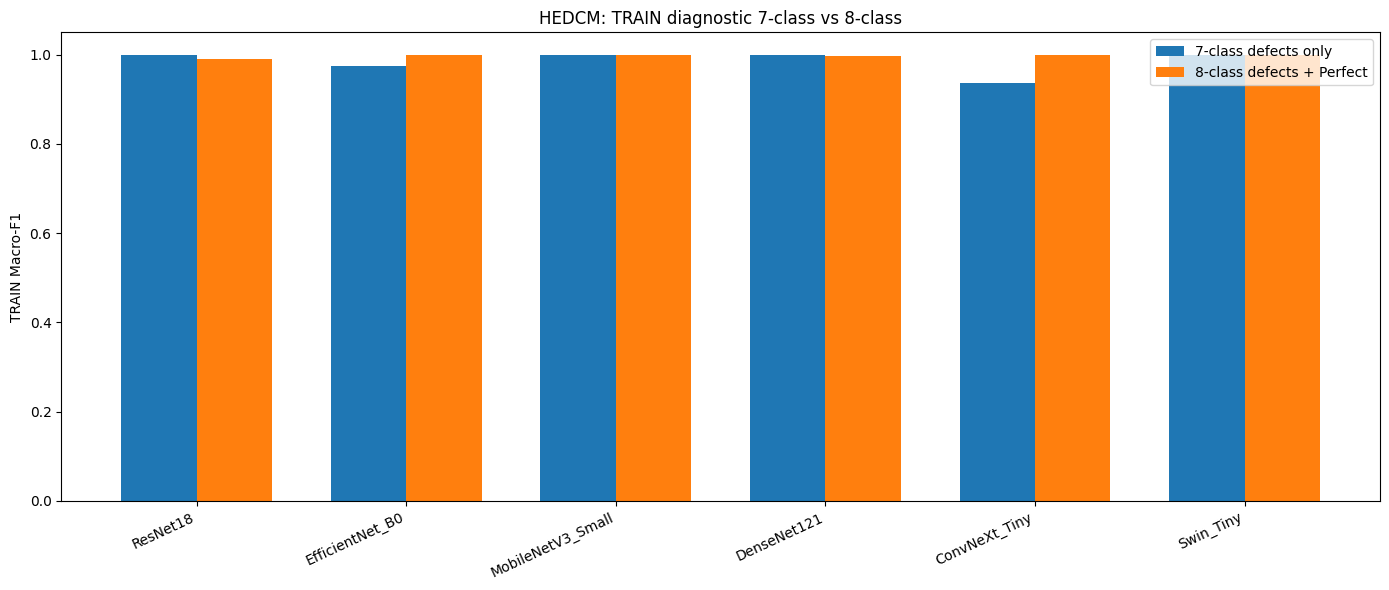

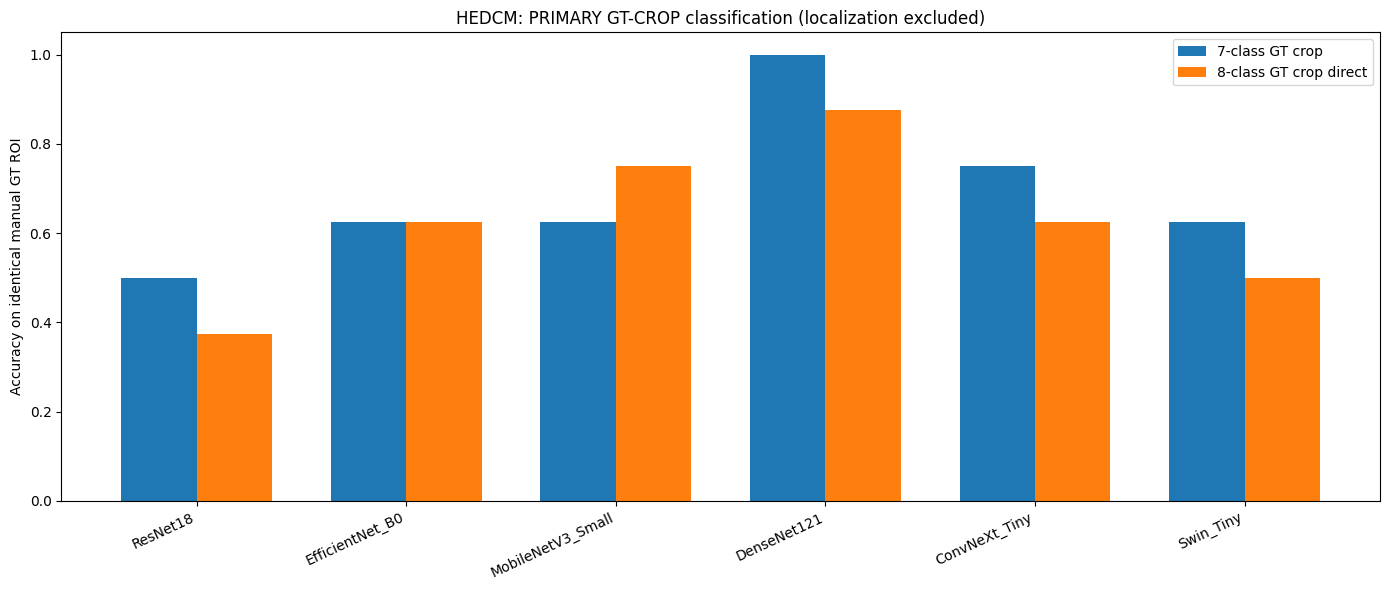

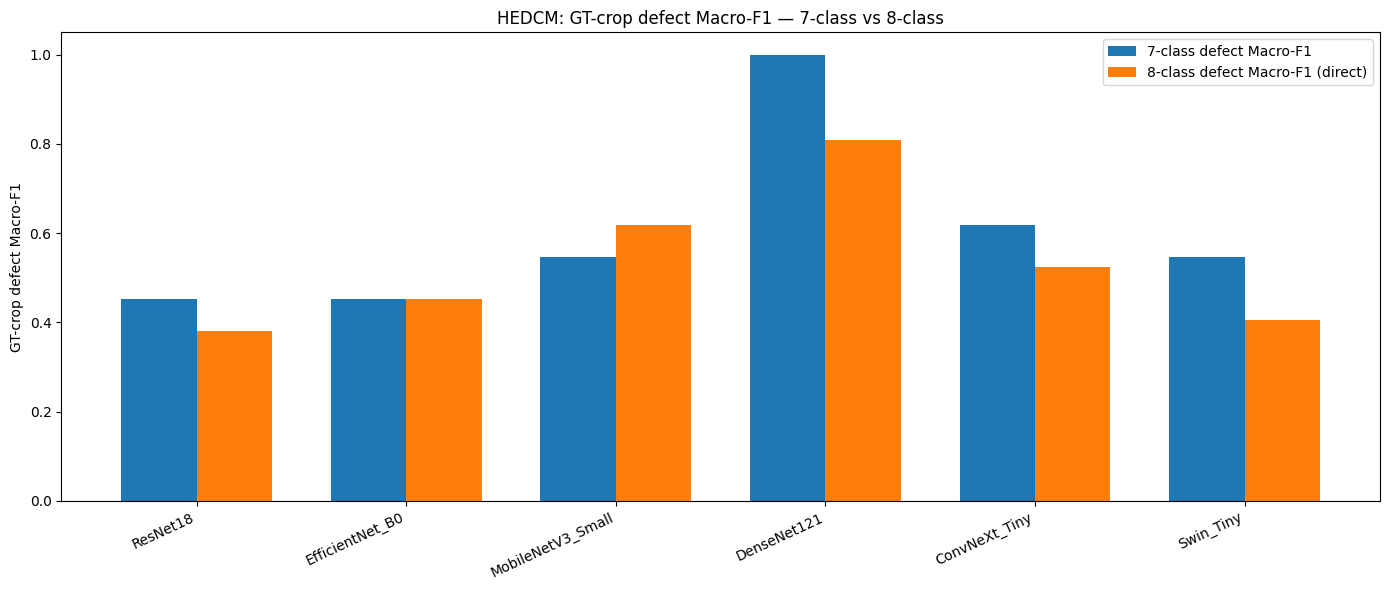

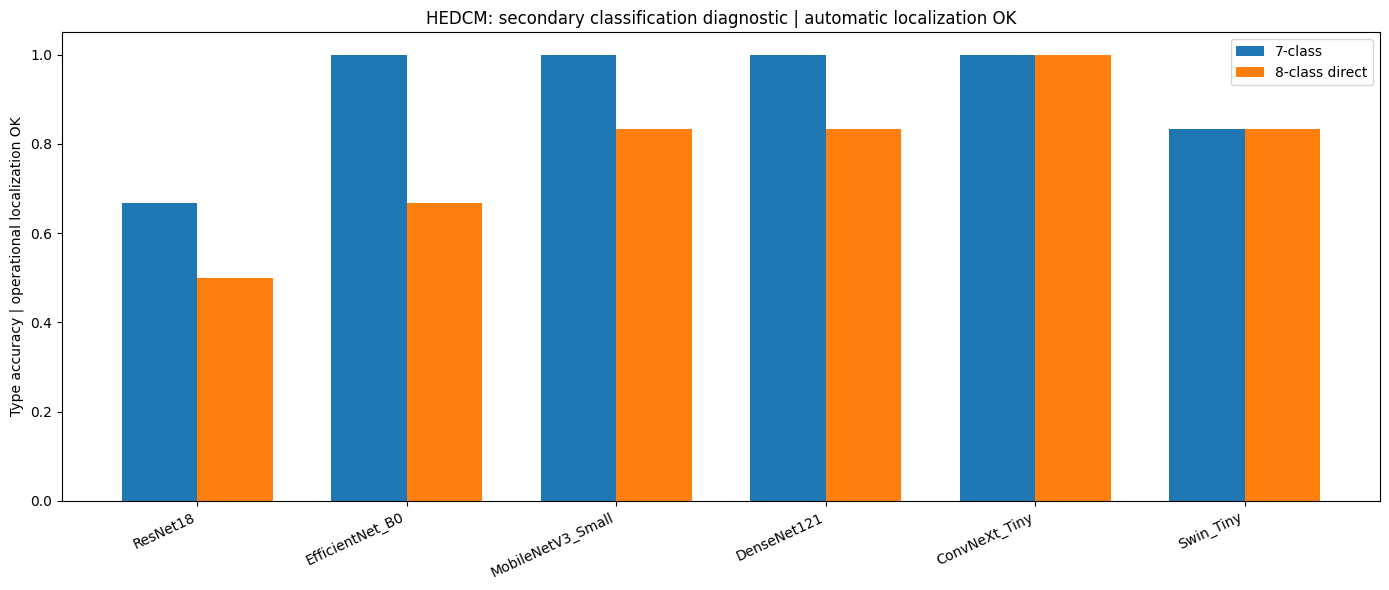

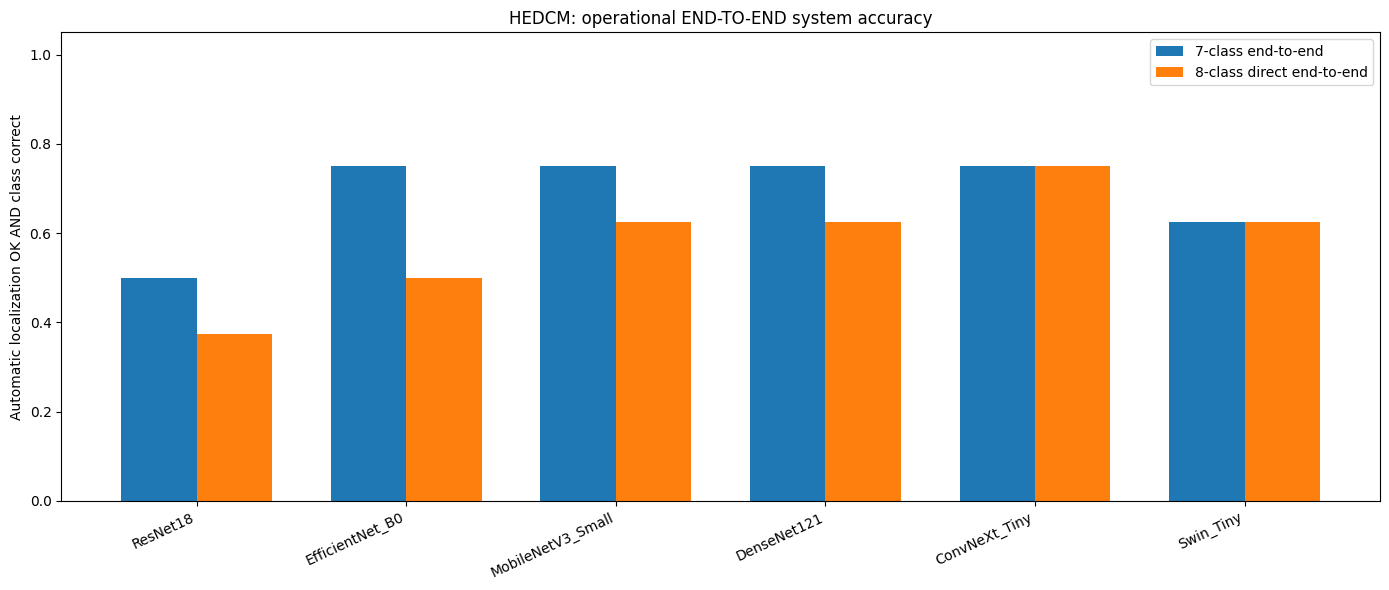

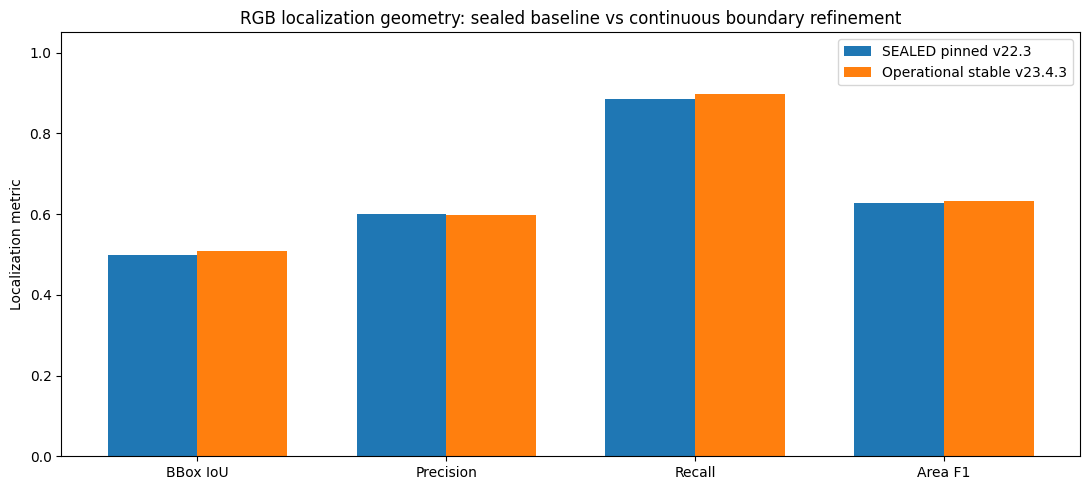


SCIENTIFIC NOTE:
Pinned v22.3 remains the official immutable baseline.
Operational source-canvas bbox is frozen to stable v23.4.3; H2.1 is diagnostic only.
PRIMARY HEDCM/filter comparison uses identical manual GT ROI and therefore excludes localization error.
SECONDARY END-TO-END uses the same automatic RGB v23.4.3 coordinates across all six representations.
Current TRAIN/VAL/TEST split is provisional unless SOURCE_INDEPENDENT_EVAL=True; final thesis rerun requires independent physical sources.


In [ ]:
# ============================================================
# 14. FINAL COMPARISON — PRIMARY GT-CROP CLASSIFICATION + SECONDARY E2E
# ============================================================
REPRESENTATION_SUMMARY_ROW=None

if (
    not POSTTRAIN_READY
    or COMPARE_7_VS_8.empty
    or LOCALIZATION_RESULTS.empty
):
    print("Final comparison not ready.")
else:
    d=LOCALIZATION_RESULTS[
        LOCALIZATION_RESULTS["source_class"]!="Perfect"
    ].copy()
    p=LOCALIZATION_RESULTS[
        LOCALIZATION_RESULTS["source_class"]=="Perfect"
    ].copy()

    train7=float(COMPARE_7_VS_8["train_f1_7class"].mean())
    train8=float(COMPARE_7_VS_8["train_f1_8class"].mean())

    gt_crop7=float(COMPARE_7_VS_8["gt_crop_acc_7class"].mean())
    gt_crop8=float(COMPARE_7_VS_8["gt_crop_acc_8class_direct"].mean())
    gt_crop8c=float(COMPARE_7_VS_8["gt_crop_acc_8class_conditional"].mean())
    gt_crop_bal7=float(COMPARE_7_VS_8["gt_crop_balanced_acc_7class"].mean())
    gt_crop_bal8=float(COMPARE_7_VS_8["gt_crop_balanced_acc_8class_direct_defects_only"].mean())
    gt_crop_bal8c=float(COMPARE_7_VS_8["gt_crop_balanced_acc_8class_conditional_defects_only"].mean())
    gt_crop_f1_7=float(COMPARE_7_VS_8["gt_crop_macro_f1_7class"].mean())
    gt_crop_f1_8=float(COMPARE_7_VS_8["gt_crop_macro_f1_8class_direct_defects_only"].mean())
    gt_crop_f1_8c=float(COMPARE_7_VS_8["gt_crop_macro_f1_8class_conditional_defects_only"].mean())

    cls7_ok=float(COMPARE_7_VS_8["type_acc_7class_when_localization_ok"].mean())
    cls8_ok=float(COMPARE_7_VS_8["type_acc_8class_direct_when_localization_ok"].mean())
    cls8c_ok=float(COMPARE_7_VS_8["type_acc_8class_conditional_when_localization_ok"].mean())

    e2e7=float(COMPARE_7_VS_8["end_to_end_acc_7class"].mean())
    e2e8=float(COMPARE_7_VS_8["end_to_end_acc_8class_direct"].mean())
    e2e8c=float(COMPARE_7_VS_8["end_to_end_acc_8class_conditional"].mean())
    perf8=float(COMPARE_7_VS_8["perfect_window_accuracy_8class"].mean())

    bbox_found_recall=float(d["bbox_detected"].mean())

    base_hist=float(d["gt_localization_hit_historical_v22_3"].astype(float).mean())
    base_modern=float(d["gt_localization_hit_modern_audit"].astype(float).mean())
    op_hist=float(d["gt_localization_hit_operational_historical"].astype(float).mean())
    op_modern=float(d["gt_localization_hit_operational_modern"].astype(float).mean())

    base_iou=float(d["bbox_iou"].mean())
    op_iou=float(d["bbox_iou_refined"].mean())
    base_precision=float(d["area_precision_vs_manual_bbox"].mean())
    op_precision=float(d["area_precision_refined"].mean())
    base_recall=float(d["area_recall_vs_manual_bbox"].mean())
    op_recall=float(d["area_recall_refined"].mean())
    base_f1=float(d["area_f1_vs_manual_bbox"].mean())
    op_f1=float(d["area_f1_refined"].mean())

    base_edge_cols=["left_error_px","top_error_px","right_error_px","bottom_error_px"]
    op_edge_cols=["left_error_px_refined","top_error_px_refined","right_error_px_refined","bottom_error_px_refined"]
    base_edge_mean=float(np.nanmean(d[base_edge_cols].to_numpy(dtype=float)))
    op_edge_mean=float(np.nanmean(d[op_edge_cols].to_numpy(dtype=float)))

    REPRESENTATION_SUMMARY_ROW={
        "version":VERSION,
        "notebook_version":NOTEBOOK_VERSION,
        "scientific_status":SCIENTIFIC_STATUS,
        "localizer_representation":"RGB",
        "classifier_representation":REPRESENTATION,

        "localizer_definition":"SEALED v22.3 baseline + frozen stable v23.4.3 multi-candidate continuous operational refiner",
        "selected_method":BEST_LOCALIZER_SETTINGS["method"],
        "selected_rgb_darkening":BEST_LOCALIZER_SETTINGS["darkening"],
        "classifier_darkening":CLASSIFIER_DARKENING,
        "selected_threshold":BEST_LOCALIZER_SETTINGS["threshold"],
        "selected_min_area_frac":BEST_LOCALIZER_SETTINGS["min_area_frac"],

        "boundary_refiner_version":BOUNDARY_REFINER_VERSION,
        "boundary_refiner_config_sha256":boundary_refiner_config_sha256(),
        "operational_bbox_mode":"continuous_refined" if USE_OPERATIONAL_REFINED_BBOX else "pinned_baseline",
        "refinement_applied_rate":float(d["refinement_applied"].astype(float).mean()),
        "boundary_completion_expanded_rate":float(d["boundary_completion_expanded"].astype(float).mean()),
        "operational_mode_pinned_rate":float((d["refinement_mode"].astype(str)=="pinned").mean()),
        "operational_mode_shrink_rate":float(d["refinement_mode"].astype(str).str.startswith("shrink_").mean()),
        "operational_mode_completion_rate":float((d["refinement_mode"].astype(str)=="completion").mean()),
        "operational_mode_completion_then_shrink_rate":float((d["refinement_mode"].astype(str)=="completion_then_shrink").mean()),

        "historical_v22_3_hit_bbox_iou_min":V223_HIST_HIT_MIN_BBOX_IOU,
        "historical_v22_3_hit_area_recall_min":V223_HIST_HIT_MIN_AREA_RECALL,
        "modern_audit_bbox_iou_min":MODERN_AUDIT_MIN_BBOX_IOU,
        "modern_audit_area_recall_min":MODERN_AUDIT_MIN_AREA_RECALL,
        "modern_audit_area_precision_min":MODERN_AUDIT_MIN_AREA_PRECISION,

        "bbox_found_recall_operational":bbox_found_recall,

        # Official sealed baseline metrics.
        "baseline_hit_recall_historical_v22_3":base_hist,
        "baseline_hit_recall_modern_audit":base_modern,
        "baseline_mean_bbox_iou":base_iou,
        "baseline_mean_area_precision":base_precision,
        "baseline_mean_area_recall":base_recall,
        "baseline_mean_area_f1":base_f1,
        "baseline_mean_boundary_error_px":base_edge_mean,

        # Operational refined metrics.
        "operational_hit_recall_historical":op_hist,
        "operational_hit_recall_modern":op_modern,
        "operational_mean_bbox_iou":op_iou,
        "operational_mean_area_precision":op_precision,
        "operational_mean_area_recall":op_recall,
        "operational_mean_area_f1":op_f1,
        "operational_mean_boundary_error_px":op_edge_mean,

        # Explicit deltas.
        "delta_operational_minus_baseline_bbox_iou":op_iou-base_iou,
        "delta_operational_minus_baseline_precision":op_precision-base_precision,
        "delta_operational_minus_baseline_recall":op_recall-base_recall,
        "delta_operational_minus_baseline_area_f1":op_f1-base_f1,

        # Backward-compatible baseline aliases.
        "strict_gt_localization_hit_recall":base_hist,
        "strict_gt_localization_hit_recall_historical_v22_3":base_hist,
        "strict_gt_localization_hit_recall_modern_audit":base_modern,
        "localizer_mean_bbox_iou":base_iou,
        "localizer_mean_area_precision":base_precision,
        "localizer_mean_area_recall":base_recall,
        "localizer_mean_area_f1":base_f1,
        "localizer_mean_boundary_error_px":base_edge_mean,

        "frozen_v22_3_run_name":FROZEN_V223_RUN_NAME,
        "frozen_v22_3_archive_sha256":FROZEN_V223_ARCHIVE_SHA256,
        "perfect_false_regions":int((p["localizer_result"]=="Defect").sum()),
        "perfect_false_area_fraction":float(p["pred_area_fraction_refined"].mean()),

        "mean_train_f1_7class":train7,
        "mean_train_f1_8class":train8,
        "delta_mean_train_f1_8_minus_7":train8-train7,

        # PRIMARY representation/classifier experiment — localization excluded.
        "mean_gt_crop_acc_7class":gt_crop7,
        "mean_gt_crop_acc_8class_direct":gt_crop8,
        "mean_gt_crop_acc_8class_conditional":gt_crop8c,
        "delta_gt_crop_direct_8_minus_7":gt_crop8-gt_crop7,
        "mean_gt_crop_balanced_acc_7class":gt_crop_bal7,
        "mean_gt_crop_balanced_acc_8class_direct_defects_only":gt_crop_bal8,
        "mean_gt_crop_balanced_acc_8class_conditional_defects_only":gt_crop_bal8c,
        "mean_gt_crop_macro_f1_7class":gt_crop_f1_7,
        "mean_gt_crop_macro_f1_8class_direct_defects_only":gt_crop_f1_8,
        "mean_gt_crop_macro_f1_8class_conditional_defects_only":gt_crop_f1_8c,
        "delta_gt_crop_macro_f1_direct_8_minus_7":gt_crop_f1_8-gt_crop_f1_7,

        # Secondary diagnostic only where automatic localization is already OK.
        "mean_type_acc_7class_when_localization_ok":cls7_ok,
        "mean_type_acc_8class_direct_when_localization_ok":cls8_ok,
        "mean_type_acc_8class_conditional_when_localization_ok":cls8c_ok,

        "mean_end_to_end_acc_7class":e2e7,
        "mean_end_to_end_acc_8class_direct":e2e8,
        "mean_end_to_end_acc_8class_conditional":e2e8c,
        "delta_end_to_end_direct_8_minus_7":e2e8-e2e7,
        "mean_perfect_window_accuracy_8class":perf8,
    }

    print("="*165)
    print(
        "SEALED v22.3 BASELINE + CONTINUOUS BOUNDARY REFINER "
        f"-> {REPRESENTATION} CLASSIFIER | 7-class VS 8-class"
    )
    print("="*165)
    print(COMPARE_7_VS_8.to_string(index=False))

    print("\nLOCALIZATION BASELINE -> OPERATIONAL:")
    print(f" Historical hit recall: {base_hist:.4f} -> {op_hist:.4f}")
    print(f" Modern-audit hit recall: {base_modern:.4f} -> {op_modern:.4f}")
    print(f" Mean bbox IoU: {base_iou:.4f} -> {op_iou:.4f}")
    print(f" Mean precision: {base_precision:.4f} -> {op_precision:.4f}")
    print(f" Mean recall: {base_recall:.4f} -> {op_recall:.4f}")
    print(f" Mean area F1: {base_f1:.4f} -> {op_f1:.4f}")
    print(f" Mean boundary error px: {base_edge_mean:.2f} -> {op_edge_mean:.2f}")

    print("\nSUMMARY:")
    for k,v in REPRESENTATION_SUMMARY_ROW.items():
        print(f"{k}: {v}")

    x=np.arange(len(COMPARE_7_VS_8))
    width=.36

    plt.figure(figsize=(14,6))
    plt.bar(x-width/2,COMPARE_7_VS_8["train_f1_7class"],width,label="7-class defects only")
    plt.bar(x+width/2,COMPARE_7_VS_8["train_f1_8class"],width,label="8-class defects + Perfect")
    plt.xticks(x,COMPARE_7_VS_8["model"],rotation=25,ha="right")
    plt.ylim(0,1.05)
    plt.ylabel("TRAIN Macro-F1")
    plt.title(f"{REPRESENTATION}: TRAIN diagnostic 7-class vs 8-class")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14,6))
    plt.bar(x-width/2,COMPARE_7_VS_8["gt_crop_acc_7class"],width,label="7-class GT crop")
    plt.bar(x+width/2,COMPARE_7_VS_8["gt_crop_acc_8class_direct"],width,label="8-class GT crop direct")
    plt.xticks(x,COMPARE_7_VS_8["model"],rotation=25,ha="right")
    plt.ylim(0,1.05)
    plt.ylabel("Accuracy on identical manual GT ROI")
    plt.title(f"{REPRESENTATION}: PRIMARY GT-CROP classification (localization excluded)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14,6))
    plt.bar(x-width/2,COMPARE_7_VS_8["gt_crop_macro_f1_7class"],width,label="7-class defect Macro-F1")
    plt.bar(x+width/2,COMPARE_7_VS_8["gt_crop_macro_f1_8class_direct_defects_only"],width,label="8-class defect Macro-F1 (direct)")
    plt.xticks(x,COMPARE_7_VS_8["model"],rotation=25,ha="right")
    plt.ylim(0,1.05)
    plt.ylabel("GT-crop defect Macro-F1")
    plt.title(f"{REPRESENTATION}: GT-crop defect Macro-F1 — 7-class vs 8-class")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14,6))
    plt.bar(x-width/2,COMPARE_7_VS_8["type_acc_7class_when_localization_ok"],width,label="7-class")
    plt.bar(x+width/2,COMPARE_7_VS_8["type_acc_8class_direct_when_localization_ok"],width,label="8-class direct")
    plt.xticks(x,COMPARE_7_VS_8["model"],rotation=25,ha="right")
    plt.ylim(0,1.05)
    plt.ylabel("Type accuracy | operational localization OK")
    plt.title(f"{REPRESENTATION}: secondary classification diagnostic | automatic localization OK")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14,6))
    plt.bar(x-width/2,COMPARE_7_VS_8["end_to_end_acc_7class"],width,label="7-class end-to-end")
    plt.bar(x+width/2,COMPARE_7_VS_8["end_to_end_acc_8class_direct"],width,label="8-class direct end-to-end")
    plt.xticks(x,COMPARE_7_VS_8["model"],rotation=25,ha="right")
    plt.ylim(0,1.05)
    plt.ylabel("Automatic localization OK AND class correct")
    plt.title(f"{REPRESENTATION}: operational END-TO-END system accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    labels=["BBox IoU","Precision","Recall","Area F1"]
    base_vals=[base_iou,base_precision,base_recall,base_f1]
    op_vals=[op_iou,op_precision,op_recall,op_f1]
    xx=np.arange(len(labels))
    plt.figure(figsize=(11,5))
    plt.bar(xx-width/2,base_vals,width,label="SEALED pinned v22.3")
    plt.bar(xx+width/2,op_vals,width,label="Operational stable v23.4.3")
    plt.xticks(xx,labels)
    plt.ylim(0,1.05)
    plt.ylabel("Localization metric")
    plt.title("RGB localization geometry: sealed baseline vs continuous boundary refinement")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nSCIENTIFIC NOTE:")
    print("Pinned v22.3 remains the official immutable baseline.")
    print("Operational source-canvas bbox is frozen to stable v23.4.3; H2.1 is diagnostic only.")
    print("PRIMARY HEDCM/filter comparison uses identical manual GT ROI and therefore excludes localization error.")
    print("SECONDARY END-TO-END uses the same automatic RGB v23.4.3 coordinates across all six representations.")
    print("Current TRAIN/VAL/TEST split is provisional unless SOURCE_INDEPENDENT_EVAL=True; final thesis rerun requires independent physical sources.")


In [ ]:
# ============================================================
# 15. SAVE RESULTS + GLOBAL CROSS-FILTER SUMMARY — SEALED BASELINE + OPERATIONAL REFINED RGB
# ============================================================
if (
    not POSTTRAIN_READY
    or REPRESENTATION_SUMMARY_ROW is None
    or "LOCALIZED_CLASSIFICATION" not in globals()
):
    print(
        "Report not saved — complete cells 10-14 first."
    )
else:
    stamp=datetime.now().strftime(
        "%Y%m%d_%H%M%S"
    )
    report_dir=REPORT_ROOT/f"run_{stamp}"
    collage_dir=report_dir/"collages"
    report_dir.mkdir(
        parents=True,exist_ok=True
    )
    collage_dir.mkdir(
        parents=True,exist_ok=True
    )

    TRAIN_SUMMARY.to_csv(
        report_dir/
        "01_TRAIN_SUMMARY_7_AND_8_CLASS.csv",
        index=False
    )
    LOCALIZER_GRID.to_csv(
        report_dir/
        "02_SHARED_RGB_COLOR_TEXTURE_LOCALIZER_CALIBRATION_GRID.csv",
        index=False
    )
    LOCALIZER_METHOD_BEST.to_csv(
        report_dir/
        "03_RGB_COLOR_TEXTURE_LOCALIZER_BEST_BY_METHOD.csv",
        index=False
    )
    LOCALIZER_DARKENING_BEST.to_csv(
        report_dir/
        "04_RGB_COLOR_TEXTURE_LOCALIZER_BEST_BY_DARKENING.csv",
        index=False
    )
    LOCALIZATION_RESULTS.to_csv(
        report_dir/
        "05_RGB_LOCALIZATION_FULL_CANVAS.csv",
        index=False
    )
    if SHARED_LOCALIZATION_REFINED_PATH.exists():
        shutil.copy2(
            SHARED_LOCALIZATION_REFINED_PATH,
            report_dir/"05A_SHARED_RGB_OPERATIONAL_REFINED_BBOX.csv"
        )
    if SHARED_REFINER_READY_PATH.exists():
        shutil.copy2(
            SHARED_REFINER_READY_PATH,
            report_dir/"05B_SHARED_RGB_OPERATIONAL_REFINER_READY.json"
        )
    GT_CROP_CLASSIFICATION.to_csv(
        report_dir/
        "06A_GT_CROP_CLASSIFICATION_PREDICTIONS.csv",
        index=False
    )
    GT_CROP_MODEL_SUMMARY.to_csv(
        report_dir/
        "06B_GT_CROP_MODEL_SUMMARY.csv",
        index=False
    )
    GT_CROP_PER_CLASS_METRICS.to_csv(
        report_dir/
        "06D_GT_CROP_PER_CLASS_METRICS.csv",
        index=False
    )
    LOCALIZED_CLASSIFICATION.to_csv(
        report_dir/
        "06C_OPERATIONAL_E2E_7CLASS_VS_8CLASS_PREDICTIONS.csv",
        index=False
    )
    PERFECT_8CLASS.to_csv(
        report_dir/
        "07_PERFECT_8CLASS_WINDOW_CHECK.csv",
        index=False
    )
    COMPARE_7_VS_8.to_csv(
        report_dir/
        "08_MODEL_COMPARISON_7CLASS_VS_8CLASS.csv",
        index=False
    )
    pd.DataFrame(
        [REPRESENTATION_SUMMARY_ROW]
    ).to_csv(
        report_dir/
        "09_REPRESENTATION_SUMMARY.csv",
        index=False
    )

    config={
        "version":VERSION,
        "notebook_version": NOTEBOOK_VERSION,
        "scientific_status":
            SCIENTIFIC_STATUS,
        "source_independent_eval": SOURCE_INDEPENDENT_EVAL,
        "split_protocol": SPLIT_PROTOCOL,
        "split_hash": SPLIT_HASH,
        "split_audit": SPLIT_INFO,
        "flops_policy": "fvcore estimate only; unsupported operators may be omitted; use latency/FPS/params alongside FLOPs",
        "localizer_representation":
            "RGB",
        "classifier_representation":
            REPRESENTATION,
        "training_recipe":
            TRAINING_RECIPE,

        "cnn_tasks":{
            "7class":
                "7 defect classes only",
            "8class":
                "7 defect classes + Perfect",
            "architectures":
                MODELS,
            "models_per_filter_per_task":
                len(MODELS),
            "total_models_per_filter":
                len(MODELS)*2,
        },

        "localizer":{
            "type":
                "pinned_archived_v22_3_rgb_predictions_no_recalibration",
            "method":
                "COLOR_TEXTURE_NORMAL",
            "color_features":[
                "Robust RX / Mahalanobis in Lab",
                "DeltaE CMC",
                "Perfect-normal color patch kNN",
            ],
            "texture_features":[
                "local variance",
                "gradient magnitude",
                "LBP entropy",
                "gradient orientation entropy",
                "Gabor orientation energies",
                "Perfect-normal texture patch kNN",
            ],
            "normal_material_reference":
                "Perfect RGB full canvas + Perfect RGB TRAIN patches",
            "geometry_paths":["compact","horiz","vert"],
            "bbox_tightening":"scientific baseline remains v22.3; operational bbox is frozen to stable v23.4.3 continuous multi-candidate refinement",
            "candidate_generation_rule":"historical v22.3 archive remains the sealed coarse proposal; stable v23.4.3 refines it without GT feedback",
            "score_weights":{
                "robust_rx":
                    LOCALIZER_W_RX,
                "deltaE_CMC":
                    LOCALIZER_W_DELTAE,
                "normal_color":
                    LOCALIZER_W_NORMAL_COLOR,
                "texture":
                    LOCALIZER_W_TEXTURE,
            },
            "historical_v22_3_hit_rule":{
                "bbox_iou_min":V223_HIST_HIT_MIN_BBOX_IOU,
                "area_recall_min":V223_HIST_HIT_MIN_AREA_RECALL,
                "logic":"AND",
            },
            "modern_audit_hit_rule":{
                "bbox_iou_min":MODERN_AUDIT_MIN_BBOX_IOU,
                "area_recall_min":MODERN_AUDIT_MIN_AREA_RECALL,
                "area_precision_min":MODERN_AUDIT_MIN_AREA_PRECISION,
                "logic":"AND",
            },
            "recall_floor":
                LOCALIZER_MIN_DEFECT_RECALL,
            "selected_settings":
                BEST_LOCALIZER_SETTINGS,
            "frozen_baseline": True,
            "pinned_run_name":FROZEN_V223_RUN_NAME,
            "archive_sha256":FROZEN_V223_ARCHIVE_SHA256,
            "recalibration_performed": False,
        },

        "boundary_refiner":{
            "version":BOUNDARY_REFINER_VERSION,
            "enabled":USE_OPERATIONAL_REFINED_BBOX,
            "config":boundary_refiner_config(),
            "config_sha256":boundary_refiner_config_sha256(),
            "method":"stable v23.4.3 multi-candidate continuous anomaly-energy refinement",
            "uses_binary_mask":False,
            "uses_morphology":False,
            "uses_extra_neural_model":False,
            "uses_manual_gt_for_selection":False,
            "shared_refined_bbox_path":str(SHARED_LOCALIZATION_REFINED_PATH),
            "video_energy_ema_alpha":VIDEO_ENERGY_EMA_ALPHA,
            "video_bbox_ema_alpha":VIDEO_BBOX_EMA_ALPHA,
            "video_bbox_hold_missing_frames":VIDEO_BBOX_HOLD_MISSING_FRAMES,
        },

        "fair_cross_filter_rule":{
            "primary_gt_crop":"ONE manual GT bbox per source canvas -> exact same physical ROI -> each target representation -> CNN",
            "secondary_e2e":"ONE shared automatic RGB v23.4.3 bbox -> exact same coordinates -> each target representation -> CNN",
        },
        "manual_gt_rule":
            "Manual GT is never used for automatic bbox selection; it is used only for localization audit and the separate primary GT-crop classification experiment",
        "classifier_darkening":
            CLASSIFIER_DARKENING,
        "darkening_levels":
            DARKEN_LEVELS,
        "cnn_crop_resize":{
            "primary_gt_crop":"exact manual bbox -> target representation -> direct 256x256",
            "secondary_e2e":"automatic RGB v23.4.3 bbox -> anomaly-ranked source crops -> target representation -> 256x256 -> mean probabilities",
        },
        "evaluation_tracks":{
            "primary":PRIMARY_CLASSIFICATION_PROTOCOL,
            "secondary":SECONDARY_END_TO_END_PROTOCOL,
            "operational_localizer_policy":OPERATIONAL_LOCALIZER_POLICY,
            "h21_status":H21_OPERATIONAL_STATUS,
            "final_thesis_mode":FINAL_THESIS_MODE,
        },
    }

    (
        report_dir/
        "PIPELINE_CONFIG_V23_5_5_FINAL_CNN_METRICS_STABLE_V2343.json"
    ).write_text(
        json.dumps(
            config,
            ensure_ascii=False,
            indent=2,
            default=str
        ),
        encoding="utf-8"
    )

    for cid in SOURCE_META:
        make_pipeline_collage(
            cid,
            save_path=
                collage_dir/
                f"PIPELINE_{cid}.png",
            show=False
        )

    pd.DataFrame(
        [REPRESENTATION_SUMMARY_ROW]
    ).to_csv(
        SUMMARY_ROOT/
        f"SUMMARY_{REPRESENTATION}_V23_5_5_FINAL_CNN.csv",
        index=False
    )
    COMPARE_7_VS_8.to_csv(
        SUMMARY_ROOT/
        f"COMPARE_7VS8_{REPRESENTATION}_V23_5_5_FINAL_CNN.csv",
        index=False
    )
    GT_CROP_MODEL_SUMMARY.to_csv(
        SUMMARY_ROOT/
        f"GT_CROP_MODEL_{REPRESENTATION}_V23_5_5_FINAL_CNN.csv",
        index=False
    )
    GT_CROP_PER_CLASS_METRICS.to_csv(
        SUMMARY_ROOT/
        f"GT_CROP_PER_CLASS_{REPRESENTATION}_V23_5_5_FINAL_CNN.csv",
        index=False
    )

    cur=pd.DataFrame(
        [REPRESENTATION_SUMMARY_ROW]
    )

    if GLOBAL_SUMMARY_PATH.exists():
        try:
            old=pd.read_csv(
                GLOBAL_SUMMARY_PATH
            )
            keycol=(
                "classifier_representation"
                if "classifier_representation"
                in old.columns
                else "representation"
            )
            old=old[
                old[keycol].astype(str)
                !=REPRESENTATION
            ]
            global_df=pd.concat(
                [old,cur],
                ignore_index=True,
                sort=False
            )
        except Exception:
            global_df=cur.copy()
    else:
        global_df=cur.copy()

    order=[
        "RGB",
        "Grayscale",
        "Viridis",
        "Inferno",
        "Turbo",
        "HEDCM",
    ]
    global_df["_order"]=(
        global_df[
            "classifier_representation"
        ].map(
            {
                n:i
                for i,n in enumerate(order)
            }
        ).fillna(999)
    )
    global_df=(
        global_df
        .sort_values("_order")
        .drop(columns="_order")
    )
    global_df.to_csv(
        GLOBAL_SUMMARY_PATH,
        index=False
    )

    # ------------------------------------------------------------
    # GLOBAL MODEL-LEVEL CROSS-FILTER MATRIX
    # One row = representation × architecture.
    # This is the main table for RGB/Gray/Viridis/Inferno/Turbo/HEDCM comparison.
    # ------------------------------------------------------------
    model_tables=[]
    for _rep in ["RGB","Grayscale","Viridis","Inferno","Turbo","HEDCM"]:
        _path=SUMMARY_ROOT/f"GT_CROP_MODEL_{_rep}_V23_5_5_FINAL_CNN.csv"
        if _path.exists():
            try:
                _df=pd.read_csv(_path)
                if len(_df):
                    model_tables.append(_df)
            except Exception as e:
                print("Cross-filter model summary read failed:",_path,repr(e))

    if model_tables:
        cross_model_df=pd.concat(model_tables,ignore_index=True,sort=False)
        cross_model_df["_rep_order"]=cross_model_df["classifier_representation"].map(
            {n:i for i,n in enumerate(["RGB","Grayscale","Viridis","Inferno","Turbo","HEDCM"])}
        ).fillna(999)
        cross_model_df["_model_order"]=cross_model_df["model"].map(
            {n:i for i,n in enumerate(MODELS)}
        ).fillna(999)
        cross_model_df=cross_model_df.sort_values(["_rep_order","_model_order"]).drop(
            columns=["_rep_order","_model_order"]
        )
        cross_model_df.to_csv(GLOBAL_MODEL_MATRIX_PATH,index=False)
        cross_model_df.to_csv(report_dir/"10_CROSS_FILTER_MODEL_MATRIX.csv",index=False)

        _rgb=cross_model_df[cross_model_df["classifier_representation"]=="RGB"].copy()
        if len(_rgb):
            _metrics=[
                "gt_crop_acc_7class",
                "gt_crop_acc_8class_direct",
                "gt_crop_macro_f1_7class",
                "gt_crop_macro_f1_8class_direct_defects_only",
                "perfect_window_accuracy_8class",
            ]
            _rgb=_rgb[["model"]+[m for m in _metrics if m in _rgb.columns]].copy()
            _rgb=_rgb.rename(columns={m:f"rgb_{m}" for m in _metrics if m in _rgb.columns})
            delta_df=cross_model_df.merge(_rgb,on="model",how="left")
            for _m in _metrics:
                _r=f"rgb_{_m}"
                if _m in delta_df.columns and _r in delta_df.columns:
                    delta_df[f"delta_vs_rgb__{_m}"]=delta_df[_m]-delta_df[_r]
            delta_df.to_csv(GLOBAL_DELTA_VS_RGB_PATH,index=False)
            delta_df.to_csv(report_dir/"11_CROSS_FILTER_DELTAS_VS_RGB.csv",index=False)

        _hed=cross_model_df[cross_model_df["classifier_representation"]=="HEDCM"].copy()
        _other=cross_model_df[cross_model_df["classifier_representation"]!="HEDCM"].copy()
        if len(_hed) and len(_other):
            _metrics=[
                "gt_crop_acc_7class",
                "gt_crop_acc_8class_direct",
                "gt_crop_macro_f1_7class",
                "gt_crop_macro_f1_8class_direct_defects_only",
                "perfect_window_accuracy_8class",
            ]
            _hedcols=["model"]+[m for m in _metrics if m in _hed.columns]
            _hed2=_hed[_hedcols].rename(columns={m:f"hedcm_{m}" for m in _metrics if m in _hed.columns})
            hedcmp=_other.merge(_hed2,on="model",how="left")
            for _m in _metrics:
                _h=f"hedcm_{_m}"
                if _m in hedcmp.columns and _h in hedcmp.columns:
                    hedcmp[f"delta_hedcm_minus_filter__{_m}"]=hedcmp[_h]-hedcmp[_m]
            hedcmp.to_csv(HEDCM_VS_FILTERS_PATH,index=False)
            hedcmp.to_csv(report_dir/"12_HEDCM_VS_OTHER_FILTERS.csv",index=False)

    print("="*150)
    print("REPORT SAVED — SEALED v22.3 BASELINE + OPERATIONAL CONTINUOUS REFINER")
    print("="*150)
    print("Report:",report_dir)
    print("Global:",GLOBAL_SUMMARY_PATH)
    print(
        "\nCROSS-FILTER SUMMARY — "
        "SAME SHARED RGB OPERATIONAL REFINED BBOX"
    )

    cols=[
        "classifier_representation",
        "selected_method",
        "selected_rgb_darkening",
        "bbox_found_recall",
        "strict_gt_localization_hit_recall_historical_v22_3",
        "strict_gt_localization_hit_recall_modern_audit",
        "localizer_mean_bbox_iou",
        "localizer_mean_area_f1",
        "localizer_mean_area_precision",
        "localizer_mean_area_recall",
        "operational_hit_recall_historical",
        "operational_hit_recall_modern",
        "operational_mean_bbox_iou",
        "operational_mean_area_f1",
        "operational_mean_area_precision",
        "operational_mean_area_recall",
        "delta_operational_minus_baseline_bbox_iou",
        "delta_operational_minus_baseline_area_f1",
        "perfect_false_regions",
        "mean_gt_crop_acc_7class",
        "mean_gt_crop_acc_8class_direct",
        "mean_gt_crop_macro_f1_7class",
        "mean_gt_crop_macro_f1_8class_direct_defects_only",
        "mean_gt_crop_macro_f1_8class_conditional_defects_only",
        "mean_perfect_window_accuracy_8class",
        "mean_type_acc_7class_when_localization_ok",
        "mean_type_acc_8class_direct_when_localization_ok",
        "mean_type_acc_8class_conditional_when_localization_ok",
        "mean_end_to_end_acc_7class",
        "mean_end_to_end_acc_8class_direct",
        "mean_end_to_end_acc_8class_conditional",
        "mean_perfect_window_accuracy_8class",
    ]
    print(
        global_df[
            [
                c
                for c in cols
                if c in global_df.columns
            ]
        ].to_string(index=False)
    )

    print("\nDONE.")
    print(
        "RED = manual Ground Truth only."
    )
    print("YELLOW = immutable SEALED v22.3 pinned bbox (baseline).")
    print("GREEN/CYAN = operational continuous-energy refined bbox.")
    print("RED = manual Ground Truth, evaluation only.")
    print("CNN receives ONLY the operational refined RGB crop.")
    print("The same operational bbox coordinates are used for all six target representations.")


/tmp/ipykernel_860/2573700881.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.95])


REPORT SAVED — SEALED v22.3 BASELINE + OPERATIONAL CONTINUOUS REFINER
Report: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/final_cnn_v23_5_5_gtcrop_macro_f1_e2e/HEDCM/run_20260922_074156
Global: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/summary_v23_5_5_final_cnn_metrics/ALL_REPRESENTATIONS_V23_5_5_FINAL_CNN.csv

CROSS-FILTER SUMMARY — SAME SHARED RGB OPERATIONAL REFINED BBOX
classifier_representation      selected_method selected_rgb_darkening  strict_gt_localization_hit_recall_historical_v22_3  strict_gt_localization_hit_recall_modern_audit  localizer_mean_bbox_iou  localizer_mean_area_f1  localizer_mean_area_precision  localizer_mean_area_recall  operational_hit_recall_historical  operational_hit_recall_modern  operational_mean_bbox_iou  operational_mean_area_f1  operational_mean_area_precision  operational_mean_area_recall  delta_operational_minus_baseline_bbox_iou  delta_operational_minus_baseline_area_f1  perfect_false_regions  mean_gt_crop_acc_7class  mean_gt_crop_acc_

## Запуск 23.5.5-FINAL-CNN-METRICS — HEDCM

- **RGB запускается первым**: он публикует stable v23.4.3 operational bbox для всех представлений.
- Затем запускаются Grayscale / Viridis / Inferno / Turbo / HEDCM.
- На каждом фильтре предусмотрено **12 CNN**: 6 архитектур × 2 задачи. По умолчанию полностью завершённые совместимые runs переиспользуются, отсутствующие модели обучаются; для абсолютно fresh серии установите `FRESH_RETRAIN_ALL=True`.
- Общий план серии: **6 представлений × 6 архитектур × 2 задачи = 72 обучения**.
- Главный результат по представлению: `GT_CROP_MODEL_SUMMARY` и TEST-метрики — manual bbox исключает ошибку локализации.
- Полную систему оценивать отдельно: `LOCALIZED_CLASSIFICATION` / end-to-end automatic bbox → CNN.
- `Perfect` входит только в 8-class задачу; бинарный `Perfect vs Any Defect` порог выбирается по VAL.
- H2.1 не используется как operational still-image bbox из-за сохранённой регрессии; код остаётся только для диагностического/экспериментального video proposal.
- Для рабочего запуска `FINAL_THESIS_MODE=False`. Для финальных диссертационных цифр после добавления независимых физических источников установить `FINAL_THESIS_MODE=True` и выполнить новый fresh rerun.

- Для GT-crop теперь сохраняются Accuracy, balanced accuracy и **Macro-F1 по 7 дефектным классам**.
- Для 8-class `Perfect` оценивается отдельно (`perfect_window_accuracy_8class`), а не как фиктивный класс без GT bbox.
- После каждого фильтра обновляется общая матрица `representation × architecture`; после HEDCM дополнительно создаётся таблица `HEDCM − other filter`.


In [ ]:
# ============================================================
# 16. ADD-ON — СРАВНЕНИЕ РАМОК: RGB vs ТЕКУЩИЙ ФИЛЬТР vs РУЧНАЯ GT
# v23.5.5 — ДОПОЛНЕНИЕ, НЕ ИЗМЕНЯЕТ ОБУЧЕНИЕ И OPERATIONAL E2E
#
# КРАСНАЯ  = ручная рамка GT (только аудит)
# ЖЁЛТАЯ   = RGB operational v23.4.3 (готовая shared рамка из RGB Colab)
# ГОЛУБАЯ  = независимая FULL-FRAME диагностическая рамка текущего фильтра
#
# ВАЖНО:
# - GT НИКОГДА не участвует в поиске filter bbox; используется только ПОСЛЕ поиска для метрик.
# - Filter bbox ищется на текущем REPRESENTATION по всему кадру.
# - Для нормализации фильтра строится отдельная normal-reference по Perfect,
#   пропущенному через ТО ЖЕ представление.
# - Существующие LOCALIZATION_RESULTS / CNN / отчёты не перезаписываются.
# ============================================================

from matplotlib.patches import Rectangle, Patch

if str(REPRESENTATION).upper() == "RGB":
    raise RuntimeError("Этот ADD-ON предназначен только для Grayscale / Viridis / Inferno / Turbo / HEDCM. RGB Colab не изменяем.")

if "BEST_LOCALIZER_SETTINGS" not in globals() or BEST_LOCALIZER_SETTINGS is None:
    raise RuntimeError("Сначала запустите ноутбук сверху вниз до cell 10/11: BEST_LOCALIZER_SETTINGS ещё не готов.")
if "LOCALIZATION_ARTIFACTS" not in globals() or not LOCALIZATION_ARTIFACTS:
    raise RuntimeError("Сначала запустите cell 11: нужна shared RGB operational рамка и manual GT.")

FILTER_BBOX_DIAGNOSTIC_VERSION = "23.5.5-ADDON-FILTER-FULLFRAME-BBOX-COMPARE-V1"
FILTER_BBOX_REPORT_DIR = REPORT_ROOT / "13_FILTER_BBOX_COMPARE_RGB_FILTER_MANUAL"
FILTER_BBOX_IMAGE_DIR = FILTER_BBOX_REPORT_DIR / "images"
FILTER_BBOX_REPORT_DIR.mkdir(parents=True, exist_ok=True)
FILTER_BBOX_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Отдельные кэши — не трогаем NORMAL_REFERENCE_CACHE и METHOD_MAP_CACHE основного RGB localizer.
FILTER_NORMAL_REFERENCE_CACHE = {}
FILTER_METHOD_MAP_CACHE = {}
FILTER_BBOX_DIAGNOSTIC_ARTIFACTS = {}

# Цвета matplotlib: ручная GT / RGB operational / текущий filter diagnostic.
FILTER_COMPARE_COLORS = {
    "manual": "red",
    "rgb": "gold",
    "filter": "deepskyblue",
}


def _fbx_filter_perfect_reference_images(dark_name):
    """Perfect reference -> common preprocessing -> CURRENT REPRESENTATION."""
    images=[]
    seen=set()

    # Полноразмерные Perfect source canvases.
    for cid in list(PERFECT_CANVAS_IDS):
        try:
            sp=str(SOURCE_META[cid]["source_path"])
        except Exception:
            continue
        if sp in seen or not Path(sp).exists():
            continue
        original=cv2.imread(sp,cv2.IMREAD_COLOR)
        if original is None:
            continue
        proc=homogenize_and_darken(original,DARKEN_LEVELS[dark_name])
        images.append(build_representation(proc))
        seen.add(sp)

    # Perfect TRAIN patches — тоже проходят ТО ЖЕ представление.
    pdir=RGB_TRAIN_DIR/"Perfect"
    if pdir.exists():
        files=sorted([
            p for p in pdir.rglob("*")
            if p.suffix.lower() in {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
        ])[:NORMAL_REFERENCE_PATCH_LIMIT]
        for p in files:
            sp=str(p)
            if sp in seen:
                continue
            im=cv2.imread(sp,cv2.IMREAD_COLOR)
            if im is None:
                continue
            proc=homogenize_and_darken(im,DARKEN_LEVELS[dark_name])
            images.append(build_representation(proc))
            seen.add(sp)

    if not images:
        raise RuntimeError("Нет Perfect изображений для filter-specific normal reference")
    return images


def _fbx_build_filter_normal_reference(dark_name):
    """Normal model, обученный только на Perfect в CURRENT REPRESENTATION."""
    key=("FILTER_NORMAL_REFERENCE",str(REPRESENTATION),str(dark_name))
    if key in FILTER_NORMAL_REFERENCE_CACHE:
        return FILTER_NORMAL_REFERENCE_CACHE[key]

    images=_fbx_filter_perfect_reference_images(dark_name)
    full=images[0]
    lab=_to_lab_float(full)
    pixels=lab.reshape(-1,3)

    rng=np.random.default_rng(SEED)
    n=min(NORMAL_REFERENCE_MAX_SAMPLES,len(pixels))
    ids=rng.choice(len(pixels),size=n,replace=False) if n<len(pixels) else np.arange(len(pixels))
    sample=pixels[ids]

    try:
        mcd=MinCovDet(
            support_fraction=MCD_SUPPORT_FRACTION,
            random_state=SEED
        ).fit(sample)
        location=mcd.location_.astype(np.float64)
        precision=mcd.precision_.astype(np.float64)
        fit_mode="MinCovDet"
    except Exception as e:
        location=np.median(sample,axis=0).astype(np.float64)
        cov=np.cov(sample.T)+np.eye(3)*1e-3
        precision=np.linalg.pinv(cov).astype(np.float64)
        fit_mode="robust_median_cov_fallback"
        print("Filter MCD fallback:",repr(e))

    rx_raw=np.log1p(_mahalanobis_sq(lab,location,precision))
    center=np.broadcast_to(location.astype(np.float32),lab.shape)
    de_raw=skcolor.deltaE_cmc(lab,center,kL=1,kC=1).astype(np.float32)

    all_color=[]
    all_texture=[]
    for im in images:
        _,c,t=_extract_window_features(im)
        if len(c):
            all_color.append(c)
            all_texture.append(t)

    color_bank=np.concatenate(all_color,axis=0)
    texture_bank=np.concatenate(all_texture,axis=0)
    if len(color_bank)>NORMAL_REFERENCE_MAX_WINDOWS:
        ids=rng.choice(len(color_bank),size=NORMAL_REFERENCE_MAX_WINDOWS,replace=False)
        color_bank=color_bank[ids]
        texture_bank=texture_bank[ids]

    cmed,cscale=_robust_center_scale(color_bank)
    tmed,tscale=_robust_center_scale(texture_bank)
    cz=_zscore(color_bank,cmed,cscale)
    tz=_zscore(texture_bank,tmed,tscale)

    k=min(NORMAL_KNN_K+1,len(cz))
    nn_color=NearestNeighbors(n_neighbors=max(2,k),metric="euclidean").fit(cz)
    nn_texture=NearestNeighbors(n_neighbors=max(2,k),metric="euclidean").fit(tz)
    cd=nn_color.kneighbors(cz,return_distance=True)[0]
    td=nn_texture.kneighbors(tz,return_distance=True)[0]
    cd_loo=cd[:,1:min(cd.shape[1],NORMAL_KNN_K+1)].mean(axis=1)
    td_loo=td[:,1:min(td.shape[1],NORMAL_KNN_K+1)].mean(axis=1)

    ref={
        "representation":REPRESENTATION,
        "darkening":dark_name,
        "fit_mode":fit_mode,
        "location_lab":location,
        "precision":precision,
        "perfect_rx_raw":rx_raw,
        "perfect_de_raw":de_raw,
        "color_med":cmed,
        "color_scale":cscale,
        "texture_med":tmed,
        "texture_scale":tscale,
        "nn_color":nn_color,
        "nn_texture":nn_texture,
        "color_distance_reference":cd_loo.astype(np.float32),
        "texture_distance_reference":td_loo.astype(np.float32),
        "normal_window_count":int(len(cz)),
        "perfect_reference_count":int(len(images)),
    }
    FILTER_NORMAL_REFERENCE_CACHE[key]=ref
    return ref


def _fbx_compute_filter_maps(original_bgr,dark_name):
    """ORIGINAL -> preprocessing -> CURRENT REPRESENTATION -> anomaly maps vs Perfect(filter)."""
    proc=homogenize_and_darken(original_bgr,DARKEN_LEVELS[dark_name])
    rep=build_representation(proc)
    lab=_to_lab_float(rep)
    ref=_fbx_build_filter_normal_reference(dark_name)

    rx_raw=np.log1p(_mahalanobis_sq(lab,ref["location_lab"],ref["precision"]))
    center=np.broadcast_to(ref["location_lab"].astype(np.float32),lab.shape)
    de_raw=skcolor.deltaE_cmc(lab,center,kL=1,kC=1).astype(np.float32)
    rx,rx_stats=_robust_scale_from_perfect(rx_raw,ref["perfect_rx_raw"])
    de,de_stats=_robust_scale_from_perfect(de_raw,ref["perfect_de_raw"])

    boxes,color,texture=_extract_window_features(rep)
    cz=_zscore(color,ref["color_med"],ref["color_scale"])
    tz=_zscore(texture,ref["texture_med"],ref["texture_scale"])
    kc=min(NORMAL_KNN_K,len(ref["color_distance_reference"]))
    kt=min(NORMAL_KNN_K,len(ref["texture_distance_reference"]))
    cdist=ref["nn_color"].kneighbors(cz,n_neighbors=max(1,kc),return_distance=True)[0].mean(axis=1)
    tdist=ref["nn_texture"].kneighbors(tz,n_neighbors=max(1,kt),return_distance=True)[0].mean(axis=1)
    cscore=_scale_knn_distance(cdist,ref["color_distance_reference"])
    tscore=_scale_knn_distance(tdist,ref["texture_distance_reference"])

    color_normal_map=_window_scores_to_map(rep.shape,boxes,cscore)
    texture_normal_map=_window_scores_to_map(rep.shape,boxes,tscore)
    rx_for_score=np.minimum(rx,2.5)
    de_for_score=np.minimum(de,2.5)
    combined=(
        LOCALIZER_W_RX*rx_for_score
        + LOCALIZER_W_DELTAE*de_for_score
        + LOCALIZER_W_NORMAL_COLOR*color_normal_map
        + LOCALIZER_W_TEXTURE*texture_normal_map
    ).astype(np.float32)

    return {
        "original":original_bgr,
        "filtered_view":rep,
        # compatibility with existing generic helpers
        "localizer_rgb":rep,
        "ROBUST_RX":rx.astype(np.float32),
        "DELTAE_CMC":de.astype(np.float32),
        "NORMAL_COLOR_KNN":color_normal_map.astype(np.float32),
        "NORMAL_TEXTURE_KNN":texture_normal_map.astype(np.float32),
        "COLOR_TEXTURE_NORMAL":combined,
        "rx_raw":rx_raw,
        "deltae_raw":de_raw,
        "rx_stats":rx_stats,
        "de_stats":de_stats,
        "filter_reference_fit_mode":ref["fit_mode"],
        "filter_normal_window_count":ref["normal_window_count"],
        "filter_perfect_reference_count":ref["perfect_reference_count"],
    }


def _fbx_safe_bbox(b):
    if b is None:
        return None
    try:
        z=tuple(map(int,b))
        return z if len(z)==4 else None
    except Exception:
        return None


def _fbx_center_error(a,b):
    a=_fbx_safe_bbox(a); b=_fbx_safe_bbox(b)
    if a is None or b is None:
        return np.nan
    ac=((a[0]+a[2])/2.0,(a[1]+a[3])/2.0)
    bc=((b[0]+b[2])/2.0,(b[1]+b[3])/2.0)
    return float(math.hypot(ac[0]-bc[0],ac[1]-bc[1]))


def _fbx_draw(ax,bbox,color,label,lw=3):
    bbox=_fbx_safe_bbox(bbox)
    if bbox is None:
        return
    x1,y1,x2,y2=bbox
    ax.add_patch(Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor=color,linewidth=lw))
    ax.text(
        x1,max(2,y1-6),label,
        color=color,fontsize=9,fontweight="bold",va="bottom",ha="left",
        bbox=dict(facecolor="black",alpha=0.62,edgecolor="none",pad=2)
    )


def _fbx_visualize(canvas_id,save=True,show=True):
    art=FILTER_BBOX_DIAGNOSTIC_ARTIFACTS[str(canvas_id)]
    original=art["original"]
    filtered=art["filtered"]
    manual_bbox=art["manual_bbox"]
    rgb_bbox=art["rgb_bbox"]
    filter_bbox=art["filter_bbox"]
    row=art["row"]

    original_rgb=cv2.cvtColor(original,cv2.COLOR_BGR2RGB)
    filtered_rgb=cv2.cvtColor(filtered,cv2.COLOR_BGR2RGB)

    fig,axs=plt.subplots(1,2,figsize=(18,7))
    for ax,img,title in [
        (axs[0],original_rgb,"Исходное RGB — сравнение местоположения рамок"),
        (axs[1],filtered_rgb,f"{REPRESENTATION} — сравнение тех же координат"),
    ]:
        ax.imshow(img)
        _fbx_draw(ax,manual_bbox,FILTER_COMPARE_COLORS["manual"],"Ручная GT")
        _fbx_draw(ax,rgb_bbox,FILTER_COMPARE_COLORS["rgb"],"RGB v23.4.3")
        _fbx_draw(ax,filter_bbox,FILTER_COMPARE_COLORS["filter"],f"{REPRESENTATION} FULL")
        ax.set_title(title,fontsize=11,fontweight="bold")
        ax.axis("off")

    legend=[
        Patch(facecolor="none",edgecolor=FILTER_COMPARE_COLORS["manual"],linewidth=3,label="Красная — ручная рамка GT"),
        Patch(facecolor="none",edgecolor=FILTER_COMPARE_COLORS["rgb"],linewidth=3,label="Жёлтая — RGB operational v23.4.3"),
        Patch(facecolor="none",edgecolor=FILTER_COMPARE_COLORS["filter"],linewidth=3,label=f"Голубая — {REPRESENTATION} full-frame diagnostic"),
    ]
    fig.legend(handles=legend,loc="lower center",ncol=3,fontsize=10,frameon=True)

    fig.suptitle(
        f"{canvas_id} | GT={row['source_class']} | "
        f"IoU RGB→GT={row['rgb_iou_vs_gt']:.3f} | "
        f"IoU {REPRESENTATION}→GT={row['filter_iou_vs_gt']:.3f} | "
        f"IoU RGB↔filter={row['rgb_filter_iou']:.3f}",
        fontsize=12,fontweight="bold",y=0.98
    )
    plt.tight_layout(rect=[0,0.08,1,0.94])

    if save:
        safe=str(canvas_id).replace("/","_").replace("\\","_")
        out=FILTER_BBOX_IMAGE_DIR/f"{REPRESENTATION}_{safe}_RGB_FILTER_GT.png"
        fig.savefig(out,dpi=160,bbox_inches="tight",pad_inches=0.08)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig


def run_filter_bbox_comparison(show=True):
    """Вычислить filter bbox без GT, затем сравнить с RGB operational и manual GT."""
    method=str(BEST_LOCALIZER_SETTINGS["method"])
    dark_name=str(BEST_LOCALIZER_SETTINGS["darkening"])
    threshold=float(BEST_LOCALIZER_SETTINGS["threshold"])
    min_area_frac=float(BEST_LOCALIZER_SETTINGS["min_area_frac"])

    # Одинаковый frozen threshold/min_area для всех фильтров.
    # GT НЕ используется для калибровки threshold.
    _fbx_build_filter_normal_reference(dark_name)
    rows=[]
    FILTER_BBOX_DIAGNOSTIC_ARTIFACTS.clear()

    for cid,m in SOURCE_META.items():
        cid=str(cid)
        original=cv2.imread(m["source_path"],cv2.IMREAD_COLOR)
        if original is None:
            raise RuntimeError(m["source_path"])

        key=(cid,str(REPRESENTATION),dark_name)
        if key not in FILTER_METHOD_MAP_CACHE:
            FILTER_METHOD_MAP_CACHE[key]=_fbx_compute_filter_maps(original,dark_name)
        fmaps=FILTER_METHOD_MAP_CACHE[key]

        # 1) FULL-FRAME independent filter search.
        coarse_region=extract_anomaly_region(fmaps,method,threshold,min_area_frac)
        coarse_bbox=_fbx_safe_bbox(coarse_region.get("bbox"))
        path_used=str(coarse_region.get("path_used","none"))

        # 2) Same stable v23.4.3 continuous refiner, but starting from FILTER proposal.
        if coarse_bbox is not None:
            filter_bbox,filter_refine_info=refine_bbox_continuous_only(
                fmaps,coarse_bbox,path_used,threshold
            )
            filter_bbox=_fbx_safe_bbox(filter_bbox)
        else:
            filter_bbox=None
            filter_refine_info={"applied":False,"mode":"no_filter_proposal"}

        base_art=LOCALIZATION_ARTIFACTS.get(cid,{})
        base_region=base_art.get("region",{}) if isinstance(base_art,dict) else {}
        rgb_bbox=_fbx_safe_bbox(
            base_region.get("bbox_operational")
            or base_region.get("bbox_refined")
            or base_region.get("bbox_pinned")
            or base_region.get("bbox")
        )
        manual_bbox=_fbx_safe_bbox(base_art.get("manual_bbox")) if isinstance(base_art,dict) else None
        perfect=(str(m["class_name"])=="Perfect")

        if (not perfect) and manual_bbox is None:
            ann=load_annotation(cid)
            manual_bbox=_fbx_safe_bbox(ann.get("bbox")) if ann else None

        if manual_bbox is not None:
            rgb_met=localization_metrics(rgb_bbox,manual_bbox,original.shape)
            fil_met=localization_metrics(filter_bbox,manual_bbox,original.shape)
        else:
            rgb_met={"bbox_iou":np.nan,"area_precision_vs_manual_bbox":np.nan,"area_recall_vs_manual_bbox":np.nan,"area_f1_vs_manual_bbox":np.nan}
            fil_met=dict(rgb_met)

        row={
            "diagnostic_version":FILTER_BBOX_DIAGNOSTIC_VERSION,
            "representation":REPRESENTATION,
            "canvas_id":cid,
            "source_class":str(m["class_name"]),
            "is_perfect":bool(perfect),
            "threshold_from_frozen_rgb_settings":threshold,
            "min_area_frac_from_frozen_rgb_settings":min_area_frac,
            "filter_normal_reference":"Perfect -> same representation",
            "manual_gt_used_for_filter_selection":False,
            "rgb_bbox_operational":json.dumps(rgb_bbox) if rgb_bbox is not None else "",
            "filter_bbox_fullframe":json.dumps(filter_bbox) if filter_bbox is not None else "",
            "manual_bbox_gt":json.dumps(manual_bbox) if manual_bbox is not None else "",
            "filter_coarse_bbox":json.dumps(coarse_bbox) if coarse_bbox is not None else "",
            "filter_path_used":path_used,
            "filter_refinement_applied":bool(filter_refine_info.get("applied",False)),
            "filter_refinement_mode":str(filter_refine_info.get("mode","")),
            "rgb_iou_vs_gt":float(rgb_met.get("bbox_iou",np.nan)),
            "rgb_precision_vs_gt":float(rgb_met.get("area_precision_vs_manual_bbox",np.nan)),
            "rgb_recall_vs_gt":float(rgb_met.get("area_recall_vs_manual_bbox",np.nan)),
            "rgb_f1_vs_gt":float(rgb_met.get("area_f1_vs_manual_bbox",np.nan)),
            "filter_iou_vs_gt":float(fil_met.get("bbox_iou",np.nan)),
            "filter_precision_vs_gt":float(fil_met.get("area_precision_vs_manual_bbox",np.nan)),
            "filter_recall_vs_gt":float(fil_met.get("area_recall_vs_manual_bbox",np.nan)),
            "filter_f1_vs_gt":float(fil_met.get("area_f1_vs_manual_bbox",np.nan)),
            "rgb_center_error_px":_fbx_center_error(rgb_bbox,manual_bbox),
            "filter_center_error_px":_fbx_center_error(filter_bbox,manual_bbox),
            "rgb_filter_iou":float(bbox_iou(rgb_bbox,filter_bbox)) if rgb_bbox is not None and filter_bbox is not None else 0.0,
            "rgb_filter_center_distance_px":_fbx_center_error(rgb_bbox,filter_bbox),
            "filter_bbox_detected":bool(filter_bbox is not None),
            "rgb_bbox_detected":bool(rgb_bbox is not None),
            "filter_false_positive_on_perfect":bool(perfect and filter_bbox is not None),
            "rgb_false_positive_on_perfect":bool(perfect and rgb_bbox is not None),
        }
        rows.append(row)
        FILTER_BBOX_DIAGNOSTIC_ARTIFACTS[cid]={
            "original":original,
            "filtered":fmaps["filtered_view"],
            "filter_maps":fmaps,
            "filter_region":coarse_region,
            "filter_refine_info":filter_refine_info,
            "filter_bbox":filter_bbox,
            "rgb_bbox":rgb_bbox,
            "manual_bbox":manual_bbox,
            "row":row,
        }

    global FILTER_BBOX_COMPARISON, FILTER_BBOX_COMPARISON_DEFECTS, FILTER_BBOX_COMPARISON_SUMMARY
    FILTER_BBOX_COMPARISON=pd.DataFrame(rows)
    FILTER_BBOX_COMPARISON_DEFECTS=FILTER_BBOX_COMPARISON[~FILTER_BBOX_COMPARISON["is_perfect"]].copy()

    # Сохраняем отдельный add-on CSV; существующие отчёты не перезаписываются.
    csv_path=FILTER_BBOX_REPORT_DIR/f"{REPRESENTATION}_RGB_FILTER_MANUAL_BBOX_COMPARISON.csv"
    FILTER_BBOX_COMPARISON.to_csv(csv_path,index=False)

    d=FILTER_BBOX_COMPARISON_DEFECTS
    p=FILTER_BBOX_COMPARISON[FILTER_BBOX_COMPARISON["is_perfect"]]
    summary={
        "representation":REPRESENTATION,
        "diagnostic_version":FILTER_BBOX_DIAGNOSTIC_VERSION,
        "defect_canvas_count":int(len(d)),
        "perfect_canvas_count":int(len(p)),
        "rgb_mean_iou_vs_gt":float(d["rgb_iou_vs_gt"].mean()) if len(d) else np.nan,
        "filter_mean_iou_vs_gt":float(d["filter_iou_vs_gt"].mean()) if len(d) else np.nan,
        "rgb_mean_f1_vs_gt":float(d["rgb_f1_vs_gt"].mean()) if len(d) else np.nan,
        "filter_mean_f1_vs_gt":float(d["filter_f1_vs_gt"].mean()) if len(d) else np.nan,
        "rgb_mean_center_error_px":float(d["rgb_center_error_px"].mean()) if len(d) else np.nan,
        "filter_mean_center_error_px":float(d["filter_center_error_px"].mean()) if len(d) else np.nan,
        "filter_better_iou_count":int((d["filter_iou_vs_gt"]>d["rgb_iou_vs_gt"]).sum()) if len(d) else 0,
        "rgb_better_iou_count":int((d["rgb_iou_vs_gt"]>d["filter_iou_vs_gt"]).sum()) if len(d) else 0,
        "equal_iou_count":int(np.isclose(d["rgb_iou_vs_gt"],d["filter_iou_vs_gt"],equal_nan=False).sum()) if len(d) else 0,
        "filter_false_positive_perfect":int(p["filter_false_positive_on_perfect"].sum()) if len(p) else 0,
        "rgb_false_positive_perfect":int(p["rgb_false_positive_on_perfect"].sum()) if len(p) else 0,
        "gt_used_for_detection":False,
        "note":"FILTER bbox = independent full-frame current representation diagnostic; RGB bbox = shared operational v23.4.3; Manual GT = audit only",
    }
    FILTER_BBOX_COMPARISON_SUMMARY=pd.DataFrame([summary])
    FILTER_BBOX_COMPARISON_SUMMARY.to_csv(
        FILTER_BBOX_REPORT_DIR/f"{REPRESENTATION}_RGB_FILTER_MANUAL_BBOX_SUMMARY.csv",
        index=False
    )

    print("="*150)
    print(f"СРАВНЕНИЕ РАМОК — {REPRESENTATION}")
    print("КРАСНАЯ = ручная GT | ЖЁЛТАЯ = RGB operational v23.4.3 | ГОЛУБАЯ = filter FULL-frame diagnostic")
    print("GT не используется для поиска filter bbox — только для последующего аудита.")
    print("="*150)
    display(FILTER_BBOX_COMPARISON_DEFECTS[[
        "canvas_id","source_class",
        "rgb_iou_vs_gt","filter_iou_vs_gt",
        "rgb_f1_vs_gt","filter_f1_vs_gt",
        "rgb_center_error_px","filter_center_error_px",
        "rgb_filter_iou","rgb_filter_center_distance_px",
        "filter_bbox_fullframe"
    ]])
    print("\nSUMMARY:")
    display(FILTER_BBOX_COMPARISON_SUMMARY)
    print("\nCSV:",csv_path)
    print("Images:",FILTER_BBOX_IMAGE_DIR)

    for cid in FILTER_BBOX_COMPARISON_DEFECTS["canvas_id"].astype(str):
        _fbx_visualize(cid,save=True,show=show)

    return FILTER_BBOX_COMPARISON


# Автозапуск add-on после полного запуска существующей 23.5.5.
FILTER_BBOX_COMPARISON = run_filter_bbox_comparison(show=True)


In [ ]:
# ============================================================
# 17. FINAL STRUCTURE-ONLY + SAFE CONSENSUS BBOX
# v23.5.5 ADD-ON — НЕ МЕНЯЕТ CNN, GT-CROP И RGB OPERATIONAL E2E
#
# ЦЕЛЬ:
# - оставить RGB operational v23.4.3 главным production bbox;
# - пересчитать вспомогательный bbox текущего фильтра БЕЗ цветовых признаков;
# - объединять RGB + filter только при геометрическом согласии;
# - Manual GT используется ТОЛЬКО ПОСЛЕ выбора bbox для аудита.
# ============================================================

import json, math
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from IPython.display import display

if str(REPRESENTATION).upper() == "RGB":
    raise RuntimeError("Эта ячейка предназначена для Grayscale / Viridis / Inferno / Turbo / HEDCM.")

if "FILTER_BBOX_COMPARISON" not in globals() or "FILTER_BBOX_DIAGNOSTIC_ARTIFACTS" not in globals():
    raise RuntimeError("Сначала запустите предыдущую ADD-ON ячейку v2355filterbboxcompare.")
if "BEST_LOCALIZER_SETTINGS" not in globals() or BEST_LOCALIZER_SETTINGS is None:
    raise RuntimeError("BEST_LOCALIZER_SETTINGS не найден — сначала запустите notebook сверху вниз.")

FINAL_CONSENSUS_VERSION = "23.5.5-STRUCTURE-ONLY-SAFE-CONSENSUS-V2"
FINAL_BBOX_DIR = REPORT_ROOT / "14_FINAL_CONSENSUS_LOCALIZATION"
FINAL_BBOX_DIR.mkdir(parents=True, exist_ok=True)

# Консервативные пороги. Они НЕ подбираются по manual GT.
CONSENSUS_STRONG_IOU = 0.75
CONSENSUS_MID_IOU = 0.45
CONSENSUS_WEAK_IOU = 0.30
CONSENSUS_MAX_CENTER_NORM = 0.15
CONSENSUS_AREA_RATIO_MIN = 0.40
CONSENSUS_AREA_RATIO_MAX = 2.50

STRUCT_MIN_AREA_FRAC = 0.0015
STRUCT_MAX_AREA_FRAC = 0.60
STRUCT_CORNER_TINY_MAX_FRAC = 0.020

STRUCTURE_ONLY_CACHE = {}


def _safe_bbox_v17(b):
    if b is None:
        return None
    try:
        z = tuple(map(int, b))
        if len(z) != 4 or z[2] <= z[0] or z[3] <= z[1]:
            return None
        return z
    except Exception:
        return None


def _bbox_area_v17(b):
    b = _safe_bbox_v17(b)
    if b is None:
        return 0.0
    return float(max(0, b[2]-b[0]) * max(0, b[3]-b[1]))


def _bbox_center_norm_v17(a, b, shape):
    a = _safe_bbox_v17(a); b = _safe_bbox_v17(b)
    if a is None or b is None:
        return np.inf
    h, w = shape[:2]
    ac = ((a[0]+a[2])/2.0, (a[1]+a[3])/2.0)
    bc = ((b[0]+b[2])/2.0, (b[1]+b[3])/2.0)
    return float(math.hypot(ac[0]-bc[0], ac[1]-bc[1]) / max(math.hypot(w, h), 1e-9))


def _clip_bbox_v17(b, shape):
    b = _safe_bbox_v17(b)
    if b is None:
        return None
    h, w = shape[:2]
    x1 = max(0, min(int(b[0]), w-1)); y1 = max(0, min(int(b[1]), h-1))
    x2 = max(x1+1, min(int(b[2]), w)); y2 = max(y1+1, min(int(b[3]), h))
    return (x1, y1, x2, y2)


def _weighted_bbox_v17(rgb_bbox, filter_bbox, shape, rgb_weight=0.65):
    r = _safe_bbox_v17(rgb_bbox); f = _safe_bbox_v17(filter_bbox)
    if r is None: return _clip_bbox_v17(f, shape)
    if f is None: return _clip_bbox_v17(r, shape)
    a = float(rgb_weight); b = 1.0-a
    out = tuple(int(round(a*r[i] + b*f[i])) for i in range(4))
    return _clip_bbox_v17(out, shape)


def _bounded_union_v17(rgb_bbox, filter_bbox, shape, max_expand_frac=0.20):
    """Union, но filter не может бесконтрольно раздувать RGB bbox."""
    r = _safe_bbox_v17(rgb_bbox); f = _safe_bbox_v17(filter_bbox)
    if r is None: return _clip_bbox_v17(f, shape)
    if f is None: return _clip_bbox_v17(r, shape)
    rw = max(1, r[2]-r[0]); rh = max(1, r[3]-r[1])
    mx = rw * float(max_expand_frac); my = rh * float(max_expand_frac)
    x1 = max(min(r[0], f[0]), int(round(r[0]-mx)))
    y1 = max(min(r[1], f[1]), int(round(r[1]-my)))
    x2 = min(max(r[2], f[2]), int(round(r[2]+mx)))
    y2 = min(max(r[3], f[3]), int(round(r[3]+my)))
    return _clip_bbox_v17((x1,y1,x2,y2), shape)


def _energy_in_bbox_v17(score_map, bbox):
    bbox = _safe_bbox_v17(bbox)
    if bbox is None or score_map is None:
        return 0.0
    h, w = score_map.shape[:2]
    x1,y1,x2,y2 = bbox
    x1=max(0,min(x1,w-1)); x2=max(x1+1,min(x2,w))
    y1=max(0,min(y1,h-1)); y2=max(y1+1,min(y2,h))
    roi=np.asarray(score_map[y1:y2,x1:x2], dtype=np.float32)
    return float(np.clip(roi,0,None).mean()) if roi.size else 0.0


def compute_structure_only_maps_v17(original_bgr, dark_name):
    """
    CURRENT REPRESENTATION, но локализация только по структуре:
    texture-kNN к Perfect + gradient magnitude.
    Цветовые MCD / DeltaE / color-kNN намеренно НЕ используются.
    """
    proc = homogenize_and_darken(original_bgr, DARKEN_LEVELS[dark_name])
    rep = build_representation(proc)
    ref = _fbx_build_filter_normal_reference(dark_name)

    boxes, _color, texture = _extract_window_features(rep)
    tz = _zscore(texture, ref["texture_med"], ref["texture_scale"])
    kt = min(NORMAL_KNN_K, len(ref["texture_distance_reference"]))
    tdist = ref["nn_texture"].kneighbors(
        tz, n_neighbors=max(1, kt), return_distance=True
    )[0].mean(axis=1)
    tscore = _scale_knn_distance(tdist, ref["texture_distance_reference"])
    texture_map = _window_scores_to_map(rep.shape, boxes, tscore).astype(np.float32)

    gray = cv2.cvtColor(rep, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    gm = cv2.magnitude(gx, gy)
    gm = cv2.GaussianBlur(gm, (0,0), sigmaX=max(2.0, min(gray.shape)/80.0))
    g50 = float(np.percentile(gm, 50))
    g95 = float(np.percentile(gm, 95))
    grad_score = np.clip((gm-g50) / max(g95-g50, 1e-6), 0, 3).astype(np.float32)

    # Структурная карта. Масштаб texture-kNN сохраняется, gradient лишь дополняет.
    combined = (0.72*texture_map + 0.28*grad_score).astype(np.float32)

    z = np.zeros_like(combined, dtype=np.float32)
    return {
        "original": original_bgr,
        "filtered_view": rep,
        "localizer_rgb": rep,
        "NORMAL_TEXTURE_KNN": texture_map,
        "GRADIENT_STRUCTURE": grad_score,
        "NORMAL_COLOR_KNN": z,
        "ROBUST_RX": z,
        "DELTAE_CMC": z,
        "COLOR_TEXTURE_NORMAL": combined,
    }


def _structure_bbox_v17(cid):
    art = FILTER_BBOX_DIAGNOSTIC_ARTIFACTS.get(str(cid))
    if art is None:
        return None, None, {"reason":"no_artifact"}
    original = art["original"]
    dark_name = str(BEST_LOCALIZER_SETTINGS["darkening"])
    threshold = float(BEST_LOCALIZER_SETTINGS["threshold"])
    min_area_frac = float(BEST_LOCALIZER_SETTINGS["min_area_frac"])

    key = (str(cid), str(REPRESENTATION), dark_name, "STRUCT_ONLY_V2")
    if key not in STRUCTURE_ONLY_CACHE:
        STRUCTURE_ONLY_CACHE[key] = compute_structure_only_maps_v17(original, dark_name)
    smaps = STRUCTURE_ONLY_CACHE[key]

    region = extract_anomaly_region(smaps, "COLOR_TEXTURE_NORMAL", threshold, min_area_frac)
    coarse = _safe_bbox_v17(region.get("bbox"))
    path_used = str(region.get("path_used", "none"))
    if coarse is None:
        return None, smaps, {"reason":"no_proposal", "path_used":path_used}

    refined, info = refine_bbox_continuous_only(smaps, coarse, path_used, threshold)
    bbox = _safe_bbox_v17(refined)
    if bbox is None:
        bbox = coarse
    return bbox, smaps, {"reason":"ok", "path_used":path_used, "refine":info}


def _struct_is_outlier_v17(bbox, shape):
    b = _safe_bbox_v17(bbox)
    if b is None:
        return True, "none"
    h,w = shape[:2]
    area_frac = _bbox_area_v17(b)/max(float(h*w),1.0)
    if area_frac < STRUCT_MIN_AREA_FRAC:
        return True, "too_small"
    if area_frac > STRUCT_MAX_AREA_FRAC:
        return True, "too_large"
    x1,y1,x2,y2=b
    corner = ((x1<=0.03*w or x2>=0.97*w) and (y1<=0.03*h or y2>=0.97*h))
    if corner and area_frac < STRUCT_CORNER_TINY_MAX_FRAC:
        return True, "tiny_corner"
    return False, "ok"


def choose_safe_consensus_v17(rgb_bbox, struct_bbox, struct_map, shape):
    """
    ВАЖНО: manual GT и GT class здесь НЕ используются.
    Решение только по RGB/filter геометрии и filter structural energy.
    """
    r = _clip_bbox_v17(rgb_bbox, shape)
    s = _clip_bbox_v17(struct_bbox, shape)
    if r is None and s is None:
        return None, "none", {}
    if r is None:
        outlier, reason = _struct_is_outlier_v17(s, shape)
        return (None if outlier else s), ("reject_struct_only_"+reason if outlier else "struct_only"), {}
    if s is None:
        return r, "rgb_only", {}

    outlier, outlier_reason = _struct_is_outlier_v17(s, shape)
    iou = float(bbox_iou(r,s))
    center_norm = _bbox_center_norm_v17(r,s,shape)
    ar = _bbox_area_v17(s)/max(_bbox_area_v17(r),1e-9)
    s_energy = _energy_in_bbox_v17(struct_map, s)
    r_energy = _energy_in_bbox_v17(struct_map, r)
    diag = {"rgb_struct_iou":iou,"center_norm":center_norm,"area_ratio":ar,
            "struct_energy":s_energy,"rgb_energy_on_struct_map":r_energy,
            "struct_outlier":bool(outlier),"struct_outlier_reason":outlier_reason}

    if outlier:
        return r, "rgb_anchor_struct_outlier", diag

    # Очень сильное согласие: мягкое взвешенное объединение, а не полный union.
    if iou >= CONSENSUS_STRONG_IOU and CONSENSUS_AREA_RATIO_MIN <= ar <= CONSENSUS_AREA_RATIO_MAX:
        return _weighted_bbox_v17(r,s,shape,0.65), "weighted_strong_agree", diag

    # Среднее согласие: разрешаем только ограниченное расширение RGB.
    if iou >= CONSENSUS_MID_IOU and center_norm <= CONSENSUS_MAX_CENTER_NORM and 0.45 <= ar <= 2.20:
        return _bounded_union_v17(r,s,shape,0.20), "bounded_union_mid_agree", diag

    # Слабое согласие: очень консервативное расширение, только если центры близко
    # и структурная энергия внутри filter-box не слабее RGB-area.
    if (iou >= CONSENSUS_WEAK_IOU and center_norm <= 0.12 and 0.55 <= ar <= 1.80
            and s_energy >= 0.95*r_energy):
        return _bounded_union_v17(r,s,shape,0.12), "bounded_union_weak_agree", diag

    # При расхождении всегда остаётся валидированный RGB anchor.
    return r, "rgb_anchor_disagree", diag


def _metrics_v17(pred, gt, shape):
    if gt is None:
        return {"bbox_iou":np.nan,"area_precision_vs_manual_bbox":np.nan,
                "area_recall_vs_manual_bbox":np.nan,"area_f1_vs_manual_bbox":np.nan}
    return localization_metrics(pred, gt, shape)


FINAL_ROWS=[]
FINAL_CONSENSUS_ARTIFACTS={}

for cid in FILTER_BBOX_COMPARISON["canvas_id"].astype(str):
    art = FILTER_BBOX_DIAGNOSTIC_ARTIFACTS.get(cid)
    if art is None:
        continue
    rgb_bbox = _safe_bbox_v17(art.get("rgb_bbox"))
    old_filter_bbox = _safe_bbox_v17(art.get("filter_bbox"))
    manual_bbox = _safe_bbox_v17(art.get("manual_bbox"))
    struct_bbox, struct_maps, struct_info = _structure_bbox_v17(cid)
    struct_score_map = struct_maps["COLOR_TEXTURE_NORMAL"] if struct_maps is not None else None
    final_bbox, final_mode, diag = choose_safe_consensus_v17(
        rgb_bbox, struct_bbox, struct_score_map, art["original"].shape
    )

    m_rgb = _metrics_v17(rgb_bbox, manual_bbox, art["original"].shape)
    m_old = _metrics_v17(old_filter_bbox, manual_bbox, art["original"].shape)
    m_struct = _metrics_v17(struct_bbox, manual_bbox, art["original"].shape)
    m_final = _metrics_v17(final_bbox, manual_bbox, art["original"].shape)

    is_perfect = bool(art["row"].get("is_perfect", False))
    FINAL_ROWS.append({
        "final_version": FINAL_CONSENSUS_VERSION,
        "representation": str(REPRESENTATION),
        "canvas_id": cid,
        "source_class": str(art["row"].get("source_class", "")),
        "is_perfect": is_perfect,
        "manual_gt_used_for_selection": False,
        "gt_class_used_for_selection": False,
        "rgb_bbox": json.dumps(rgb_bbox) if rgb_bbox else "",
        "filter_bbox_old": json.dumps(old_filter_bbox) if old_filter_bbox else "",
        "filter_bbox_structure": json.dumps(struct_bbox) if struct_bbox else "",
        "final_consensus_bbox": json.dumps(final_bbox) if final_bbox else "",
        "manual_bbox": json.dumps(manual_bbox) if manual_bbox else "",
        "final_mode": final_mode,
        "rgb_struct_iou": float(diag.get("rgb_struct_iou", 0.0)),
        "rgb_struct_center_norm": float(diag.get("center_norm", np.nan)),
        "rgb_struct_area_ratio": float(diag.get("area_ratio", np.nan)),
        "rgb_iou_vs_gt": float(m_rgb["bbox_iou"]),
        "filter_old_iou_vs_gt": float(m_old["bbox_iou"]),
        "filter_struct_iou_vs_gt": float(m_struct["bbox_iou"]),
        "final_iou_vs_gt": float(m_final["bbox_iou"]),
        "rgb_f1_vs_gt": float(m_rgb["area_f1_vs_manual_bbox"]),
        "filter_struct_f1_vs_gt": float(m_struct["area_f1_vs_manual_bbox"]),
        "final_f1_vs_gt": float(m_final["area_f1_vs_manual_bbox"]),
        "final_delta_iou_vs_rgb": float(m_final["bbox_iou"]-m_rgb["bbox_iou"]) if manual_bbox is not None else np.nan,
        "struct_reason": str(struct_info.get("reason","")),
    })
    FINAL_CONSENSUS_ARTIFACTS[cid]={**art,
        "filter_bbox_structure":struct_bbox,
        "filter_maps_structure":struct_maps,
        "final_consensus_bbox":final_bbox,
        "final_mode":final_mode,
        "consensus_diag":diag,
    }

FINAL_CONSENSUS_BBOX = pd.DataFrame(FINAL_ROWS)
FINAL_CONSENSUS_DEFECTS = FINAL_CONSENSUS_BBOX[~FINAL_CONSENSUS_BBOX["is_perfect"]].copy()
FINAL_CONSENSUS_PERFECT = FINAL_CONSENSUS_BBOX[FINAL_CONSENSUS_BBOX["is_perfect"]].copy()

RESULTS_CSV = FINAL_BBOX_DIR / f"{REPRESENTATION}_FINAL_CONSENSUS_BBOX_RESULTS.csv"
FINAL_CONSENSUS_BBOX.to_csv(RESULTS_CSV,index=False,encoding="utf-8-sig")

summary = pd.DataFrame([{
    "representation":str(REPRESENTATION),
    "version":FINAL_CONSENSUS_VERSION,
    "defect_count":int(len(FINAL_CONSENSUS_DEFECTS)),
    "perfect_count":int(len(FINAL_CONSENSUS_PERFECT)),
    "mean_iou_rgb":float(FINAL_CONSENSUS_DEFECTS["rgb_iou_vs_gt"].mean()),
    "mean_iou_filter_old":float(FINAL_CONSENSUS_DEFECTS["filter_old_iou_vs_gt"].mean()),
    "mean_iou_structure":float(FINAL_CONSENSUS_DEFECTS["filter_struct_iou_vs_gt"].mean()),
    "mean_iou_final":float(FINAL_CONSENSUS_DEFECTS["final_iou_vs_gt"].mean()),
    "mean_delta_final_vs_rgb":float(FINAL_CONSENSUS_DEFECTS["final_delta_iou_vs_rgb"].mean()),
    "final_improved_rgb_count":int((FINAL_CONSENSUS_DEFECTS["final_delta_iou_vs_rgb"]>=0.01).sum()),
    "final_worse_rgb_count":int((FINAL_CONSENSUS_DEFECTS["final_delta_iou_vs_rgb"]<=-0.01).sum()),
    "perfect_structure_false_positive_count":int(FINAL_CONSENSUS_PERFECT["filter_bbox_structure"].astype(str).str.len().gt(0).sum()) if len(FINAL_CONSENSUS_PERFECT) else 0,
    "selection_uses_manual_gt":False,
    "selection_uses_gt_class":False,
}])
SUMMARY_CSV = FINAL_BBOX_DIR / f"{REPRESENTATION}_FINAL_CONSENSUS_BBOX_SUMMARY.csv"
summary.to_csv(SUMMARY_CSV,index=False,encoding="utf-8-sig")


def _draw_bbox_v17(ax,b,color,label=None,lw=2.5,ls="-"):
    b=_safe_bbox_v17(b)
    if b is None: return
    x1,y1,x2,y2=b
    ax.add_patch(Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor=color,linewidth=lw,linestyle=ls))


def make_final_consolidated_dashboard_v17(save=True,show=True):
    d=FINAL_CONSENSUS_DEFECTS.copy()
    ids=list(d["canvas_id"].astype(str))
    n=len(ids)
    if n==0:
        print("Нет defect canvases для dashboard")
        return None
    cols=2
    rows=int(math.ceil(n/cols))
    fig,axes=plt.subplots(rows,cols,figsize=(18,4.8*rows))
    axes=np.array(axes).reshape(-1)
    for i,cid in enumerate(ids):
        ax=axes[i]
        art=FINAL_CONSENSUS_ARTIFACTS[cid]
        ax.imshow(cv2.cvtColor(art["original"],cv2.COLOR_BGR2RGB))
        _draw_bbox_v17(ax,art.get("manual_bbox"),"red",lw=3)
        _draw_bbox_v17(ax,art.get("rgb_bbox"),"gold",lw=3)
        _draw_bbox_v17(ax,art.get("filter_bbox"),"deepskyblue",lw=2)
        _draw_bbox_v17(ax,art.get("filter_bbox_structure"),"magenta",lw=2.5)
        _draw_bbox_v17(ax,art.get("final_consensus_bbox"),"lime",lw=3,ls="--")
        r=d[d["canvas_id"]==cid].iloc[0]
        ax.set_title(
            f"{cid} | GT={r['source_class']}\n"
            f"RGB={r['rgb_iou_vs_gt']:.3f} | OLD={r['filter_old_iou_vs_gt']:.3f} | "
            f"STRUCT={r['filter_struct_iou_vs_gt']:.3f} | FINAL={r['final_iou_vs_gt']:.3f}\n"
            f"{r['final_mode']} | ΔFINAL-RGB={r['final_delta_iou_vs_rgb']:+.3f}",
            fontsize=10,fontweight="bold")
        ax.axis("off")
    for j in range(n,len(axes)):
        axes[j].axis("off")
    legend=[
        Patch(facecolor="none",edgecolor="red",lw=3,label="Красная — ручная GT (только аудит)"),
        Patch(facecolor="none",edgecolor="gold",lw=3,label="Жёлтая — RGB operational v23.4.3"),
        Patch(facecolor="none",edgecolor="deepskyblue",lw=2,label=f"Голубая — {REPRESENTATION} old full-frame"),
        Patch(facecolor="none",edgecolor="magenta",lw=2.5,label=f"Малиновая — {REPRESENTATION} structure-only"),
        Patch(facecolor="none",edgecolor="lime",lw=3,label="Зелёный пунктир — FINAL safe consensus"),
    ]
    fig.legend(handles=legend,loc="lower center",ncol=3,fontsize=10,frameon=True)
    s=summary.iloc[0]
    fig.suptitle(
        f"FINAL LOCALIZATION DASHBOARD — {REPRESENTATION}\n"
        f"mean IoU: RGB={s['mean_iou_rgb']:.3f} | OLD={s['mean_iou_filter_old']:.3f} | "
        f"STRUCT={s['mean_iou_structure']:.3f} | FINAL={s['mean_iou_final']:.3f}",
        fontsize=15,fontweight="bold",y=0.995)
    plt.tight_layout(rect=[0,0.055,1,0.95])
    out=FINAL_BBOX_DIR/f"{REPRESENTATION}_FINAL_CONSENSUS_DASHBOARD.png"
    if save:
        fig.savefig(out,dpi=160,bbox_inches="tight",pad_inches=0.08)
        print("Saved:",out)
    if show: plt.show()
    else: plt.close(fig)
    return fig

print("="*150)
print(f"FINAL STRUCTURE-ONLY + SAFE CONSENSUS — {REPRESENTATION}")
print("Manual GT и GT class НЕ участвуют в выборе automatic bbox; только в последующем аудите.")
print("="*150)
display(FINAL_CONSENSUS_DEFECTS[[
    "canvas_id","source_class","final_mode",
    "rgb_iou_vs_gt","filter_old_iou_vs_gt","filter_struct_iou_vs_gt","final_iou_vs_gt","final_delta_iou_vs_rgb"
]].round(3))
print("\nSUMMARY:")
display(summary.round(4))
print("\nCSV:",RESULTS_CSV)
print("SUMMARY CSV:",SUMMARY_CSV)
make_final_consolidated_dashboard_v17(save=True,show=True)


In [ ]:
# ============================================================
# 25. PIPELINE COLLAGE V12 FINAL CLEAN — 3 BBOX (GT / RGB / FILTER)
# ------------------------------------------------------------
# Что изменилось относительно V11:
#   • Оставлены ТОЛЬКО 3 рамки:
#       - Ручная GT
#       - RGB operational v23.4.3
#       - Filter (собственный локализатор фильтра)  ← главный акцент
#   • STRUCT и FINAL убраны из визуализации (они остаются в CSV-аудите).
#   • Панели упрощены:
#       Panel 1 — ORIGINAL ROI (без рамок)
#       Panel 2 — FILTER ROI (без рамок)
#       Panel 3 — ORIGINAL ROI + 3 рамки
#       Panel 4 — FILTER ROI + 3 рамки   ← акцент на filter-рамке
#       Panel 5 — LOCALIZATION
#       Panel 6 — CNN
#   • Filter-рамка на панели 4 — толще и первой в легенде.
#   • Filter bbox — диагностический локализатор; operational E2E использует RGB bbox.
#   • Обучение / метрики / CSV не меняются.
# ============================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.lines import Line2D

REP_NAME = str(globals().get("REPRESENTATION", "UNKNOWN"))

if "_MAKE_PIPELINE_COLLAGE_BASE_V23" not in globals():
    if "make_pipeline_collage" not in globals() or not callable(make_pipeline_collage):
        raise RuntimeError("make_pipeline_collage не найден — сначала выполните основные ячейки.")
    _MAKE_PIPELINE_COLLAGE_BASE_V23 = make_pipeline_collage


# ------------------------------------------------------------
# Только три рамки
# ------------------------------------------------------------

ALL_BBOX_KEYS_V12 = ["gt", "rgb", "filter"]

RU_V12 = {
    "orig":  "1. ПОЛНЫЙ ОРИГИНАЛ RGB (как поступил)",
    "filt":  f"2. ПОЛНЫЙ ФИЛЬТР {REP_NAME}",
    "orig_bbox": "3. ОРИГИНАЛ — GT / RGB / FILTER",
    "filt_bbox": f"4. ФИЛЬТР {REP_NAME} — GT / RGB / FILTER  ← АКЦЕНТ НА FILTER",
    "loc":   "5. ЛОКАЛИЗАЦИЯ — СВОДКА",
    "cnn":   f"6. КЛАССИФИКАЦИЯ CNN — {REP_NAME}",
    "gt":     "Ручная GT (аудит / GT-CROP)",
    "rgb":    "RGB v23.4.3 (общая automatic)",
    "filter": f"{REP_NAME} — итоговая рамка фильтра (диагностика)",
    "missing": "рамка не создана",
}

# Палитра и стили
COLOR_GT     = "#E53935"   # красный
COLOR_RGB    = "#FBC02D"   # золотой
COLOR_FILTER = "#00C853"   # зелёный — главный акцент


# ------------------------------------------------------------
# Утилиты bbox
# ------------------------------------------------------------

def _v12_bbox4(b):
    if b is None:
        return None
    try:
        z = tuple(int(round(float(v))) for v in b)
        if len(z) != 4 or z[2] <= z[0] or z[3] <= z[1]:
            return None
        return z
    except Exception:
        return None


def _v12_iou(a, b):
    a = _v12_bbox4(a); b = _v12_bbox4(b)
    if a is None or b is None:
        return np.nan
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    aa = max(0, a[2] - a[0]) * max(0, a[3] - a[1])
    bb = max(0, b[2] - b[0]) * max(0, b[3] - b[1])
    return float(inter / max(aa + bb - inter, 1e-9))


def _v12_collect_boxes(cid):
    """Собирает РОВНО три рамки: manual GT, RGB operational, filter full-frame."""
    cid = str(cid)
    out = {"gt": None, "rgb": None, "filter": None}

    # GT и RGB
    art = LOCALIZATION_ARTIFACTS.get(cid, {}) if "LOCALIZATION_ARTIFACTS" in globals() else {}
    if isinstance(art, dict):
        reg = art.get("region", {}) or {}
        out["gt"] = _v12_bbox4(art.get("manual_bbox"))
        out["rgb"] = _v12_bbox4(
            reg.get("bbox_operational")
            or reg.get("bbox_refined")
            or reg.get("bbox_pinned")
        )

    # Filter — из диагностического артефакта
    fa = None
    if "FILTER_BBOX_DIAGNOSTIC_ARTIFACTS" in globals():
        fa = FILTER_BBOX_DIAGNOSTIC_ARTIFACTS.get(cid)
    if isinstance(fa, dict):
        out["filter"] = _v12_bbox4(
            fa.get("filter_bbox") or fa.get("bbox_filter")
        )
        if out["gt"] is None:
            out["gt"] = _v12_bbox4(fa.get("manual_bbox"))
        if out["rgb"] is None:
            out["rgb"] = _v12_bbox4(fa.get("rgb_bbox"))

    # RGB baseline: current representation == RGB, so the filter-localizer
    # is the same operational RGB bbox. Keep this explicit instead of
    # inventing a separate filter bbox.
    if REP_NAME.upper() == "RGB" and out["filter"] is None:
        out["filter"] = out["rgb"]

    return out


def _v12_focus_crop(img_shape, boxes, margin=0.18, min_pad=18):
    h, w = img_shape[:2]
    prim = [_v12_bbox4(boxes.get(k)) for k in ALL_BBOX_KEYS_V12]
    prim = [b for b in prim if b is not None]
    if not prim:
        return (0, 0, w, h)
    x1 = min(b[0] for b in prim)
    y1 = min(b[1] for b in prim)
    x2 = max(b[2] for b in prim)
    y2 = max(b[3] for b in prim)
    bw = max(1, x2 - x1); bh = max(1, y2 - y1)
    px = max(min_pad, int(round(bw * margin)))
    py = max(min_pad, int(round(bh * margin)))
    return (max(0, x1 - px), max(0, y1 - py),
            min(w, x2 + px), min(h, y2 + py))


def _v12_in_crop(bbox, crop_box):
    b = _v12_bbox4(bbox)
    if b is None:
        return None
    cx1, cy1, cx2, cy2 = crop_box
    x1 = max(0, b[0] - cx1); y1 = max(0, b[1] - cy1)
    x2 = min(cx2 - cx1, b[2] - cx1); y2 = min(cy2 - cy1, b[3] - cy1)
    if x2 <= x1 or y2 <= y1:
        return None
    return (x1, y1, x2, y2)


# ------------------------------------------------------------
# Цвета с адаптивным halo
# ------------------------------------------------------------

def _v12_hex_to_rgb01(h):
    h = h.lstrip("#")
    return np.array([int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)], dtype=np.float32) / 255.0


def _v12_srgb_lin(c):
    c = np.asarray(c, dtype=np.float32)
    return np.where(c <= 0.04045, c/12.92, ((c+0.055)/1.055)**2.4)


def _v12_lum(rgb):
    l = _v12_srgb_lin(rgb)
    return float(0.2126*l[0] + 0.7152*l[1] + 0.0722*l[2])


def _v12_contrast(c1, c2):
    a, b = _v12_lum(c1), _v12_lum(c2)
    hi, lo = max(a, b), min(a, b)
    return float((hi + 0.05) / (lo + 0.05))


def _v12_context_rgb(img_bgr, bbox, band=10):
    b = _v12_bbox4(bbox)
    if b is None or img_bgr is None:
        return np.array([0.5, 0.5, 0.5], dtype=np.float32)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    h, w = img.shape[:2]
    x1, y1, x2, y2 = b
    x1 = max(0, min(w-1, x1)); y1 = max(0, min(h-1, y1))
    x2 = max(x1+1, min(w, x2)); y2 = max(y1+1, min(h, y2))
    parts = []
    ya, yb = max(0, y1-band), min(h, y1+band)
    if yb > ya: parts.append(img[ya:yb, x1:x2])
    ya, yb = max(0, y2-band), min(h, y2+band)
    if yb > ya: parts.append(img[ya:yb, x1:x2])
    xa, xb = max(0, x1-band), min(w, x1+band)
    if xb > xa: parts.append(img[y1:y2, xa:xb])
    xa, xb = max(0, x2-band), min(w, x2+band)
    if xb > xa: parts.append(img[y1:y2, xa:xb])
    vals = [p.reshape(-1, 3) for p in parts if p.size]
    if not vals:
        return np.median(img.reshape(-1, 3), axis=0)
    return np.median(np.concatenate(vals, axis=0), axis=0)


CAND_COLORS_V12 = {
    "gt":     ["#FF1744", "#B00020", "#FF8A80"],
    "rgb":    ["#FFD600", "#FF8F00", "#FFF176"],
    "filter": ["#00C853", "#00E676", "#76FF03", "#1B5E20"],
}

LW_V12 = {
    "gt":     3.0,
    "rgb":    2.8,
    "filter": 4.2,     # акцент на filter
}

LS_V12 = {
    "gt":     "-",
    "rgb":    (0, (6, 2)),
    "filter": "-",
}


def _v12_pick_style(key, img_bgr, bbox):
    bg = _v12_context_rgb(img_bgr, bbox, band=10)
    best, best_score = CAND_COLORS_V12[key][0], -1.0
    for c in CAND_COLORS_V12[key]:
        s = _v12_contrast(_v12_hex_to_rgb01(c), bg)
        if s > best_score:
            best_score = s
            best = c
    black = np.array([0, 0, 0], dtype=np.float32)
    white = np.array([1, 1, 1], dtype=np.float32)
    halo = "#FFFFFF" if _v12_contrast(white, bg) >= _v12_contrast(black, bg) else "#000000"
    return {"color": best, "halo": halo, "lw": LW_V12[key], "ls": LS_V12[key]}


def _v12_draw_boxes(ax, img_bgr, boxes, crop_box, keys):
    chosen = {}
    for key in keys:
        bc = _v12_in_crop(boxes.get(key), crop_box)
        if bc is None:
            continue
        st = _v12_pick_style(key, img_bgr, bc)
        chosen[key] = st
        x1, y1, x2, y2 = bc
        # Halo
        ax.add_patch(Rectangle(
            (x1, y1), x2-x1, y2-y1, fill=False,
            edgecolor=st["halo"], linewidth=st["lw"] + 2.6,
            linestyle=st["ls"], alpha=0.95, joinstyle="round", zorder=20,
        ))
        # Основная
        ax.add_patch(Rectangle(
            (x1, y1), x2-x1, y2-y1, fill=False,
            edgecolor=st["color"], linewidth=st["lw"],
            linestyle=st["ls"], alpha=1.0, joinstyle="round", zorder=21,
        ))
    return chosen


def _v12_legend(ax, boxes, gt, chosen):
    handles = []
    order = ["filter", "gt", "rgb"]  # filter первым
    for key in order:
        label = RU_V12[key]
        if boxes.get(key) is None:
            label += f" — {RU_V12['missing']}"
            handles.append(Line2D(
                [0], [0], color="#BDBDBD", linewidth=2.0,
                linestyle=(0, (2, 3)), label=label,
            ))
            continue
        if key not in chosen:
            continue
        st = chosen[key]
        if key != "gt" and gt is not None:
            v = _v12_iou(boxes.get(key), gt)
            if np.isfinite(v):
                label += f" · IoU={v:.3f}"
        handles.append(Line2D(
            [0], [0], color=st["color"], linewidth=st["lw"],
            linestyle=st["ls"], label=label,
            markeredgecolor=st["halo"],
        ))
    if handles:
        ax.legend(
            handles=handles,
            loc="upper center", bbox_to_anchor=(0.5, -0.055),
            ncol=3, fontsize=8.5, frameon=True, framealpha=0.96,
            edgecolor="#DADCE0",
        )


def _v12_show(ax, img_bgr, title):
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11, fontweight="bold", color="#1A237E", pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor("#DADCE0"); s.set_linewidth(0.9)


# ------------------------------------------------------------
# Metric card и CNN
# ------------------------------------------------------------

def _v12_metric_card(ax, meta, loc, boxes):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.add_patch(FancyBboxPatch(
        (0.01, 0.04), 0.98, 0.91,
        boxstyle="round,pad=0.012,rounding_size=0.025",
        facecolor="white", edgecolor="#DADCE0", linewidth=1.2,
    ))
    ax.text(0.025, 0.90, "ЛОКАЛИЗАЦИЯ — GT / RGB / FILTER",
            fontsize=11.5, fontweight="bold",
            color="#1A237E", ha="left", va="top")

    is_perfect = str(meta.get("class_name", "")).lower() == "perfect"
    if is_perfect:
        rgb_found = boxes.get("rgb") is not None
        filter_found = boxes.get("filter") is not None
        ok = (not rgb_found and not filter_found)
        ax.text(
            0.025, 0.62,
            "✓ PERFECT: автоматические рамки не построены"
            if ok else
            "✗ PERFECT: есть ложная рамка",
            fontsize=12, fontweight="bold",
            color="#2E7D32" if ok else "#C62828",
            ha="left", va="center"
        )
        ax.text(
            0.025, 0.32,
            "Perfect оценивается 8-class CNN отдельно на окнах нормального полотна.",
            fontsize=8.7, color="#5F6368", ha="left", va="center"
        )
        return

    gt = boxes.get("gt")
    iou_filter = _v12_iou(boxes.get("filter"), gt)
    iou_rgb = _v12_iou(boxes.get("rgb"), gt)
    delta = iou_filter - iou_rgb if np.isfinite(iou_filter) and np.isfinite(iou_rgb) else np.nan

    vals = [
        ("RGB IoU", iou_rgb, COLOR_RGB, 0.025),
        ("Filter IoU", iou_filter, COLOR_FILTER, 0.225),
        ("Δ Filter−RGB", delta, "#202124", 0.445),
    ]
    for lbl, val, col, x in vals:
        ax.text(x, 0.66, lbl, fontsize=8.3, color="#5F6368",
                ha="left", va="center")
        ax.text(x, 0.49,
                f"{val:+.3f}" if lbl.startswith("Δ") and np.isfinite(val)
                else (f"{val:.3f}" if np.isfinite(val) else "—"),
                fontsize=13, fontweight="bold", color=col,
                ha="left", va="center")

    def _num(names):
        for c in names:
            try:
                v = float(loc.get(c, np.nan))
                if np.isfinite(v):
                    return v
            except Exception:
                pass
        return np.nan

    prec = _num(["area_precision_refined", "precision_refined"])
    rec  = _num(["area_recall_refined", "recall_refined"])
    f1   = _num(["area_f1_refined", "f1_refined"])

    ax.text(0.68, 0.66, "RGB-E2E P / R / F1",
            fontsize=8.3, color="#5F6368", ha="left", va="center")
    ax.text(0.68, 0.49,
            " / ".join(f"{v:.3f}" if np.isfinite(v) else "—"
                       for v in (prec, rec, f1)),
            fontsize=11.2, fontweight="bold", color="#202124",
            ha="left", va="center")

    ax.text(
        0.025, 0.18,
        "GT-CROP: CNN получает ручной GT crop.  "
        "Operational E2E: CNN получает automatic RGB bbox crop.  "
        "Filter bbox здесь — только локализационный аудит.",
        fontsize=8.2, color="#5F6368",
        ha="left", va="center", style="italic"
    )


def _v12_cnn_panel(ax, canvas_id, meta):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    true_class = str(meta.get("class_name", ""))

    ax.text(
        0.005, 0.97,
        f"КЛАССИФИКАЦИЯ CNN — {REP_NAME} · GT={true_class}",
        ha="left", va="top",
        fontsize=11.5, fontweight="bold", color="#1A237E"
    )

    # Perfect не участвует в 7-class. Для него показываем отдельную 8-class проверку.
    if true_class.lower() == "perfect":
        if "PERFECT_8CLASS" not in globals() or not isinstance(PERFECT_8CLASS, pd.DataFrame):
            ax.text(0.01, 0.70, "Perfect-метрики 8-class ещё не рассчитаны.",
                    fontsize=9.5, color="#5F6368")
            return

        ax.text(0.01, 0.83, "Модель", fontsize=8.2, fontweight="bold")
        ax.text(0.43, 0.83, "Perfect-window accuracy (8-class)",
                fontsize=8.2, fontweight="bold")
        y = 0.71
        for m in globals().get("MODELS", []):
            p = PERFECT_8CLASS[PERFECT_8CLASS["model"] == m]
            if not len(p):
                continue
            r = p.iloc[0]
            acc = float(r.get("perfect_window_accuracy", np.nan))
            ok = np.isfinite(acc) and acc >= 0.90
            ax.text(0.01, y, m.replace("_", " "), fontsize=7.8, va="center")
            ax.text(
                0.43, y,
                f"{acc:.3f}" if np.isfinite(acc) else "—",
                fontsize=8.5, fontweight="bold", va="center",
                color="#2E7D32" if ok else "#C62828"
            )
            y -= 0.105

        ax.text(
            0.01, 0.06,
            "7-class Perfect не знает. Perfect проверяется только в 8-class "
            "на окнах нормального полотна.",
            fontsize=7.7, color="#5F6368", style="italic"
        )
        return

    if ("GT_CROP_CLASSIFICATION" not in globals()
            or "LOCALIZED_CLASSIFICATION" not in globals()):
        ax.text(0.01, 0.70, "Классификация ещё не рассчитана.",
                fontsize=9.5, color="#5F6368")
        return

    gt_df = GT_CROP_CLASSIFICATION[
        GT_CROP_CLASSIFICATION["canvas_id"].astype(str) == str(canvas_id)
    ]
    e2e_df = LOCALIZED_CLASSIFICATION[
        LOCALIZED_CLASSIFICATION["canvas_id"].astype(str) == str(canvas_id)
    ]

    headers = [
        ("Модель", 0.01),
        ("GT-CROP 7", 0.25),
        ("GT-CROP 8", 0.43),
        ("RGB-E2E 7", 0.61),
        ("RGB-E2E 8", 0.79),
    ]
    for t, x in headers:
        ax.text(x, 0.84, t, fontsize=7.9, fontweight="bold",
                color="#202124", ha="left", va="center")
    ax.plot([0.005, 0.99], [0.80, 0.80], color="#DADCE0", lw=0.9)

    def _fmt_pred(row, pred_key, conf_key):
        if row is None:
            return "—"
        pred = str(row.get(pred_key, "") or "—")
        try:
            conf = float(row.get(conf_key, np.nan))
        except Exception:
            conf = np.nan
        return f"{pred} ({conf:.2f})" if np.isfinite(conf) else pred

    y = 0.70
    for m in globals().get("MODELS", []):
        g = gt_df[gt_df["model"] == m]
        e = e2e_df[e2e_df["model"] == m]
        gr = g.iloc[0] if len(g) else None
        er = e.iloc[0] if len(e) else None

        ax.text(0.01, y, m.replace("_", " "), fontsize=7.25, va="center")

        cells = [
            (0.25, gr, "pred_class_7", "confidence_7", "correct_7"),
            (0.43, gr, "pred_class_8", "confidence_8", "correct_8"),
            (0.61, er, "pred_class_7", "confidence_7", "end_to_end_correct_7"),
            (0.79, er, "pred_class_8", "confidence_8", "end_to_end_correct_8_direct"),
        ]

        for x, row, pk, ck, okk in cells:
            txt = _fmt_pred(row, pk, ck)
            ok = bool(row.get(okk, False)) if row is not None else False
            ax.text(
                x, y, txt,
                fontsize=6.95, fontweight="bold",
                color="#2E7D32" if ok else "#C62828",
                ha="left", va="center"
            )
        y -= 0.105

    ax.text(
        0.01, 0.055,
        "GT-CROP = ручная GT рамка; RGB-E2E = automatic RGB v23.4.3 рамка. "
        "Filter bbox в этой таблице не подменяет operational E2E.",
        fontsize=7.45, color="#5F6368", style="italic"
    )


# ------------------------------------------------------------
# Главная функция V12
# ------------------------------------------------------------

def make_pipeline_collage(canvas_id, save_path=None, show=True):
    """
    FINAL V12 scientific card:
      1) ORIGINAL ROI without boxes
      2) FILTER ROI without boxes
      3) ORIGINAL ROI + exactly 3 boxes: GT / RGB / FILTER
      4) FILTER ROI + exactly 3 boxes: GT / RGB / FILTER
      5) localization mini-card
      6) CNN comparison mini-table

    Scientific meaning:
      • GT-CROP (primary classification) uses manual GT bbox.
      • Operational E2E uses automatic RGB v23.4.3 bbox.
      • FILTER bbox is a separate localization diagnostic; it does not
        replace the operational RGB bbox in the main E2E benchmark.
    """
    canvas_id = str(canvas_id)
    meta = SOURCE_META[canvas_id]

    original = cv2.imread(meta["source_path"], cv2.IMREAD_COLOR)
    if original is None:
        raise RuntimeError(f"Не читается: {meta['source_path']}")

    boxes = _v12_collect_boxes(canvas_id)

    # One common visual ROI for ORIGINAL and FILTER:
    # union(GT, RGB, FILTER) + 18%. This is VISUALIZATION ONLY.
    crop_box = _v12_focus_crop(original.shape, boxes, margin=0.18, min_pad=18)
    x1, y1, x2, y2 = crop_box
    crop_orig = original[y1:y2, x1:x2].copy()
    if crop_orig.size == 0:
        crop_orig = original.copy()
        crop_box = (0, 0, original.shape[1], original.shape[0])

    # IMPORTANT: classifier representation path is crop ORIGINAL first,
    # then apply the current representation — same order as the CNN path.
    crop_filt = prepare_classifier_view(crop_orig)

    loc_df = LOCALIZATION_RESULTS[
        LOCALIZATION_RESULTS["canvas_id"].astype(str) == canvas_id
    ] if "LOCALIZATION_RESULTS" in globals() else pd.DataFrame()
    loc = loc_df.iloc[0] if len(loc_df) else pd.Series(dtype=object)

    fig = plt.figure(figsize=(19, 14), facecolor="#F7F8FA")
    gs = fig.add_gridspec(
        4, 2,
        height_ratios=[0.28, 1.30, 1.62, 1.10],
        hspace=0.50, wspace=0.13,
        left=0.035, right=0.965, top=0.965, bottom=0.035,
    )

    ax_t   = fig.add_subplot(gs[0, :])
    ax1    = fig.add_subplot(gs[1, 0])
    ax2    = fig.add_subplot(gs[1, 1])
    ax3    = fig.add_subplot(gs[2, 0])
    ax4    = fig.add_subplot(gs[2, 1])
    ax_loc = fig.add_subplot(gs[3, 0])
    ax_cnn = fig.add_subplot(gs[3, 1])

    ax_t.axis("off")
    ax_t.text(
        0.5, 0.70,
        f"{canvas_id} · GT = {meta.get('class_name', '')}",
        ha="center", va="center",
        fontsize=17, fontweight="bold", color="#1A237E"
    )
    ax_t.text(
        0.5, 0.20,
        f"3 рамки: РУЧНАЯ GT · RGB operational · {REP_NAME} Filter "
        "· зелёная Filter-рамка — визуальный акцент",
        ha="center", va="center",
        fontsize=9.1, color="#5F6368"
    )

    # 1–2: same ROI, no boxes
    _v12_show(ax1, crop_orig, "1. ОРИГИНАЛ — ДЕФЕКТ (единый ROI)")
    _v12_show(ax2, crop_filt, f"2. ФИЛЬТР {REP_NAME} — ТОТ ЖЕ ROI")

    # 3: same original ROI + exactly 3 boxes.
    _v12_show(ax3, crop_orig, "3. ОРИГИНАЛ + 3 РАМКИ")
    chosen_o = _v12_draw_boxes(
        ax3, crop_orig, boxes, crop_box,
        ["gt", "rgb", "filter"]   # Filter drawn last = strongest visual accent
    )
    _v12_legend(ax3, boxes, boxes.get("gt"), chosen_o)

    # 4: same filtered ROI + exactly 3 boxes; Filter bbox emphasized.
    _v12_show(ax4, crop_filt, f"4. ФИЛЬТР {REP_NAME} + 3 РАМКИ · АКЦЕНТ FILTER")
    chosen_f = _v12_draw_boxes(
        ax4, crop_filt, boxes, crop_box,
        ["gt", "rgb", "filter"]
    )
    _v12_legend(ax4, boxes, boxes.get("gt"), chosen_f)

    # 5–6: compact scientific summary
    _v12_metric_card(ax_loc, meta, loc, boxes)
    _v12_cnn_panel(ax_cnn, canvas_id, meta)

    is_perfect = str(meta.get("class_name", "")).lower() == "perfect"
    if is_perfect:
        rgb_found = boxes.get("rgb") is not None
        filter_found = boxes.get("filter") is not None
        ok = (not rgb_found and not filter_found)
        verdict = (
            "PERFECT · автоматические рамки не созданы"
            if ok else
            "PERFECT · ложное срабатывание локализатора"
        )
        vcol = "#2E7D32" if ok else "#C62828"
    else:
        filter_iou = _v12_iou(boxes.get("filter"), boxes.get("gt"))
        rgb_iou = _v12_iou(boxes.get("rgb"), boxes.get("gt"))
        if np.isfinite(filter_iou) and np.isfinite(rgb_iou):
            verdict = (
                f"FILTER IoU={filter_iou:.3f} · "
                f"RGB IoU={rgb_iou:.3f} · "
                f"Δ(filter−rgb)={filter_iou-rgb_iou:+.3f}"
            )
        elif np.isfinite(rgb_iou):
            verdict = f"RGB IoU={rgb_iou:.3f} · Filter bbox отсутствует"
        else:
            verdict = "локализационный GT-аудит недоступен"
        vcol = "#202124"

    fig.text(
        0.5, 0.991, verdict,
        ha="center", va="top",
        fontsize=10.1, fontweight="bold", color=vcol
    )

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=150,
            facecolor="#F7F8FA",
            bbox_inches="tight",
            pad_inches=0.10
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


# Compatibility flags + authoritative V12 marker
make_pipeline_collage._scientific_layout_v7 = True
make_pipeline_collage._adaptive_bbox_v8 = True
make_pipeline_collage._three_bboxes_v12 = True
make_pipeline_collage._clean_layout_v6 = True
make_pipeline_collage._separate_bbox_v51 = True
make_pipeline_collage._final_clean_v12 = True

PIPELINE_COLLAGE_V12_THREE_BBOXES = True
PIPELINE_COLLAGE_V12_FINAL_CLEAN = True

print(f"✅ PIPELINE COLLAGE V12 FINAL CLEAN активна для {REP_NAME}")
print("   Только 3 рамки: GT / RGB operational / FILTER diagnostic.")
print("   Filter bbox: зелёная адаптивная рамка + halo, самый сильный визуальный акцент.")
print("   ORIGINAL и FILTER показывают один и тот же ROI.")
print("   GT-CROP CNN использует ручной GT crop.")
print("   Operational E2E CNN использует automatic RGB v23.4.3 crop.")
print("   Filter bbox остаётся отдельным localization audit и не подменяет E2E.")
print("   7-class = только дефекты; 8-class = дефекты + Perfect.")


✅ PIPELINE COLLAGE V12 FINAL CLEAN активна для HEDCM
   Только 3 рамки: GT / RGB operational / FILTER diagnostic.
   Filter bbox: зелёная адаптивная рамка + halo, самый сильный визуальный акцент.
   ORIGINAL и FILTER показывают один и тот же ROI.
   GT-CROP CNN использует ручной GT crop.
   Operational E2E CNN использует automatic RGB v23.4.3 crop.
   Filter bbox остаётся отдельным localization audit и не подменяет E2E.
   7-class = только дефекты; 8-class = дефекты + Perfect.


In [ ]:
# ============================================================
# FINAL BBOX ANALYTICS V12
# ТОЛЬКО 3 СУЩНОСТИ:
#   GT = эталон / audit
#   RGB = operational bbox
#   FILTER = собственный локализатор текущего представления
#
# НИКАКИХ STRUCT / FINAL consensus в основном отчёте
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REP_NAME = str(globals().get("REPRESENTATION", "UNKNOWN"))

if not globals().get("PIPELINE_COLLAGE_V12_THREE_BBOXES", False):
    raise RuntimeError(
        "Сначала запустите PIPELINE COLLAGE V12 — 3 BBOX."
    )

REPORT_ROOT_V12 = Path(
    globals().get(
        "REPORT_ROOT",
        Path("/content/drive/MyDrive/CarbonDefect_AI_Benchmark")
        / "final_cnn_v23_5_5_gtcrop_macro_f1_e2e"
        / REP_NAME
    )
)

ANALYTICS_DIR_V12 = REPORT_ROOT_V12 / "23_FINAL_BBOX_ANALYTICS_V12"
ANALYTICS_DIR_V12.mkdir(parents=True, exist_ok=True)

COLOR_RGB = "#FBC02D"
COLOR_FILTER = "#00C853"
COLOR_POS = "#2E7D32"
COLOR_NEG = "#C62828"
COLOR_MUTED = "#5F6368"
COLOR_TITLE = "#1A237E"


def _v12_audit_rows():
    rows = []

    for cid, meta in SOURCE_META.items():
        cid = str(cid)
        boxes = _v12_collect_boxes(cid)

        gt = boxes.get("gt")
        rgb = boxes.get("rgb")
        flt = boxes.get("filter")

        cls = str(meta.get("class_name", ""))
        is_perfect = cls.lower() == "perfect"

        rgb_iou = _v12_iou(rgb, gt)
        filter_iou = _v12_iou(flt, gt)

        if np.isfinite(rgb_iou) and np.isfinite(filter_iou):
            delta = filter_iou - rgb_iou
        else:
            delta = np.nan

        if is_perfect:
            verdict = (
                "OK: рамок нет"
                if rgb is None and flt is None
                else "Ложное срабатывание"
            )
        else:
            if not np.isfinite(filter_iou):
                verdict = "Filter bbox отсутствует"
            elif not np.isfinite(rgb_iou):
                verdict = "RGB bbox отсутствует"
            elif delta > 0.01:
                verdict = "Filter лучше RGB"
            elif delta < -0.01:
                verdict = "RGB лучше Filter"
            else:
                verdict = "Практически одинаково"

        rows.append({
            "canvas_id": cid,
            "class_name": cls,
            "is_perfect": is_perfect,

            "has_gt": gt is not None,
            "has_rgb_bbox": rgb is not None,
            "has_filter_bbox": flt is not None,

            "rgb_iou_vs_gt": rgb_iou,
            "filter_iou_vs_gt": filter_iou,
            "delta_filter_minus_rgb": delta,

            "verdict": verdict,
        })

    return pd.DataFrame(rows)


BBOX_AUDIT_V12 = _v12_audit_rows()

DEFECT_AUDIT_V12 = BBOX_AUDIT_V12[
    ~BBOX_AUDIT_V12["is_perfect"]
].copy()

PERFECT_AUDIT_V12 = BBOX_AUDIT_V12[
    BBOX_AUDIT_V12["is_perfect"]
].copy()


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

mean_rgb = DEFECT_AUDIT_V12["rgb_iou_vs_gt"].mean()
mean_filter = DEFECT_AUDIT_V12["filter_iou_vs_gt"].mean()
mean_delta = mean_filter - mean_rgb

n_filter_better = int(
    (DEFECT_AUDIT_V12["delta_filter_minus_rgb"] > 0.01).sum()
)

n_rgb_better = int(
    (DEFECT_AUDIT_V12["delta_filter_minus_rgb"] < -0.01).sum()
)

n_same = int(
    (
        DEFECT_AUDIT_V12["delta_filter_minus_rgb"]
        .abs()
        <= 0.01
    ).sum()
)

SUMMARY_V12 = pd.DataFrame([{
    "representation": REP_NAME,
    "n_defect_canvases": len(DEFECT_AUDIT_V12),
    "mean_rgb_iou": mean_rgb,
    "mean_filter_iou": mean_filter,
    "mean_delta_filter_minus_rgb": mean_delta,
    "filter_better_count": n_filter_better,
    "rgb_better_count": n_rgb_better,
    "same_count": n_same,
    "audit_only": True,
}])


# ------------------------------------------------------------
# BAR CHART
# ------------------------------------------------------------

BAR_PNG_V12 = (
    ANALYTICS_DIR_V12
    / f"{REP_NAME}_RGB_vs_FILTER_LOCALIZATION_V12.png"
)

plot_df = DEFECT_AUDIT_V12.copy()

x = np.arange(len(plot_df))
width = 0.34

fig, ax = plt.subplots(
    figsize=(18, 7),
    facecolor="white"
)

ax.bar(
    x - width / 2,
    plot_df["rgb_iou_vs_gt"],
    width,
    label="RGB operational v23.4.3",
    color=COLOR_RGB
)

ax.bar(
    x + width / 2,
    plot_df["filter_iou_vs_gt"],
    width,
    label=f"{REP_NAME} filter-localizer",
    color=COLOR_FILTER
)

ax.set_ylim(0, 1.02)
ax.set_ylabel("IoU относительно ручной GT")

ax.set_title(
    f"{REP_NAME} — ЛОКАЛИЗАЦИЯ ДЕФЕКТА\n"
    "RGB operational vs собственный локализатор фильтра",
    fontsize=15,
    fontweight="bold",
    color=COLOR_TITLE
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        str(v).replace("__", "\n")
        for v in plot_df["canvas_id"]
    ],
    rotation=25,
    ha="right"
)

ax.grid(
    axis="y",
    alpha=0.20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper left"
)

for i, row in plot_df.reset_index(drop=True).iterrows():
    d = row["delta_filter_minus_rgb"]

    if not np.isfinite(d):
        continue

    if d > 0.01:
        mark = "▲"
        color = COLOR_POS
    elif d < -0.01:
        mark = "▼"
        color = COLOR_NEG
    else:
        mark = "≈"
        color = COLOR_MUTED

    y = row["filter_iou_vs_gt"]

    if np.isfinite(y):
        ax.text(
            i + width / 2,
            min(y + 0.035, 0.99),
            f"{mark} {d:+.3f}",
            ha="center",
            fontsize=8.5,
            fontweight="bold",
            color=color
        )

fig.text(
    0.5,
    0.01,
    (
        "GT используется только как эталон аудита. "
        "Operational E2E использует RGB bbox; "
        "Filter bbox — диагностическая оценка локализатора фильтра."
    ),
    ha="center",
    fontsize=9,
    color=COLOR_MUTED
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

fig.savefig(
    BAR_PNG_V12,
    dpi=170,
    bbox_inches="tight",
    facecolor="white"
)

plt.close(fig)


# ------------------------------------------------------------
# TABLE PNG
# ------------------------------------------------------------

TABLE_PNG_V12 = (
    ANALYTICS_DIR_V12
    / f"{REP_NAME}_BBOX_TABLE_V12.png"
)

table_df = DEFECT_AUDIT_V12[
    [
        "canvas_id",
        "class_name",
        "rgb_iou_vs_gt",
        "filter_iou_vs_gt",
        "delta_filter_minus_rgb",
        "verdict",
    ]
].copy()

table_df.columns = [
    "Полотно",
    "Класс",
    "RGB IoU",
    "Filter IoU",
    "Δ Filter−RGB",
    "Результат",
]

for c in [
    "RGB IoU",
    "Filter IoU",
    "Δ Filter−RGB",
]:
    table_df[c] = table_df[c].apply(
        lambda v:
        f"{float(v):.3f}"
        if pd.notna(v) and np.isfinite(float(v))
        else "—"
    )

fig_h = max(
    5.0,
    1.4 + 0.58 * len(table_df)
)

fig, ax = plt.subplots(
    figsize=(17, fig_h),
    facecolor="white"
)

ax.axis("off")

ax.set_title(
    f"{REP_NAME} — АУДИТ ЛОКАЛИЗАЦИИ ПО ДЕФЕКТАМ",
    fontsize=15,
    fontweight="bold",
    color=COLOR_TITLE,
    pad=18
)

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center",
    cellLoc="center",
    colLoc="center",
    colWidths=[
        0.20,
        0.12,
        0.10,
        0.10,
        0.12,
        0.26,
    ]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.7)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#E0E0E0")

    if r == 0:
        cell.set_facecolor("#EEF1F8")
        cell.set_text_props(
            weight="bold",
            color=COLOR_TITLE
        )
    else:
        cell.set_facecolor(
            "#FFFFFF"
            if r % 2
            else "#FAFAFA"
        )

        if c == 5:
            txt = cell.get_text().get_text()

            if "Filter лучше" in txt:
                cell.set_text_props(
                    color=COLOR_POS,
                    weight="bold"
                )
            elif "RGB лучше" in txt or "отсутствует" in txt:
                cell.set_text_props(
                    color=COLOR_NEG,
                    weight="bold"
                )

fig.text(
    0.5,
    0.015,
    (
        "Filter bbox здесь оценивается только как диагностический "
        "локализатор фильтра; в operational E2E используется RGB bbox."
    ),
    ha="center",
    fontsize=8.8,
    color=COLOR_MUTED
)

plt.tight_layout(rect=[0, 0.04, 1, 0.98])

fig.savefig(
    TABLE_PNG_V12,
    dpi=170,
    bbox_inches="tight",
    facecolor="white"
)

plt.close(fig)


# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

AUDIT_CSV_V12 = (
    ANALYTICS_DIR_V12
    / f"{REP_NAME}_BBOX_AUDIT_V12.csv"
)

SUMMARY_CSV_V12 = (
    ANALYTICS_DIR_V12
    / f"{REP_NAME}_BBOX_SUMMARY_V12.csv"
)

PERFECT_CSV_V12 = (
    ANALYTICS_DIR_V12
    / f"{REP_NAME}_PERFECT_LOCALIZATION_V12.csv"
)

BBOX_AUDIT_V12.to_csv(
    AUDIT_CSV_V12,
    index=False,
    encoding="utf-8-sig"
)

SUMMARY_V12.to_csv(
    SUMMARY_CSV_V12,
    index=False,
    encoding="utf-8-sig"
)

PERFECT_AUDIT_V12.to_csv(
    PERFECT_CSV_V12,
    index=False,
    encoding="utf-8-sig"
)


# Глобальные переменные для unified report
BAR_PNG = BAR_PNG_V12
TABLE_PNG = TABLE_PNG_V12
BBOX_ANALYTICS_READY = True


print("=" * 100)
print(f"FINAL BBOX ANALYTICS V12 — {REP_NAME}")
print("=" * 100)

display(
    DEFECT_AUDIT_V12.round(3)
)

display(
    SUMMARY_V12.round(3)
)

print()
print(f"Средний RGB IoU    : {mean_rgb:.3f}")
print(f"Средний Filter IoU : {mean_filter:.3f}")
print(f"Δ Filter−RGB       : {mean_delta:+.3f}")

print()
print("✅ BAR:", BAR_PNG_V12)
print("✅ TABLE:", TABLE_PNG_V12)
print("✅ AUDIT CSV:", AUDIT_CSV_V12)
print("✅ PERFECT CSV:", PERFECT_CSV_V12)


FINAL_BBOX_ANALYTICS_V12_READY = True


FINAL BBOX ANALYTICS V12 — HEDCM


,canvas_id,class_name,is_perfect,has_gt,has_rgb_bbox,has_filter_bbox,rgb_iou_vs_gt,filter_iou_vs_gt,delta_filter_minus_rgb,verdict
0,CentralBand__original,CentralBand,False,True,True,True,0.161,0.459,0.298,Filter лучше RGB
1,ForeignObject__main,ForeignObject,False,True,True,False,0.267,NaN,NaN,Filter bbox отсутствует
2,Gaps__original,Gaps,False,True,True,True,0.504,0.039,-0.466,RGB лучше Filter
3,Overlap__main,Overlap,False,True,True,True,0.702,0.155,-0.548,RGB лучше Filter
4,TapeDisintegration__main,TapeDisintegration,False,True,True,True,0.928,0.767,-0.161,RGB лучше Filter
5,TapeDisintegration__original,TapeDisintegration,False,True,True,True,0.600,0.642,0.042,Filter лучше RGB
6,Twist__main,Twist,False,True,True,True,0.705,0.000,-0.705,RGB лучше Filter
7,Wrinkle__main,Wrinkle,False,True,True,True,0.197,0.142,-0.056,RGB лучше Filter


,representation,n_defect_canvases,mean_rgb_iou,mean_filter_iou,mean_delta_filter_minus_rgb,filter_better_count,rgb_better_count,same_count,audit_only
0,HEDCM,8,0.508,0.315,-0.193,2,5,0,True



Средний RGB IoU    : 0.508
Средний Filter IoU : 0.315
Δ Filter−RGB       : -0.193

✅ BAR: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/final_cnn_v23_5_5_gtcrop_macro_f1_e2e/HEDCM/23_FINAL_BBOX_ANALYTICS_V12/HEDCM_RGB_vs_FILTER_LOCALIZATION_V12.png
✅ TABLE: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/final_cnn_v23_5_5_gtcrop_macro_f1_e2e/HEDCM/23_FINAL_BBOX_ANALYTICS_V12/HEDCM_BBOX_TABLE_V12.png
✅ AUDIT CSV: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/final_cnn_v23_5_5_gtcrop_macro_f1_e2e/HEDCM/23_FINAL_BBOX_ANALYTICS_V12/HEDCM_BBOX_AUDIT_V12.csv
✅ PERFECT CSV: /content/drive/MyDrive/CarbonDefect_AI_Benchmark/final_cnn_v23_5_5_gtcrop_macro_f1_e2e/HEDCM/23_FINAL_BBOX_ANALYTICS_V12/HEDCM_PERFECT_LOCALIZATION_V12.csv


In [ ]:
# ============================================================
# UNIFIED FINAL REPORT V12
# 3 BBOX: GT / RGB / FILTER
# GT-CROP primary
# RGB bbox = operational E2E
# FILTER bbox = localization diagnostic only
# ============================================================

import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import (
    Image,
    ImageDraw,
    ImageFont
)

from IPython.display import display


REP_NAME = str(
    globals().get(
        "REPRESENTATION",
        "UNKNOWN"
    )
)

if not globals().get(
    "PIPELINE_COLLAGE_V12_THREE_BBOXES",
    False
):
    raise RuntimeError(
        "Сначала выполните PIPELINE COLLAGE V12."
    )

if not globals().get(
    "BBOX_ANALYTICS_READY",
    False
):
    raise RuntimeError(
        "Сначала выполните FINAL BBOX ANALYTICS V12."
    )


REPORT_ROOT_U12 = Path(
    globals().get(
        "REPORT_ROOT",
        Path("/content/drive/MyDrive/CarbonDefect_AI_Benchmark")
        / "final_cnn_v23_5_5_gtcrop_macro_f1_e2e"
        / REP_NAME
    )
)

UNIFIED_DIR_V12 = (
    REPORT_ROOT_U12
    / "24_UNIFIED_FINAL_REPORT_V12"
)

CARDS_DIR_V12 = (
    UNIFIED_DIR_V12
    / "_cards"
)

UNIFIED_DIR_V12.mkdir(
    parents=True,
    exist_ok=True
)

CARDS_DIR_V12.mkdir(
    parents=True,
    exist_ok=True
)


CANVAS_ORDER_V12 = [
    "CentralBand__original",
    "ForeignObject__main",
    "Gaps__original",
    "Overlap__main",
    "TapeDisintegration__main",
    "TapeDisintegration__original",
    "Twist__main",
    "Wrinkle__main",
    "Perfect__original",
]


# ------------------------------------------------------------
# FONT
# ------------------------------------------------------------

def _font_v12(size=20, bold=False):

    candidates = [
        (
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
            if bold else
            "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
        ),
    ]

    for p in candidates:
        if Path(p).exists():
            return ImageFont.truetype(
                p,
                size=size
            )

    return ImageFont.load_default()


F_TITLE = _font_v12(38, True)
F_SECTION = _font_v12(26, True)
F_BODY = _font_v12(16)
F_SMALL = _font_v12(13)


# ------------------------------------------------------------
# IMAGE HELPERS
# ------------------------------------------------------------

def _open_img_v12(path):

    if path is None:
        return None

    p = Path(path)

    if not p.exists():
        return None

    return Image.open(
        p
    ).convert("RGB")


def _fit_width_v12(img, width):

    if img is None:
        return None

    if img.width == width:
        return img

    scale = width / img.width

    h = max(
        1,
        int(
            round(
                img.height * scale
            )
        )
    )

    return img.resize(
        (width, h),
        Image.Resampling.LANCZOS
    )


def _stack_v12(
    blocks,
    width,
    gap=26
):

    blocks = [
        b
        for b in blocks
        if b is not None
    ]

    fitted = [
        _fit_width_v12(
            b,
            width
        )
        for b in blocks
    ]

    total_h = (
        sum(
            b.height
            for b in fitted
        )
        + gap * (
            len(fitted) - 1
        )
    )

    out = Image.new(
        "RGB",
        (width, total_h),
        (247, 248, 250)
    )

    y = 0

    for b in fitted:
        out.paste(
            b,
            (
                (width - b.width) // 2,
                y
            )
        )

        y += (
            b.height
            + gap
        )

    return out


def _section_v12(
    width,
    title,
    subtitle=""
):

    h = 110

    img = Image.new(
        "RGB",
        (width, h),
        (238, 241, 248)
    )

    d = ImageDraw.Draw(img)

    d.text(
        (26, 14),
        title,
        font=F_SECTION,
        fill=(26, 35, 126)
    )

    if subtitle:
        d.text(
            (26, 62),
            subtitle,
            font=F_SMALL,
            fill=(90, 90, 90)
        )

    return img


# ------------------------------------------------------------
# CNN SUMMARY
# ------------------------------------------------------------

def _mean_metric_v12(df, names):

    if (
        df is None
        or not isinstance(df, pd.DataFrame)
        or len(df) == 0
    ):
        return np.nan

    for c in names:

        if c not in df.columns:
            continue

        s = pd.to_numeric(
            df[c],
            errors="coerce"
        ).dropna()

        if len(s):
            return float(
                s.mean()
            )

    return np.nan


def _cnn_summary_v12():

    df = (
        COMPARE_7_VS_8.copy()
        if (
            "COMPARE_7_VS_8"
            in globals()
            and isinstance(
                COMPARE_7_VS_8,
                pd.DataFrame
            )
        )
        else pd.DataFrame()
    )

    values = [
        (
            "GT-CROP Macro-F1 · 7-class",
            _mean_metric_v12(
                df,
                ["gt_crop_macro_f1_7class"]
            )
        ),
        (
            "GT-CROP Accuracy · 7-class",
            _mean_metric_v12(
                df,
                ["gt_crop_acc_7class"]
            )
        ),
        (
            "GT-CROP Macro-F1 · 8-class",
            _mean_metric_v12(
                df,
                [
                    "gt_crop_macro_f1_8class_direct_defects_only"
                ]
            )
        ),
        (
            "GT-CROP Accuracy · 8-class",
            _mean_metric_v12(
                df,
                ["gt_crop_acc_8class_direct"]
            )
        ),
        (
            "RGB-E2E Accuracy · 7-class",
            _mean_metric_v12(
                df,
                ["end_to_end_acc_7class"]
            )
        ),
        (
            "RGB-E2E Accuracy · 8-class",
            _mean_metric_v12(
                df,
                ["end_to_end_acc_8class_direct"]
            )
        ),
    ]

    fig, ax = plt.subplots(
        figsize=(19, 5.7),
        facecolor="white"
    )

    ax.axis("off")

    ax.text(
        0.5,
        0.95,
        f"{REP_NAME} — КЛАССИФИКАЦИЯ CNN",
        ha="center",
        va="top",
        fontsize=20,
        fontweight="bold",
        color="#1A237E",
        transform=ax.transAxes
    )

    ax.text(
        0.5,
        0.86,
        (
            "GT-CROP = основной эксперимент · "
            "RGB-E2E = реальный автоматический bbox"
        ),
        ha="center",
        va="top",
        fontsize=10.5,
        color="#5F6368",
        transform=ax.transAxes
    )

    xs = [
        0.07,
        0.38,
        0.69,
    ]

    ys = [
        0.60,
        0.27,
    ]

    for i, (label, value) in enumerate(values):

        r = i // 3
        c = i % 3

        x = xs[c]
        y = ys[r]

        ax.text(
            x,
            y + 0.10,
            label,
            fontsize=9.5,
            color="#5F6368",
            transform=ax.transAxes
        )

        txt = (
            f"{value:.3f}"
            if np.isfinite(value)
            else "—"
        )

        ax.text(
            x,
            y,
            txt,
            fontsize=23,
            fontweight="bold",
            color="#202124",
            transform=ax.transAxes
        )

    ax.text(
        0.5,
        0.04,
        (
            "Filter bbox не используется как production E2E-вход CNN; "
            "он показан отдельно как диагностический локализатор фильтра."
        ),
        ha="center",
        fontsize=9.2,
        color="#5F6368",
        transform=ax.transAxes
    )

    buf = io.BytesIO()

    fig.savefig(
        buf,
        format="png",
        dpi=160,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close(fig)

    buf.seek(0)

    return Image.open(
        buf
    ).convert("RGB")


# ------------------------------------------------------------
# BUILD REPORT
# ------------------------------------------------------------

def build_unified_final_report_v12():

    cards = []
    index_rows = []

    order = [
        cid
        for cid in CANVAS_ORDER_V12
        if cid in SOURCE_META
    ]

    for cid in SOURCE_META:
        if cid not in order:
            order.append(cid)

    for i, cid in enumerate(
        order,
        start=1
    ):

        print(
            f"[{i}/{len(order)}] "
            f"render V12: {cid}"
        )

        out_path = (
            CARDS_DIR_V12
            / f"{i:02d}_{cid}_{REP_NAME}_V12.png"
        )

        make_pipeline_collage(
            cid,
            save_path=out_path,
            show=False
        )

        img = _open_img_v12(
            out_path
        )

        if img is None:
            print(
                "⚠️ Не удалось открыть:",
                out_path
            )
            continue

        cards.append(
            img
        )

        index_rows.append({
            "order": i,
            "canvas_id": cid,
            "class_name":
                str(
                    SOURCE_META[cid]
                    .get(
                        "class_name",
                        ""
                    )
                ),
            "representation": REP_NAME,
            "card_path": str(out_path),
        })

    if not cards:
        raise RuntimeError(
            "Не создано ни одной V12-карточки."
        )

    summary_img = _cnn_summary_v12()

    bar_img = _open_img_v12(
        globals().get(
            "BAR_PNG"
        )
    )

    table_img = _open_img_v12(
        globals().get(
            "TABLE_PNG"
        )
    )

    candidates = [
        summary_img,
        bar_img,
        table_img,
        *cards,
    ]

    base_width = min(
        3600,
        max(
            x.width
            for x in candidates
            if x is not None
        )
    )

    # --------------------------------------------------------
    # HEADER
    # --------------------------------------------------------

    header = Image.new(
        "RGB",
        (base_width, 170),
        (247, 248, 250)
    )

    d = ImageDraw.Draw(
        header
    )

    d.text(
        (30, 18),
        f"{REP_NAME} — ИТОГОВЫЙ ОТЧЁТ V12",
        font=F_TITLE,
        fill=(26, 35, 126)
    )

    d.text(
        (32, 80),
        (
            "7-class defects + 8-class defects/Perfect · "
            "6 CNN · 3 bbox: GT / RGB / Filter"
        ),
        font=F_BODY,
        fill=(65, 65, 65)
    )

    d.text(
        (32, 119),
        (
            "GT-CROP — основной тест классификации · "
            "RGB bbox — operational E2E · "
            "Filter bbox — диагностическая локализация"
        ),
        font=F_SMALL,
        fill=(95, 95, 95)
    )

    # --------------------------------------------------------
    # SECTIONS
    # --------------------------------------------------------

    blocks = [
        header,

        _section_v12(
            base_width,
            "1. Результаты CNN",
            (
                "Сначала качество классификации: "
                "GT-CROP и RGB-E2E."
            )
        ),

        summary_img,

        _section_v12(
            base_width,
            "2. Локализация",
            (
                "Сравниваются только RGB operational "
                "и собственный локализатор текущего фильтра."
            )
        ),

        bar_img,
        table_img,

        _section_v12(
            base_width,
            "3. Карточки полотен",
            (
                "Original / Filter / три рамки / "
                "локализация / CNN."
            )
        ),
    ]

    blocks.extend(
        cards
    )

    final_img = _stack_v12(
        blocks,
        width=base_width,
        gap=26
    )

    OUT_PNG = (
        UNIFIED_DIR_V12
        / f"{REP_NAME}_UNIFIED_FINAL_REPORT_V12.png"
    )

    OUT_CSV = (
        UNIFIED_DIR_V12
        / f"{REP_NAME}_UNIFIED_FINAL_INDEX_V12.csv"
    )

    README = (
        UNIFIED_DIR_V12
        / "README_V12.txt"
    )

    final_img.save(
        OUT_PNG
    )

    pd.DataFrame(
        index_rows
    ).to_csv(
        OUT_CSV,
        index=False,
        encoding="utf-8-sig"
    )

    README.write_text(
        f"""
UNIFIED FINAL REPORT V12 — {REP_NAME}

Основная логика:

1. GT bbox
   - ручная эталонная рамка
   - используется для GT-CROP classification
   - используется для retrospective localization audit
   - НЕ используется для выбора automatic bbox

2. RGB bbox
   - operational v23.4.3
   - используется в operational E2E
   - одинаковая геометрия применяется к каждому representation

3. Filter bbox
   - собственный локализатор {REP_NAME}
   - используется как диагностическая ветка локализации
   - НЕ подменяет operational RGB bbox в основном E2E

CNN:
- 7-class = 7 дефектных классов
- 8-class = 7 дефектных классов + Perfect
- Perfect оценивается отдельно на normal windows

Визуализация:
- только три рамки
- STRUCT / FINAL consensus не показываются в основном отчёте
- они могут сохраняться в технических CSV/appendix
""".strip(),
        encoding="utf-8"
    )

    preview = _fit_width_v12(
        final_img,
        min(
            1800,
            final_img.width
        )
    )

    print()
    print(
        "✅ REPORT:",
        OUT_PNG
    )
    print(
        "✅ INDEX:",
        OUT_CSV
    )
    print(
        "✅ README:",
        README
    )

    display(
        preview
    )

    globals()["UNIFIED_FINAL_REPORT_V12_PNG"] = OUT_PNG
    globals()["UNIFIED_FINAL_REPORT_V12_CSV"] = OUT_CSV

    return final_img


FINAL_REPORT_V12 = build_unified_final_report_v12()


UNIFIED_FINAL_REPORT_V12_READY = True


In [ ]:
# ============================================================
# 28. LEGACY DETECTION CARDS — DISABLED UNDER V12 FINAL CLEAN
# ------------------------------------------------------------
# Старые V10/V11 detection cards использовали FINAL/STRUCT consensus
# и больше не являются основным презентационным результатом.
#
# Авторитетный итог:
#   25. PIPELINE COLLAGE V12 FINAL CLEAN
#   FINAL BBOX ANALYTICS V12
#   UNIFIED FINAL REPORT V12
#
# Ничего не переобучает и не удаляет старые PNG с диска.
# ============================================================

LEGACY_DETECTION_CARDS_DISABLED_V12 = True

print("ℹ️ Старые DETECTION CARDS отключены в V12 FINAL CLEAN.")
print("   Используйте 24_UNIFIED_FINAL_REPORT_V12.")
print("   Основная визуализация: только GT / RGB operational / FILTER diagnostic.")


ℹ️ Старые DETECTION CARDS отключены в V12 FINAL CLEAN.
   Используйте 24_UNIFIED_FINAL_REPORT_V12.
   Основная визуализация: только GT / RGB operational / FILTER diagnostic.
